# Overview (Female Donor)

In [1]:
# path to user functions
import sys  
sys.path.append('../Src/')

import pandas as pd
import pickle
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns
import sys

from scipy import stats
from importlib.metadata import version

# set seaborn theme
sns.set_theme()

# python modules
import utilities as u
import plot
import NominalSurvivalRanker

# initializing variables
SEED = 1776

# Create a dictionary of versions
versions = {
    "Python": sys.version.split()[0],
    "Pandas": pd.__version__,
    "NumPy": np.__version__,
    "Seaborn": sns.__version__,
    "Matplot": sys.modules['matplotlib'].__version__,
    # "Sk-Learn": sys.modules['sklearn'].__version__,
    "Scipy": sys.modules['scipy'].__version__,
}

# Display as a clean DataFrame
df_versions = pd.DataFrame(list(versions.items()), columns=['Library', 'Version'])
print(df_versions)

# adjust pandas display options to max
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)
# adjust pandas display options to ensure full display of content
pd.set_option('display.max_colwidth', None)

   Library  Version
0   Python  3.11.13
1   Pandas    2.3.1
2    NumPy    2.3.2
3  Seaborn   0.13.2
4  Matplot   3.10.5
5    Scipy   1.16.1


## Import Data

In [2]:
# import data
df = pd.read_pickle("../Data/Donor_Female_Heart_Meds.pkl")
# display shape
df.shape

(8319, 103)

## Female

#### User Function(s)

In [3]:
def mean_survival_by_category(data, category_col, duration_col='TransplantSurvivalDay'):
    """
    Returns a DataFrame with each category, its mean survival days, and record counts.
    Warning-free and optimized for categorical columns.
    """
    out = (
        data[[category_col, duration_col]]
        .dropna(subset=[duration_col])
        .groupby(category_col, observed=True)[duration_col]
        .agg(['mean', 'count']) # Perform both calculations at once
        .reset_index()
        .rename(columns={
            "mean": "mean_survival_days",
            "count": "record_count"
        })
    )
    
    # Sort by count or mean to make the report more readable
    return out.sort_values(by="record_count", ascending=False)

In [4]:
# display info
df.info(max_cols=df.shape[1])

<class 'pandas.core.frame.DataFrame'>
Index: 8319 entries, 3 to 28747
Data columns (total 103 columns):
 #    Column                                Non-Null Count  Dtype   
---   ------                                --------------  -----   
 0    DeceasedRetyped_DON                   8319 non-null   category
 1    AntigenDA1_DON                        8319 non-null   category
 2    AntigenDA2_DON                        8319 non-null   category
 3    AntigenDB1_DON                        8319 non-null   category
 4    AntigenDB2_DON                        8319 non-null   category
 5    AntigenDR1_DON                        8319 non-null   category
 6    AntigenDR2_DON                        8319 non-null   category
 7    Citizenship_DON                       8319 non-null   category
 8    PastCocaineUse_DON                    8319 non-null   category
 9    Age_DON                               8319 non-null   float64 
 10   Ethnicity_DON                         8319 non-null   category

In [5]:
# Empty DataFrame for record keeping
mapping_df = pd.DataFrame()

#### DeceasedRetyped

In [6]:
# info
features = u.get_feature_info(df, 'DeceasedRetyped_DON', cat=False)
# dtype
df[features].apply(lambda s: repr(s.dtype))

                    count unique  top  freq
DeceasedRetyped_DON  8319      3  Yes  5084

:::: NaN Count:
DeceasedRetyped_DON    0 



DeceasedRetyped_DON    CategoricalDtype(categories=['Missing', 'No', 'Yes'], ordered=False, categories_dtype=object)
dtype: object

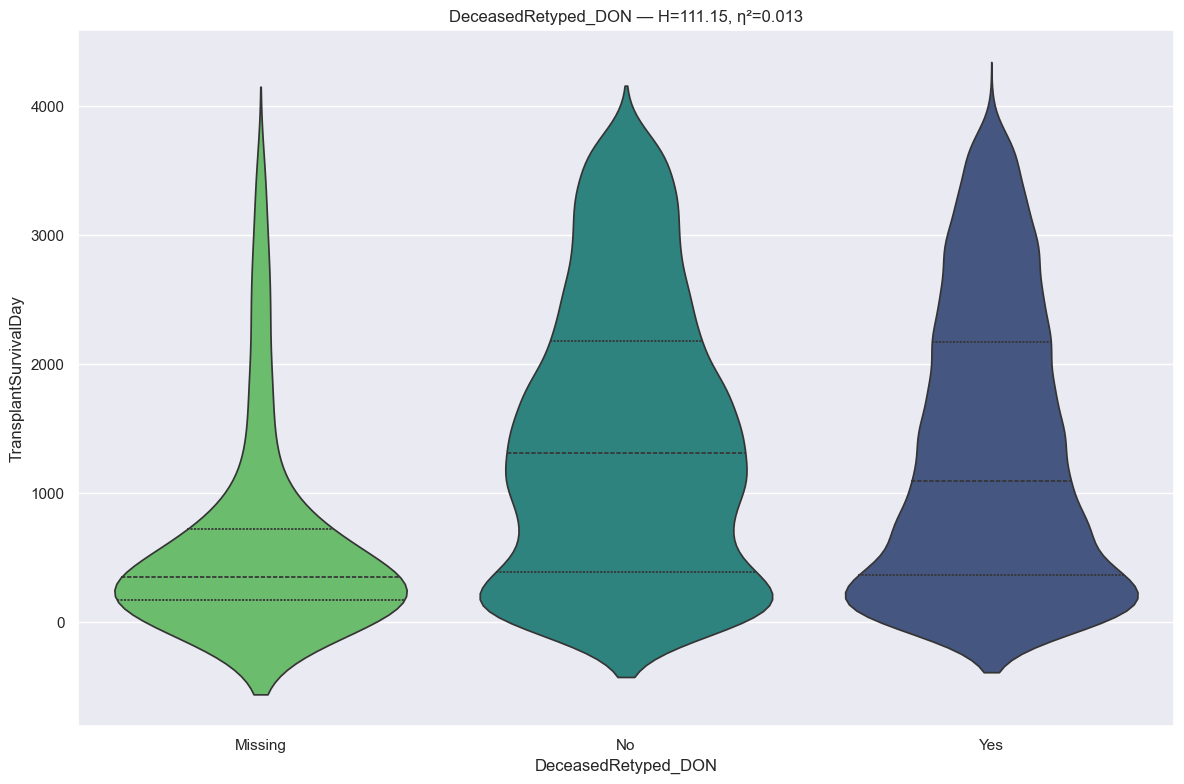

RANKING REPORT: DeceasedRetyped_DON (n ≥ 30)
INCLUDED CATEGORIES:
 * Missing                                           :    154 records
 * No                                                :   3081 records
 * Yes                                               :   5084 records
BYPASSED CATEGORIES: None
--------------------------------------------------------------------------------
Kruskal H: 111.1510 | P-value: 7.309077e-25 | Effect η²: 0.0131
Correction Method: BONFERRONI
Pairwise Testing (Bonferroni Alpha: 0.0167 | r_threshold: 0.10)
--------------------------------------------------------------------------------
Missing      vs No           | p=6.5519e-24 | thr=0.0167 | r= 0.481 | *Sig*
Missing      vs Yes          | p=1.6174e-19 | thr=0.0167 | r= 0.427 | *Sig*
No           vs Yes          | p=5.7472e-06 | thr=0.0167 | r=-0.060 | *Sig*
::::: Collapsed into 3 groups (excluding 'Other') :::::



In [7]:
# instantiate class
ranker = NominalSurvivalRanker.NominalSurvivalRanker(
    method="bonferroni", # bonferroni, Holm-Bonferroni (holm) Benjamini–Hochberg (fdr)
)
# initialize variable
results = ranker.fit(df, features[0])
# mapping DataFrame
new_row = pd.DataFrame([ranker.build_feature_dict(results)])
mapping_df = pd.concat([mapping_df, new_row], ignore_index=True)

In [8]:
# mapping dictionary
print(results['mapping'])
mean_survival_by_category(df, features[0])

{'Missing': 'Group_1', 'No': 'Group_2', 'Yes': 'Group_3'}


,DeceasedRetyped_DON,mean_survival_days,record_count
2,Yes,1313.241739,5084
1,No,1416.502110,3081
0,Missing,601.850649,154


##### **Note:** Statistically significant after Bonferroni and practically meaningful (|r| > 0.10 threshold) and none should be collapsed.

#### Antigen DA1

In [9]:
# info
features = u.get_feature_info(df, 'AntigenDA1', cat=False)
# dtype
{col: df[col].dtype for col in features}

               count unique top  freq
AntigenDA1_DON  8319     32   2  3333

:::: NaN Count:
AntigenDA1_DON    0 



{'AntigenDA1_DON': CategoricalDtype(categories=['01:01', '01:02', '02:01', '02:02', '02:03', '02:05',
                   '02:06', '03:01', '03:02', '1', '10', '11', '11:01', '2',
                   '23', '24', '24:02', '24:03', '25', '26', '26:01', '28',
                   '29', '29:02', '3', '30', '30:01', '31', '32', '33', '33:03',
                   '34', '34:02', '36', '66', '66:01', '68', '68:02', '69',
                   '74', 'Missing'],
 , ordered=False, categories_dtype=object)}

* Bonferroni/Holm (FWER): These are "perfectionists." They try to ensure there is a 0% chance of even one single mistake (Type I error) across all tests. With 32 categories, these methods become incredibly strict, often failing to find differences even when they exist.
* FDR (Benjamini–Hochberg): This is a "pragmatist." It says, "If I claim 100 pairs are different, I’m okay if $\approx$5 of those claims are wrong." It controls the proportion of errors rather than the existence of a single error.
* We still want to be careful about false positives, but I don’t want to throw away everything here 

In [10]:
# mapping dictionary
print(results['mapping'])
mean_survival_by_category(df, features[0])

{'Missing': 'Group_1', 'No': 'Group_2', 'Yes': 'Group_3'}


,AntigenDA1_DON,mean_survival_days,record_count
10,2,1348.080408,3333
7,1,1357.851583,1927
19,3,1363.034247,1022
12,24,1330.877301,489
8,11,1268.760925,389
11,23,1333.866667,285
20,30,1342.308108,185
17,29,1401.000000,135
16,26,1305.804878,123
23,33,1378.231707,82


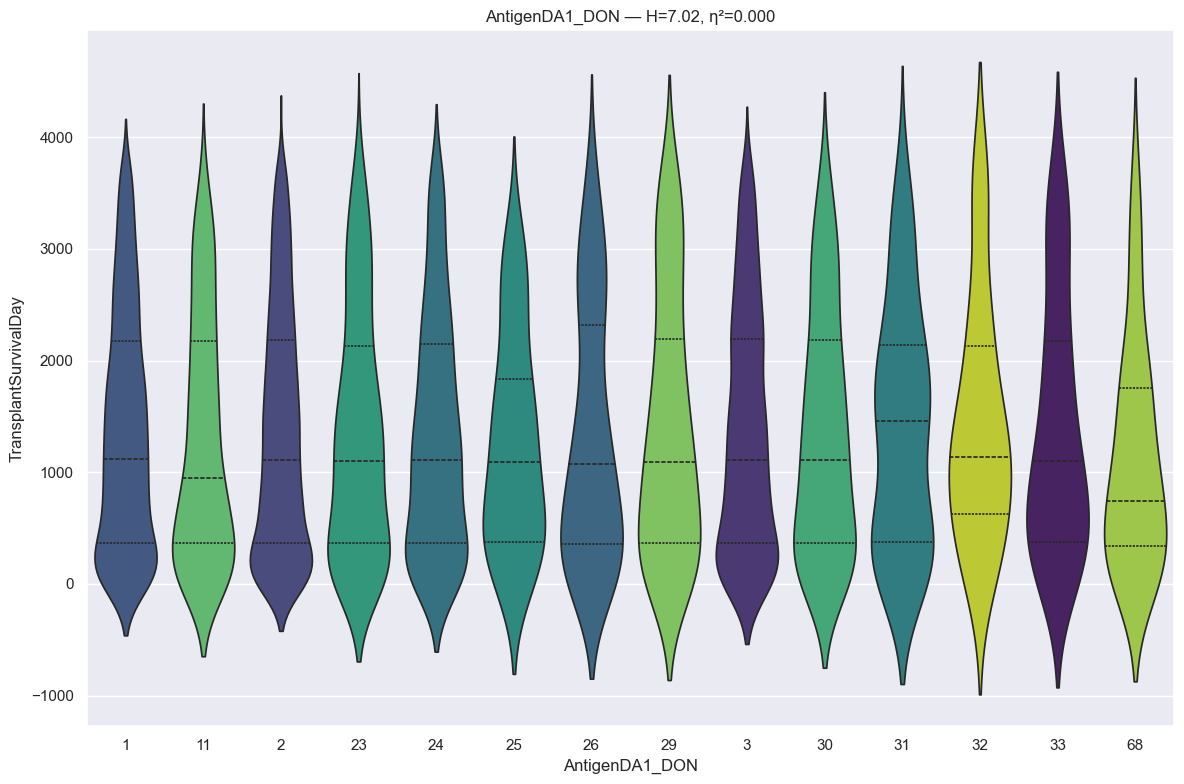

RANKING REPORT: AntigenDA1_DON (n ≥ 30)
INCLUDED CATEGORIES:
 * 1                                                 :   1927 records
 * 11                                                :    389 records
 * 2                                                 :   3333 records
 * 23                                                :    285 records
 * 24                                                :    489 records
 * 25                                                :     59 records
 * 26                                                :    123 records
 * 29                                                :    135 records
 * 3                                                 :   1022 records
 * 30                                                :    185 records
 * 31                                                :     75 records
 * 32                                                :     40 records
 * 33                                                :     82 records
 * 68                        

In [11]:
# instantiate class
ranker = NominalSurvivalRanker.NominalSurvivalRanker(
    method="bonferroni",  # bonferroni, Holm-Bonferroni (holm) Benjamini–Hochberg (fdr)
    r_thresh=0.05, # Lower r-threshold (strict merging)
    suppress_pairwise=True,
)
# initialize variable
results = ranker.fit(df, features[0])
# mapping DataFrame
new_row = pd.DataFrame([ranker.build_feature_dict(results)])
mapping_df = pd.concat([mapping_df, new_row], ignore_index=True)

In [12]:
# mapping dictionary
print(results['mapping'])
mean_survival_by_category(df, features[0])

{'1': 'Group_1', '11': 'Group_1', '2': 'Group_1', '23': 'Group_1', '24': 'Group_1', '25': 'Group_1', '26': 'Group_1', '29': 'Group_1', '3': 'Group_1', '30': 'Group_1', '31': 'Group_1', '32': 'Group_1', '33': 'Group_1', '68': 'Group_2', '01:01': 'Other', '02:01': 'Other', '02:02': 'Other', '02:03': 'Other', '02:05': 'Other', '02:06': 'Other', '03:01': 'Other', '11:01': 'Other', '24:02': 'Other', '24:03': 'Other', '29:02': 'Other', '34': 'Other', '36': 'Other', '66': 'Other', '68:02': 'Other', '69': 'Other', '74': 'Other', 'Missing': 'Other'}


,AntigenDA1_DON,mean_survival_days,record_count
10,2,1348.080408,3333
7,1,1357.851583,1927
19,3,1363.034247,1022
12,24,1330.877301,489
8,11,1268.760925,389
11,23,1333.866667,285
20,30,1342.308108,185
17,29,1401.000000,135
16,26,1305.804878,123
23,33,1378.231707,82


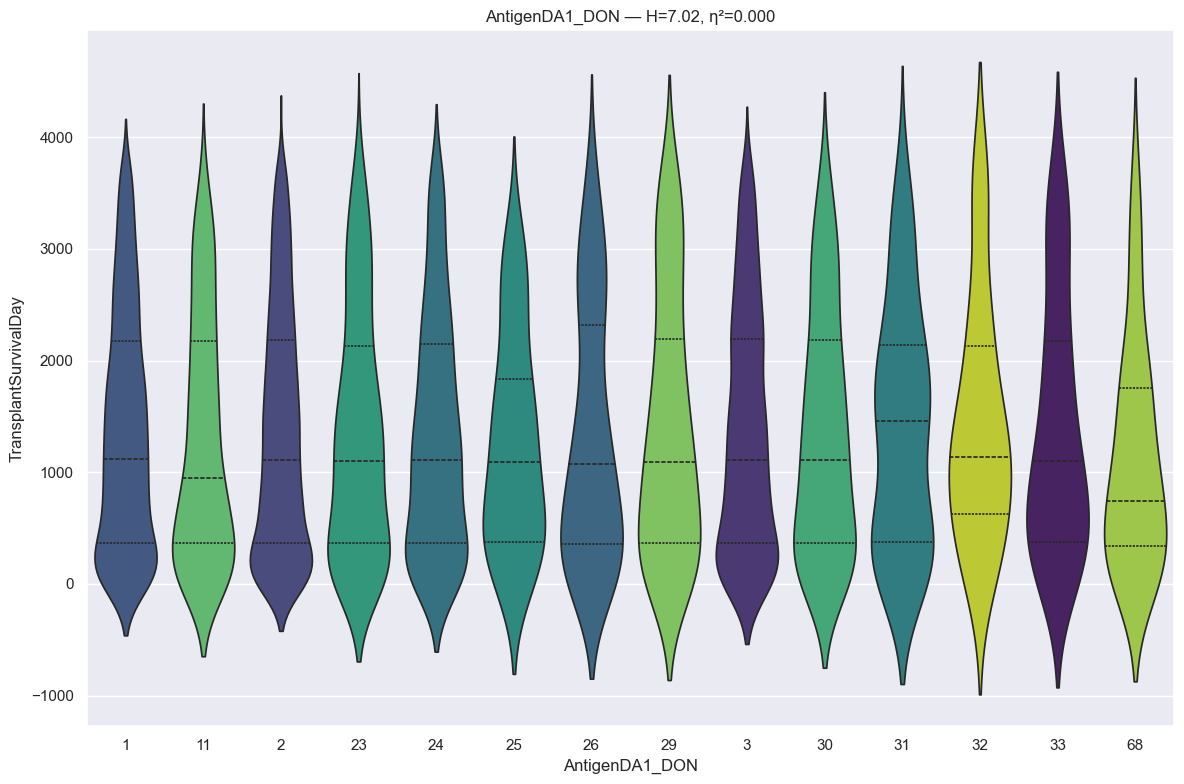

RANKING REPORT: AntigenDA1_DON (n ≥ 30)
INCLUDED CATEGORIES:
 * 1                                                 :   1927 records
 * 11                                                :    389 records
 * 2                                                 :   3333 records
 * 23                                                :    285 records
 * 24                                                :    489 records
 * 25                                                :     59 records
 * 26                                                :    123 records
 * 29                                                :    135 records
 * 3                                                 :   1022 records
 * 30                                                :    185 records
 * 31                                                :     75 records
 * 32                                                :     40 records
 * 33                                                :     82 records
 * 68                        

In [13]:
# instantiate class
ranker = NominalSurvivalRanker.NominalSurvivalRanker(
    method="fdr",  # bonferroni, Holm-Bonferroni (holm) Benjamini–Hochberg (fdr)
    r_thresh=0.05, # Lower r-threshold (strict merging)
    suppress_pairwise=True,
)
# initialize variable
results = ranker.fit(df, features[0])
# mapping DataFrame & remove last entry 
mapping_df = mapping_df[mapping_df["feature"] != features[0]]
new_row = pd.DataFrame([ranker.build_feature_dict(results)])
mapping_df = pd.concat([mapping_df, new_row], ignore_index=True)

In [14]:
# mapping dictionary
collapse_map = results['mapping']
# New feature
df[features[0] + "_group"] = (
    df[features[0]]
    .map(collapse_map)
    .astype("category")
)
# initialize list
remove_cols = features
# update feature with new name
mapping_df.loc[mapping_df["feature"].isin(features), "feature"] = mapping_df["feature"] + "_group"
# sanity check
df[features[0] + "_group"].isna().any()

np.False_

#### AntigenDA2

In [15]:
# info
features = u.get_feature_info(df, 'AntigenDA2', cat=False)
# dtype
{col: df[col].dtype for col in features}

               count unique top freq
AntigenDA2_DON  8319     40  24  950

:::: NaN Count:
AntigenDA2_DON    0 



{'AntigenDA2_DON': CategoricalDtype(categories=['0', '01:01', '02:01', '02:03', '02:05', '02:06', '03:01',
                   '1', '10', '11', '11:01', '2', '23', '24', '24:02', '24:03',
                   '25', '26', '26:01', '28', '29', '29:01', '29:02', '3', '30',
                   '30:01', '30:02', '31', '32', '33', '33:01', '33:03', '34',
                   '34:02', '36', '43', '66', '66:01', '66:02', '68', '68:01',
                   '68:02', '69', '74', '80', 'Missing',
                   'No second antigen detected'],
 , ordered=False, categories_dtype=object)}

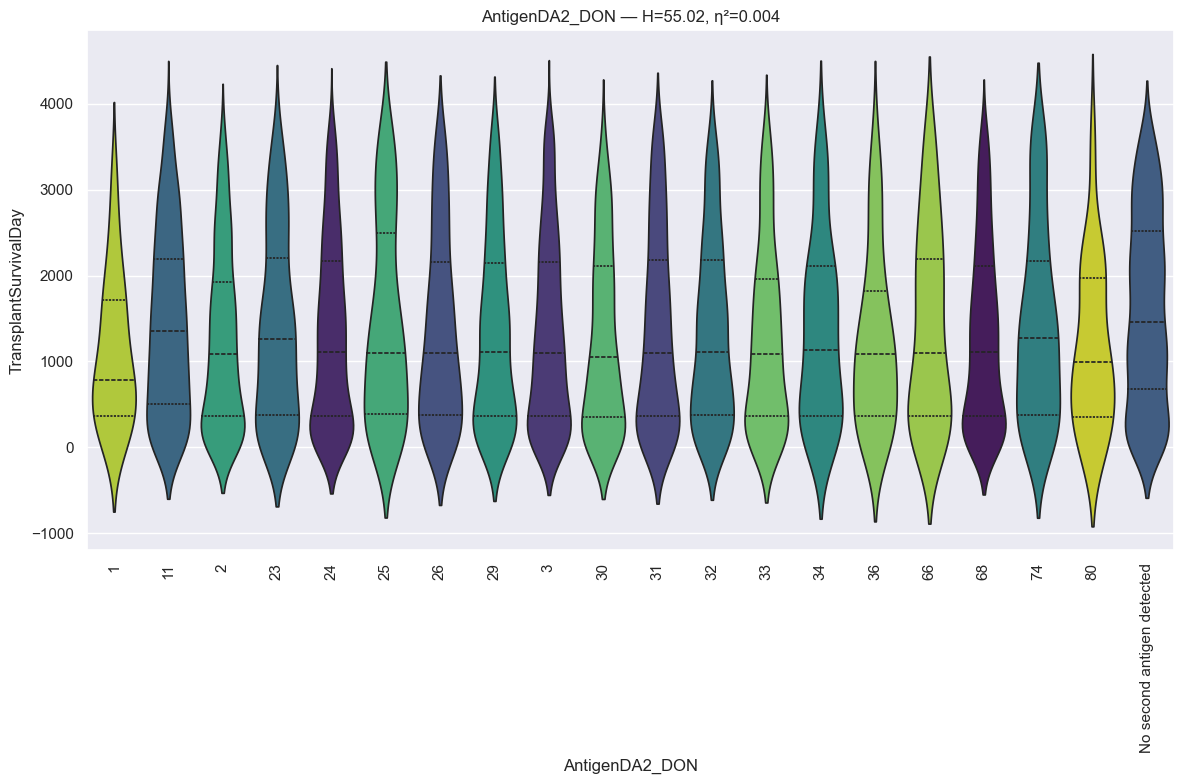

RANKING REPORT: AntigenDA2_DON (n ≥ 30)
INCLUDED CATEGORIES:
 * 1                                                 :     59 records
 * 11                                                :    499 records
 * 2                                                 :    844 records
 * 23                                                :    301 records
 * 24                                                :    950 records
 * 25                                                :    178 records
 * 26                                                :    341 records
 * 29                                                :    443 records
 * 3                                                 :    851 records
 * 30                                                :    501 records
 * 31                                                :    434 records
 * 32                                                :    442 records
 * 33                                                :    363 records
 * 34                        

In [16]:
# instantiate class
ranker = NominalSurvivalRanker.NominalSurvivalRanker(
    method="bonferroni",  # bonferroni, Holm-Bonferroni (holm) Benjamini–Hochberg (fdr)
    r_thresh=0.05, # Lower r-threshold (strict merging)
    suppress_pairwise=True,
    rotation=90,
)
# initialize variable
results = ranker.fit(df, features[0])
# mapping DataFrame
new_row = pd.DataFrame([ranker.build_feature_dict(results)])
mapping_df = pd.concat([mapping_df, new_row], ignore_index=True)

In [17]:
# mapping dictionary
print(results['mapping'])
mean_survival_by_category(df, features[0])

{'1': 'Group_1', '11': 'Group_1', '2': 'Group_1', '23': 'Group_1', '24': 'Group_1', '25': 'Group_1', '26': 'Group_1', '29': 'Group_1', '3': 'Group_1', '30': 'Group_1', '31': 'Group_1', '32': 'Group_1', '33': 'Group_1', '34': 'Group_1', '36': 'Group_1', '66': 'Group_1', '68': 'Group_1', '74': 'Group_1', '80': 'Group_1', 'No second antigen detected': 'Group_2', '0': 'Other', '01:01': 'Other', '02:01': 'Other', '02:03': 'Other', '03:01': 'Other', '11:01': 'Other', '24:02': 'Other', '24:03': 'Other', '26:01': 'Other', '29:02': 'Other', '30:01': 'Other', '30:02': 'Other', '33:03': 'Other', '34:02': 'Other', '66:01': 'Other', '66:02': 'Other', '68:01': 'Other', '68:02': 'Other', '69': 'Other', 'Missing': 'Other'}


,AntigenDA2_DON,mean_survival_days,record_count
10,24,1322.392632,950
18,3,1321.870740,851
8,2,1258.662322,844
32,68,1305.357576,825
39,No second antigen detected,1576.055256,742
19,30,1245.075848,501
6,11,1434.056112,499
16,29,1322.304740,443
23,32,1337.081448,442
22,31,1351.647465,434


In [18]:
# mapping dictionary
collapse_map = results['mapping']
# New feature
df[features[0] + "_group"] = (
    df[features[0]]
    .map(collapse_map)
    .astype("category")
)
# add to remove list
remove_cols.extend(features)
# update feature with new name
mapping_df.loc[mapping_df["feature"].isin(features), "feature"] = mapping_df["feature"] + "_group"
# sanity check
df[features[0] + "_group"].isna().any()

np.False_

####  Antigen DB1

In [19]:
# info
features = u.get_feature_info(df, 'AntigenDB1', cat=False)
# dtype
{col: df[col].dtype for col in features}

               count unique top  freq
AntigenDB1_DON  8319     67   7  1671

:::: NaN Count:
AntigenDB1_DON    0 



{'AntigenDB1_DON': CategoricalDtype(categories=['07:02', '08:01', '13', '13:02', '14', '14:01', '14:02',
                   '15', '15:01', '15:03', '15:07', '15:10', '15:16', '15:17',
                   '15:18', '18', '27', '27:04', '27:05', '35', '35:01',
                   '35:02', '35:03', '35:08', '35:12', '37', '38', '38:01',
                   '39', '39:01', '39:02', '39:06', '40', '40:01', '40:02',
                   '40:05', '40:06', '41', '41:02', '42', '42:01', '42:02',
                   '44', '44:02', '44:03', '45', '46', '47', '48', '49', '50',
                   '50:01', '51', '51:01', '51:02', '52', '53', '54', '55',
                   '55:01', '56', '56:03', '57', '58', '59', '60', '61', '62',
                   '63', '64', '65', '7', '70', '703', '71', '72', '75', '76',
                   '77', '78', '8', '81', 'Missing'],
 , ordered=False, categories_dtype=object)}

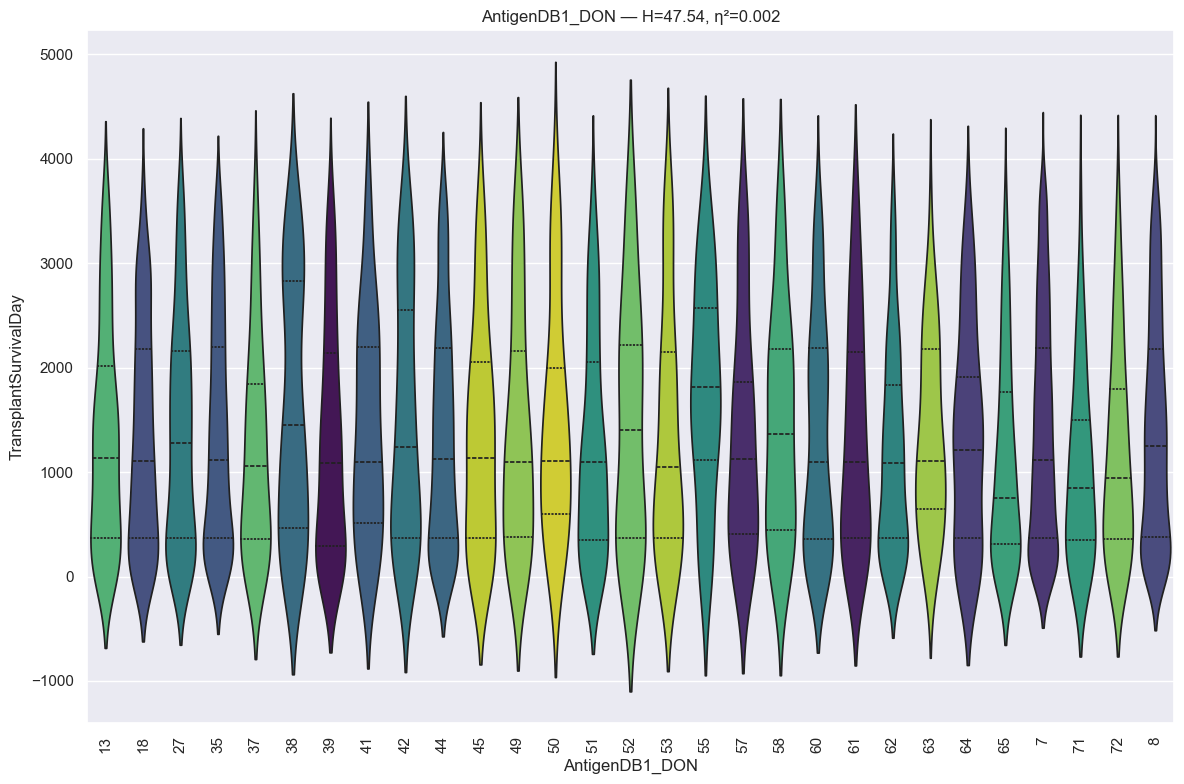

RANKING REPORT: AntigenDB1_DON (n ≥ 30)
INCLUDED CATEGORIES:
 * 13                                                :    272 records
 * 18                                                :    423 records
 * 27                                                :    360 records
 * 35                                                :    922 records
 * 37                                                :    107 records
 * 38                                                :    116 records
 * 39                                                :    231 records
 * 41                                                :     67 records
 * 42                                                :    106 records
 * 44                                                :    722 records
 * 45                                                :     98 records
 * 49                                                :     88 records
 * 50                                                :     38 records
 * 51                        

In [20]:
# initialize variable
results = ranker.fit(df, features[0])
# mapping DataFrame
new_row = pd.DataFrame([ranker.build_feature_dict(results)])
mapping_df = pd.concat([mapping_df, new_row], ignore_index=True)

In [21]:
# mapping dictionary
print(results['mapping'])
mean_survival_by_category(df, features[0])

{'13': 'Group_1', '18': 'Group_1', '27': 'Group_1', '35': 'Group_1', '37': 'Group_1', '38': 'Group_1', '39': 'Group_1', '41': 'Group_1', '42': 'Group_1', '44': 'Group_1', '45': 'Group_1', '49': 'Group_1', '50': 'Group_1', '51': 'Group_1', '52': 'Group_1', '53': 'Group_1', '57': 'Group_1', '58': 'Group_1', '60': 'Group_1', '61': 'Group_1', '62': 'Group_1', '63': 'Group_1', '64': 'Group_1', '65': 'Group_1', '7': 'Group_1', '71': 'Group_1', '72': 'Group_1', '8': 'Group_1', '55': 'Group_2', '07:02': 'Other', '08:01': 'Other', '13:02': 'Other', '14': 'Other', '14:01': 'Other', '14:02': 'Other', '15': 'Other', '15:01': 'Other', '15:03': 'Other', '15:07': 'Other', '15:17': 'Other', '27:04': 'Other', '27:05': 'Other', '35:01': 'Other', '35:08': 'Other', '39:01': 'Other', '39:02': 'Other', '40': 'Other', '40:01': 'Other', '40:05': 'Other', '40:06': 'Other', '44:02': 'Other', '44:03': 'Other', '46': 'Other', '47': 'Other', '48': 'Other', '51:01': 'Other', '54': 'Other', '56': 'Other', '56:03': '

,AntigenDB1_DON,mean_survival_days,record_count
56,7,1383.639138,1671
65,8,1386.736577,1192
16,35,1376.725597,922
30,44,1366.781163,722
12,18,1331.122931,423
52,62,1198.975936,374
13,27,1358.297222,360
2,13,1343.183824,272
21,39,1269.380952,231
50,60,1332.093333,225


In [22]:
# mapping dictionary
collapse_map = results['mapping']
# New feature
df[features[0] + "_group"] = (
    df[features[0]]
    .map(collapse_map)
    .astype("category")
)
# add to remove list
remove_cols.extend(features)
# update feature with new name
mapping_df.loc[mapping_df["feature"].isin(features), "feature"] = mapping_df["feature"] + "_group"
# sanity check
df[features[0] + "_group"].isna().any()

np.False_

#### Antigen DB2

In [23]:
# info
features = u.get_feature_info(df, 'AntigenDB2', cat=False)
# dtype
{col: df[col].dtype for col in features}

               count unique top  freq
AntigenDB2_DON  8319     74  44  1212

:::: NaN Count:
AntigenDB2_DON    0 



{'AntigenDB2_DON': CategoricalDtype(categories=['07:02', '08:01', '12', '13', '13:02', '14', '14:01',
                   '14:02', '15', '15:01', '15:10', '15:16', '15:17', '18',
                   '22', '27', '27:05', '27:08', '35', '35:01', '35:02',
                   '35:03', '35:08', '35:12', '37', '38', '38:01', '39',
                   '39:01', '39:02', '39:05', '39:06', '40', '40:01', '40:02',
                   '40:05', '41', '41:01', '41:02', '42', '42:01', '42:02',
                   '44', '44:02', '44:03', '45', '46', '47', '48', '48:01',
                   '49', '50', '50:01', '51', '51:01', '51:02', '52', '53',
                   '54', '55', '55:01', '56', '56:01', '57', '57:01', '57:03',
                   '58', '59', '60', '61', '62', '63', '64', '65', '67', '7',
                   '70', '71', '72', '73', '75', '76', '77', '78', '8', '81',
                   '82', '82:01', 'Missing', 'No second antigen detected'],
 , ordered=False, categories_dtype=object)}

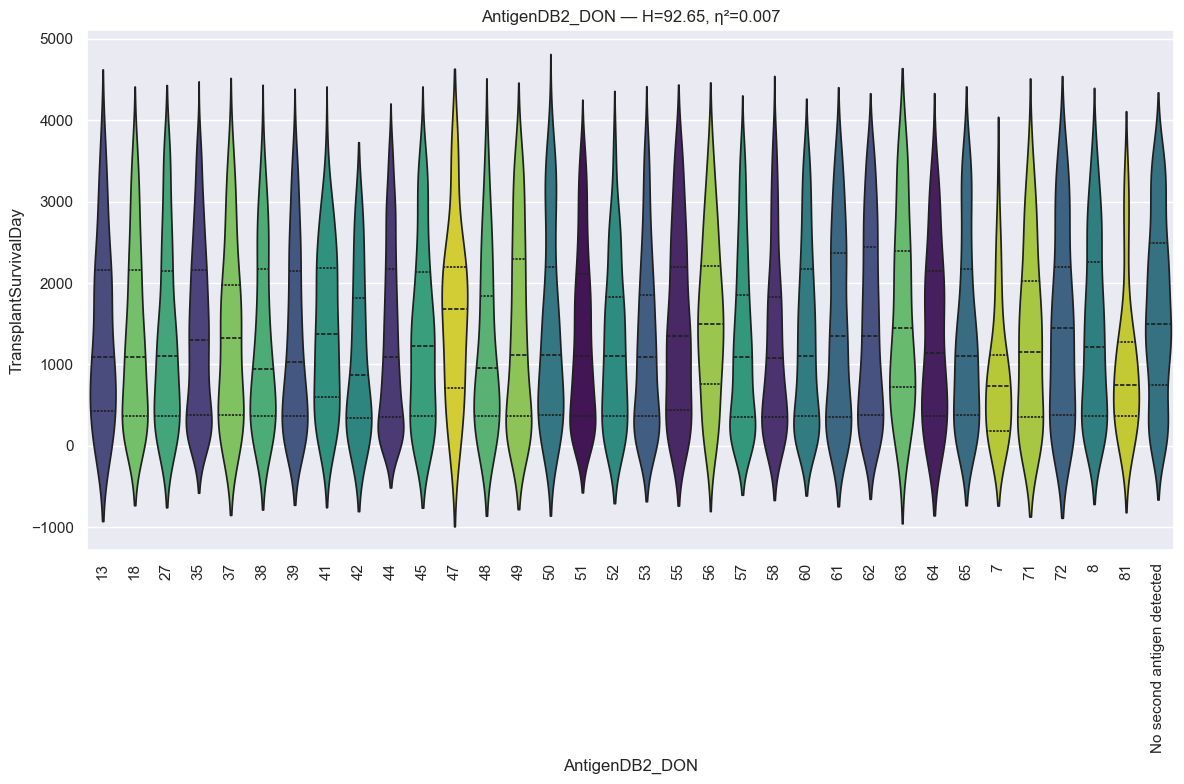

RANKING REPORT: AntigenDB2_DON (n ≥ 30)
INCLUDED CATEGORIES:
 * 13                                                :     64 records
 * 18                                                :    205 records
 * 27                                                :    190 records
 * 35                                                :    573 records
 * 37                                                :     93 records
 * 38                                                :    125 records
 * 39                                                :    213 records
 * 41                                                :    104 records
 * 42                                                :     71 records
 * 44                                                :   1212 records
 * 45                                                :    162 records
 * 47                                                :     39 records
 * 48                                                :     75 records
 * 49                        

In [24]:
# initialize variable
results = ranker.fit(df, features[0])
# mapping DataFrame
new_row = pd.DataFrame([ranker.build_feature_dict(results)])
mapping_df = pd.concat([mapping_df, new_row], ignore_index=True)

In [25]:
# mapping dictionary
print(results['mapping'])
mean_survival_by_category(df, features[0])

{'13': 'Group_1', '18': 'Group_1', '27': 'Group_1', '35': 'Group_1', '37': 'Group_1', '38': 'Group_1', '39': 'Group_1', '41': 'Group_1', '44': 'Group_1', '45': 'Group_1', '48': 'Group_1', '49': 'Group_1', '50': 'Group_1', '51': 'Group_1', '52': 'Group_1', '53': 'Group_1', '55': 'Group_1', '57': 'Group_1', '58': 'Group_1', '60': 'Group_1', '61': 'Group_1', '62': 'Group_1', '64': 'Group_1', '65': 'Group_1', '71': 'Group_1', '72': 'Group_1', '8': 'Group_1', '42': 'Group_2', '81': 'Group_2', '47': 'Group_3', '56': 'Group_3', '63': 'Group_3', 'No second antigen detected': 'Group_3', '7': 'Group_4', '07:02': 'Other', '08:01': 'Other', '13:02': 'Other', '14': 'Other', '14:01': 'Other', '14:02': 'Other', '15:01': 'Other', '22': 'Other', '27:05': 'Other', '35:01': 'Other', '35:03': 'Other', '38:01': 'Other', '39:01': 'Other', '39:02': 'Other', '39:05': 'Other', '40': 'Other', '40:01': 'Other', '40:02': 'Other', '40:05': 'Other', '41:01': 'Other', '42:01': 'Other', '44:02': 'Other', '44:03': 'Ot

,AntigenDB2_DON,mean_survival_days,record_count
30,44,1285.743399,1212
40,51,1332.895062,648
12,35,1373.778360,573
53,60,1332.003960,505
49,57,1250.814141,495
55,62,1462.254348,460
73,No second antigen detected,1666.637097,372
52,58,1233.389776,313
44,53,1256.209302,258
58,65,1349.128099,242


In [26]:
# mapping dictionary
collapse_map = results['mapping']
# New feature
df[features[0] + "_group"] = (
    df[features[0]]
    .map(collapse_map)
    .astype("category")
)
# add to remove listBloo
remove_cols.extend(features)
# update feature with new name
mapping_df.loc[mapping_df["feature"].isin(features), "feature"] = mapping_df["feature"] + "_group"
# sanity check
df[features[0] + "_group"].isna().any()

np.False_

#### Antigen DR1

In [27]:
# info
features = u.get_feature_info(df, 'AntigenDR1', cat=False)
# dtype
{col: df[col].dtype for col in features}

               count unique top  freq
AntigenDR1_DON  8319     35   4  2012

:::: NaN Count:
AntigenDR1_DON    0 



{'AntigenDR1_DON': CategoricalDtype(categories=['01:01', '01:02', '01:03', '03:01', '03:02', '04:01',
                   '04:02', '04:03', '04:04', '04:05', '04:07', '04:11',
                   '08:01', '08:02', '09:01', '1', '10', '103', '11', '11:01',
                   '11:03', '11:04', '12', '12:01', '13', '13:01', '13:02',
                   '13:03', '13:05', '14', '14:02', '14:04', '14:54', '15',
                   '15:01', '16', '17', '18', '3', '4', '7', '8', '9',
                   'Missing'],
 , ordered=False, categories_dtype=object)}

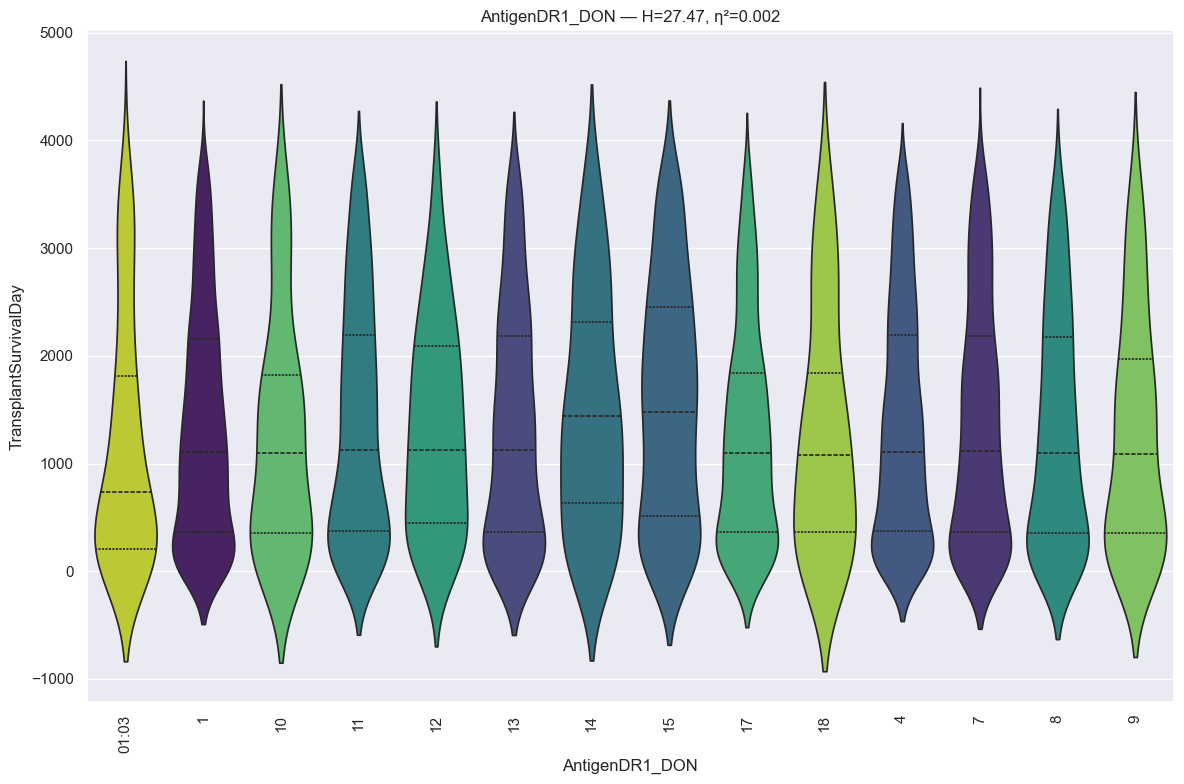

RANKING REPORT: AntigenDR1_DON (n ≥ 30)
INCLUDED CATEGORIES:
 * 01:03                                             :    142 records
 * 1                                                 :   1411 records
 * 10                                                :    104 records
 * 11                                                :    690 records
 * 12                                                :    144 records
 * 13                                                :    638 records
 * 14                                                :    115 records
 * 15                                                :    344 records
 * 17                                                :    853 records
 * 18                                                :     74 records
 * 4                                                 :   2012 records
 * 7                                                 :   1135 records
 * 8                                                 :    428 records
 * 9                         

In [28]:
# initialize variable
results = ranker.fit(df, features[0])
# mapping DataFrame
new_row = pd.DataFrame([ranker.build_feature_dict(results)])
mapping_df = pd.concat([mapping_df, new_row], ignore_index=True)

In [29]:
# mapping dictionary
print(results['mapping'])
mean_survival_by_category(df, features[0])

{'01:03': 'Group_1', '1': 'Group_2', '10': 'Group_2', '11': 'Group_2', '12': 'Group_2', '13': 'Group_2', '14': 'Group_2', '15': 'Group_2', '17': 'Group_2', '18': 'Group_2', '4': 'Group_2', '7': 'Group_2', '8': 'Group_2', '9': 'Group_2', '01:01': 'Other', '01:02': 'Other', '03:01': 'Other', '03:02': 'Other', '04:01': 'Other', '04:02': 'Other', '04:03': 'Other', '04:04': 'Other', '04:05': 'Other', '04:07': 'Other', '09:01': 'Other', '103': 'Other', '11:01': 'Other', '11:04': 'Other', '13:01': 'Other', '13:02': 'Other', '14:02': 'Other', '14:04': 'Other', '15:01': 'Other', '16': 'Other', 'Missing': 'Other'}


,AntigenDR1_DON,mean_survival_days,record_count
30,4,1360.453777,2012
12,1,1324.608079,1411
31,7,1362.756828,1135
28,17,1278.347011,853
15,11,1385.227536,690
19,13,1350.642633,638
32,8,1294.932243,428
25,15,1556.447674,344
18,12,1351.979167,144
2,01:03,1162.605634,142


In [30]:
# mapping dictionary
collapse_map = results['mapping']
# New feature
df[features[0] + "_group"] = (
    df[features[0]]
    .map(collapse_map)
    .astype("category")
)
# add to remove list
remove_cols.extend(features)
# update feature with new name
mapping_df.loc[mapping_df["feature"].isin(features), "feature"] = mapping_df["feature"] + "_group"
# sanity check
df[features[0] + "_group"].isna().any()

np.False_

#### Antigen DR2

In [31]:
# info
features = u.get_feature_info(df, 'AntigenDR2', cat=False)
# dtype
{col: df[col].dtype for col in features}

               count unique top  freq
AntigenDR2_DON  8319     38  15  1687

:::: NaN Count:
AntigenDR2_DON    0 



{'AntigenDR2_DON': CategoricalDtype(categories=['01:01', '01:03', '03:01', '04:01', '04:04', '04:05',
                   '04:07', '08:01', '08:02', '09:01', '1', '10', '103', '11',
                   '11:01', '11:03', '11:04', '12', '12:01', '12:02', '13',
                   '13:01', '13:02', '13:03', '13:05', '14', '14:01', '14:02',
                   '14:04', '14:06', '14:54', '15', '15:01', '15:02', '15:03',
                   '16', '16:01', '16:02', '17', '18', '3', '4', '5', '7', '8',
                   '9', 'Missing', 'No second antigen detected'],
 , ordered=False, categories_dtype=object)}

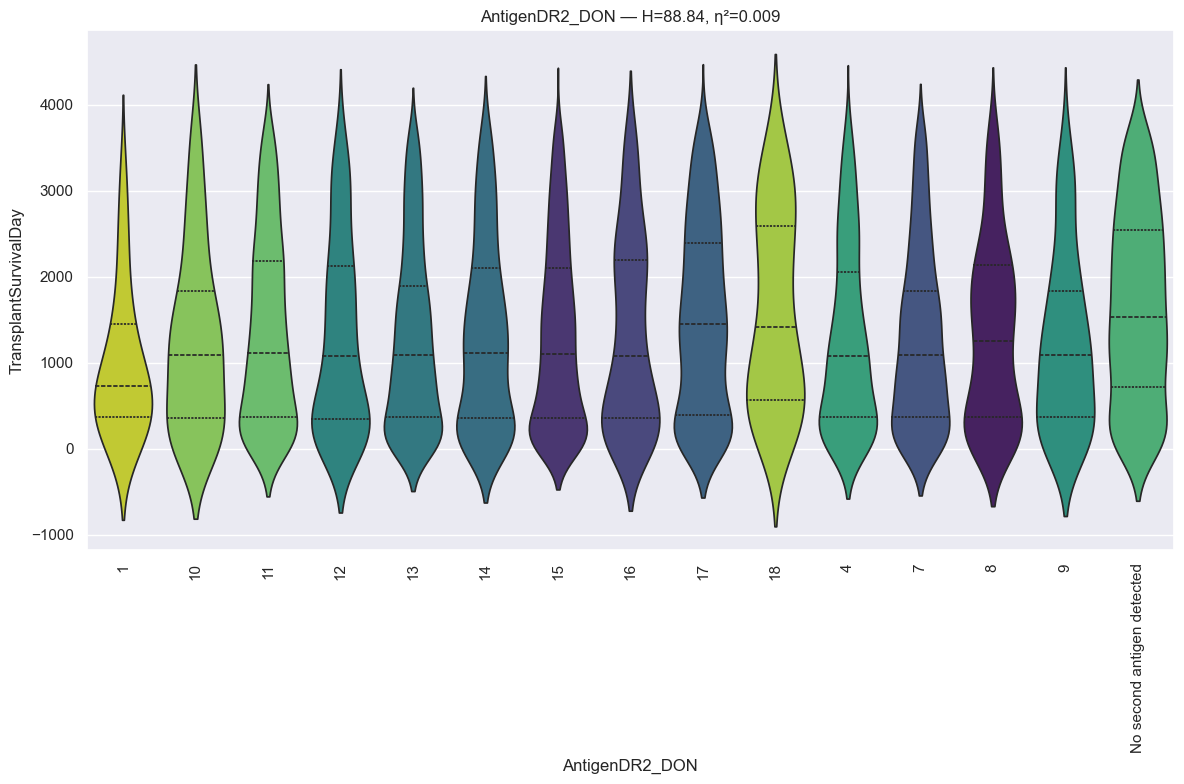

RANKING REPORT: AntigenDR2_DON (n ≥ 30)
INCLUDED CATEGORIES:
 * 1                                                 :     33 records
 * 10                                                :    104 records
 * 11                                                :    839 records
 * 12                                                :    219 records
 * 13                                                :   1359 records
 * 14                                                :    453 records
 * 15                                                :   1687 records
 * 16                                                :    267 records
 * 17                                                :    821 records
 * 18                                                :     97 records
 * 4                                                 :    594 records
 * 7                                                 :    726 records
 * 8                                                 :    298 records
 * 9                         

In [32]:
# initialize variable
results = ranker.fit(df, features[0])
# mapping DataFrame
new_row = pd.DataFrame([ranker.build_feature_dict(results)])
mapping_df = pd.concat([mapping_df, new_row], ignore_index=True)

In [33]:
# mapping dictionary
print(results['mapping'])
mean_survival_by_category(df, features[0])

{'1': 'Group_1', '10': 'Group_2', '11': 'Group_2', '12': 'Group_2', '13': 'Group_2', '14': 'Group_2', '15': 'Group_2', '16': 'Group_2', '4': 'Group_2', '7': 'Group_2', '8': 'Group_2', '9': 'Group_2', '17': 'Group_3', '18': 'Group_3', 'No second antigen detected': 'Group_3', '01:03': 'Other', '03:01': 'Other', '04:01': 'Other', '04:04': 'Other', '04:07': 'Other', '08:01': 'Other', '11:01': 'Other', '11:03': 'Other', '11:04': 'Other', '12:01': 'Other', '12:02': 'Other', '13:01': 'Other', '13:02': 'Other', '13:03': 'Other', '14:04': 'Other', '14:06': 'Other', '14:54': 'Other', '15:01': 'Other', '16:01': 'Other', '16:02': 'Other', '3': 'Other', '5': 'Other', 'Missing': 'Other'}


,AntigenDR2_DON,mean_survival_days,record_count
23,15,1292.624185,1687
15,13,1281.220751,1359
8,11,1369.876043,839
28,17,1505.716200,821
33,7,1287.296143,726
37,No second antigen detected,1640.570248,605
31,4,1255.784512,594
19,14,1323.304636,453
34,8,1332.892617,298
25,16,1332.284644,267


In [34]:
# mapping dictionary
collapse_map = results['mapping']
# New feature
df[features[0] + "_group"] = (
    df[features[0]]
    .map(collapse_map)
    .astype("category")
)
# add to remove list
remove_cols.extend(features)
# update feature with new name
mapping_df.loc[mapping_df["feature"].isin(features), "feature"] = mapping_df["feature"] + "_group"
# sanity check
df[features[0] + "_group"].isna().any()

np.False_

#### Citizenship

In [35]:
# info
features = u.get_feature_info(df, 'Citizenship', cat=False)
# dtype
{col: df[col].dtype for col in features}

                count unique         top  freq
Citizenship_DON  8319      7  US Citizen  7652

:::: NaN Count:
Citizenship_DON    0 



{'Citizenship_DON': CategoricalDtype(categories=['Missing', 'NON-RESIDENT ALIEN',
                   'Non-US Citizen/Non-US Resident, Traveled to US for Reason Other Than Transplant',
                   'Non-US Citizen/US Resident', 'RESIDENT ALIEN', 'US Citizen',
                   'Unknown'],
 , ordered=False, categories_dtype=object)}

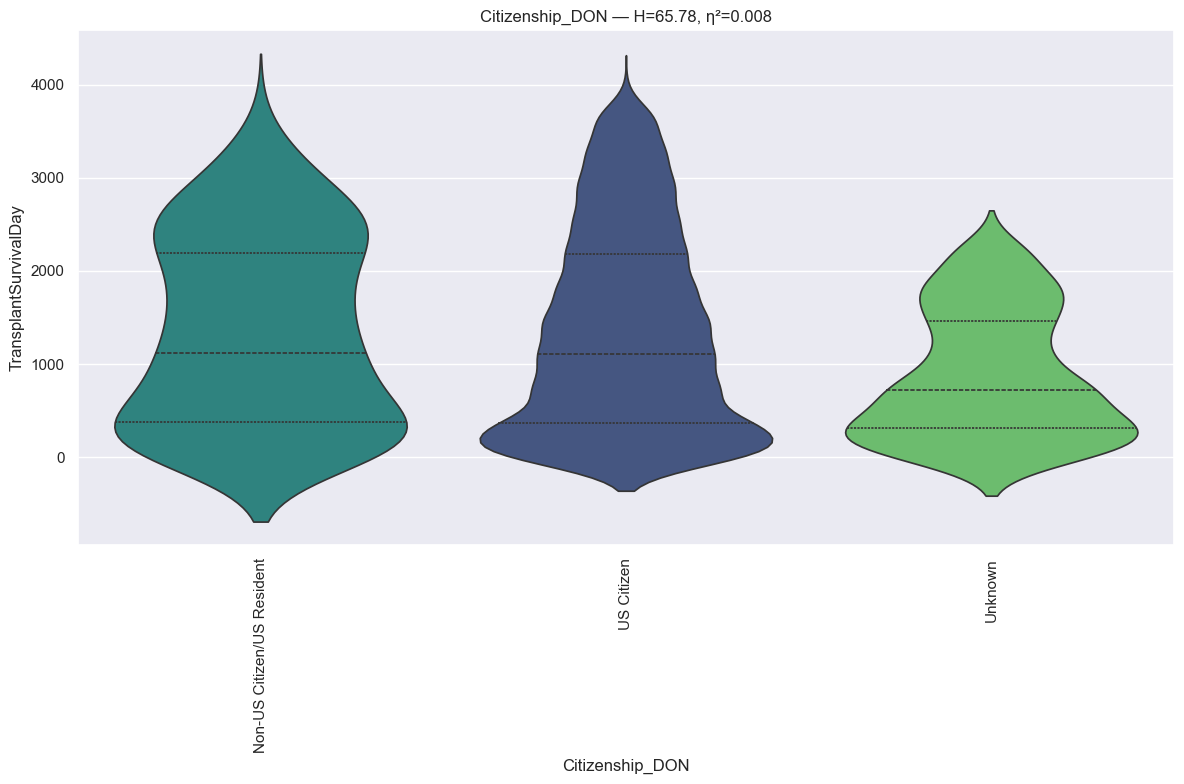

RANKING REPORT: Citizenship_DON (n ≥ 30)
INCLUDED CATEGORIES:
 * Non-US Citizen/US Resident                        :    219 records
 * US Citizen                                        :   7652 records
 * Unknown                                           :    396 records
BYPASSED CATEGORIES (n < min_n):
 * Missing                                           :     13 records
 * NON-RESIDENT ALIEN                                :      3 records
 * Non-US Citizen/Non-US Resident, Traveled to US for Reason Other Than Transplant:     22 records
 * RESIDENT ALIEN                                    :     14 records
--------------------------------------------------------------------------------
Kruskal H: 65.7847 | P-value: 5.188532e-15 | Effect η²: 0.0077
Correction Method: BONFERRONI
Pairwise Testing (Bonferroni Alpha: 0.0167 | r_threshold: 0.10)
--------------------------------------------------------------------------------
[Pairwise comparison output suppressed]
::::: Collapsed into 2 grou

In [36]:
# instantiate class
ranker = NominalSurvivalRanker.NominalSurvivalRanker(
    method="bonferroni",  # bonferroni, Holm-Bonferroni (holm) Benjamini–Hochberg (fdr)
    r_thresh=0.10, # Lower r-threshold (strict merging)
    suppress_pairwise=True,
    rotation=90
)
# initialize variable
results = ranker.fit(df, features[0])
# mapping DataFrame
new_row = pd.DataFrame([ranker.build_feature_dict(results)])
mapping_df = pd.concat([mapping_df, new_row], ignore_index=True)

In [37]:
# mapping dictionary
print(results['mapping'])
mean_survival_by_category(df, features[0])

{'Non-US Citizen/US Resident': 'Group_1', 'US Citizen': 'Group_1', 'Unknown': 'Group_2', 'Missing': 'Other', 'NON-RESIDENT ALIEN': 'Other', 'Non-US Citizen/Non-US Resident, Traveled to US for Reason Other Than Transplant': 'Other', 'RESIDENT ALIEN': 'Other'}


,Citizenship_DON,mean_survival_days,record_count
5,US Citizen,1360.121145,7652
6,Unknown,864.603535,396
3,Non-US Citizen/US Resident,1362.894977,219
2,"Non-US Citizen/Non-US Resident, Traveled to US for Reason Other Than Transplant",1178.045455,22
4,RESIDENT ALIEN,2814.214286,14
0,Missing,973.000000,13
1,NON-RESIDENT ALIEN,2326.666667,3


In [38]:
# mapping dictionary
collapse_map = results['mapping']
# New feature
df[features[0] + "_group"] = (
    df[features[0]]
    .map(collapse_map)
    .astype("category")
)
# add to remove list
remove_cols.extend(features)
# update feature with new name
mapping_df.loc[mapping_df["feature"].isin(features), "feature"] = mapping_df["feature"] + "_group"
# sanity check
df[features[0] + "_group"].isna().any()

np.False_

#### Past Cocaine Use

In [39]:
# info
features = u.get_feature_info(df, 'PastCocaineUse_DON', cat=False)
# dtype
{col: df[col].dtype for col in features}

                   count unique top  freq
PastCocaineUse_DON  8319      4  No  6578

:::: NaN Count:
PastCocaineUse_DON    0 



{'PastCocaineUse_DON': CategoricalDtype(categories=['Missing', 'No', 'Unknown', 'Yes'], ordered=False, categories_dtype=object)}

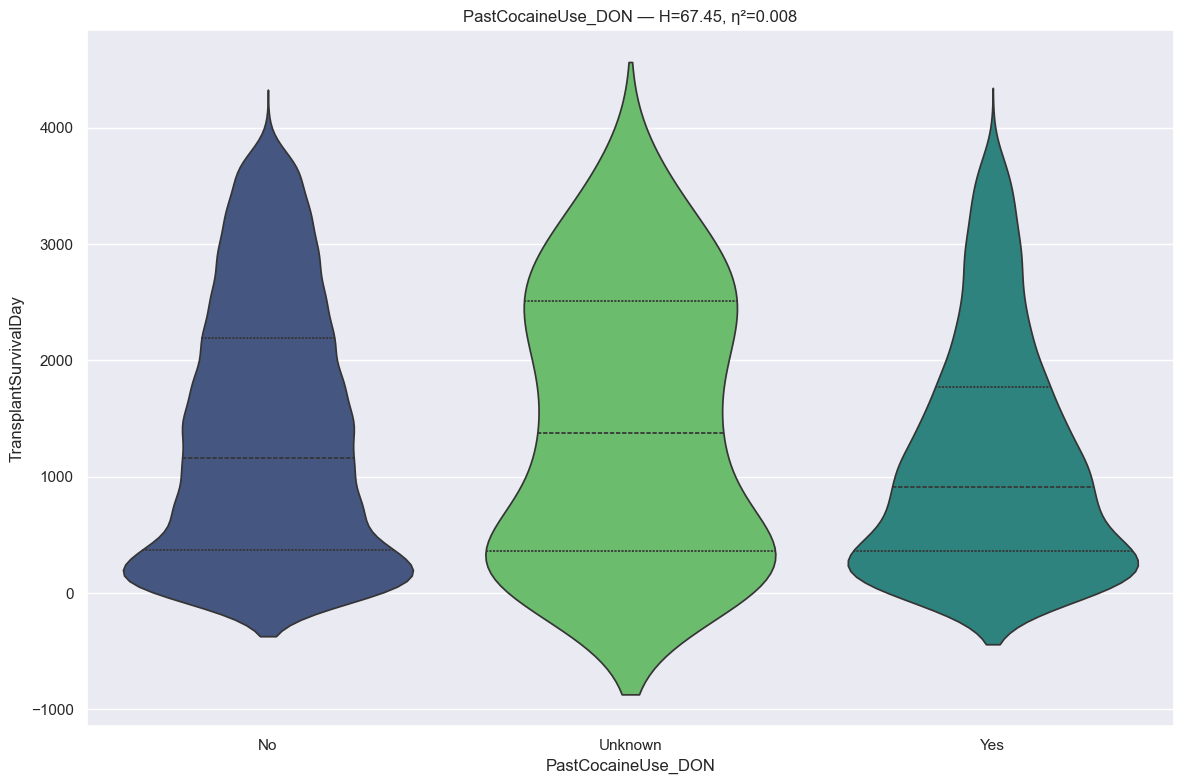

RANKING REPORT: PastCocaineUse_DON (n ≥ 30)
INCLUDED CATEGORIES:
 * No                                                :   6578 records
 * Unknown                                           :    121 records
 * Yes                                               :   1606 records
BYPASSED CATEGORIES (n < min_n):
 * Missing                                           :     14 records
--------------------------------------------------------------------------------
Kruskal H: 67.4490 | P-value: 2.257497e-15 | Effect η²: 0.0079
Correction Method: BONFERRONI
Pairwise Testing (Bonferroni Alpha: 0.0167 | r_threshold: 0.10)
--------------------------------------------------------------------------------
No           vs Yes          | p=2.9944e-16 | thr=0.0167 | r=-0.131 | *Sig*
Unknown      vs Yes          | p=7.8936e-03 | thr=0.0167 | r=-0.145 | *Sig*
No           vs Unknown      | p=6.6412e-01 | thr=0.0167 | r= 0.023 | Not Sig
::::: Collapsed into 2 groups (excluding 'Other') :::::



In [40]:
# instantiate class
ranker = NominalSurvivalRanker.NominalSurvivalRanker(
    method="bonferroni",  # bonferroni, Holm-Bonferroni (holm) Benjamini–Hochberg (fdr)
    r_thresh=0.10, # Lower r-threshold (strict merging)
)
# initialize variable
results = ranker.fit(df, features[0])
# mapping DataFrame
new_row = pd.DataFrame([ranker.build_feature_dict(results)])
mapping_df = pd.concat([mapping_df, new_row], ignore_index=True)

In [41]:
# mapping dictionary
print(results['mapping'])
mean_survival_by_category(df, features[0])

{'No': 'Group_1', 'Unknown': 'Group_1', 'Yes': 'Group_2', 'Missing': 'Other'}


,PastCocaineUse_DON,mean_survival_days,record_count
1,No,1388.387200,6578
3,Yes,1127.377335,1606
2,Unknown,1451.190083,121
0,Missing,1034.000000,14


#### Ethnicity

In [42]:
# info
features = u.get_feature_info(df, 'Ethnicity', cat=False)
# dtype
{col: df[col].dtype for col in features}

              count unique                  top  freq
Ethnicity_DON  8319      7  White, Non-Hispanic  5619

:::: NaN Count:
Ethnicity_DON    0 



{'Ethnicity_DON': CategoricalDtype(categories=['Amer Ind/Alaska Native', 'Asian', 'Black', 'Hispanic',
                   'Multiracial', 'Native Hawaiian/other Pacific Islander',
                   'White, Non-Hispanic'],
 , ordered=False, categories_dtype=object)}

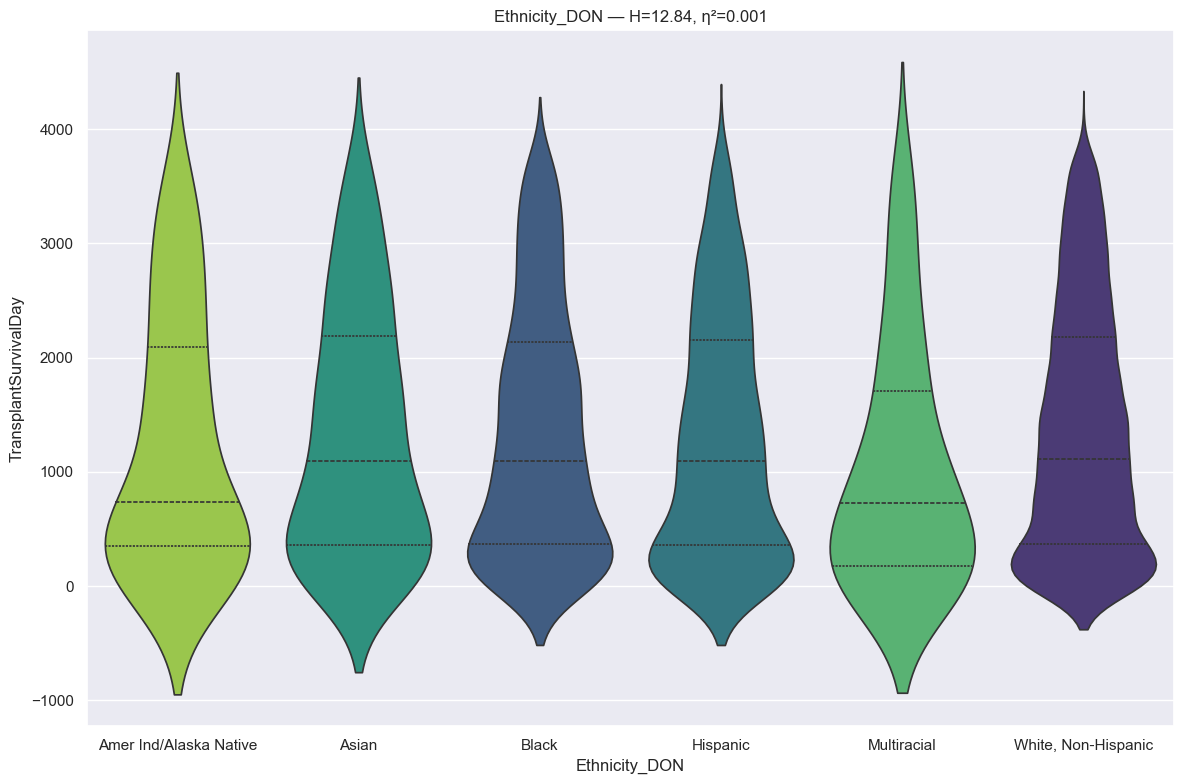

RANKING REPORT: Ethnicity_DON (n ≥ 30)
INCLUDED CATEGORIES:
 * Amer Ind/Alaska Native                            :     67 records
 * Asian                                             :    183 records
 * Black                                             :   1255 records
 * Hispanic                                          :   1120 records
 * Multiracial                                       :     58 records
 * White, Non-Hispanic                               :   5619 records
BYPASSED CATEGORIES (n < min_n):
 * Native Hawaiian/other Pacific Islander            :     17 records
--------------------------------------------------------------------------------
Kruskal H: 12.8436 | P-value: 2.488943e-02 | Effect η²: 0.0009
Correction Method: BONFERRONI
Pairwise Testing (Bonferroni Alpha: 0.0033 | r_threshold: 0.10)
--------------------------------------------------------------------------------
Multiracial  vs White, Non-Hispanic | p=7.6627e-03 | thr=0.0033 | r= 0.203 | Not Sig
Black        

In [43]:
# initialize variable
results = ranker.fit(df, features[0])
# mapping DataFrame
new_row = pd.DataFrame([ranker.build_feature_dict(results)])
mapping_df = pd.concat([mapping_df, new_row], ignore_index=True)

In [44]:
# mapping dictionary
print(results['mapping'])
mean_survival_by_category(df,features[0])

{'Amer Ind/Alaska Native': 'Group_1', 'Asian': 'Group_1', 'Black': 'Group_1', 'Hispanic': 'Group_1', 'White, Non-Hispanic': 'Group_1', 'Multiracial': 'Group_2', 'Native Hawaiian/other Pacific Islander': 'Other'}


,Ethnicity_DON,mean_survival_days,record_count
6,"White, Non-Hispanic",1355.482648,5619
2,Black,1337.445418,1255
3,Hispanic,1277.126786,1120
1,Asian,1323.316940,183
0,Amer Ind/Alaska Native,1216.656716,67
4,Multiracial,1023.551724,58
5,Native Hawaiian/other Pacific Islander,1474.529412,17


In [45]:
# instantiate class
ranker = NominalSurvivalRanker.NominalSurvivalRanker(
    method="fdr",  # bonferroni, Holm-Bonferroni (holm) Benjamini–Hochberg (fdr)
    r_thresh=0.10, # Lower r-threshold (strict merging)
    suppress_pairwise=True,
    plot=False
)
# initialize variable
results = ranker.fit(df, features[0])
# mapping DataFrame & remove last entry 
mapping_df = mapping_df[mapping_df["feature"] != features[0]]
new_row = pd.DataFrame([ranker.build_feature_dict(results)])
mapping_df = pd.concat([mapping_df, new_row], ignore_index=True)

RANKING REPORT: Ethnicity_DON (n ≥ 30)
INCLUDED CATEGORIES:
 * Amer Ind/Alaska Native                            :     67 records
 * Asian                                             :    183 records
 * Black                                             :   1255 records
 * Hispanic                                          :   1120 records
 * Multiracial                                       :     58 records
 * White, Non-Hispanic                               :   5619 records
BYPASSED CATEGORIES (n < min_n):
 * Native Hawaiian/other Pacific Islander            :     17 records
--------------------------------------------------------------------------------
Kruskal H: 12.8436 | P-value: 2.488943e-02 | Effect η²: 0.0009
Correction Method: FDR
Pairwise Testing (Base Alpha: 0.05 | Method: FDR | r_threshold: 0.10)
--------------------------------------------------------------------------------
[Pairwise comparison output suppressed]
::::: Collapsed into 2 groups (excluding 'Other') :::::



In [46]:
# mapping dictionary
print(results['mapping'])
mean_survival_by_category(df,features[0])

{'Amer Ind/Alaska Native': 'Group_1', 'Asian': 'Group_1', 'Black': 'Group_1', 'Hispanic': 'Group_1', 'White, Non-Hispanic': 'Group_1', 'Multiracial': 'Group_2', 'Native Hawaiian/other Pacific Islander': 'Other'}


,Ethnicity_DON,mean_survival_days,record_count
6,"White, Non-Hispanic",1355.482648,5619
2,Black,1337.445418,1255
3,Hispanic,1277.126786,1120
1,Asian,1323.316940,183
0,Amer Ind/Alaska Native,1216.656716,67
4,Multiracial,1023.551724,58
5,Native Hawaiian/other Pacific Islander,1474.529412,17


In [47]:
# mapping dictionary
collapse_map = results['mapping']
# New feature
df[features[0] + "_group"] = (
    df[features[0]]
    .map(collapse_map)
    .astype("category")
)
# add to remove list
remove_cols.extend(features)
# update feature with new name
mapping_df.loc[mapping_df["feature"].isin(features), "feature"] = mapping_df["feature"] + "_group"
# sanity check
df[features[0] + "_group"].isna().any()

np.False_

In [48]:
# mapping dictionary
print(results['mapping'])
mean_survival_by_category(df,features[0])

{'Amer Ind/Alaska Native': 'Group_1', 'Asian': 'Group_1', 'Black': 'Group_1', 'Hispanic': 'Group_1', 'White, Non-Hispanic': 'Group_1', 'Multiracial': 'Group_2', 'Native Hawaiian/other Pacific Islander': 'Other'}


,Ethnicity_DON,mean_survival_days,record_count
6,"White, Non-Hispanic",1355.482648,5619
2,Black,1337.445418,1255
3,Hispanic,1277.126786,1120
1,Asian,1323.316940,183
0,Amer Ind/Alaska Native,1216.656716,67
4,Multiracial,1023.551724,58
5,Native Hawaiian/other Pacific Islander,1474.529412,17


#### Hepatitis B Core Antibody

In [49]:
# info
features = u.get_feature_info(df, 'Hepatitis_B_CoreAntibody', cat=False)
# dtype
{col: df[col].dtype for col in features}

                             count unique       top  freq
Hepatitis_B_CoreAntibody_DON  8319      3  Negative  8138

:::: NaN Count:
Hepatitis_B_CoreAntibody_DON    0 



{'Hepatitis_B_CoreAntibody_DON': CategoricalDtype(categories=['Indeterminate', 'Negative', 'Not Done', 'Pending',
                   'Positive'],
 , ordered=False, categories_dtype=object)}

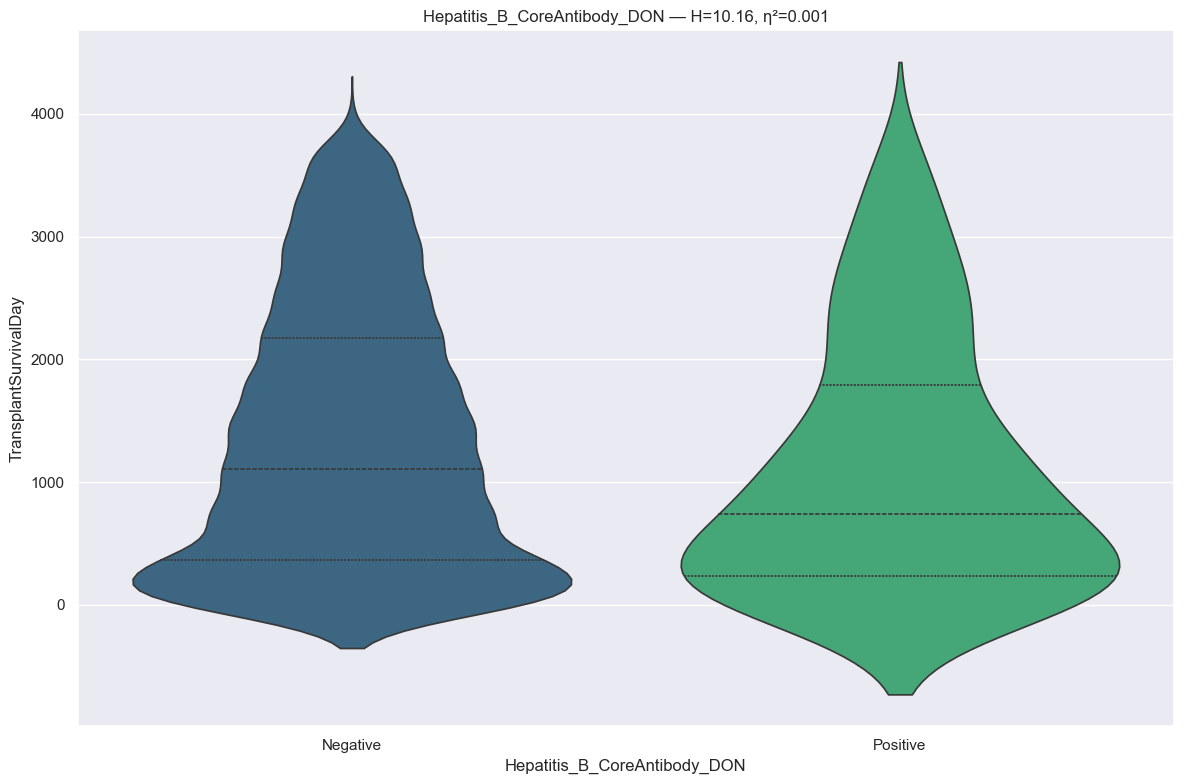

RANKING REPORT: Hepatitis_B_CoreAntibody_DON (n ≥ 30)
INCLUDED CATEGORIES:
 * Negative                                          :   8138 records
 * Positive                                          :    176 records
BYPASSED CATEGORIES (n < min_n):
 * Not Done                                          :      5 records
--------------------------------------------------------------------------------
Kruskal H: 10.1604 | P-value: 1.434856e-03 | Effect η²: 0.0011
Correction Method: BONFERRONI
Pairwise Testing (Bonferroni Alpha: 0.0500 | r_threshold: 0.05)
--------------------------------------------------------------------------------
Negative     vs Positive     | p=1.4349e-03 | thr=0.0500 | r=-0.140 | *Sig*
::::: Collapsed into 2 groups (excluding 'Other') :::::



In [50]:
# instantiate class
ranker = NominalSurvivalRanker.NominalSurvivalRanker(
    method="bonferroni",  # bonferroni, Holm-Bonferroni (holm) Benjamini–Hochberg (fdr)
    r_thresh=0.05,        # Lower r-threshold (strict merging)
)
# initialize variable
results = ranker.fit(df,features[0])
# mapping DataFrame
new_row = pd.DataFrame([ranker.build_feature_dict(results)])
mapping_df = pd.concat([mapping_df, new_row], ignore_index=True)

In [51]:
# mapping dictionary
print(results['mapping'])
mean_survival_by_category(df,features[0])

{'Negative': 'Group_1', 'Positive': 'Group_2', 'Not Done': 'Other'}


,Hepatitis_B_CoreAntibody_DON,mean_survival_days,record_count
0,Negative,1343.217498,8138
2,Positive,1111.545455,176
1,Not Done,1342.600000,5


#### Surface Antigen HEP B

In [52]:
# info
features = u.get_feature_info(df, 'SurfaceAntigenHEP_B', cat=False)
# dtype
{col: df[col].dtype for col in features}

                        count unique       top  freq
SurfaceAntigenHEP_B_DON  8319      4  Negative  8302

:::: NaN Count:
SurfaceAntigenHEP_B_DON    0 



{'SurfaceAntigenHEP_B_DON': CategoricalDtype(categories=['Indeterminate', 'Missing', 'Negative', 'Not Done',
                   'Positive'],
 , ordered=False, categories_dtype=object)}

In [53]:
# instantiate class
ranker = NominalSurvivalRanker.NominalSurvivalRanker(
    method="bonferroni",  # bonferroni, Holm-Bonferroni (holm) Benjamini–Hochberg (fdr)
    r_thresh=0.05,        # Lower r-threshold (strict merging)
    suppress_pairwise=True,
)
# initialize variable
results = ranker.fit(df, features[0])
# mapping DataFrame
new_row = pd.DataFrame([ranker.build_feature_dict(results)])
mapping_df = pd.concat([mapping_df, new_row], ignore_index=True)

[WARNING] Cannot perform statistical comparison for SurfaceAntigenHEP_B_DON
          Only 1 category has n ≥ 30.
          You can only compare MORE THAN ONE category since n < min_n.



In [54]:
# mapping dictionary
print(results['mapping'])
mean_survival_by_category(df, features[0])

{'Negative': 'Group_1'}


,SurfaceAntigenHEP_B_DON,mean_survival_days,record_count
1,Negative,1338.906288,8302
3,Positive,690.428571,7
2,Not Done,1151.000000,6
0,Missing,1527.500000,4


In [55]:
# mapping DataFrame & remove last entry 
mapping_df = mapping_df[mapping_df["feature"] != features[0]]
# add to remove list
remove_cols.extend(features)

##### **Note:** This feature does not have a statistically or practically significant impact on survival.

#### Blood Group

In [56]:
# info
features = u.get_feature_info(df, 'BloodGroup', cat=False)
# dtype
{col: df[col].dtype for col in features}

               count unique top  freq
BloodGroup_DON  8319      8   O  4401

:::: NaN Count:
BloodGroup_DON    0 



{'BloodGroup_DON': CategoricalDtype(categories=['A', 'A1', 'A1B', 'A2', 'A2B', 'AB', 'B', 'O'], ordered=False, categories_dtype=object)}

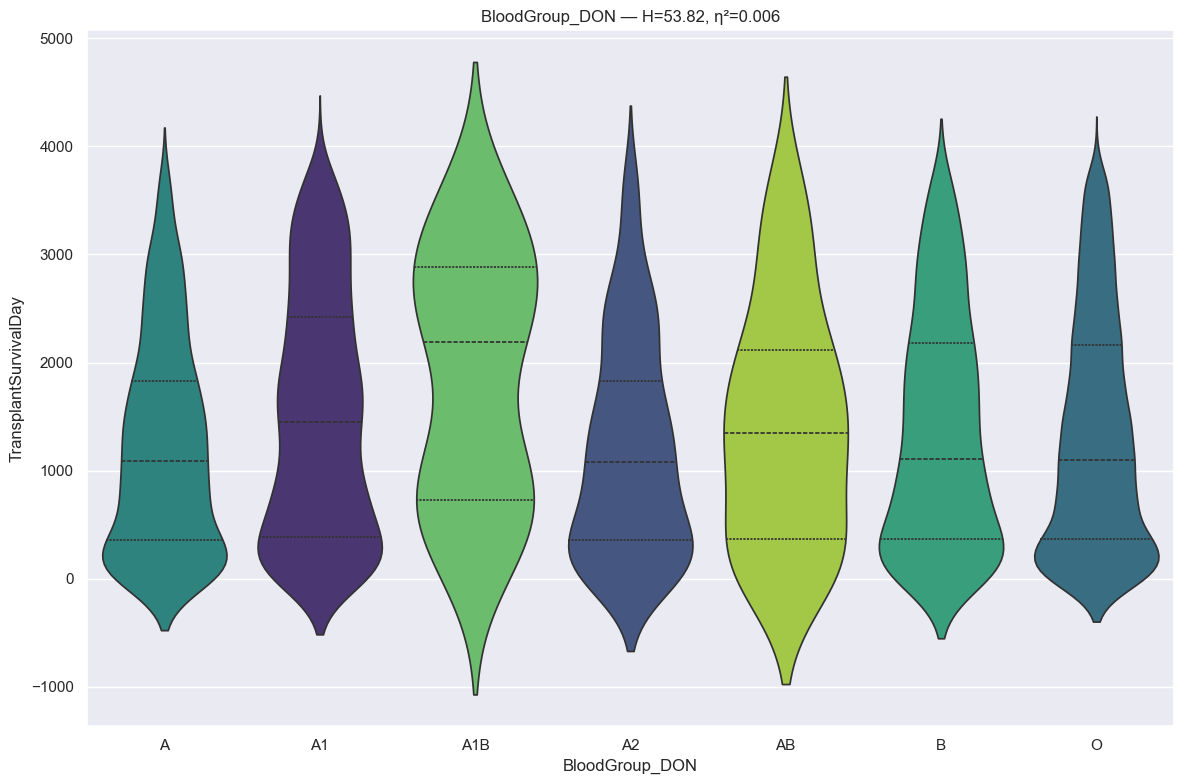

RANKING REPORT: BloodGroup_DON (n ≥ 30)
INCLUDED CATEGORIES:
 * A                                                 :   1186 records
 * A1                                                :   1526 records
 * A1B                                               :     37 records
 * A2                                                :    243 records
 * AB                                                :     57 records
 * B                                                 :    851 records
 * O                                                 :   4401 records
BYPASSED CATEGORIES (n < min_n):
 * A2B                                               :     18 records
--------------------------------------------------------------------------------
Kruskal H: 53.8218 | P-value: 8.013310e-10 | Effect η²: 0.0058
Correction Method: BONFERRONI
Pairwise Testing (Bonferroni Alpha: 0.0024 | r_threshold: 0.05)
--------------------------------------------------------------------------------
A            vs A1         

In [57]:
# instantiate class
ranker = NominalSurvivalRanker.NominalSurvivalRanker(
    method="bonferroni",  # bonferroni, Holm-Bonferroni (holm) Benjamini–Hochberg (fdr)
    r_thresh=0.05,        # Lower r-threshold (strict merging)
    suppress_pairwise=False,
)
# initialize variable
results = ranker.fit(df, features[0])
# mapping DataFrame
new_row = pd.DataFrame([ranker.build_feature_dict(results)])
mapping_df = pd.concat([mapping_df, new_row], ignore_index=True)

In [58]:
# mapping dictionary
print(results['mapping'])
mean_survival_by_category(df, features[0])

{'A': 'Group_1', 'A1': 'Group_1', 'A2': 'Group_1', 'AB': 'Group_1', 'B': 'Group_1', 'O': 'Group_1', 'A1B': 'Group_2', 'A2B': 'Other'}


,BloodGroup_DON,mean_survival_days,record_count
7,O,1313.409907,4401
1,A1,1495.245740,1526
0,A,1221.187184,1186
6,B,1363.200940,851
3,A2,1202.584362,243
5,AB,1422.508772,57
2,A1B,1851.621622,37
4,A2B,1175.222222,18


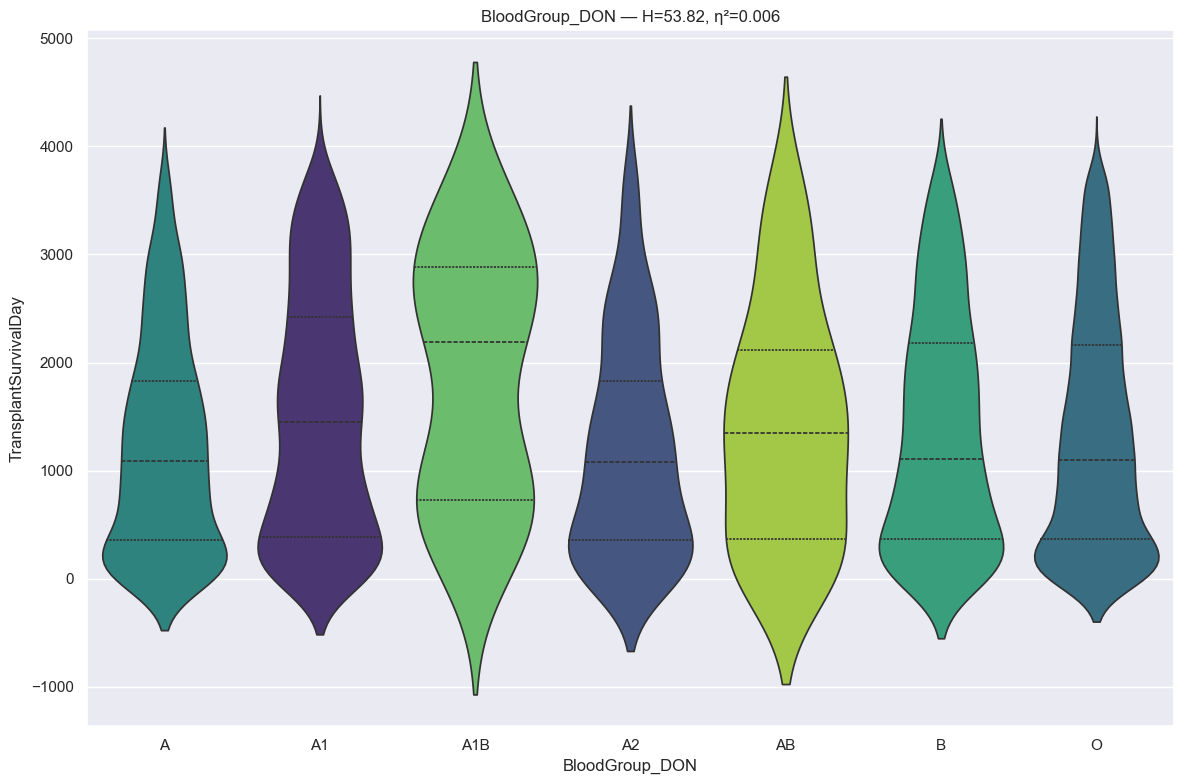

RANKING REPORT: BloodGroup_DON (n ≥ 30)
INCLUDED CATEGORIES:
 * A                                                 :   1186 records
 * A1                                                :   1526 records
 * A1B                                               :     37 records
 * A2                                                :    243 records
 * AB                                                :     57 records
 * B                                                 :    851 records
 * O                                                 :   4401 records
BYPASSED CATEGORIES (n < min_n):
 * A2B                                               :     18 records
--------------------------------------------------------------------------------
Kruskal H: 53.8218 | P-value: 8.013310e-10 | Effect η²: 0.0058
Correction Method: FDR
Pairwise Testing (Base Alpha: 0.05 | Method: FDR | r_threshold: 0.10)
--------------------------------------------------------------------------------
A            vs A1          

In [59]:
# FDR is the most relaxed
# instantiate class
ranker = NominalSurvivalRanker.NominalSurvivalRanker(
    method="fdr",         # bonferroni, Holm-Bonferroni (holm) Benjamini–Hochberg (fdr)
    r_thresh=0.10,        # Lower r-threshold (strict merging)
    suppress_pairwise=False,
)
# initialize variable
results = ranker.fit(df, features[0])
# mapping DataFrame & remove last entry 
mapping_df = mapping_df[mapping_df["feature"] != features[0]]
new_row = pd.DataFrame([ranker.build_feature_dict(results)])
mapping_df = pd.concat([mapping_df, new_row], ignore_index=True)

In [60]:
# mapping dictionary
print(results['mapping'])
mean_survival_by_category(df, features[0])

{'A': 'Group_1', 'A1': 'Group_1', 'A2': 'Group_1', 'AB': 'Group_1', 'B': 'Group_1', 'O': 'Group_1', 'A1B': 'Group_2', 'A2B': 'Other'}


,BloodGroup_DON,mean_survival_days,record_count
7,O,1313.409907,4401
1,A1,1495.245740,1526
0,A,1221.187184,1186
6,B,1363.200940,851
3,A2,1202.584362,243
5,AB,1422.508772,57
2,A1B,1851.621622,37
4,A2B,1175.222222,18


##### **Note:** Not going to collapse blood types since it is a very important part of transplant

#### Heavy Alcohol Use

In [61]:
# info
features = u.get_feature_info(df, 'HeavyAlcoholUse_DON', cat=False)
# dtype
{col: df[col].dtype for col in features}

                    count unique top  freq
HeavyAlcoholUse_DON  8319      4  No  7155

:::: NaN Count:
HeavyAlcoholUse_DON    0 



{'HeavyAlcoholUse_DON': CategoricalDtype(categories=['Missing', 'No', 'Unknown', 'Yes'], ordered=False, categories_dtype=object)}

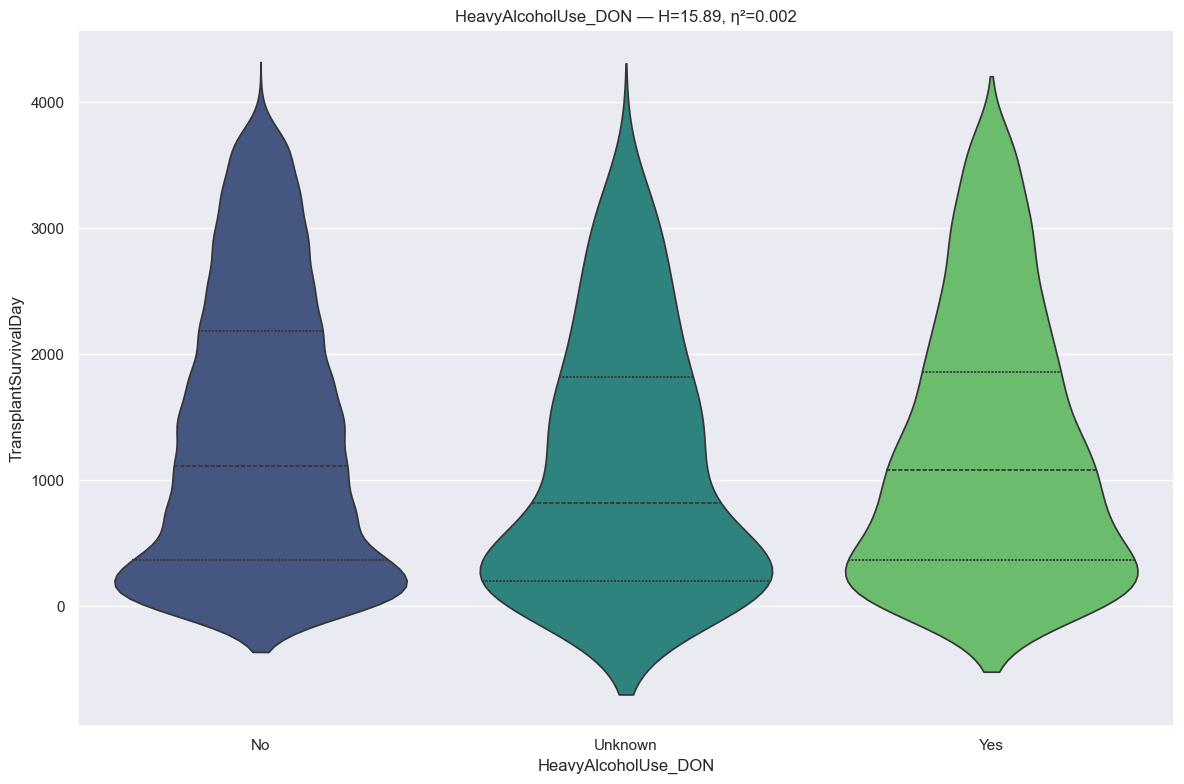

RANKING REPORT: HeavyAlcoholUse_DON (n ≥ 30)
INCLUDED CATEGORIES:
 * No                                                :   7155 records
 * Unknown                                           :    172 records
 * Yes                                               :    989 records
BYPASSED CATEGORIES (n < min_n):
 * Missing                                           :      3 records
--------------------------------------------------------------------------------
Kruskal H: 15.8876 | P-value: 3.548478e-04 | Effect η²: 0.0017
Correction Method: BONFERRONI
Pairwise Testing (Bonferroni Alpha: 0.0167 | r_threshold: 0.10)
--------------------------------------------------------------------------------
No           vs Unknown      | p=3.6770e-03 | thr=0.0167 | r=-0.129 | *Sig*
No           vs Yes          | p=4.0244e-03 | thr=0.0167 | r=-0.056 | *Sig*
Unknown      vs Yes          | p=1.1215e-01 | thr=0.0167 | r= 0.076 | Not Sig
::::: Collapsed into 2 groups (excluding 'Other') :::::



In [62]:
# instantiate class
ranker = NominalSurvivalRanker.NominalSurvivalRanker(
    method="bonferroni",  # bonferroni, Holm-Bonferroni (holm) Benjamini–Hochberg (fdr)
    r_thresh=0.10,        # Lower r-threshold (strict merging)
)
# initialize variable
results = ranker.fit(df, features[0])
# mapping DataFrame
new_row = pd.DataFrame([ranker.build_feature_dict(results)])
mapping_df = pd.concat([mapping_df, new_row], ignore_index=True)

In [63]:
# mapping dictionary
print(results['mapping'])
mean_survival_by_category(df, features[0])

{'No': 'Group_1', 'Unknown': 'Group_2', 'Yes': 'Group_2', 'Missing': 'Other'}


,HeavyAlcoholUse_DON,mean_survival_days,record_count
1,No,1356.111251,7155
3,Yes,1248.810920,989
2,Unknown,1109.918605,172
0,Missing,1497.666667,3


In [64]:
# Collapse Missing & Unknown into Other
# mapping
mapping = {'Unknown': 'Other',
           'Missing': 'Other'
          }
# map the change
df[features[0]] = (df[features[0]].map(mapping).fillna(df[features[0]]))
# sanity check
mean_survival_by_category(df,features[0])

,HeavyAlcoholUse_DON,mean_survival_days,record_count
0,No,1356.111251,7155
2,Yes,1248.810920,989
1,Other,1116.565714,175


#### Gender

In [65]:
# add to remove list
remove_cols.extend(['Gender_DON'])

#### Residency State

In [66]:
# info
features = u.get_feature_info(df, 'ResidencyState', cat=False)
# dtype
{col: df[col].dtype for col in features}

                   count unique top freq
ResidencyState_DON  8319     54  CA  755

:::: NaN Count:
ResidencyState_DON    0 



{'ResidencyState_DON': CategoricalDtype(categories=['AK', 'AL', 'AR', 'AS', 'AZ', 'CA', 'CO', 'CT', 'DC', 'DE',
                   'FL', 'GA', 'HI', 'IA', 'ID', 'IL', 'IN', 'KS', 'KY', 'LA',
                   'MA', 'MD', 'ME', 'MI', 'MN', 'MO', 'MS', 'MT', 'NC', 'ND',
                   'NE', 'NH', 'NJ', 'NM', 'NV', 'NY', 'OH', 'OK', 'OR', 'PA',
                   'PR', 'RI', 'SC', 'SD', 'TN', 'TX', 'UT', 'VA', 'VT', 'WA',
                   'WI', 'WV', 'WY', 'XX', 'ZZ'],
 , ordered=False, categories_dtype=object)}

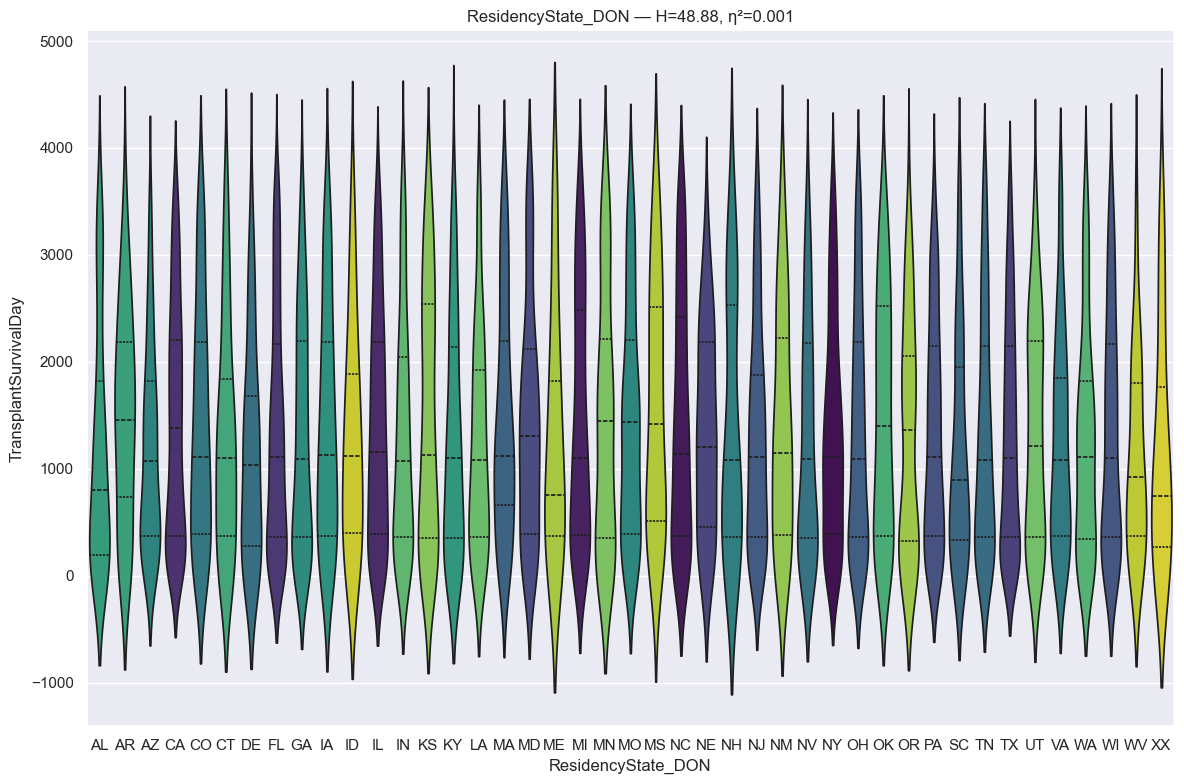

RANKING REPORT: ResidencyState_DON (n ≥ 30)
INCLUDED CATEGORIES:
 * AL                                                :    134 records
 * AR                                                :     58 records
 * AZ                                                :    196 records
 * CA                                                :    755 records
 * CO                                                :    133 records
 * CT                                                :     67 records
 * DE                                                :     59 records
 * FL                                                :    536 records
 * GA                                                :    278 records
 * IA                                                :     73 records
 * ID                                                :     42 records
 * IL                                                :    346 records
 * IN                                                :    217 records
 * KS                    

In [67]:
# instantiate class
ranker = NominalSurvivalRanker.NominalSurvivalRanker(
    method="bonferroni",  # bonferroni, Holm-Bonferroni (holm) Benjamini–Hochberg (fdr)
    r_thresh=0.10,        # Lower r-threshold (strict merging)
    suppress_pairwise=True,
)
# initialize variable
results = ranker.fit(df, features[0])
# mapping DataFrame
new_row = pd.DataFrame([ranker.build_feature_dict(results)])
mapping_df = pd.concat([mapping_df, new_row], ignore_index=True)

In [68]:
# instantiate class (more relaxed)
ranker = NominalSurvivalRanker.NominalSurvivalRanker(
    method="fdr",         # bonferroni, Holm-Bonferroni (holm), Benjamini–Hochberg (fdr)
    r_thresh=0.05,        # Lower r-threshold (strict merging)
    suppress_pairwise=True,
    plot=False
)
# initialize variable
results = ranker.fit(df, features[0])
# mapping DataFrame & remove last entry 
mapping_df = mapping_df[mapping_df["feature"] != features[0]]
new_row = pd.DataFrame([ranker.build_feature_dict(results)])
mapping_df = pd.concat([mapping_df, new_row], ignore_index=True)

RANKING REPORT: ResidencyState_DON (n ≥ 30)
INCLUDED CATEGORIES:
 * AL                                                :    134 records
 * AR                                                :     58 records
 * AZ                                                :    196 records
 * CA                                                :    755 records
 * CO                                                :    133 records
 * CT                                                :     67 records
 * DE                                                :     59 records
 * FL                                                :    536 records
 * GA                                                :    278 records
 * IA                                                :     73 records
 * ID                                                :     42 records
 * IL                                                :    346 records
 * IN                                                :    217 records
 * KS                    

In [69]:
results['pairwise'][0]

{'cat1': 'AL',
 'cat2': 'AR',
 'p_raw': np.float64(0.03425133897505175),
 'r': np.float64(0.19274318064848173),
 'p_adj': np.float64(0.7478936798733494),
 'sig': False}

In [70]:
# check any true value
sum(d['sig'] for d in results['pairwise'])

0

In [71]:
# mapping DataFrame & remove last entry 
mapping_df = mapping_df[mapping_df["feature"] != features[0]]
# add to remove list
remove_cols.extend(features)

##### **Note:** Non‑significant Global Kruskal–Wallis across all categories suggests there is no evidence that any Residency State category differs in survival distribution, confirmed by the pairwise testing, therefore no splitting is justified.

#### Antibody HEP C

In [72]:
# info
features = u.get_feature_info(df, 'Antibody_HEP_C', cat=False)
# dtype
{col: df[col].dtype for col in features}

                   count unique       top  freq
Antibody_HEP_C_DON  8319      4  Negative  7872

:::: NaN Count:
Antibody_HEP_C_DON    0 



{'Antibody_HEP_C_DON': CategoricalDtype(categories=['Indeterminate', 'Missing', 'Negative', 'Not Done',
                   'Pending', 'Positive'],
 , ordered=False, categories_dtype=object)}

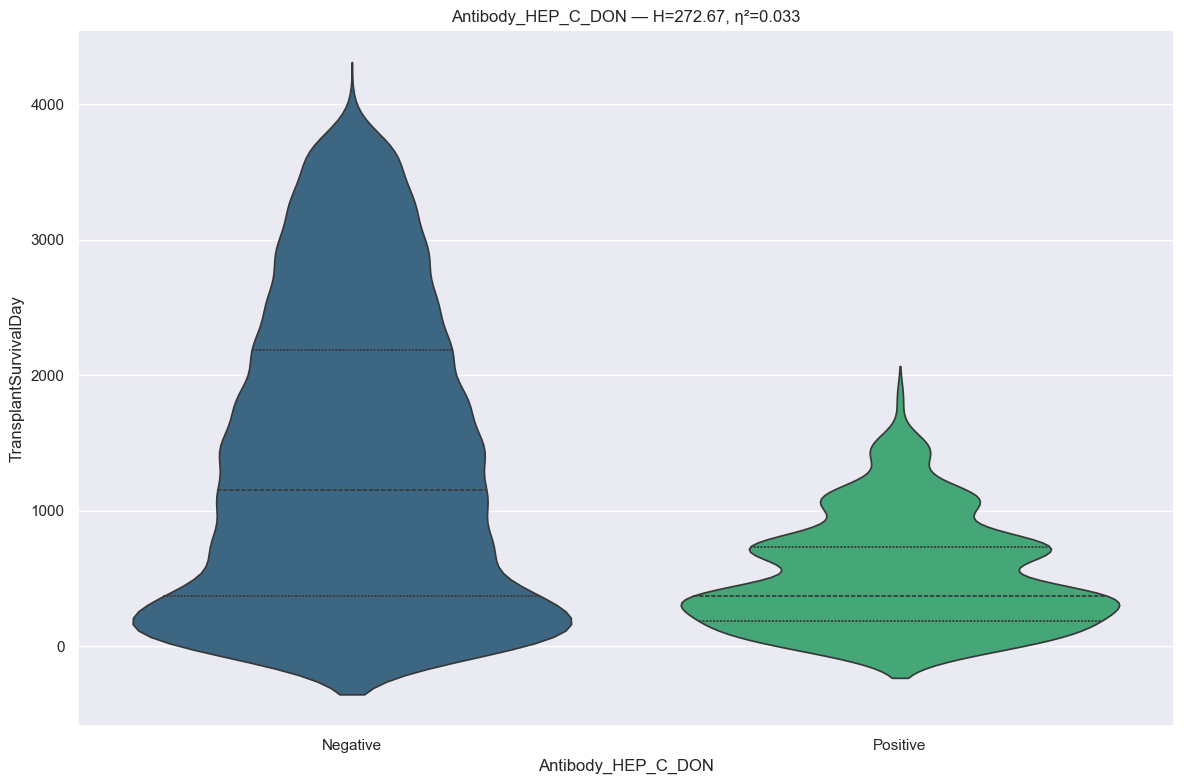

RANKING REPORT: Antibody_HEP_C_DON (n ≥ 30)
INCLUDED CATEGORIES:
 * Negative                                          :   7872 records
 * Positive                                          :    445 records
BYPASSED CATEGORIES (n < min_n):
 * Missing                                           :      1 records
 * Not Done                                          :      1 records
--------------------------------------------------------------------------------
Kruskal H: 272.6704 | P-value: 2.971138e-61 | Effect η²: 0.0327
Correction Method: BONFERRONI
Pairwise Testing (Bonferroni Alpha: 0.0500 | r_threshold: 0.10)
--------------------------------------------------------------------------------
Negative     vs Positive     | p=2.9716e-61 | thr=0.0500 | r=-0.465 | *Sig*
::::: Collapsed into 2 groups (excluding 'Other') :::::



In [73]:
# instantiate class
ranker = NominalSurvivalRanker.NominalSurvivalRanker(
    method="bonferroni",  # bonferroni, Holm-Bonferroni (holm) Benjamini–Hochberg (fdr)
    r_thresh=0.10,        # Lower r-threshold (strict merging)
)
# initialize variable
results = ranker.fit(df, features[0])
# mapping DataFrame
new_row = pd.DataFrame([ranker.build_feature_dict(results)])
mapping_df = pd.concat([mapping_df, new_row], ignore_index=True)

In [74]:
# mapping dictionary
print(results['mapping'])
mean_survival_by_category(df, features[0])

{'Negative': 'Group_1', 'Positive': 'Group_2', 'Missing': 'Other', 'Not Done': 'Other'}


,Antibody_HEP_C_DON,mean_survival_days,record_count
1,Negative,1384.468496,7872
3,Positive,520.739326,445
0,Missing,1827.000000,1
2,Not Done,1357.000000,1


In [75]:
# mapping (small sample size)
mapping = {'Missing': 'Other',
           'Not Done': 'Other'
          }
# map the change
df[features[0]] = df[features[0]].map(mapping).fillna(df[features[0]])
# sanity check
mean_survival_by_category(df, features[0])

,Antibody_HEP_C_DON,mean_survival_days,record_count
0,Negative,1384.468496,7872
2,Positive,520.739326,445
1,Other,1592.000000,2


#### Non Heart Beating

In [76]:
# info
features = u.get_feature_info(df, 'NonHeartBeating', cat=False)
# dtype
{col: df[col].dtype for col in features}

                    count unique top  freq
NonHeartBeating_DON  8319      3  No  8282

:::: NaN Count:
NonHeartBeating_DON    0 



{'NonHeartBeating_DON': CategoricalDtype(categories=['Missing', 'No', 'Yes'], ordered=False, categories_dtype=object)}

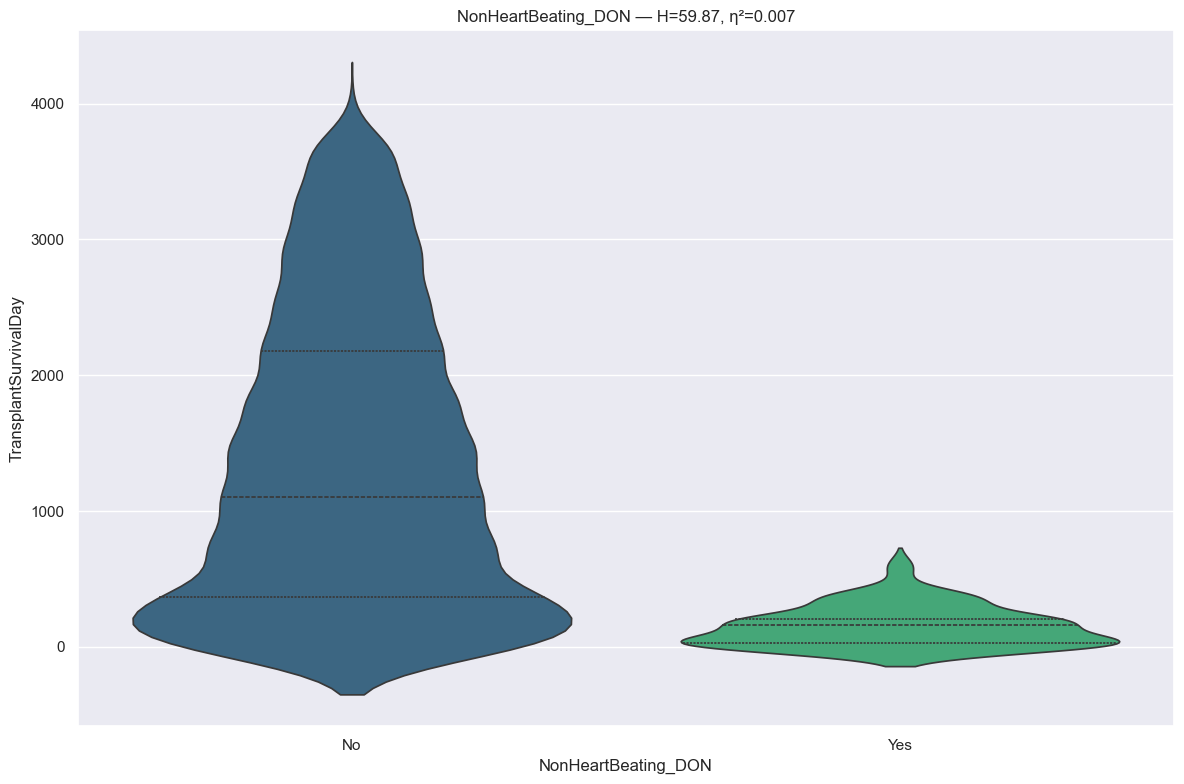

RANKING REPORT: NonHeartBeating_DON (n ≥ 30)
INCLUDED CATEGORIES:
 * No                                                :   8282 records
 * Yes                                               :     36 records
BYPASSED CATEGORIES (n < min_n):
 * Missing                                           :      1 records
--------------------------------------------------------------------------------
Kruskal H: 59.8740 | P-value: 1.011273e-14 | Effect η²: 0.0071
Correction Method: BONFERRONI
Pairwise Testing (Bonferroni Alpha: 0.0500 | r_threshold: 0.10)
--------------------------------------------------------------------------------
No           vs Yes          | p=1.0115e-14 | thr=0.0500 | r=-0.746 | *Sig*
::::: Collapsed into 2 groups (excluding 'Other') :::::



In [77]:
# instantiate class
ranker = NominalSurvivalRanker.NominalSurvivalRanker(
    method="bonferroni",  # bonferroni, Holm-Bonferroni (holm) Benjamini–Hochberg (fdr)
    r_thresh=0.10,        # Lower r-threshold (strict merging)
)
# initialize variable
results = ranker.fit(df, features[0])
# mapping DataFrame
new_row = pd.DataFrame([ranker.build_feature_dict(results)])
mapping_df = pd.concat([mapping_df, new_row], ignore_index=True)

In [78]:
# mapping dictionary
print(results['mapping'])
mean_survival_by_category(df, features[0])

{'No': 'Group_1', 'Yes': 'Group_2', 'Missing': 'Other'}


,NonHeartBeating_DON,mean_survival_days,record_count
1,No,1343.416566,8282
2,Yes,151.277778,36
0,Missing,1827.000000,1


#### Anti Hypertensive

In [79]:
# info
features = u.get_feature_info(df, 'AntiHypertensive_DON', cat=False)
# dtype
{col: df[col].dtype for col in features}

                     count unique top  freq
AntiHypertensive_DON  8319      4  No  5506

:::: NaN Count:
AntiHypertensive_DON    0 



{'AntiHypertensive_DON': CategoricalDtype(categories=['Missing', 'No', 'Unknown', 'Yes'], ordered=False, categories_dtype=object)}

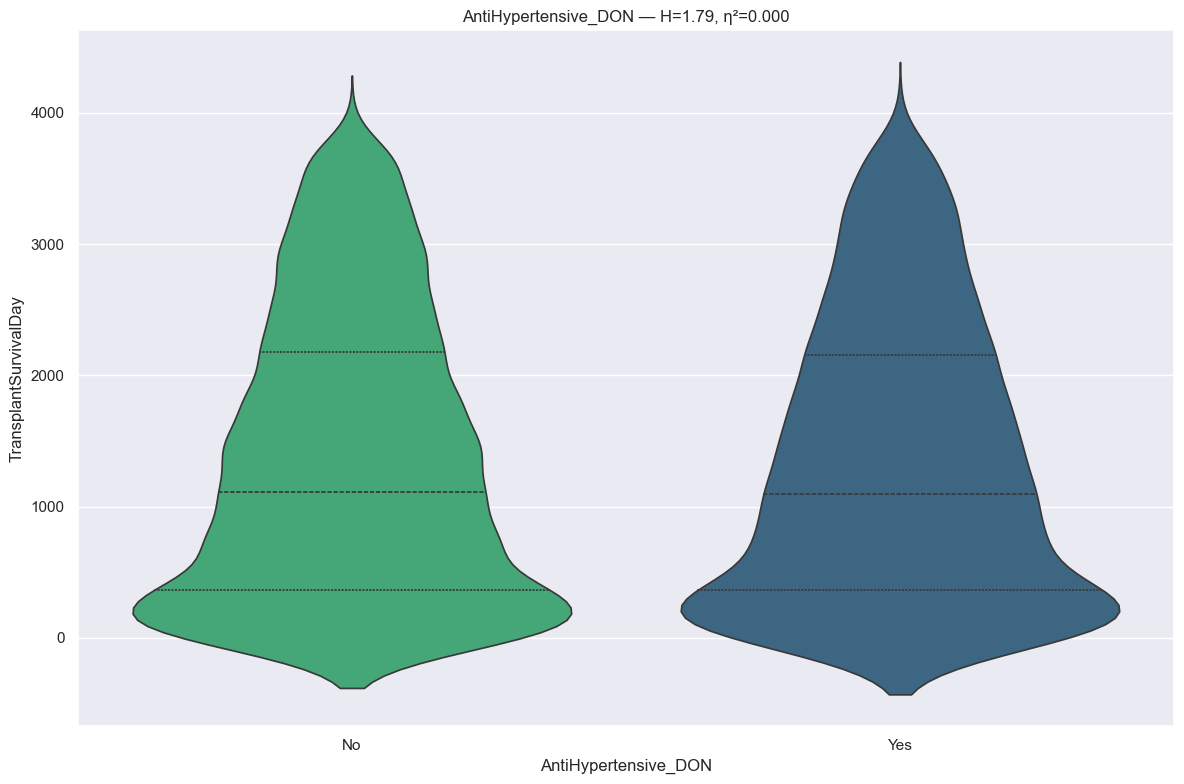

RANKING REPORT: AntiHypertensive_DON (n ≥ 30)
INCLUDED CATEGORIES:
 * No                                                :   5506 records
 * Yes                                               :   2797 records
BYPASSED CATEGORIES (n < min_n):
 * Missing                                           :     14 records
 * Unknown                                           :      2 records
--------------------------------------------------------------------------------
Kruskal H: 1.7881 | P-value: 1.811546e-01 | Effect η²: 0.0001
Correction Method: BONFERRONI
Pairwise Testing (Bonferroni Alpha: 0.0500 | r_threshold: 0.10)
--------------------------------------------------------------------------------
No           vs Yes          | p=1.8116e-01 | thr=0.0500 | r=-0.018 | Not Sig
::::: Collapsed into 1 groups (excluding 'Other') :::::



In [80]:
# instantiate class
ranker = NominalSurvivalRanker.NominalSurvivalRanker(
    method="bonferroni",  # bonferroni, Holm-Bonferroni (holm) Benjamini–Hochberg (fdr)
    r_thresh=0.10,        # Lower r-threshold (strict merging)
)
# initialize variable
results = ranker.fit(df, features[0])
# mapping DataFrame
new_row = pd.DataFrame([ranker.build_feature_dict(results)])
mapping_df = pd.concat([mapping_df, new_row], ignore_index=True)

In [81]:
# mapping dictionary
print(results['mapping'])
mean_survival_by_category(df, features[0])

{'No': 'Group_1', 'Yes': 'Group_1', 'Missing': 'Other', 'Unknown': 'Other'}


,AntiHypertensive_DON,mean_survival_days,record_count
1,No,1350.936978,5506
3,Yes,1314.400072,2797
0,Missing,1034.000000,14
2,Unknown,2168.500000,2


In [82]:
# mapping (Unknown & Missing consolidate: sample size)
mapping = {'Unknown': 'Other',
           'Missing': 'Other'
          }
# map the change
df[features[0]] = df[features[0]].map(mapping).fillna(df[features[0]])
# sanity check
mean_survival_by_category(df, features[0])

,AntiHypertensive_DON,mean_survival_days,record_count
0,No,1350.936978,5506
2,Yes,1314.400072,2797
1,Other,1175.812500,16


#### Blood Infection Source

In [83]:
# info
features = u.get_feature_info(df, 'BloodInfectionSource', cat=False)
# dtype
{col: df[col].dtype for col in features}

                         count unique top  freq
BloodInfectionSource_DON  8319      3  No  7471

:::: NaN Count:
BloodInfectionSource_DON    0 



{'BloodInfectionSource_DON': CategoricalDtype(categories=['Missing', 'No', 'Yes'], ordered=False, categories_dtype=object)}

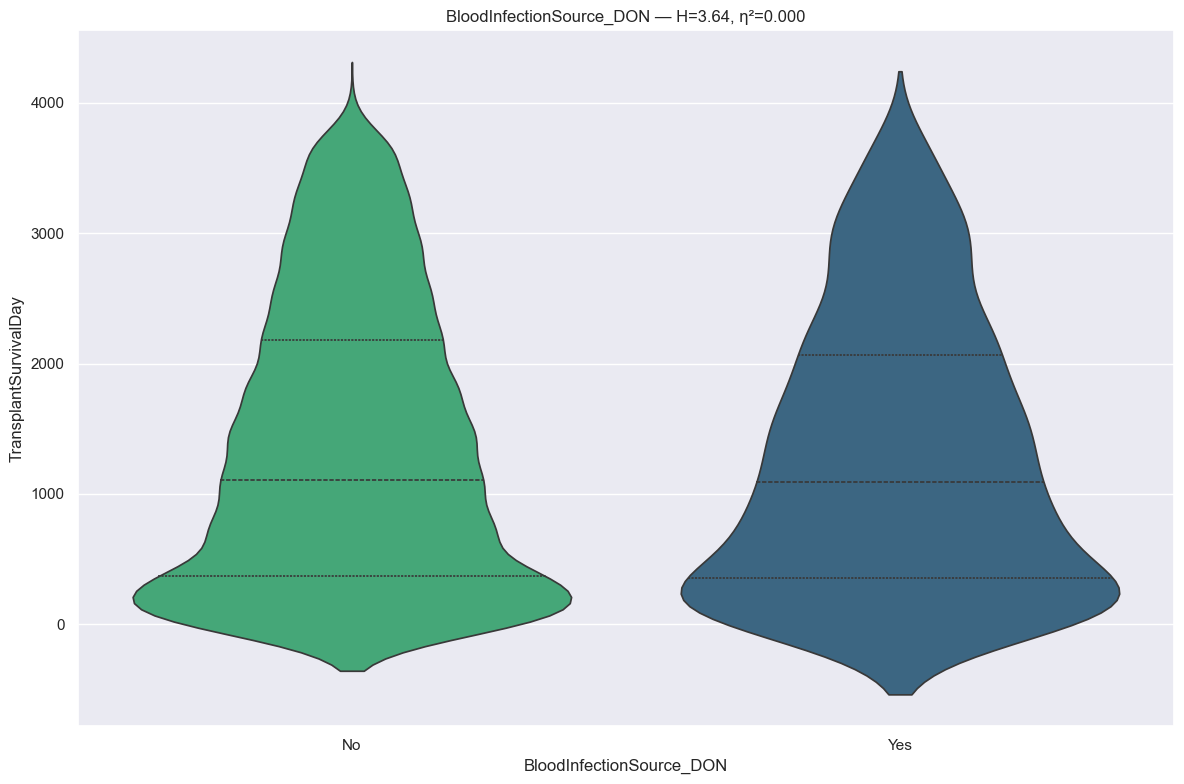

RANKING REPORT: BloodInfectionSource_DON (n ≥ 30)
INCLUDED CATEGORIES:
 * No                                                :   7471 records
 * Yes                                               :    847 records
BYPASSED CATEGORIES (n < min_n):
 * Missing                                           :      1 records
--------------------------------------------------------------------------------
Kruskal H: 3.6373 | P-value: 5.649835e-02 | Effect η²: 0.0003
Correction Method: BONFERRONI
Pairwise Testing (Bonferroni Alpha: 0.0500 | r_threshold: 0.10)
--------------------------------------------------------------------------------
No           vs Yes          | p=5.6499e-02 | thr=0.0500 | r=-0.040 | Not Sig
::::: Collapsed into 1 groups (excluding 'Other') :::::



In [84]:
# instantiate class
ranker = NominalSurvivalRanker.NominalSurvivalRanker(
    method="bonferroni",  # bonferroni, Holm-Bonferroni (holm) Benjamini–Hochberg (fdr)
    r_thresh=0.10,        # Lower r-threshold (strict merging)
)
# initialize variable
results = ranker.fit(df, features[0])
# mapping DataFrame
new_row = pd.DataFrame([ranker.build_feature_dict(results)])
mapping_df = pd.concat([mapping_df, new_row], ignore_index=True)

In [85]:
# mapping dictionary
print(results['mapping'])
mean_survival_by_category(df, features[0])

{'No': 'Group_1', 'Yes': 'Group_1', 'Missing': 'Other'}


,BloodInfectionSource_DON,mean_survival_days,record_count
1,No,1346.293133,7471
2,Yes,1267.374262,847
0,Missing,1827.000000,1


#### OtherInfectionSource_DON

In [86]:
# info
features = u.get_feature_info(df, 'OtherInfectionSource', cat=False)
# dtype
{col: df[col].dtype for col in features}

                         count unique top  freq
OtherInfectionSource_DON  8319      3  No  5743

:::: NaN Count:
OtherInfectionSource_DON    0 



{'OtherInfectionSource_DON': CategoricalDtype(categories=['Missing', 'No', 'Yes'], ordered=False, categories_dtype=object)}

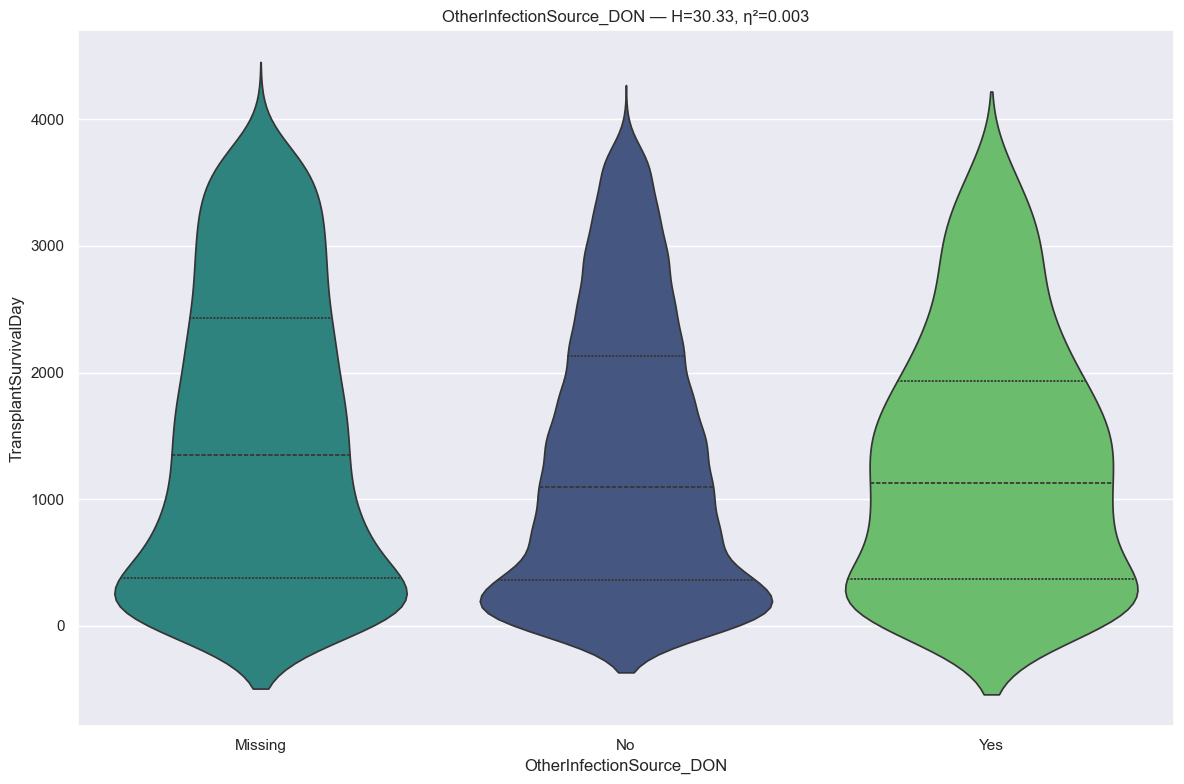

RANKING REPORT: OtherInfectionSource_DON (n ≥ 30)
INCLUDED CATEGORIES:
 * Missing                                           :   1930 records
 * No                                                :   5743 records
 * Yes                                               :    646 records
BYPASSED CATEGORIES: None
--------------------------------------------------------------------------------
Kruskal H: 30.3284 | P-value: 2.595780e-07 | Effect η²: 0.0034
Correction Method: BONFERRONI
Pairwise Testing (Bonferroni Alpha: 0.0167 | r_threshold: 0.10)
--------------------------------------------------------------------------------
Missing      vs No           | p=4.2467e-08 | thr=0.0167 | r=-0.083 | *Sig*
Missing      vs Yes          | p=9.5194e-03 | thr=0.0167 | r=-0.068 | *Sig*
No           vs Yes          | p=3.9625e-01 | thr=0.0167 | r= 0.020 | Not Sig
::::: Collapsed into 2 groups (excluding 'Other') :::::



In [87]:
# instantiate class
ranker = NominalSurvivalRanker.NominalSurvivalRanker(
    method="bonferroni",  # bonferroni, Holm-Bonferroni (holm) Benjamini–Hochberg (fdr)
    r_thresh=0.10,        # Lower r-threshold (strict merging)
)
# initialize variable
results = ranker.fit(df, features[0])
# mapping DataFrame
new_row = pd.DataFrame([ranker.build_feature_dict(results)])
mapping_df = pd.concat([mapping_df, new_row], ignore_index=True)

In [88]:
# mapping dictionary
print(results['mapping'])
mean_survival_by_category(df, features[0])

{'Missing': 'Group_1', 'No': 'Group_2', 'Yes': 'Group_2'}


,OtherInfectionSource_DON,mean_survival_days,record_count
1,No,1296.731499,5743
0,Missing,1471.043523,1930
2,Yes,1311.464396,646


#### Diuretics

In [89]:
# info
features = u.get_feature_info(df, 'Diuretics', cat=False)
# dtype
{col: df[col].dtype for col in features}

              count unique  top  freq
Diuretics_DON  8319      4  Yes  5909

:::: NaN Count:
Diuretics_DON    0 



{'Diuretics_DON': CategoricalDtype(categories=['Missing', 'No', 'Unknown', 'Yes'], ordered=False, categories_dtype=object)}

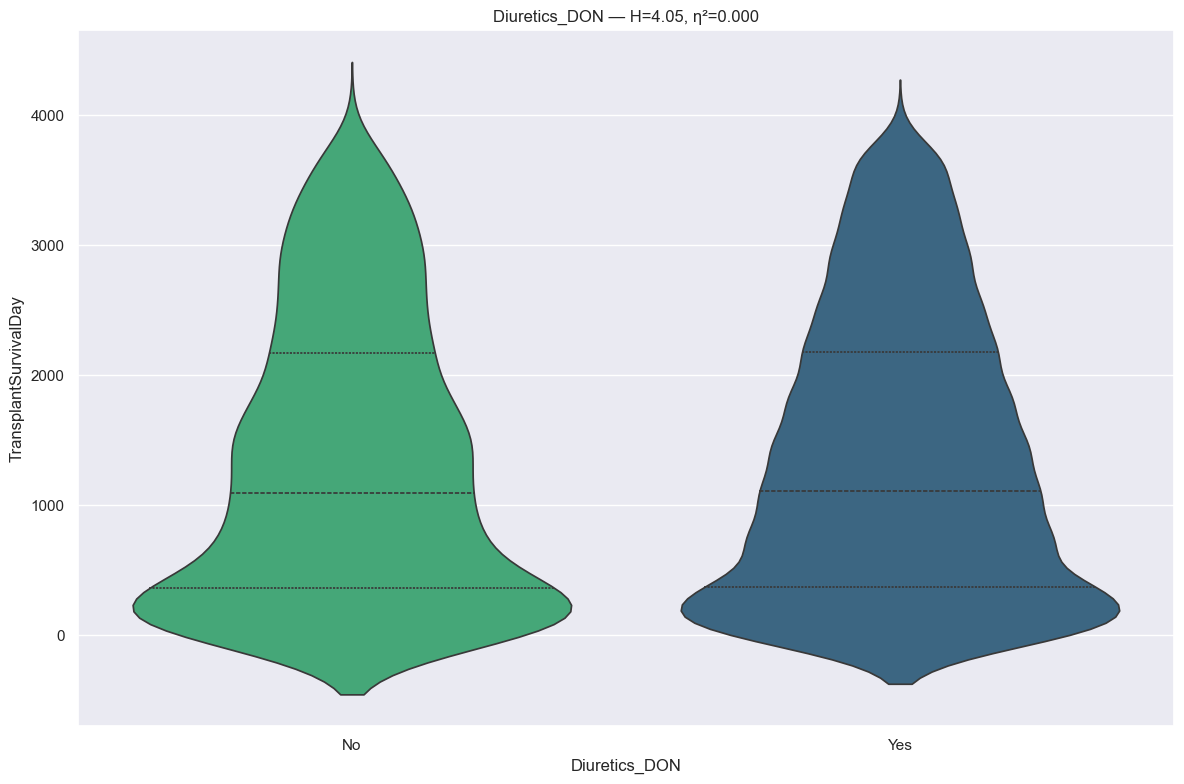

RANKING REPORT: Diuretics_DON (n ≥ 30)
INCLUDED CATEGORIES:
 * No                                                :   2394 records
 * Yes                                               :   5909 records
BYPASSED CATEGORIES (n < min_n):
 * Missing                                           :     14 records
 * Unknown                                           :      2 records
--------------------------------------------------------------------------------
Kruskal H: 4.0539 | P-value: 4.406898e-02 | Effect η²: 0.0004
Correction Method: BONFERRONI
Pairwise Testing (Bonferroni Alpha: 0.0500 | r_threshold: 0.10)
--------------------------------------------------------------------------------
No           vs Yes          | p=4.4070e-02 | thr=0.0500 | r= 0.028 | *Sig*
::::: Collapsed into 2 groups (excluding 'Other') :::::



In [90]:
# instantiate class
ranker = NominalSurvivalRanker.NominalSurvivalRanker(
    method="bonferroni",  # bonferroni, Holm-Bonferroni (holm) Benjamini–Hochberg (fdr)
    r_thresh=0.10,        # Lower r-threshold (strict merging)
)
# initialize variable
results = ranker.fit(df, features[0])
# mapping DataFrame
new_row = pd.DataFrame([ranker.build_feature_dict(results)])
mapping_df = pd.concat([mapping_df, new_row], ignore_index=True)

In [91]:
# mapping dictionary
print(results['mapping'])
mean_survival_by_category(df, features[0])

{'No': 'Group_1', 'Yes': 'Group_2', 'Missing': 'Other', 'Unknown': 'Other'}


,Diuretics_DON,mean_survival_days,record_count
3,Yes,1351.262142,5909
1,No,1307.911445,2394
0,Missing,1034.000000,14
2,Unknown,1612.500000,2


In [92]:
# mapping (Unknown & Missing consolidate: sample size)
mapping = {'Unknown': 'Other',
           'Missing': 'Other'
          }
# map the change
df[features[0]] = df[features[0]].map(mapping).fillna(df[features[0]])
# sanity check
mean_survival_by_category(df, features[0])

,Diuretics_DON,mean_survival_days,record_count
2,Yes,1351.262142,5909
0,No,1307.911445,2394
1,Other,1106.312500,16


#### Steroids Use

In [93]:
# info
features = u.get_feature_info(df, 'SteroidsUse', cat=False)
# dtype
{col: df[col].dtype for col in features}

                count unique  top  freq
SteroidsUse_DON  8319      4  Yes  5936

:::: NaN Count:
SteroidsUse_DON    0 



{'SteroidsUse_DON': CategoricalDtype(categories=['Missing', 'No', 'Unknown', 'Yes'], ordered=False, categories_dtype=object)}

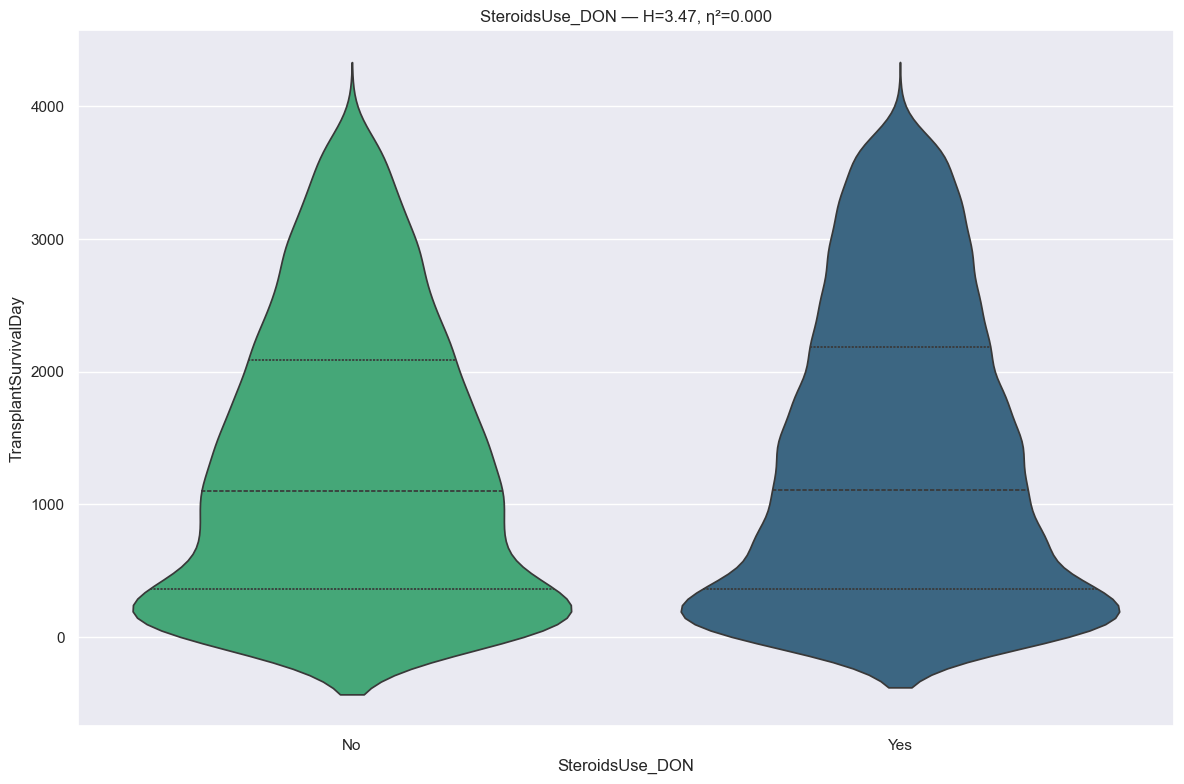

RANKING REPORT: SteroidsUse_DON (n ≥ 30)
INCLUDED CATEGORIES:
 * No                                                :   2359 records
 * Yes                                               :   5936 records
BYPASSED CATEGORIES (n < min_n):
 * Missing                                           :     14 records
 * Unknown                                           :     10 records
--------------------------------------------------------------------------------
Kruskal H: 3.4733 | P-value: 6.236494e-02 | Effect η²: 0.0003
Correction Method: BONFERRONI
Pairwise Testing (Bonferroni Alpha: 0.0500 | r_threshold: 0.10)
--------------------------------------------------------------------------------
No           vs Yes          | p=6.2366e-02 | thr=0.0500 | r= 0.026 | Not Sig
::::: Collapsed into 1 groups (excluding 'Other') :::::



In [94]:
# instantiate class
ranker = NominalSurvivalRanker.NominalSurvivalRanker(
    method="bonferroni",  # bonferroni, Holm-Bonferroni (holm) Benjamini–Hochberg (fdr)
    r_thresh=0.10,        # Lower r-threshold (strict merging)
)
# initialize variable
results = ranker.fit(df, features[0])
# mapping DataFrame
new_row = pd.DataFrame([ranker.build_feature_dict(results)])
mapping_df = pd.concat([mapping_df, new_row], ignore_index=True)

In [95]:
# mapping dictionary
print(results['mapping'])
mean_survival_by_category(df, features[0])

{'No': 'Group_1', 'Yes': 'Group_1', 'Missing': 'Other', 'Unknown': 'Other'}


,SteroidsUse_DON,mean_survival_days,record_count
3,Yes,1356.291947,5936
1,No,1294.309453,2359
0,Missing,1034.000000,14
2,Unknown,1474.800000,10


In [96]:
# mapping (Unknown & Missing consolidate: sample size)
mapping = {'Unknown': 'Other',
           'Missing': 'Other'
          }
# map the change
df[features[0]] = df[features[0]].map(mapping).fillna(df[features[0]])
# sanity check
mean_survival_by_category(df, features[0])

,SteroidsUse_DON,mean_survival_days,record_count
2,Yes,1356.291947,5936
0,No,1294.309453,2359
1,Other,1217.666667,24


#### Triiodothyronine T3

In [97]:
# info
features = u.get_feature_info(df, 'TriiodothyronineT3', cat=False)
# dtype
{col: df[col].dtype for col in features}

                       count unique top  freq
TriiodothyronineT3_DON  8319      4  No  8268

:::: NaN Count:
TriiodothyronineT3_DON    0 



{'TriiodothyronineT3_DON': CategoricalDtype(categories=['Missing', 'No', 'Unknown', 'Yes'], ordered=False, categories_dtype=object)}

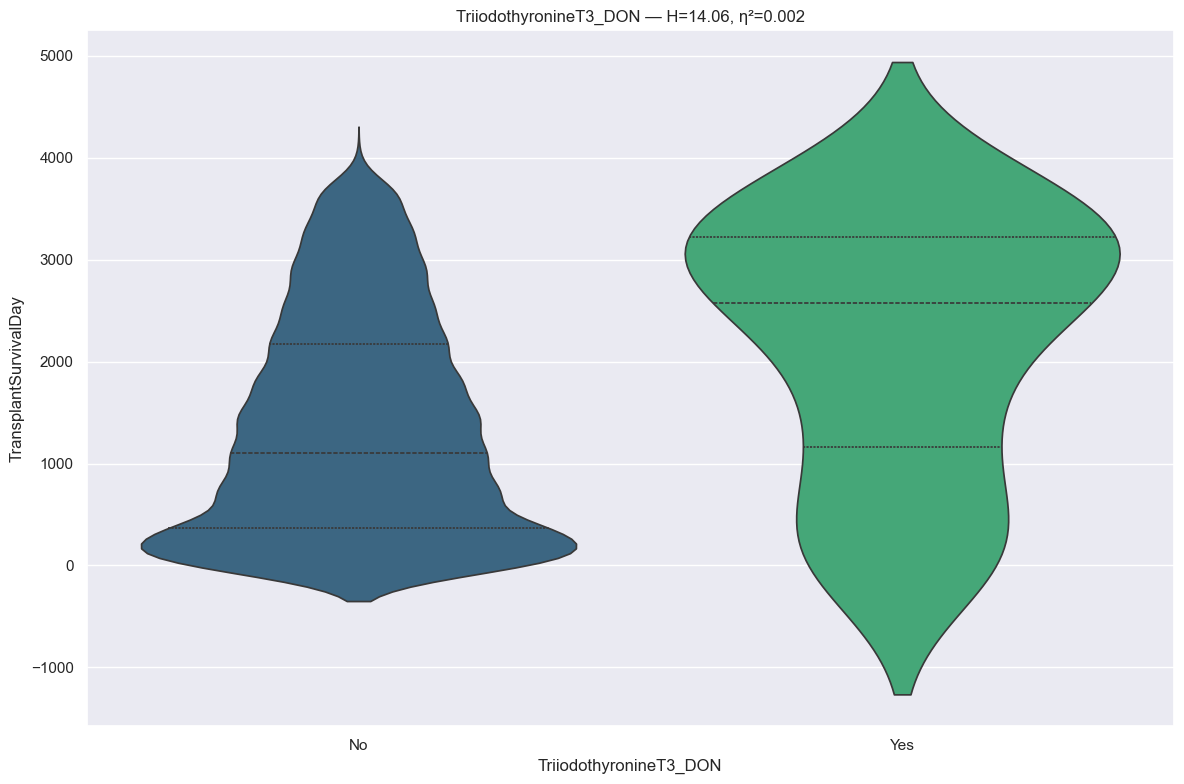

RANKING REPORT: TriiodothyronineT3_DON (n ≥ 30)
INCLUDED CATEGORIES:
 * No                                                :   8268 records
 * Yes                                               :     34 records
BYPASSED CATEGORIES (n < min_n):
 * Missing                                           :     14 records
 * Unknown                                           :      3 records
--------------------------------------------------------------------------------
Kruskal H: 14.0631 | P-value: 1.767824e-04 | Effect η²: 0.0016
Correction Method: BONFERRONI
Pairwise Testing (Bonferroni Alpha: 0.0500 | r_threshold: 0.10)
--------------------------------------------------------------------------------
No           vs Yes          | p=1.7681e-04 | thr=0.0500 | r= 0.372 | *Sig*
::::: Collapsed into 2 groups (excluding 'Other') :::::



In [98]:
# instantiate class
ranker = NominalSurvivalRanker.NominalSurvivalRanker(
    method="bonferroni",  # bonferroni, Holm-Bonferroni (holm) Benjamini–Hochberg (fdr)
    r_thresh=0.10,        # Lower r-threshold (strict merging)
)
# initialize variable
results = ranker.fit(df, features[0])
# mapping DataFrame
new_row = pd.DataFrame([ranker.build_feature_dict(results)])
mapping_df = pd.concat([mapping_df, new_row], ignore_index=True)

In [99]:
# mapping dictionary
print(results['mapping'])
mean_survival_by_category(df, features[0])

{'No': 'Group_1', 'Yes': 'Group_2', 'Missing': 'Other', 'Unknown': 'Other'}


,TriiodothyronineT3_DON,mean_survival_days,record_count
1,No,1335.160498,8268
3,Yes,2169.323529,34
0,Missing,1034.000000,14
2,Unknown,2036.333333,3


In [100]:
# mapping (Unknown & Missing consolidate: sample size)
mapping = {'Unknown': 'Other',
           'Missing': 'Other'
          }
# map the change
df[features[0]] = df[features[0]].map(mapping).fillna(df[features[0]])
# sanity check
mean_survival_by_category(df, features[0])

,TriiodothyronineT3_DON,mean_survival_days,record_count
0,No,1335.160498,8268
2,Yes,2169.323529,34
1,Other,1210.882353,17


#### Thyroxine T4

In [101]:
# info
features = u.get_feature_info(df, 'ThyroxineT4', cat=False)
# dtype
{col: df[col].dtype for col in features}

                count unique  top  freq
ThyroxineT4_DON  8319      4  Yes  5351

:::: NaN Count:
ThyroxineT4_DON    0 



{'ThyroxineT4_DON': CategoricalDtype(categories=['Missing', 'No', 'Unknown', 'Yes'], ordered=False, categories_dtype=object)}

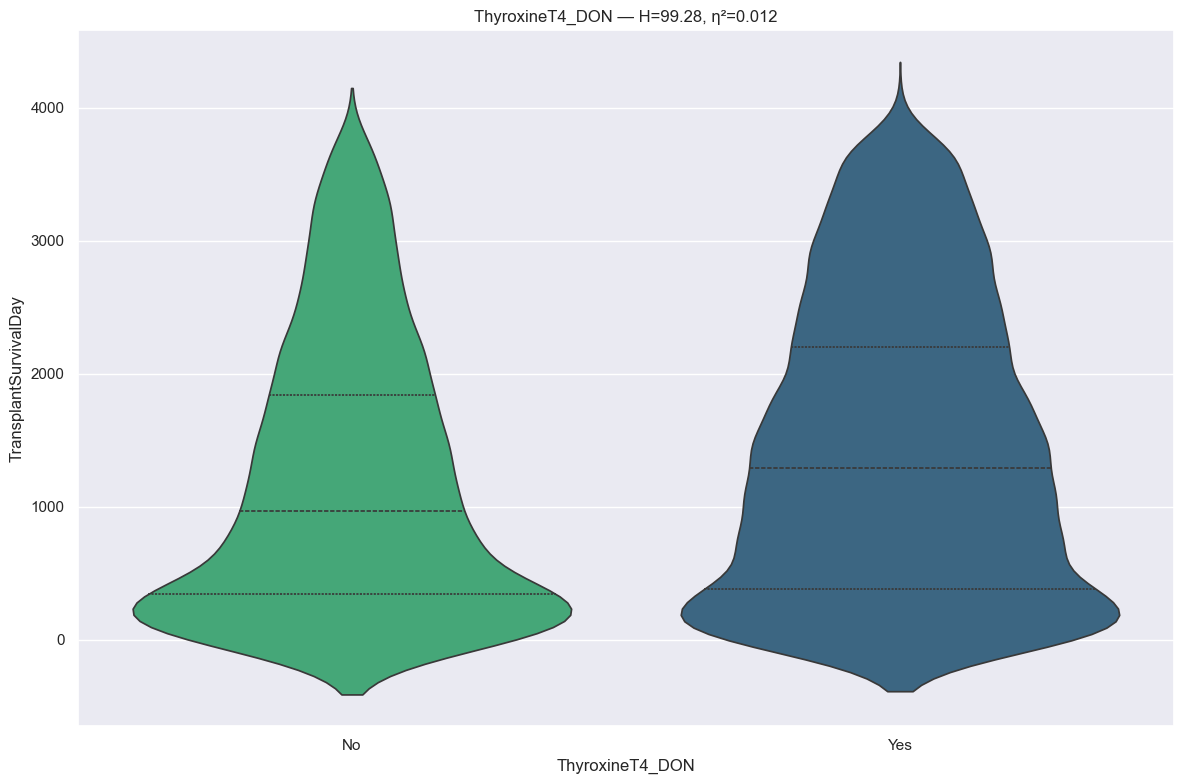

RANKING REPORT: ThyroxineT4_DON (n ≥ 30)
INCLUDED CATEGORIES:
 * No                                                :   2952 records
 * Yes                                               :   5351 records
BYPASSED CATEGORIES (n < min_n):
 * Missing                                           :     14 records
 * Unknown                                           :      2 records
--------------------------------------------------------------------------------
Kruskal H: 99.2832 | P-value: 2.188563e-23 | Effect η²: 0.0118
Correction Method: BONFERRONI
Pairwise Testing (Bonferroni Alpha: 0.0500 | r_threshold: 0.10)
--------------------------------------------------------------------------------
No           vs Yes          | p=2.1887e-23 | thr=0.0500 | r= 0.132 | *Sig*
::::: Collapsed into 2 groups (excluding 'Other') :::::



In [102]:
# instantiate class
ranker = NominalSurvivalRanker.NominalSurvivalRanker(
    method="bonferroni",  # bonferroni, Holm-Bonferroni (holm) Benjamini–Hochberg (fdr)
    r_thresh=0.10,        # Lower r-threshold (strict merging)
)
# initialize variable
results = ranker.fit(df, features[0])
# mapping DataFrame
new_row = pd.DataFrame([ranker.build_feature_dict(results)])
mapping_df = pd.concat([mapping_df, new_row], ignore_index=True)

In [103]:
# mapping dictionary
print(results['mapping'])
mean_survival_by_category(df, features[0])

{'No': 'Group_1', 'Yes': 'Group_2', 'Missing': 'Other', 'Unknown': 'Other'}


,ThyroxineT4_DON,mean_survival_days,record_count
3,Yes,1426.294151,5351
1,No,1179.720867,2952
0,Missing,1034.000000,14
2,Unknown,2168.500000,2


In [104]:
# mapping (Unknown & Missing consolidate: sample size)
mapping = {'Unknown': 'Other',
           'Missing': 'Other'
          }
# map the change
df[features[0]] = df[features[0]].map(mapping).fillna(df[features[0]])
# sanity check
mean_survival_by_category(df, features[0])

,ThyroxineT4_DON,mean_survival_days,record_count
2,Yes,1426.294151,5351
0,No,1179.720867,2952
1,Other,1175.812500,16


#### Pulmonary Infection

In [105]:
# info
features = u.get_feature_info(df, 'PulmonaryInfection', cat=False)
# dtype
{col: df[col].dtype for col in features}

                       count unique  top  freq
PulmonaryInfection_DON  8319      3  Yes  5564

:::: NaN Count:
PulmonaryInfection_DON    0 



{'PulmonaryInfection_DON': CategoricalDtype(categories=['Missing', 'No', 'Yes'], ordered=False, categories_dtype=object)}

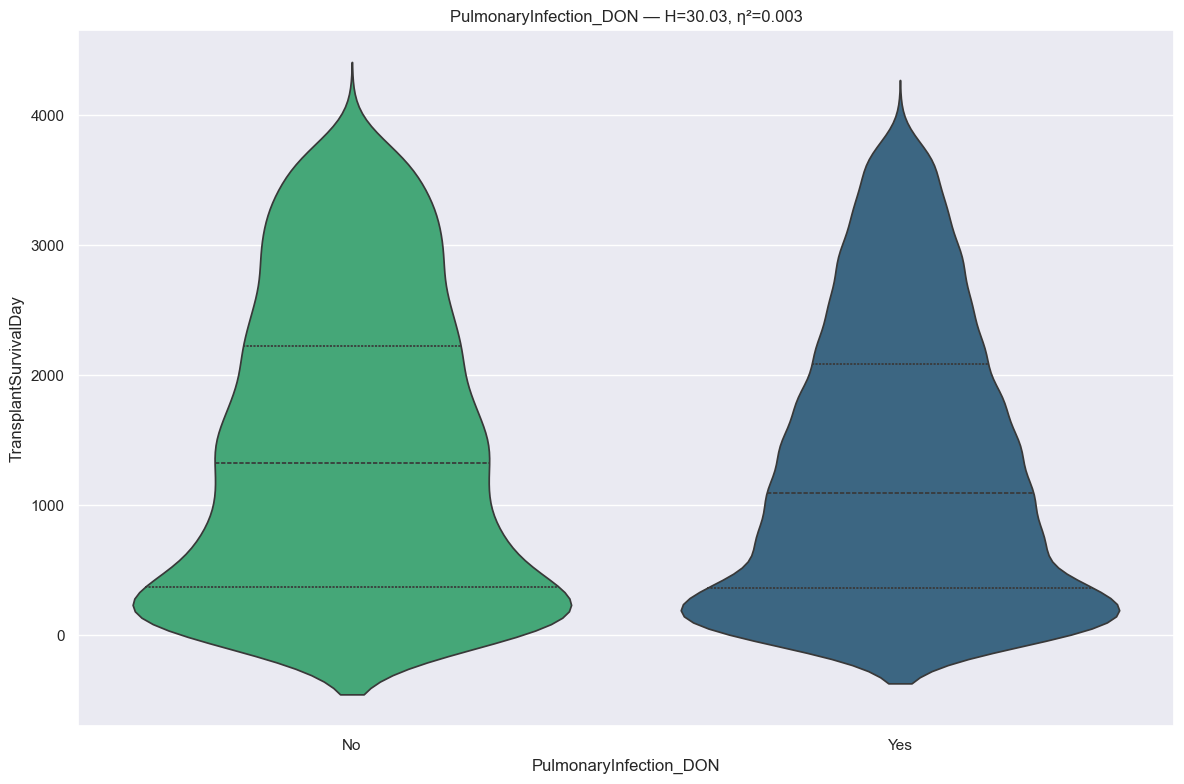

RANKING REPORT: PulmonaryInfection_DON (n ≥ 30)
INCLUDED CATEGORIES:
 * No                                                :   2754 records
 * Yes                                               :   5564 records
BYPASSED CATEGORIES (n < min_n):
 * Missing                                           :      1 records
--------------------------------------------------------------------------------
Kruskal H: 30.0313 | P-value: 4.251273e-08 | Effect η²: 0.0035
Correction Method: BONFERRONI
Pairwise Testing (Bonferroni Alpha: 0.0500 | r_threshold: 0.10)
--------------------------------------------------------------------------------
No           vs Yes          | p=4.2514e-08 | thr=0.0500 | r=-0.074 | *Sig*
::::: Collapsed into 2 groups (excluding 'Other') :::::



In [106]:
# instantiate class
ranker = NominalSurvivalRanker.NominalSurvivalRanker(
    method="bonferroni",  # bonferroni, Holm-Bonferroni (holm) Benjamini–Hochberg (fdr)
    r_thresh=0.10,        # Lower r-threshold (strict merging)
)
# initialize variable
results = ranker.fit(df, features[0])
# mapping DataFrame
new_row = pd.DataFrame([ranker.build_feature_dict(results)])
mapping_df = pd.concat([mapping_df, new_row], ignore_index=True)

In [107]:
# mapping dictionary
print(results['mapping'])
mean_survival_by_category(df, features[0])

{'No': 'Group_1', 'Yes': 'Group_2', 'Missing': 'Other'}


,PulmonaryInfection_DON,mean_survival_days,record_count
2,Yes,1288.392344,5564
1,No,1439.000363,2754
0,Missing,1827.000000,1


#### Urine Infection

In [108]:
# info
features = u.get_feature_info(df, 'UrineInfection', cat=False)
# dtype
{col: df[col].dtype for col in features}

                   count unique top  freq
UrineInfection_DON  8319      3  No  6211

:::: NaN Count:
UrineInfection_DON    0 



{'UrineInfection_DON': CategoricalDtype(categories=['Missing', 'No', 'Yes'], ordered=False, categories_dtype=object)}

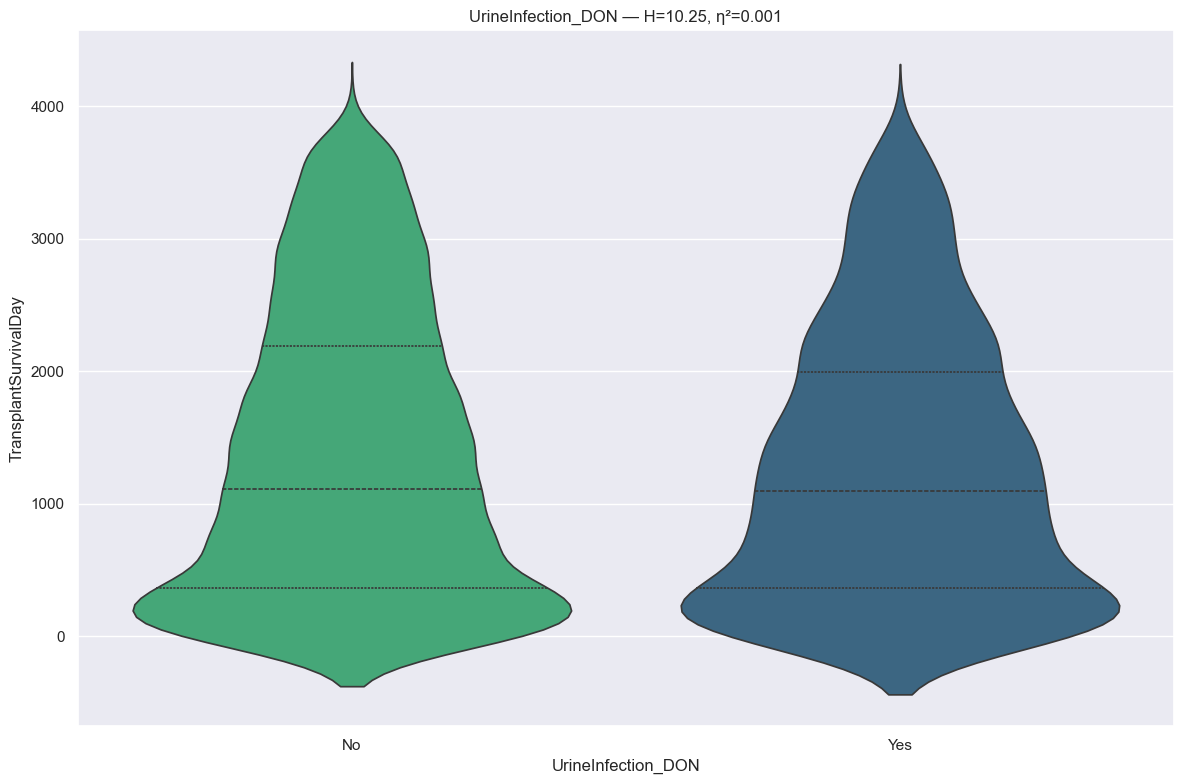

RANKING REPORT: UrineInfection_DON (n ≥ 30)
INCLUDED CATEGORIES:
 * No                                                :   6211 records
 * Yes                                               :   2107 records
BYPASSED CATEGORIES (n < min_n):
 * Missing                                           :      1 records
--------------------------------------------------------------------------------
Kruskal H: 10.2458 | P-value: 1.369935e-03 | Effect η²: 0.0011
Correction Method: BONFERRONI
Pairwise Testing (Bonferroni Alpha: 0.0500 | r_threshold: 0.10)
--------------------------------------------------------------------------------
No           vs Yes          | p=1.3700e-03 | thr=0.0500 | r=-0.047 | *Sig*
::::: Collapsed into 2 groups (excluding 'Other') :::::



In [109]:
# instantiate class
ranker = NominalSurvivalRanker.NominalSurvivalRanker(
    method="bonferroni",  # bonferroni, Holm-Bonferroni (holm) Benjamini–Hochberg (fdr)
    r_thresh=0.10,        # Lower r-threshold (strict merging)
)
# initialize variable
results = ranker.fit(df, features[0])
# mapping DataFrame
new_row = pd.DataFrame([ranker.build_feature_dict(results)])
mapping_df = pd.concat([mapping_df, new_row], ignore_index=True)

In [110]:
# mapping dictionary
print(results['mapping'])
mean_survival_by_category(df, features[0])

{'No': 'Group_1', 'Yes': 'Group_2', 'Missing': 'Other'}


,UrineInfection_DON,mean_survival_days,record_count
1,No,1363.939623,6211
2,Yes,1262.550071,2107
0,Missing,1827.000000,1


#### Vasodilators

In [111]:
# info
features = u.get_feature_info(df, 'Vasodilators', cat=False)
# dtype
{col: df[col].dtype for col in features}

                 count unique top  freq
Vasodilators_DON  8319      4  No  6944

:::: NaN Count:
Vasodilators_DON    0 



{'Vasodilators_DON': CategoricalDtype(categories=['Missing', 'No', 'Unknown', 'Yes'], ordered=False, categories_dtype=object)}

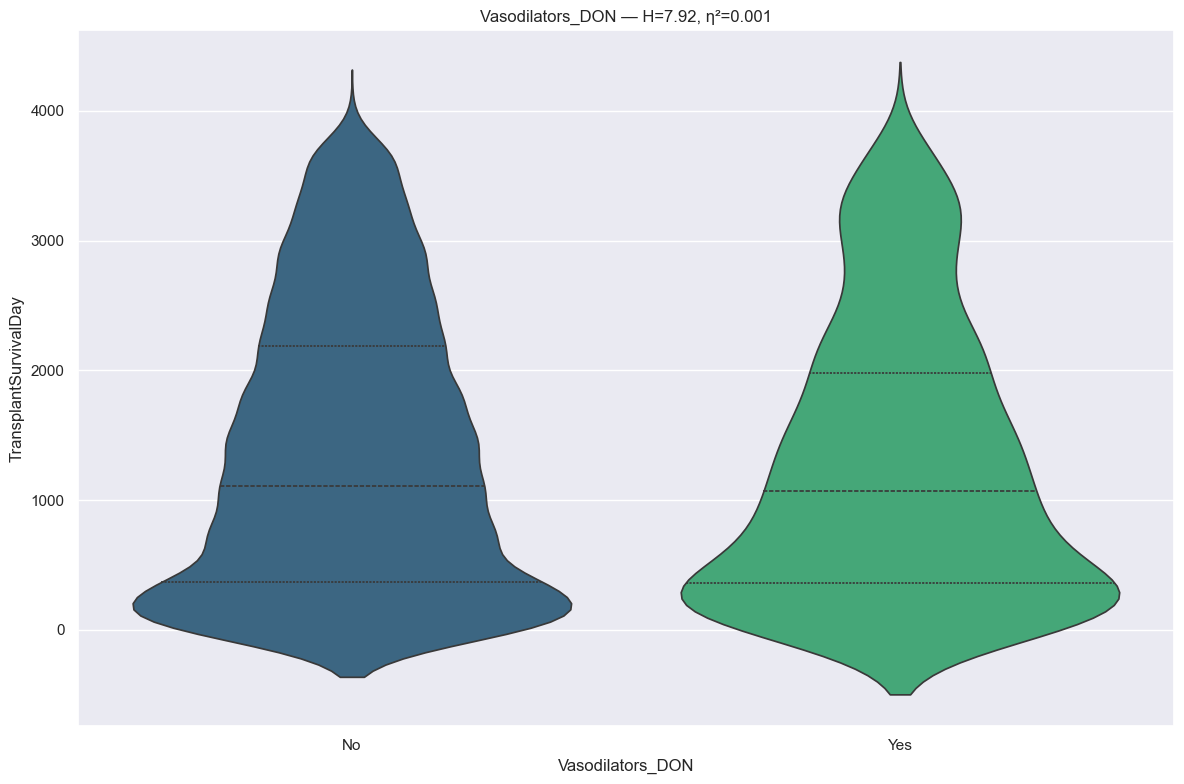

RANKING REPORT: Vasodilators_DON (n ≥ 30)
INCLUDED CATEGORIES:
 * No                                                :   6944 records
 * Yes                                               :   1357 records
BYPASSED CATEGORIES (n < min_n):
 * Missing                                           :     14 records
 * Unknown                                           :      4 records
--------------------------------------------------------------------------------
Kruskal H: 7.9208 | P-value: 4.886913e-03 | Effect η²: 0.0008
Correction Method: BONFERRONI
Pairwise Testing (Bonferroni Alpha: 0.0500 | r_threshold: 0.10)
--------------------------------------------------------------------------------
No           vs Yes          | p=4.8870e-03 | thr=0.0500 | r=-0.048 | *Sig*
::::: Collapsed into 2 groups (excluding 'Other') :::::



In [112]:
# instantiate class
ranker = NominalSurvivalRanker.NominalSurvivalRanker(
    method="bonferroni",  # bonferroni, Holm-Bonferroni (holm) Benjamini–Hochberg (fdr)
    r_thresh=0.10,        # Lower r-threshold (strict merging)
)
# initialize variable
results = ranker.fit(df, features[0])
# mapping DataFrame
new_row = pd.DataFrame([ranker.build_feature_dict(results)])
mapping_df = pd.concat([mapping_df, new_row], ignore_index=True)

In [113]:
# mapping dictionary
print(results['mapping'])
mean_survival_by_category(df, features[0])

{'No': 'Group_1', 'Yes': 'Group_2', 'Missing': 'Other', 'Unknown': 'Other'}


,Vasodilators_DON,mean_survival_days,record_count
1,No,1353.245392,6944
3,Yes,1261.509948,1357
0,Missing,1034.000000,14
2,Unknown,2542.000000,4


In [114]:
# mapping (Unknown & Missing consolidate: sample size)
mapping = {'Unknown': 'Other',
           'Missing': 'Other'
          }
# map the change
df[features[0]] = df[features[0]].map(mapping).fillna(df[features[0]])
# sanity check
mean_survival_by_category(df, features[0])

,Vasodilators_DON,mean_survival_days,record_count
0,No,1353.245392,6944
2,Yes,1261.509948,1357
1,Other,1369.111111,18


#### Antibody Result RPR VDRL

In [115]:
# info
features = u.get_feature_info(df, 'AntibodyResultRPR_VDRL', cat=False)
# dtype
{col: df[col].dtype for col in features}

                           count unique       top  freq
AntibodyResultRPR_VDRL_DON  8319      4  Negative  8077

:::: NaN Count:
AntibodyResultRPR_VDRL_DON    0 



{'AntibodyResultRPR_VDRL_DON': CategoricalDtype(categories=['Missing', 'Negative', 'Not Done', 'Positive'], ordered=False, categories_dtype=object)}

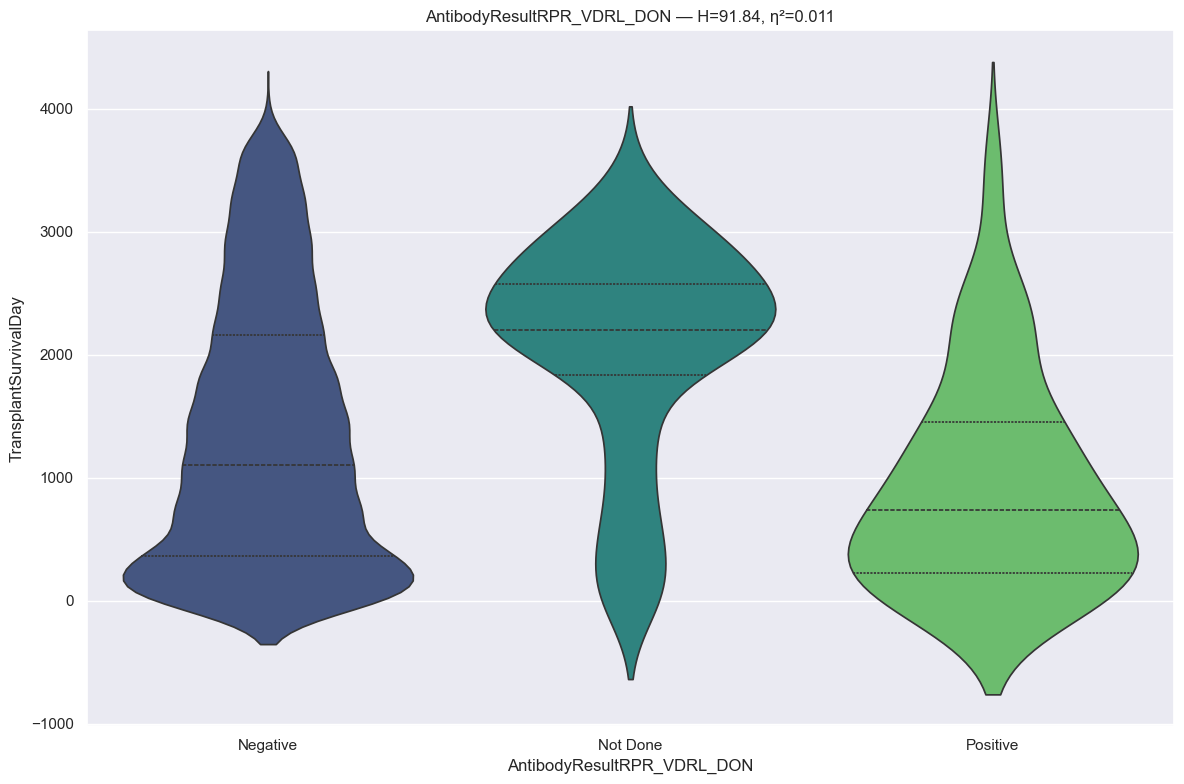

RANKING REPORT: AntibodyResultRPR_VDRL_DON (n ≥ 30)
INCLUDED CATEGORIES:
 * Negative                                          :   8077 records
 * Not Done                                          :    173 records
 * Positive                                          :     62 records
BYPASSED CATEGORIES (n < min_n):
 * Missing                                           :      7 records
--------------------------------------------------------------------------------
Kruskal H: 91.8443 | P-value: 1.138313e-20 | Effect η²: 0.0108
Correction Method: BONFERRONI
Pairwise Testing (Bonferroni Alpha: 0.0167 | r_threshold: 0.10)
--------------------------------------------------------------------------------
Negative     vs Not Done     | p=6.2060e-20 | thr=0.0167 | r= 0.406 | *Sig*
Not Done     vs Positive     | p=1.3373e-12 | thr=0.0167 | r=-0.607 | *Sig*
Negative     vs Positive     | p=5.6884e-03 | thr=0.0167 | r=-0.204 | *Sig*
::::: Collapsed into 3 groups (excluding 'Other') :::::



In [116]:
# instantiate class
ranker = NominalSurvivalRanker.NominalSurvivalRanker(
    method="bonferroni",  # bonferroni, Holm-Bonferroni (holm) Benjamini–Hochberg (fdr)
    r_thresh=0.10,        # Lower r-threshold (strict merging)
)
# initialize variable
results = ranker.fit(df, features[0])
# mapping DataFrame
new_row = pd.DataFrame([ranker.build_feature_dict(results)])
mapping_df = pd.concat([mapping_df, new_row], ignore_index=True)

In [117]:
# mapping dictionary
print(results['mapping'])
mean_survival_by_category(df, features[0])

{'Negative': 'Group_1', 'Not Done': 'Group_2', 'Positive': 'Group_3', 'Missing': 'Other'}


,AntibodyResultRPR_VDRL_DON,mean_survival_days,record_count
1,Negative,1325.971276,8077
2,Not Done,2062.040462,173
3,Positive,936.548387,62
0,Missing,1254.285714,7


#### Infection Clinical

In [118]:
# info
features = u.get_feature_info(df, 'InfectionClinical', cat=False)
# dtype
{col: df[col].dtype for col in features}

                      count unique  top  freq
InfectionClinical_DON  8319      4  Yes  6389

:::: NaN Count:
InfectionClinical_DON    0 



{'InfectionClinical_DON': CategoricalDtype(categories=['Missing', 'No', 'Unknown', 'Yes'], ordered=False, categories_dtype=object)}

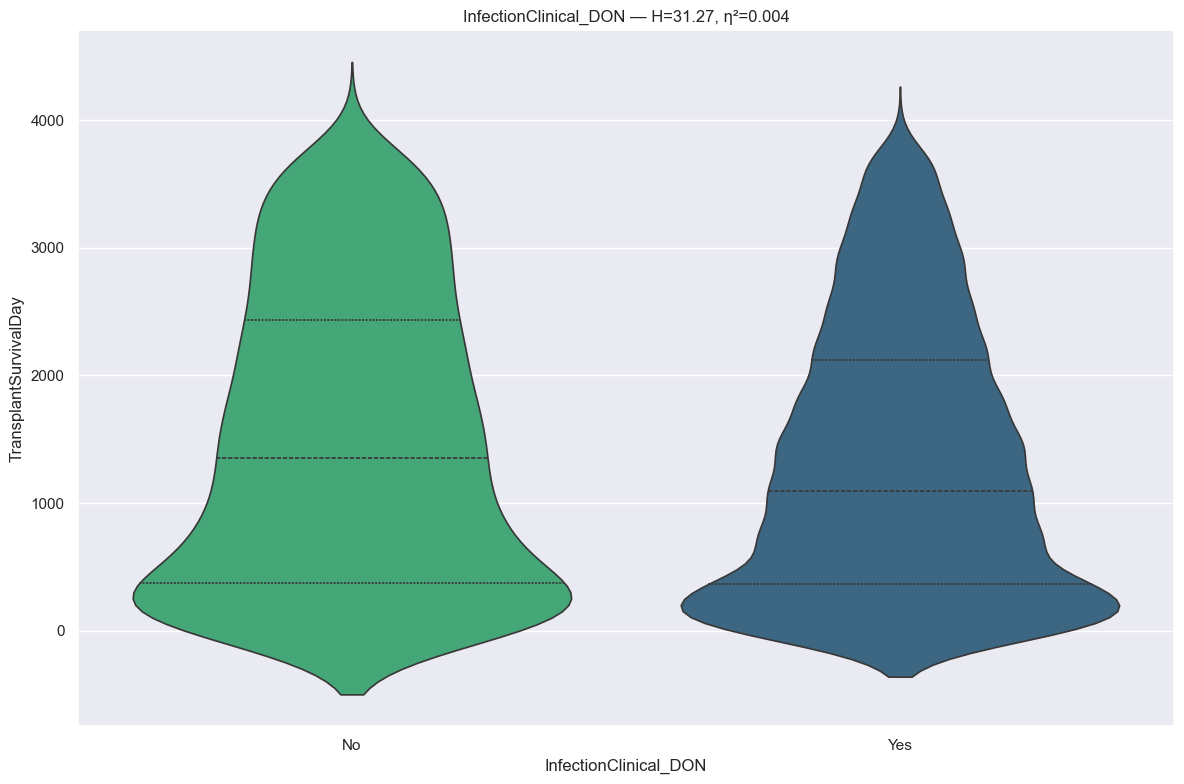

RANKING REPORT: InfectionClinical_DON (n ≥ 30)
INCLUDED CATEGORIES:
 * No                                                :   1890 records
 * Yes                                               :   6389 records
BYPASSED CATEGORIES (n < min_n):
 * Missing                                           :     14 records
 * Unknown                                           :     26 records
--------------------------------------------------------------------------------
Kruskal H: 31.2733 | P-value: 2.241387e-08 | Effect η²: 0.0037
Correction Method: BONFERRONI
Pairwise Testing (Bonferroni Alpha: 0.0500 | r_threshold: 0.10)
--------------------------------------------------------------------------------
No           vs Yes          | p=2.2415e-08 | thr=0.0500 | r=-0.085 | *Sig*
::::: Collapsed into 2 groups (excluding 'Other') :::::



In [119]:
# instantiate class
ranker = NominalSurvivalRanker.NominalSurvivalRanker(
    method="bonferroni",  # bonferroni, Holm-Bonferroni (holm) Benjamini–Hochberg (fdr)
    r_thresh=0.10,        # Lower r-threshold (strict merging)
)
# initialize variable
results = ranker.fit(df, features[0])
# mapping DataFrame
new_row = pd.DataFrame([ranker.build_feature_dict(results)])
mapping_df = pd.concat([mapping_df, new_row], ignore_index=True)

In [120]:
# mapping dictionary
print(results['mapping'])
mean_survival_by_category(df, features[0])

{'No': 'Group_1', 'Yes': 'Group_2', 'Missing': 'Other', 'Unknown': 'Other'}


,InfectionClinical_DON,mean_survival_days,record_count
3,Yes,1298.221161,6389
1,No,1474.429630,1890
2,Unknown,1460.230769,26
0,Missing,1034.000000,14


In [121]:
# mapping (Unknown & Missing consolidate: sample size)
mapping = {'Unknown': 'Other',
           'Missing': 'Other'
          }
# map the change
df[features[0]] = df[features[0]].map(mapping).fillna(df[features[0]])
# sanity check
mean_survival_by_category(df, features[0])

,InfectionClinical_DON,mean_survival_days,record_count
2,Yes,1298.221161,6389
0,No,1474.429630,1890
1,Other,1311.050000,40


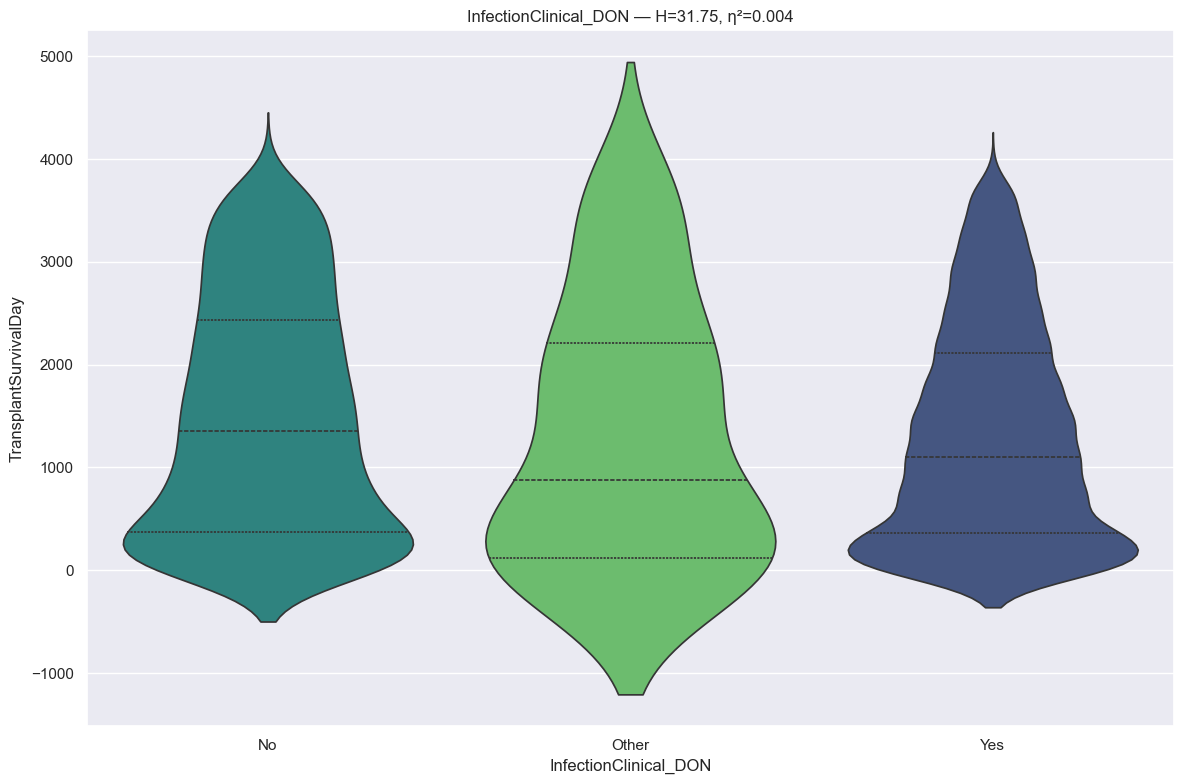

RANKING REPORT: InfectionClinical_DON (n ≥ 30)
INCLUDED CATEGORIES:
 * No                                                :   1890 records
 * Other                                             :     40 records
 * Yes                                               :   6389 records
BYPASSED CATEGORIES: None
--------------------------------------------------------------------------------
Kruskal H: 31.7516 | P-value: 1.274148e-07 | Effect η²: 0.0036
Correction Method: BONFERRONI
Pairwise Testing (Bonferroni Alpha: 0.0167 | r_threshold: 0.10)
--------------------------------------------------------------------------------
No           vs Yes          | p=2.2415e-08 | thr=0.0167 | r=-0.085 | *Sig*
No           vs Other        | p=1.9699e-01 | thr=0.0167 | r=-0.119 | Not Sig
Other        vs Yes          | p=5.7063e-01 | thr=0.0167 | r= 0.052 | Not Sig
::::: Collapsed into 2 groups (excluding 'Other') :::::



In [122]:
# instantiate class
ranker = NominalSurvivalRanker.NominalSurvivalRanker(
    method="bonferroni",  # bonferroni, Holm-Bonferroni (holm) Benjamini–Hochberg (fdr)
    r_thresh=0.10,        # Lower r-threshold (strict merging)
)
# initialize variable
results = ranker.fit(df, features[0])
# mapping DataFrame & remove last entry 
mapping_df = mapping_df[mapping_df["feature"] != features[0]]
new_row = pd.DataFrame([ranker.build_feature_dict(results)])
mapping_df = pd.concat([mapping_df, new_row], ignore_index=True)

In [123]:
# mapping dictionary
print(results['mapping'])
mean_survival_by_category(df, features[0])

{'No': 'Group_1', 'Other': 'Group_2', 'Yes': 'Group_2'}


,InfectionClinical_DON,mean_survival_days,record_count
2,Yes,1298.221161,6389
0,No,1474.429630,1890
1,Other,1311.050000,40


#### Cocaine Use

In [124]:
# info
features = u.get_feature_info(df, 'CocaineUse', cat=False)
# dtype
{col: df[col].dtype for col in features}

                   count unique      top  freq
CocaineUse_DON      8319      4  Missing  6713
PastCocaineUse_DON  8319      4       No  6578

:::: NaN Count:
CocaineUse_DON        0
PastCocaineUse_DON    0 



{'CocaineUse_DON': CategoricalDtype(categories=['Missing', 'No', 'Unknown', 'Yes'], ordered=False, categories_dtype=object),
 'PastCocaineUse_DON': CategoricalDtype(categories=['Missing', 'No', 'Unknown', 'Yes'], ordered=False, categories_dtype=object)}

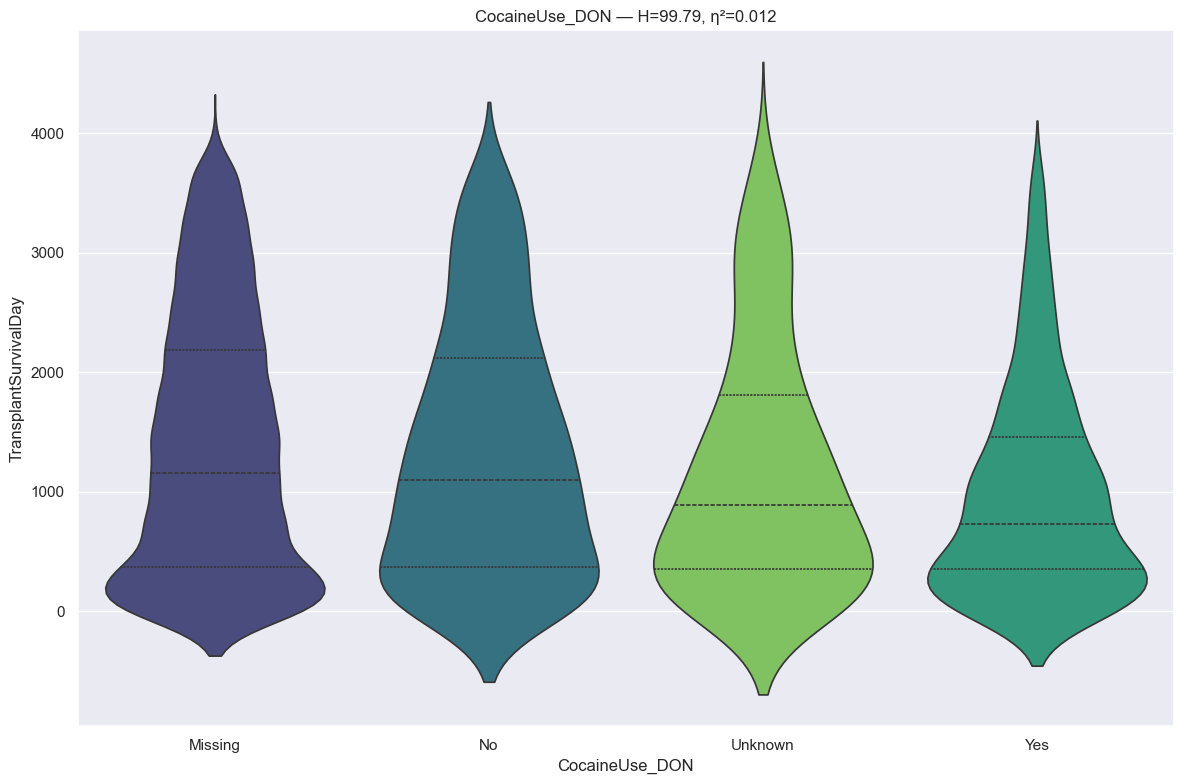

RANKING REPORT: CocaineUse_DON (n ≥ 30)
INCLUDED CATEGORIES:
 * Missing                                           :   6713 records
 * No                                                :    542 records
 * Unknown                                           :    215 records
 * Yes                                               :    849 records
BYPASSED CATEGORIES: None
--------------------------------------------------------------------------------
Kruskal H: 99.7937 | P-value: 1.721303e-21 | Effect η²: 0.0116
Correction Method: BONFERRONI
Pairwise Testing (Bonferroni Alpha: 0.0083 | r_threshold: 0.10)
--------------------------------------------------------------------------------
Missing      vs Yes          | p=2.5778e-22 | thr=0.0083 | r=-0.204 | *Sig*
No           vs Yes          | p=3.7157e-09 | thr=0.0083 | r=-0.187 | *Sig*
Missing      vs Unknown      | p=5.0142e-03 | thr=0.0083 | r=-0.112 | *Sig*
No           vs Unknown      | p=4.0936e-02 | thr=0.0083 | r=-0.095 | Not Sig
Unknown 

In [125]:
# instantiate class
ranker = NominalSurvivalRanker.NominalSurvivalRanker(
    method="bonferroni",  # bonferroni, Holm-Bonferroni (holm) Benjamini–Hochberg (fdr)
    r_thresh=0.10,        # Lower r-threshold (strict merging)
)
# initialize variable
results = ranker.fit(df, features[0])
# mapping DataFrame
new_row = pd.DataFrame([ranker.build_feature_dict(results)])
mapping_df = pd.concat([mapping_df, new_row], ignore_index=True)

In [126]:
# mapping dictionary
print(results['mapping'])
mean_survival_by_category(df, features[0])

{'Missing': 'Group_1', 'No': 'Group_1', 'Unknown': 'Group_1', 'Yes': 'Group_1'}


,CocaineUse_DON,mean_survival_days,record_count
0,Missing,1388.780128,6713
3,Yes,987.477032,849
1,No,1329.590406,542
2,Unknown,1170.055814,215


#### Other Drug Use

In [127]:
# info
features = u.get_feature_info(df, 'OtherDrugUse', cat=False)
# dtype
{col: df[col].dtype for col in features}

                     count unique      top  freq
OtherDrugUse_DON      8319      4  Missing  4406
PastOtherDrugUse_DON  8319      4       No  4317

:::: NaN Count:
OtherDrugUse_DON        0
PastOtherDrugUse_DON    0 



{'OtherDrugUse_DON': CategoricalDtype(categories=['Missing', 'No', 'Unknown', 'Yes'], ordered=False, categories_dtype=object),
 'PastOtherDrugUse_DON': CategoricalDtype(categories=['Missing', 'No', 'Unknown', 'Yes'], ordered=False, categories_dtype=object)}

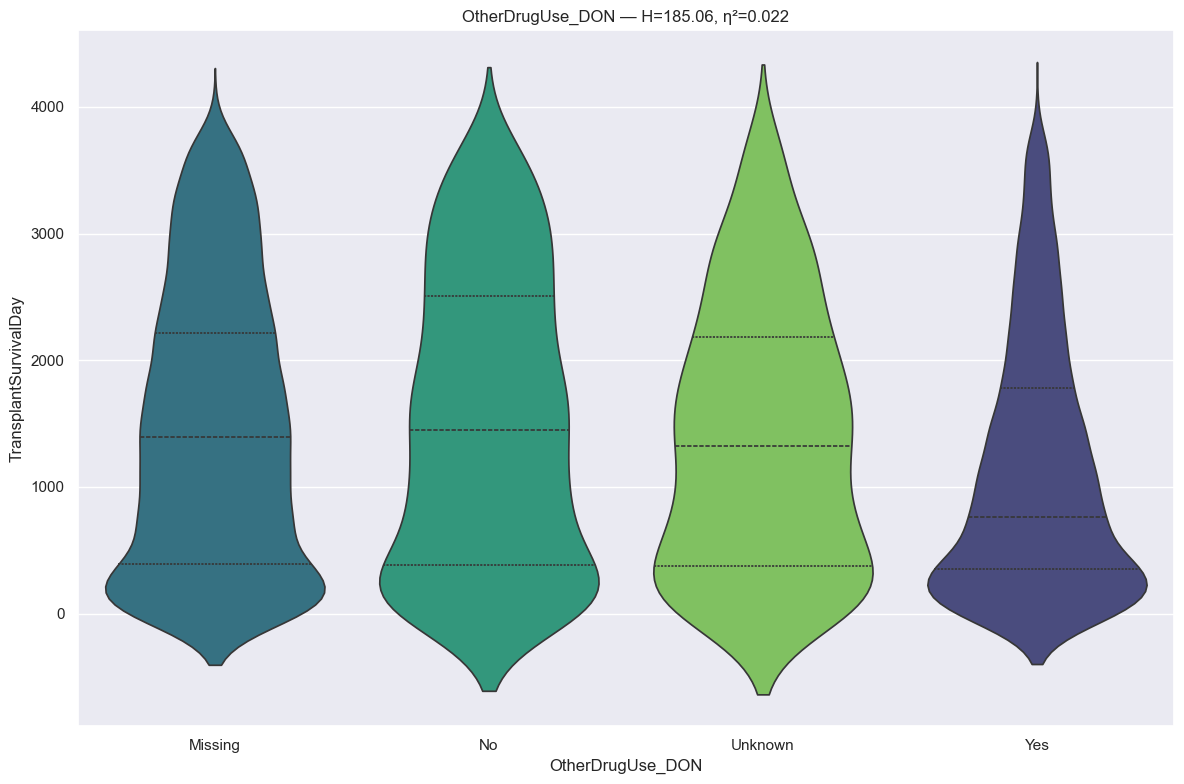

RANKING REPORT: OtherDrugUse_DON (n ≥ 30)
INCLUDED CATEGORIES:
 * Missing                                           :   4406 records
 * No                                                :    685 records
 * Unknown                                           :    348 records
 * Yes                                               :   2880 records
BYPASSED CATEGORIES: None
--------------------------------------------------------------------------------
Kruskal H: 185.0556 | P-value: 7.138551e-40 | Effect η²: 0.0219
Correction Method: BONFERRONI
Pairwise Testing (Bonferroni Alpha: 0.0083 | r_threshold: 0.10)
--------------------------------------------------------------------------------
Missing      vs Yes          | p=3.3164e-39 | thr=0.0083 | r=-0.181 | *Sig*
No           vs Yes          | p=1.7121e-14 | thr=0.0083 | r=-0.188 | *Sig*
Unknown      vs Yes          | p=2.8225e-06 | thr=0.0083 | r=-0.153 | *Sig*
No           vs Unknown      | p=2.0133e-01 | thr=0.0083 | r=-0.049 | Not Sig
Missi

In [128]:
# instantiate class
ranker = NominalSurvivalRanker.NominalSurvivalRanker(
    method="bonferroni",  # bonferroni, Holm-Bonferroni (holm) Benjamini–Hochberg (fdr)
    r_thresh=0.10,        # Lower r-threshold (strict merging)
)
# initialize variable
results = ranker.fit(df, features[0])
# mapping DataFrame
new_row = pd.DataFrame([ranker.build_feature_dict(results)])
mapping_df = pd.concat([mapping_df, new_row], ignore_index=True)

In [129]:
# mapping dictionary
print(results['mapping'])
mean_survival_by_category(df, features[0])

{'Missing': 'Group_1', 'No': 'Group_1', 'Unknown': 'Group_1', 'Yes': 'Group_2'}


,OtherDrugUse_DON,mean_survival_days,record_count
0,Missing,1456.832274,4406
3,Yes,1113.829167,2880
1,No,1496.687591,685
2,Unknown,1383.870690,348


#### Cancer ExtraCranial

In [130]:
# info
features = u.get_feature_info(df, 'CancerExtraCranial', cat=False)
# dtype
{col: df[col].dtype for col in features}

                       count unique top  freq
CancerExtraCranial_DON  8319      4  No  8251

:::: NaN Count:
CancerExtraCranial_DON    0 



{'CancerExtraCranial_DON': CategoricalDtype(categories=['Missing', 'No', 'Unknown', 'Yes'], ordered=False, categories_dtype=object)}

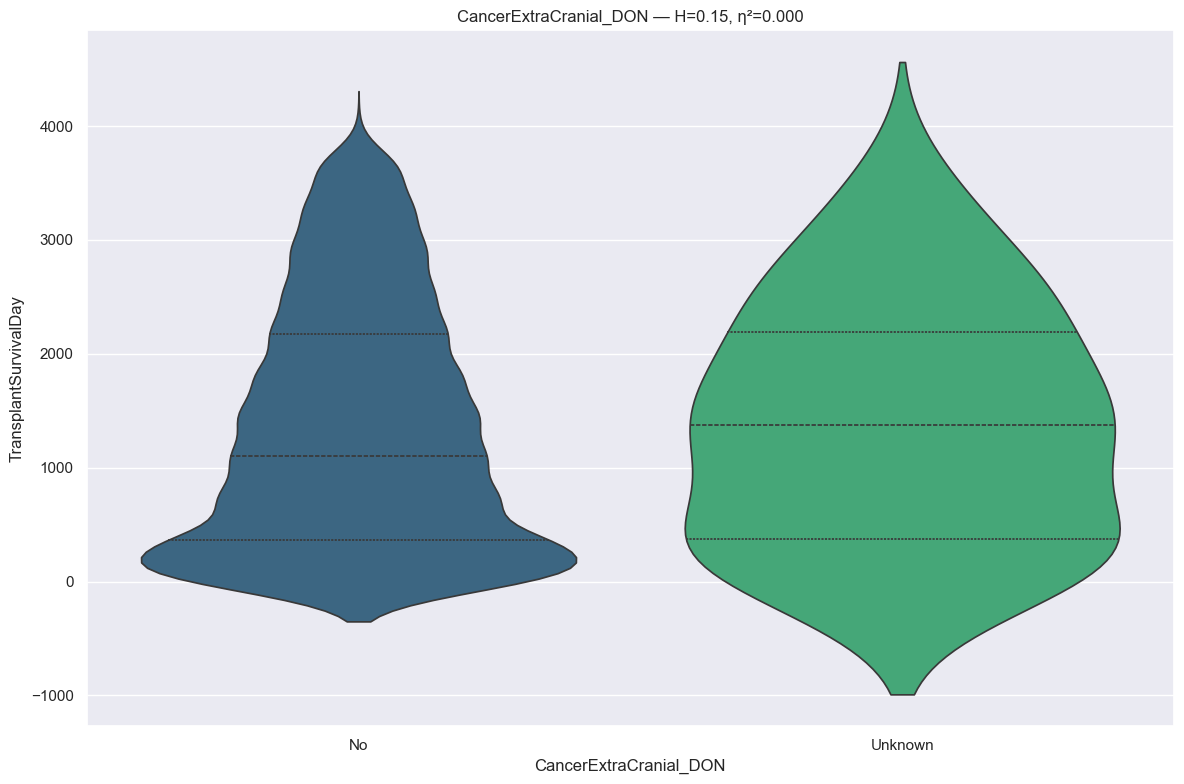

RANKING REPORT: CancerExtraCranial_DON (n ≥ 30)
INCLUDED CATEGORIES:
 * No                                                :   8251 records
 * Unknown                                           :     40 records
BYPASSED CATEGORIES (n < min_n):
 * Missing                                           :     14 records
 * Yes                                               :     14 records
--------------------------------------------------------------------------------
Kruskal H: 0.1492 | P-value: 6.992859e-01 | Effect η²: 0.0000
Correction Method: BONFERRONI
Pairwise Testing (Bonferroni Alpha: 0.0500 | r_threshold: 0.10)
--------------------------------------------------------------------------------
No           vs Unknown      | p=6.9931e-01 | thr=0.0500 | r= 0.035 | Not Sig
::::: Collapsed into 1 groups (excluding 'Other') :::::



In [131]:
# instantiate class
ranker = NominalSurvivalRanker.NominalSurvivalRanker(
    method="bonferroni",  # bonferroni, Holm-Bonferroni (holm) Benjamini–Hochberg (fdr)
    r_thresh=0.10,        # Lower r-threshold (strict merging)
)
# initialize variable
results = ranker.fit(df, features[0])
# mapping DataFrame
new_row = pd.DataFrame([ranker.build_feature_dict(results)])
mapping_df = pd.concat([mapping_df, new_row], ignore_index=True)

In [132]:
# mapping dictionary
print(results['mapping'])
mean_survival_by_category(df, features[0])

{'No': 'Group_1', 'Unknown': 'Group_1', 'Missing': 'Other', 'Yes': 'Other'}


,CancerExtraCranial_DON,mean_survival_days,record_count
1,No,1338.687917,8251
2,Unknown,1381.925000,40
0,Missing,1034.000000,14
3,Yes,1298.714286,14


In [133]:
# mapping (Missing is statistically similar to No & survival is very close)
mapping = {'Unknown': 'No'}
# map the change
df[features[0]] = (df[features[0]].map(mapping).fillna(df[features[0]]))

# sanity check
mean_survival_by_category(df, features[0])

,CancerExtraCranial_DON,mean_survival_days,record_count
1,No,1338.896514,8291
0,Missing,1034.000000,14
2,Yes,1298.714286,14


#### Cancer Site

In [134]:
# info
features = u.get_feature_info(df, 'CancerSite', cat=False)
# dtype
{col: df[col].dtype for col in features}

               count unique top  freq
CancerSite_DON  8319     22  NO  8068

:::: NaN Count:
CancerSite_DON    0 



{'CancerSite_DON': CategoricalDtype(categories=['BREAST', 'CNS TUMOR - ASTROCYTOMA',
                   'CNS TUMOR - GLIOBLASTOMA MULTIFORME',
                   'CNS TUMOR - MEDULLOBLASTOMA', 'CNS TUMOR - MENINGIOMA',
                   'CNS TUMOR - NEUROBLASTOMA', 'CNS TUMOR - OTHER',
                   'GASTROINTESTINAL - COLO-RECTAL',
                   'GASTROINTESTINAL - STOMACH', 'GENITOURINARY - BLADDER',
                   'GENITOURINARY - KIDNEY', 'GENITOURINARY - OVARIAN',
                   'GENITOURINARY - PENIS, TESTICULAR',
                   'GENITOURINARY - PROSTATE', 'GENITOURINARY - UNKNOWN',
                   'GENITOURINARY - UTERINE BODY CHORIOCARCINOMA',
                   'GENITOURINARY - UTERINE BODY ENDOMETRIAL',
                   'GENITOURINARY - UTERINE CERVIX', 'GENITOURINARY - VULVA',
                   'LEUKEMIA/LYMPHOMA', 'Missing', 'NO', 'OTHER, SPECIFY',
                   'SKIN - MELANOMA', 'SKIN - SQUAMOUS, BASAL CELL', 'THYROID',
                  

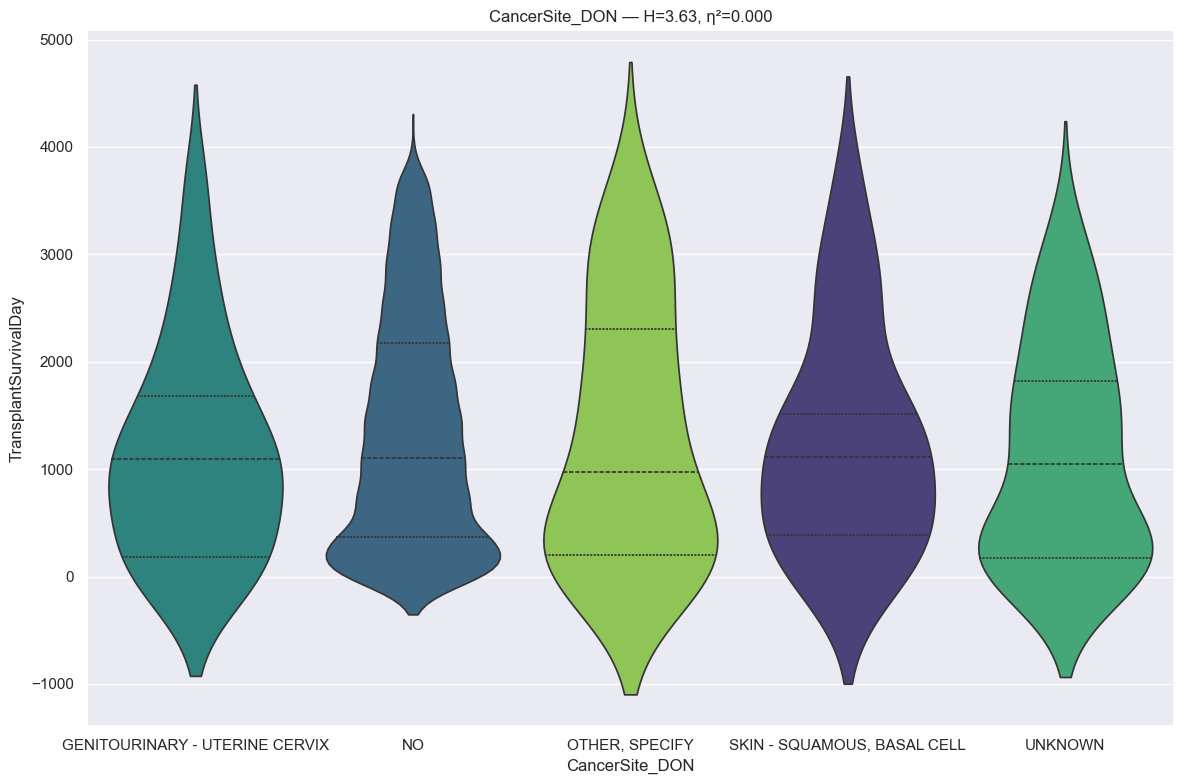

RANKING REPORT: CancerSite_DON (n ≥ 30)
INCLUDED CATEGORIES:
 * GENITOURINARY - UTERINE CERVIX                    :     44 records
 * NO                                                :   8068 records
 * OTHER, SPECIFY                                    :     45 records
 * SKIN - SQUAMOUS, BASAL CELL                       :     38 records
 * UNKNOWN                                           :     46 records
BYPASSED CATEGORIES (n < min_n):
 * BREAST                                            :     10 records
 * CNS TUMOR - ASTROCYTOMA                           :      3 records
 * CNS TUMOR - GLIOBLASTOMA MULTIFORME               :      3 records
 * CNS TUMOR - MEDULLOBLASTOMA                       :      1 records
 * CNS TUMOR - MENINGIOMA                            :     16 records
 * CNS TUMOR - NEUROBLASTOMA                         :      2 records
 * CNS TUMOR - OTHER                                 :      5 records
 * GASTROINTESTINAL - COLO-RECTAL                    :      1 reco

In [135]:
# instantiate class
ranker = NominalSurvivalRanker.NominalSurvivalRanker(
    method="bonferroni",  # bonferroni, Holm-Bonferroni (holm) Benjamini–Hochberg (fdr)
    r_thresh=0.10,        # Lower r-threshold (strict merging)
)
# initialize variable
results = ranker.fit(df, features[0])
# mapping DataFrame
new_row = pd.DataFrame([ranker.build_feature_dict(results)])
mapping_df = pd.concat([mapping_df, new_row], ignore_index=True)

In [136]:
# mapping dictionary
print(results['mapping'])
mean_survival_by_category(df, features[0])

{'GENITOURINARY - UTERINE CERVIX': 'Group_1', 'NO': 'Group_1', 'OTHER, SPECIFY': 'Group_1', 'SKIN - SQUAMOUS, BASAL CELL': 'Group_1', 'UNKNOWN': 'Group_1', 'BREAST': 'Other', 'CNS TUMOR - ASTROCYTOMA': 'Other', 'CNS TUMOR - GLIOBLASTOMA MULTIFORME': 'Other', 'CNS TUMOR - MEDULLOBLASTOMA': 'Other', 'CNS TUMOR - MENINGIOMA': 'Other', 'CNS TUMOR - NEUROBLASTOMA': 'Other', 'CNS TUMOR - OTHER': 'Other', 'GASTROINTESTINAL - COLO-RECTAL': 'Other', 'GENITOURINARY - OVARIAN': 'Other', 'GENITOURINARY - UNKNOWN': 'Other', 'GENITOURINARY - UTERINE BODY CHORIOCARCINOMA': 'Other', 'GENITOURINARY - UTERINE BODY ENDOMETRIAL': 'Other', 'GENITOURINARY - VULVA': 'Other', 'LEUKEMIA/LYMPHOMA': 'Other', 'Missing': 'Other', 'SKIN - MELANOMA': 'Other', 'THYROID': 'Other'}


,CancerSite_DON,mean_survival_days,record_count
16,NO,1341.523426,8068
21,UNKNOWN,1124.630435,46
17,"OTHER, SPECIFY",1302.177778,45
12,GENITOURINARY - UTERINE CERVIX,1154.613636,44
19,"SKIN - SQUAMOUS, BASAL CELL",1273.631579,38
4,CNS TUMOR - MENINGIOMA,1512.187500,16
8,GENITOURINARY - OVARIAN,1663.333333,12
20,THYROID,752.500000,10
0,BREAST,808.200000,10
6,CNS TUMOR - OTHER,1062.800000,5


In [137]:
# instantiate class
ranker = NominalSurvivalRanker.NominalSurvivalRanker(
    method="fdr",  # bonferroni, Holm-Bonferroni (holm) Benjamini–Hochberg (fdr)
    r_thresh=0.05,        # Lower r-threshold (strict merging)
    plot=False
)
# initialize variable
results = ranker.fit(df, features[0])
# mapping DataFrame & remove last entry 
mapping_df = mapping_df[mapping_df["feature"] != features[0]]
new_row = pd.DataFrame([ranker.build_feature_dict(results)])
mapping_df = pd.concat([mapping_df, new_row], ignore_index=True)

RANKING REPORT: CancerSite_DON (n ≥ 30)
INCLUDED CATEGORIES:
 * GENITOURINARY - UTERINE CERVIX                    :     44 records
 * NO                                                :   8068 records
 * OTHER, SPECIFY                                    :     45 records
 * SKIN - SQUAMOUS, BASAL CELL                       :     38 records
 * UNKNOWN                                           :     46 records
BYPASSED CATEGORIES (n < min_n):
 * BREAST                                            :     10 records
 * CNS TUMOR - ASTROCYTOMA                           :      3 records
 * CNS TUMOR - GLIOBLASTOMA MULTIFORME               :      3 records
 * CNS TUMOR - MEDULLOBLASTOMA                       :      1 records
 * CNS TUMOR - MENINGIOMA                            :     16 records
 * CNS TUMOR - NEUROBLASTOMA                         :      2 records
 * CNS TUMOR - OTHER                                 :      5 records
 * GASTROINTESTINAL - COLO-RECTAL                    :      1 reco

In [138]:
# mapping dictionary
print(results['mapping'])
mean_survival_by_category(df, features[0])

{'GENITOURINARY - UTERINE CERVIX': 'Group_1', 'UNKNOWN': 'Group_1', 'NO': 'Group_2', 'OTHER, SPECIFY': 'Group_2', 'SKIN - SQUAMOUS, BASAL CELL': 'Group_2', 'BREAST': 'Other', 'CNS TUMOR - ASTROCYTOMA': 'Other', 'CNS TUMOR - GLIOBLASTOMA MULTIFORME': 'Other', 'CNS TUMOR - MEDULLOBLASTOMA': 'Other', 'CNS TUMOR - MENINGIOMA': 'Other', 'CNS TUMOR - NEUROBLASTOMA': 'Other', 'CNS TUMOR - OTHER': 'Other', 'GASTROINTESTINAL - COLO-RECTAL': 'Other', 'GENITOURINARY - OVARIAN': 'Other', 'GENITOURINARY - UNKNOWN': 'Other', 'GENITOURINARY - UTERINE BODY CHORIOCARCINOMA': 'Other', 'GENITOURINARY - UTERINE BODY ENDOMETRIAL': 'Other', 'GENITOURINARY - VULVA': 'Other', 'LEUKEMIA/LYMPHOMA': 'Other', 'Missing': 'Other', 'SKIN - MELANOMA': 'Other', 'THYROID': 'Other'}


,CancerSite_DON,mean_survival_days,record_count
16,NO,1341.523426,8068
21,UNKNOWN,1124.630435,46
17,"OTHER, SPECIFY",1302.177778,45
12,GENITOURINARY - UTERINE CERVIX,1154.613636,44
19,"SKIN - SQUAMOUS, BASAL CELL",1273.631579,38
4,CNS TUMOR - MENINGIOMA,1512.187500,16
8,GENITOURINARY - OVARIAN,1663.333333,12
20,THYROID,752.500000,10
0,BREAST,808.200000,10
6,CNS TUMOR - OTHER,1062.800000,5


In [139]:
# mapping dictionary
collapse_map = results['mapping']
# New feature
df[features[0] + "_group"] = (
    df[features[0]]
    .map(collapse_map)
    .astype("category")
)
# add to remove list
remove_cols.extend(features)
# update feature with new name
mapping_df.loc[mapping_df["feature"].isin(features), "feature"] = mapping_df["feature"] + "_group"
# sanity check
df[features[0] + "_group"].isna().any()

np.False_

#### Cigarette History

In [140]:
# info
features = u.get_feature_info(df, 'CigaretteHistory', cat=False)
# dtype
{col: df[col].dtype for col in features}

                     count unique top  freq
CigaretteHistory_DON  8319      4  No  7157

:::: NaN Count:
CigaretteHistory_DON    0 



{'CigaretteHistory_DON': CategoricalDtype(categories=['Missing', 'No', 'Unknown', 'Yes'], ordered=False, categories_dtype=object)}

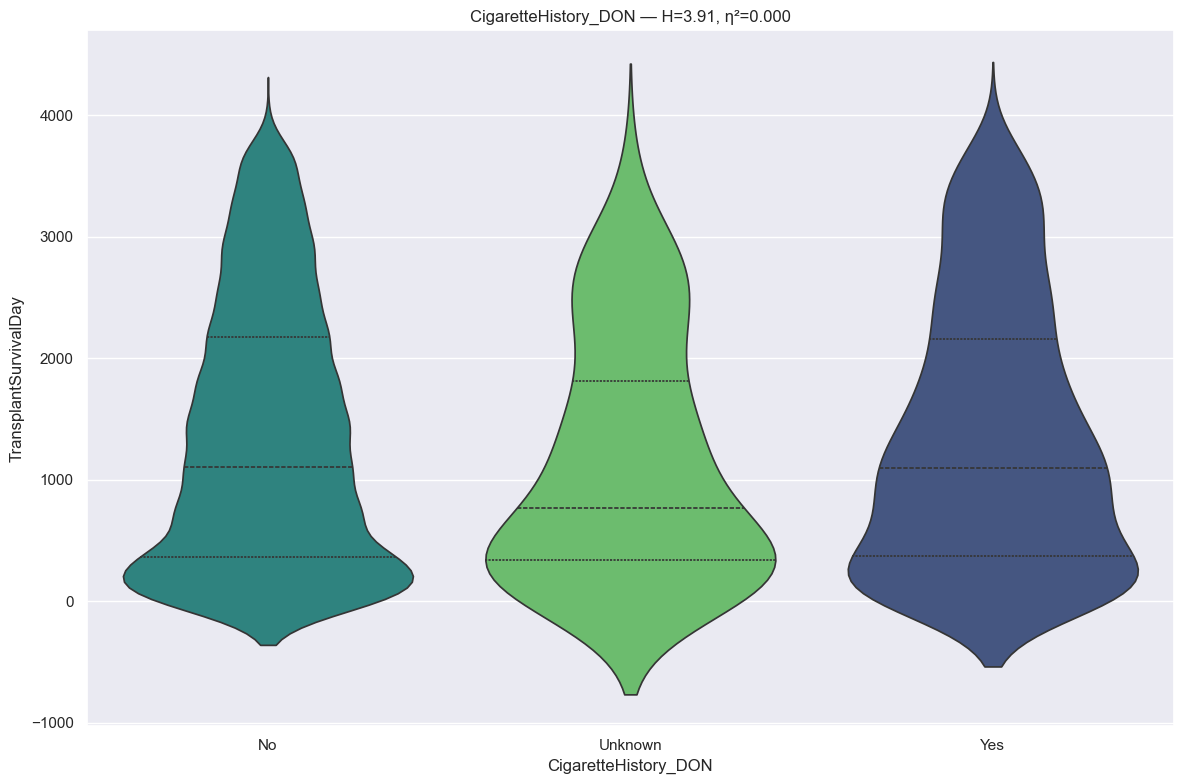

RANKING REPORT: CigaretteHistory_DON (n ≥ 30)
INCLUDED CATEGORIES:
 * No                                                :   7157 records
 * Unknown                                           :    117 records
 * Yes                                               :   1044 records
BYPASSED CATEGORIES (n < min_n):
 * Missing                                           :      1 records
--------------------------------------------------------------------------------
Kruskal H: 3.9078 | P-value: 1.417221e-01 | Effect η²: 0.0002
Correction Method: BONFERRONI
Pairwise Testing (Bonferroni Alpha: 0.0167 | r_threshold: 0.10)
--------------------------------------------------------------------------------
No           vs Unknown      | p=5.0160e-02 | thr=0.0167 | r=-0.105 | Not Sig
Unknown      vs Yes          | p=8.2303e-02 | thr=0.0167 | r= 0.098 | Not Sig
No           vs Yes          | p=7.1519e-01 | thr=0.0167 | r=-0.007 | Not Sig
::::: Collapsed into 1 groups (excluding 'Other') :::::



In [141]:
# instantiate class
ranker = NominalSurvivalRanker.NominalSurvivalRanker(
    method="bonferroni",  # bonferroni, Holm-Bonferroni (holm) Benjamini–Hochberg (fdr)
    r_thresh=0.10,        # Lower r-threshold (strict merging)
)
# initialize variable
results = ranker.fit(df, features[0])
# mapping DataFrame
new_row = pd.DataFrame([ranker.build_feature_dict(results)])
mapping_df = pd.concat([mapping_df, new_row], ignore_index=True)

In [142]:
# mapping dictionary
print(results['mapping'])
mean_survival_by_category(df, features[0])

{'No': 'Group_1', 'Unknown': 'Group_1', 'Yes': 'Group_1', 'Missing': 'Other'}


,CigaretteHistory_DON,mean_survival_days,record_count
1,No,1342.044991,7157
3,Yes,1335.120690,1044
2,Unknown,1143.675214,117
0,Missing,757.000000,1


In [143]:
# mapping (Missing and Unknown consolidate: small sample)
mapping = {'Missing': 'Other',
           'Unknown': 'Other'}
# map the change
df[features[0]] = (df[features[0]].map(mapping).fillna(df[features[0]]))

# sanity check
mean_survival_by_category(df, features[0])

,CigaretteHistory_DON,mean_survival_days,record_count
0,No,1342.044991,7157
2,Yes,1335.120690,1044
1,Other,1140.398305,118


#### Hypertension History

In [144]:
# info
features = u.get_feature_info(df, 'HypertensionHistory', cat=False)
# dtype
{col: df[col].dtype for col in features}

                        count unique top  freq
HypertensionHistory_DON  8319      4  No  6590

:::: NaN Count:
HypertensionHistory_DON    0 



{'HypertensionHistory_DON': CategoricalDtype(categories=['Missing', 'No', 'Unknown', 'Yes'], ordered=False, categories_dtype=object)}

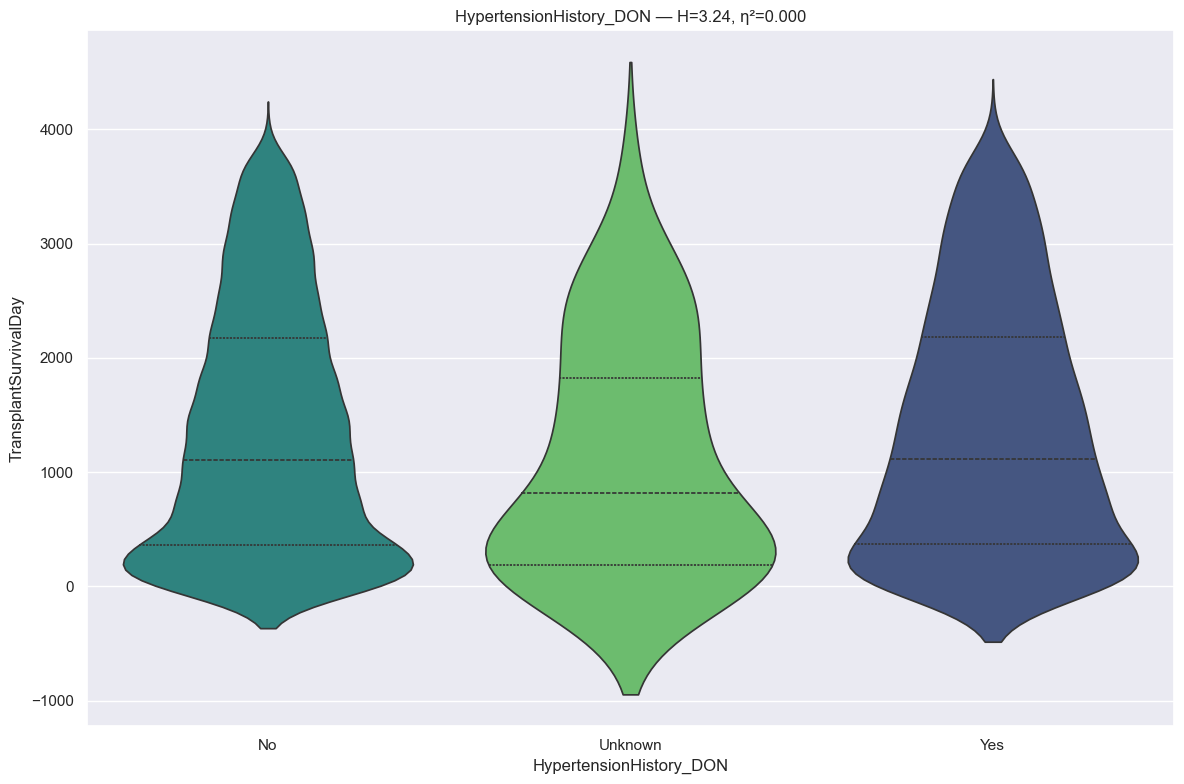

RANKING REPORT: HypertensionHistory_DON (n ≥ 30)
INCLUDED CATEGORIES:
 * No                                                :   6590 records
 * Unknown                                           :     46 records
 * Yes                                               :   1682 records
BYPASSED CATEGORIES (n < min_n):
 * Missing                                           :      1 records
--------------------------------------------------------------------------------
Kruskal H: 3.2413 | P-value: 1.977672e-01 | Effect η²: 0.0001
Correction Method: BONFERRONI
Pairwise Testing (Bonferroni Alpha: 0.0167 | r_threshold: 0.10)
--------------------------------------------------------------------------------
Unknown      vs Yes          | p=1.1537e-01 | thr=0.0167 | r= 0.136 | Not Sig
No           vs Unknown      | p=1.5753e-01 | thr=0.0167 | r=-0.121 | Not Sig
No           vs Yes          | p=2.8598e-01 | thr=0.0167 | r= 0.017 | Not Sig
::::: Collapsed into 2 groups (excluding 'Other') :::::



In [145]:
# instantiate class
ranker = NominalSurvivalRanker.NominalSurvivalRanker(
    method="bonferroni",  # bonferroni, Holm-Bonferroni (holm) Benjamini–Hochberg (fdr)
    r_thresh=0.10,        # Lower r-threshold (strict merging)
)
# initialize variable
results = ranker.fit(df, features[0])
# mapping DataFrame
new_row = pd.DataFrame([ranker.build_feature_dict(results)])
mapping_df = pd.concat([mapping_df, new_row], ignore_index=True)

In [146]:
# mapping dictionary
print(results['mapping'])
mean_survival_by_category(df, features[0])

{'No': 'Group_1', 'Yes': 'Group_1', 'Unknown': 'Group_2', 'Missing': 'Other'}


,HypertensionHistory_DON,mean_survival_days,record_count
1,No,1333.044006,6590
3,Yes,1364.981570,1682
2,Unknown,1107.891304,46
0,Missing,1827.000000,1


In [147]:
# mapping (Combine missing & unknown, not enough to trust the mean survival at all)
mapping = {'Missing': 'Other',
           'Unknown': 'Other'}
# map the change
df[features[0]] = (df[features[0]].map(mapping).fillna(df[features[0]]))

# sanity check
mean_survival_by_category(df, features[0])

,HypertensionHistory_DON,mean_survival_days,record_count
0,No,1333.044006,6590
2,Yes,1364.981570,1682
1,Other,1123.191489,47


#### Cancer Intra Cranial

In [148]:
# info
features = u.get_feature_info(df, 'CancerIntraCranial', cat=False)
# dtype
{col: df[col].dtype for col in features}

                       count unique top  freq
CancerIntraCranial_DON  8319      4  No  8238

:::: NaN Count:
CancerIntraCranial_DON    0 



{'CancerIntraCranial_DON': CategoricalDtype(categories=['Missing', 'No', 'Unknown', 'Yes'], ordered=False, categories_dtype=object)}

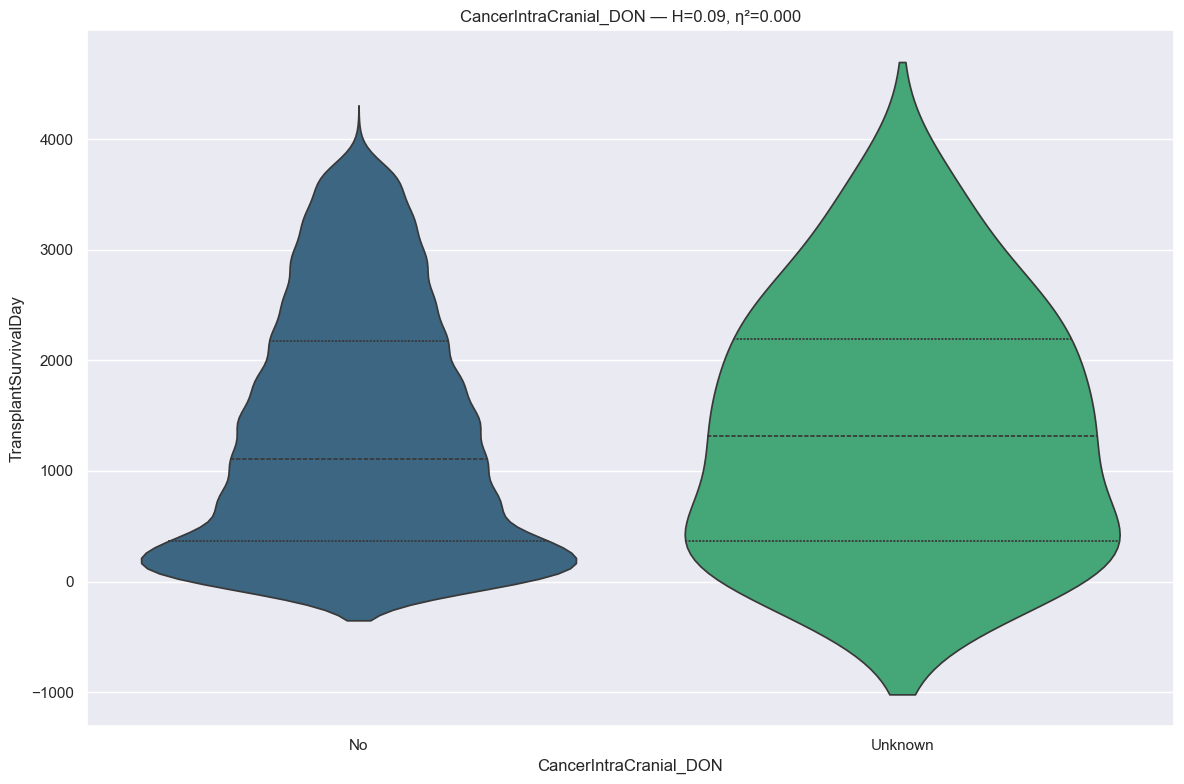

RANKING REPORT: CancerIntraCranial_DON (n ≥ 30)
INCLUDED CATEGORIES:
 * No                                                :   8238 records
 * Unknown                                           :     44 records
BYPASSED CATEGORIES (n < min_n):
 * Missing                                           :     14 records
 * Yes                                               :     23 records
--------------------------------------------------------------------------------
Kruskal H: 0.0909 | P-value: 7.630091e-01 | Effect η²: 0.0000
Correction Method: BONFERRONI
Pairwise Testing (Bonferroni Alpha: 0.0500 | r_threshold: 0.10)
--------------------------------------------------------------------------------
No           vs Unknown      | p=7.6303e-01 | thr=0.0500 | r= 0.026 | Not Sig
::::: Collapsed into 1 groups (excluding 'Other') :::::



In [149]:
# instantiate class
ranker = NominalSurvivalRanker.NominalSurvivalRanker(
    method="bonferroni",  # bonferroni, Holm-Bonferroni (holm) Benjamini–Hochberg (fdr)
    r_thresh=0.10,        # Lower r-threshold (strict merging)
)
# initialize variable
results = ranker.fit(df, features[0])
# mapping DataFrame
new_row = pd.DataFrame([ranker.build_feature_dict(results)])
mapping_df = pd.concat([mapping_df, new_row], ignore_index=True)

In [150]:
# mapping dictionary
print(results['mapping'])
mean_survival_by_category(df, features[0])

{'No': 'Group_1', 'Unknown': 'Group_1', 'Missing': 'Other', 'Yes': 'Other'}


,CancerIntraCranial_DON,mean_survival_days,record_count
1,No,1338.061787,8238
2,Unknown,1383.409091,44
3,Yes,1528.260870,23
0,Missing,1034.000000,14


#### Cancer History

In [151]:
# info
features = u.get_feature_info(df, 'CancerHistory', cat=False)
# dtype
{col: df[col].dtype for col in features}

                  count unique top  freq
CancerHistory_DON  8319      4  No  8068

:::: NaN Count:
CancerHistory_DON    0 



{'CancerHistory_DON': CategoricalDtype(categories=['Missing', 'No', 'Unknown', 'Yes'], ordered=False, categories_dtype=object)}

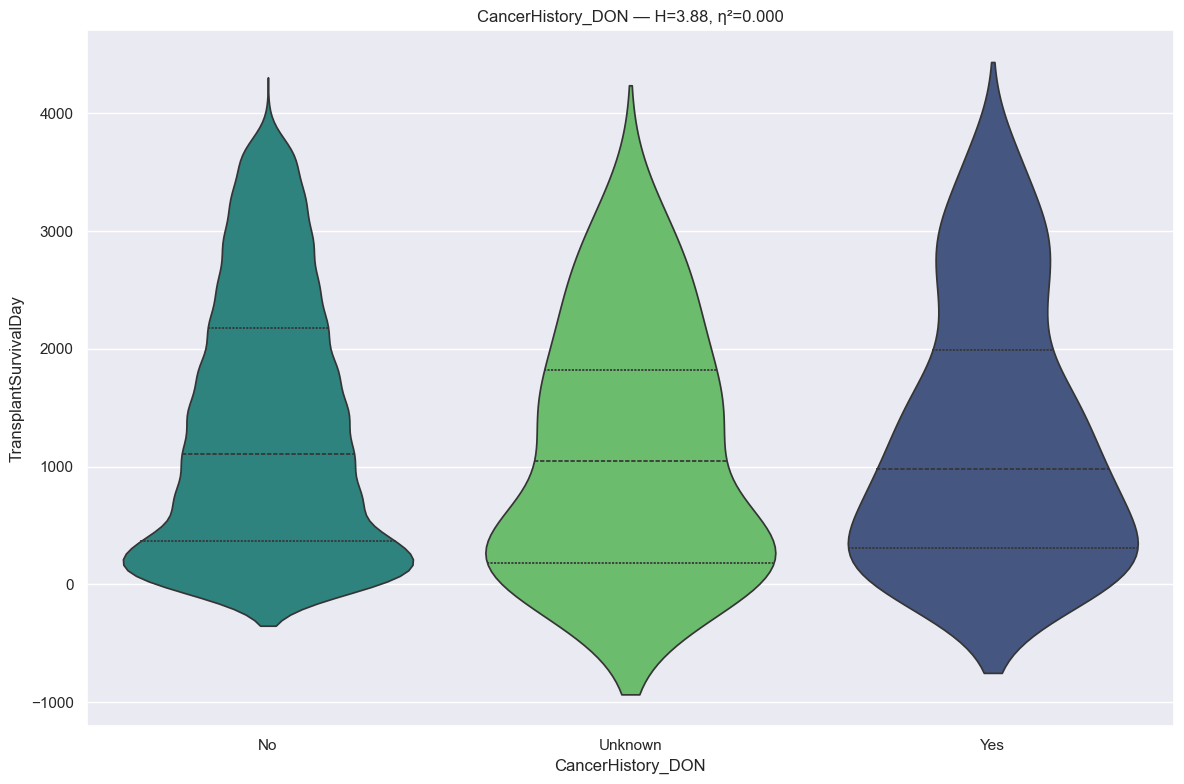

RANKING REPORT: CancerHistory_DON (n ≥ 30)
INCLUDED CATEGORIES:
 * No                                                :   8068 records
 * Unknown                                           :     46 records
 * Yes                                               :    201 records
BYPASSED CATEGORIES (n < min_n):
 * Missing                                           :      4 records
--------------------------------------------------------------------------------
Kruskal H: 3.8837 | P-value: 1.434403e-01 | Effect η²: 0.0002
Correction Method: BONFERRONI
Pairwise Testing (Bonferroni Alpha: 0.0167 | r_threshold: 0.10)
--------------------------------------------------------------------------------
No           vs Unknown      | p=1.5358e-01 | thr=0.0167 | r=-0.122 | Not Sig
No           vs Yes          | p=1.6863e-01 | thr=0.0167 | r=-0.057 | Not Sig
Unknown      vs Yes          | p=5.2778e-01 | thr=0.0167 | r= 0.060 | Not Sig
::::: Collapsed into 1 groups (excluding 'Other') :::::



In [152]:
# instantiate class
ranker = NominalSurvivalRanker.NominalSurvivalRanker(
    method="bonferroni",  # bonferroni, Holm-Bonferroni (holm) Benjamini–Hochberg (fdr)
    r_thresh=0.10,        # Lower r-threshold (strict merging)
)
# initialize variable
results = ranker.fit(df, features[0])
# mapping DataFrame
new_row = pd.DataFrame([ranker.build_feature_dict(results)])
mapping_df = pd.concat([mapping_df, new_row], ignore_index=True)

In [153]:
# mapping dictionary
print(results['mapping'])
mean_survival_by_category(df, features[0])

{'No': 'Group_1', 'Unknown': 'Group_1', 'Yes': 'Group_1', 'Missing': 'Other'}


,CancerHistory_DON,mean_survival_days,record_count
1,No,1341.523426,8068
3,Yes,1249.800995,201
2,Unknown,1124.630435,46
0,Missing,1773.750000,4


In [154]:
# mapping (Combine missing to unknown, not enough to trust the mean survival at all)
mapping = {'Missing': 'Other',
           'Unknown': 'Other'
          }
# map the change
df[features[0]] = (df[features[0]].map(mapping).fillna(df[features[0]]))

# sanity check
mean_survival_by_category(df, features[0])

,CancerHistory_DON,mean_survival_days,record_count
0,No,1341.523426,8068
2,Yes,1249.800995,201
1,Other,1176.560000,50


#### Diabetes History

In [155]:
# info
features = u.get_feature_info(df, 'DiabetesHistory', cat=False)
# dtype
{col: df[col].dtype for col in features}

                    count unique top  freq
DiabetesHistory_DON  8319      7  No  7855

:::: NaN Count:
DiabetesHistory_DON    0 



{'DiabetesHistory_DON': CategoricalDtype(categories=['Missing', 'No', 'Unknown', 'Yes, 0-5 Years',
                   'Yes, 6-10 Years', 'Yes, >10 Years',
                   'Yes, Duration Unknown'],
 , ordered=False, categories_dtype=object)}

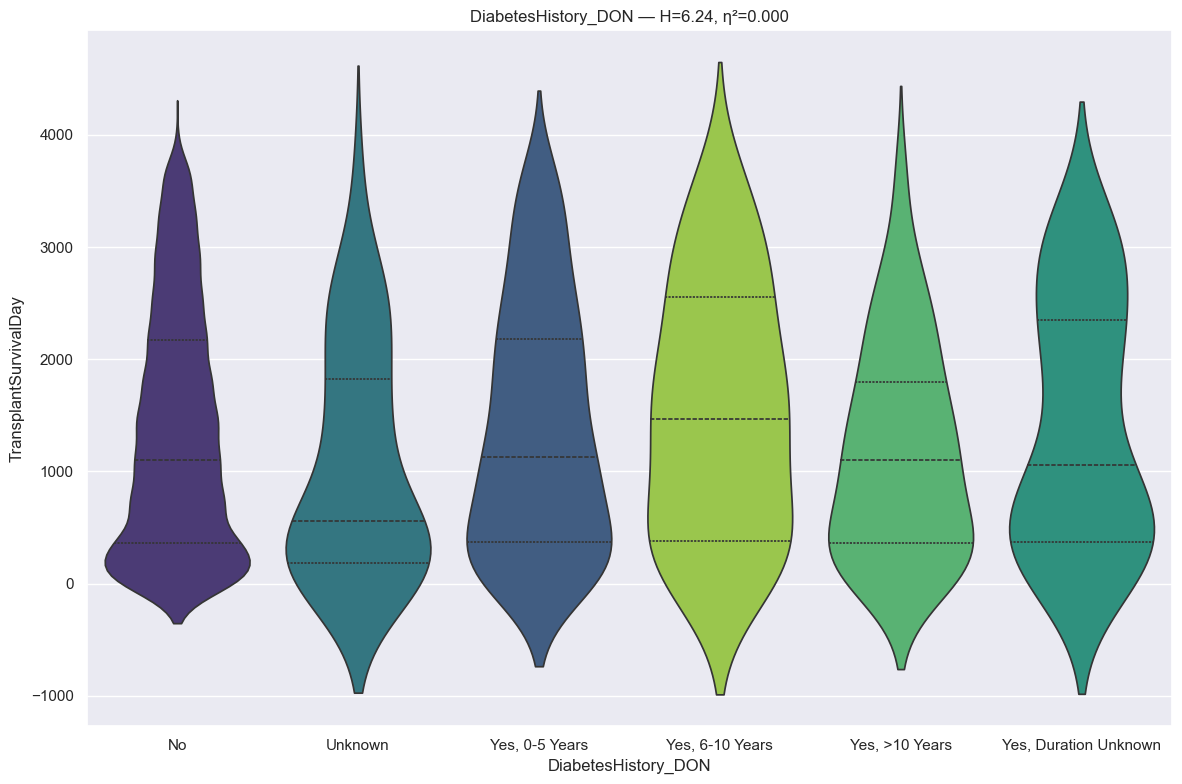

RANKING REPORT: DiabetesHistory_DON (n ≥ 30)
INCLUDED CATEGORIES:
 * No                                                :   7855 records
 * Unknown                                           :     41 records
 * Yes, 0-5 Years                                    :    225 records
 * Yes, 6-10 Years                                   :     53 records
 * Yes, >10 Years                                    :     90 records
 * Yes, Duration Unknown                             :     54 records
BYPASSED CATEGORIES (n < min_n):
 * Missing                                           :      1 records
--------------------------------------------------------------------------------
Kruskal H: 6.2397 | P-value: 2.835848e-01 | Effect η²: 0.0001
Correction Method: BONFERRONI
Pairwise Testing (Bonferroni Alpha: 0.0033 | r_threshold: 0.10)
--------------------------------------------------------------------------------
Unknown      vs Yes, 6-10 Years | p=4.0271e-02 | thr=0.0033 | r= 0.248 | Not Sig
Yes, 6-10 Ye

In [156]:
# instantiate class
ranker = NominalSurvivalRanker.NominalSurvivalRanker(
    method="bonferroni",  # bonferroni, Holm-Bonferroni (holm) Benjamini–Hochberg (fdr)
    r_thresh=0.10,        # Lower r-threshold (strict merging)
)
# initialize variable
results = ranker.fit(df, features[0])
# mapping DataFrame
new_row = pd.DataFrame([ranker.build_feature_dict(results)])
mapping_df = pd.concat([mapping_df, new_row], ignore_index=True)

In [157]:
# mapping dictionary
print(results['mapping'])
mean_survival_by_category(df, features[0])

{'No': 'Group_1', 'Yes, 0-5 Years': 'Group_1', 'Yes, 6-10 Years': 'Group_1', 'Yes, >10 Years': 'Group_1', 'Yes, Duration Unknown': 'Group_1', 'Unknown': 'Group_2', 'Missing': 'Other'}


,DiabetesHistory_DON,mean_survival_days,record_count
1,No,1338.060344,7855
3,"Yes, 0-5 Years",1391.302222,225
5,"Yes, >10 Years",1186.611111,90
6,"Yes, Duration Unknown",1402.777778,54
4,"Yes, 6-10 Years",1536.792453,53
2,Unknown,1076.097561,41
0,Missing,1827.000000,1


In [158]:
# Remove last entry 
mapping_df = mapping_df[mapping_df["feature"] != features[0]]
# add to remove list (Use Diabetes_DON)
remove_cols.extend(features)

#### Diabetes

In [159]:
# info
features = u.get_feature_info(df, 'Diabetes_DON', cat=False)
# dtype
{col: df[col].dtype for col in features}

             count unique top  freq
Diabetes_DON  8319      4  No  7855

:::: NaN Count:
Diabetes_DON    0 



{'Diabetes_DON': CategoricalDtype(categories=['Missing', 'No', 'Unknown', 'Yes'], ordered=False, categories_dtype=object)}

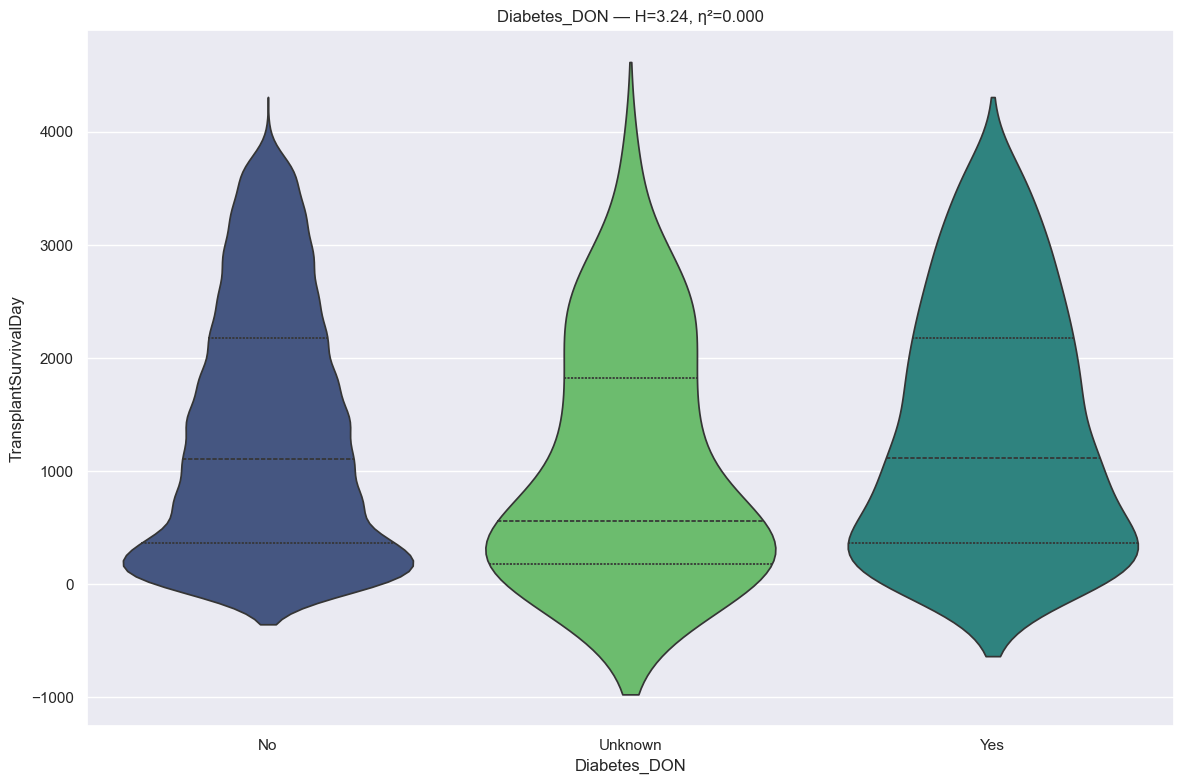

RANKING REPORT: Diabetes_DON (n ≥ 30)
INCLUDED CATEGORIES:
 * No                                                :   7855 records
 * Unknown                                           :     41 records
 * Yes                                               :    422 records
BYPASSED CATEGORIES (n < min_n):
 * Missing                                           :      1 records
--------------------------------------------------------------------------------
Kruskal H: 3.2419 | P-value: 1.977061e-01 | Effect η²: 0.0001
Correction Method: BONFERRONI
Pairwise Testing (Bonferroni Alpha: 0.0167 | r_threshold: 0.10)
--------------------------------------------------------------------------------
Unknown      vs Yes          | p=7.6672e-02 | thr=0.0167 | r= 0.167 | Not Sig
No           vs Unknown      | p=9.7718e-02 | thr=0.0167 | r=-0.150 | Not Sig
No           vs Yes          | p=4.9486e-01 | thr=0.0167 | r= 0.020 | Not Sig
::::: Collapsed into 2 groups (excluding 'Other') :::::



In [160]:
# instantiate class
ranker = NominalSurvivalRanker.NominalSurvivalRanker(
    method="bonferroni",  # bonferroni, Holm-Bonferroni (holm) Benjamini–Hochberg (fdr)
    r_thresh=0.10,        # Lower r-threshold (strict merging)
)
# initialize variable
results = ranker.fit(df, features[0])
# mapping DataFrame
new_row = pd.DataFrame([ranker.build_feature_dict(results)])
mapping_df = pd.concat([mapping_df, new_row], ignore_index=True)

In [161]:
# mapping dictionary
print(results['mapping'])
mean_survival_by_category(df, features[0])

{'No': 'Group_1', 'Yes': 'Group_1', 'Unknown': 'Group_2', 'Missing': 'Other'}


,Diabetes_DON,mean_survival_days,record_count
1,No,1338.060344,7855
3,Yes,1367.388626,422
2,Unknown,1076.097561,41
0,Missing,1827.000000,1


In [162]:
# mapping
mapping = {'Missing': 'Other',
           'Unknown': 'Other'
          }
# map the change
df[features[0]] = (df[features[0]].map(mapping).fillna(df[features[0]]))

# sanity check
mean_survival_by_category(df, features[0])

,Diabetes_DON,mean_survival_days,record_count
0,No,1338.060344,7855
2,Yes,1367.388626,422
1,Other,1093.976190,42


#### Past Other Drug Use

In [163]:
# info
features = u.get_feature_info(df, 'PastOtherDrugUse', cat=False)
# dtype
{col: df[col].dtype for col in features}

                     count unique top  freq
PastOtherDrugUse_DON  8319      4  No  4317

:::: NaN Count:
PastOtherDrugUse_DON    0 



{'PastOtherDrugUse_DON': CategoricalDtype(categories=['Missing', 'No', 'Unknown', 'Yes'], ordered=False, categories_dtype=object)}

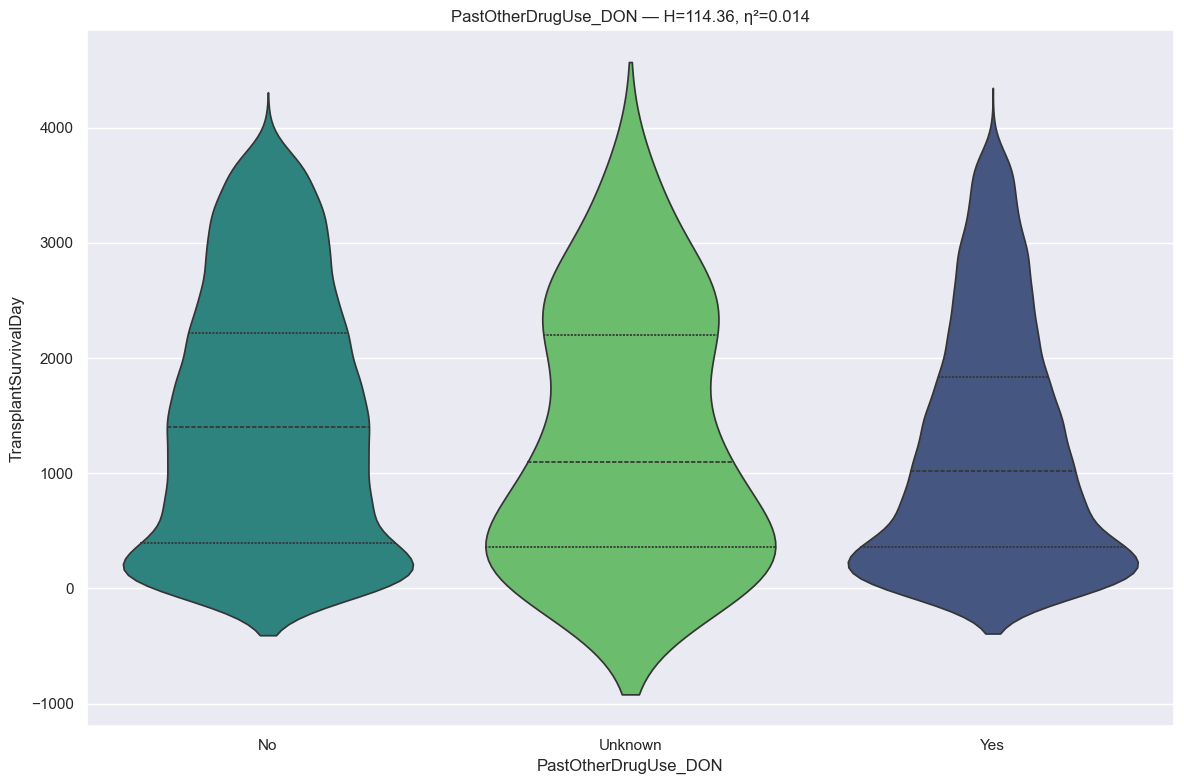

RANKING REPORT: PastOtherDrugUse_DON (n ≥ 30)
INCLUDED CATEGORIES:
 * No                                                :   4317 records
 * Unknown                                           :     75 records
 * Yes                                               :   3913 records
BYPASSED CATEGORIES (n < min_n):
 * Missing                                           :     14 records
--------------------------------------------------------------------------------
Kruskal H: 114.3571 | P-value: 1.471215e-25 | Effect η²: 0.0135
Correction Method: BONFERRONI
Pairwise Testing (Bonferroni Alpha: 0.0167 | r_threshold: 0.10)
--------------------------------------------------------------------------------
No           vs Yes          | p=1.1862e-26 | thr=0.0167 | r=-0.136 | *Sig*
No           vs Unknown      | p=1.4700e-01 | thr=0.0167 | r=-0.098 | Not Sig
Unknown      vs Yes          | p=6.5872e-01 | thr=0.0167 | r=-0.030 | Not Sig
::::: Collapsed into 1 groups (excluding 'Other') :::::



In [164]:
# instantiate class
ranker = NominalSurvivalRanker.NominalSurvivalRanker(
    method="bonferroni",  # bonferroni, Holm-Bonferroni (holm) Benjamini–Hochberg (fdr)
    r_thresh=0.10,        # Lower r-threshold (strict merging)
)
# initialize variable
results = ranker.fit(df, features[0])
# mapping DataFrame
new_row = pd.DataFrame([ranker.build_feature_dict(results)])
mapping_df = pd.concat([mapping_df, new_row], ignore_index=True)

In [165]:
# mapping dictionary
print(results['mapping'])
mean_survival_by_category(df, features[0])

{'No': 'Group_1', 'Unknown': 'Group_1', 'Yes': 'Group_1', 'Missing': 'Other'}


,PastOtherDrugUse_DON,mean_survival_days,record_count
1,No,1461.091730,4317
3,Yes,1204.867365,3913
2,Unknown,1290.586667,75
0,Missing,1034.000000,14


In [166]:
# mapping - Combining Unknown & Missing them preserves interpretability
mapping = {'Missing': 'Other',
           'Unknown': 'Other'
          }
# map the change
df[features[0]] = (df[features[0]].map(mapping).fillna(df[features[0]]))

# sanity check
mean_survival_by_category(df, features[0])

,PastOtherDrugUse_DON,mean_survival_days,record_count
0,No,1461.091730,4317
2,Yes,1204.867365,3913
1,Other,1250.224719,89


#### Cancer Skin

In [167]:
# info
features = u.get_feature_info(df, 'CancerSkin', cat=False)
# dtype
{col: df[col].dtype for col in features}

               count unique top  freq
CancerSkin_DON  8319      4  No  8258

:::: NaN Count:
CancerSkin_DON    0 



{'CancerSkin_DON': CategoricalDtype(categories=['Missing', 'No', 'Unknown', 'Yes'], ordered=False, categories_dtype=object)}

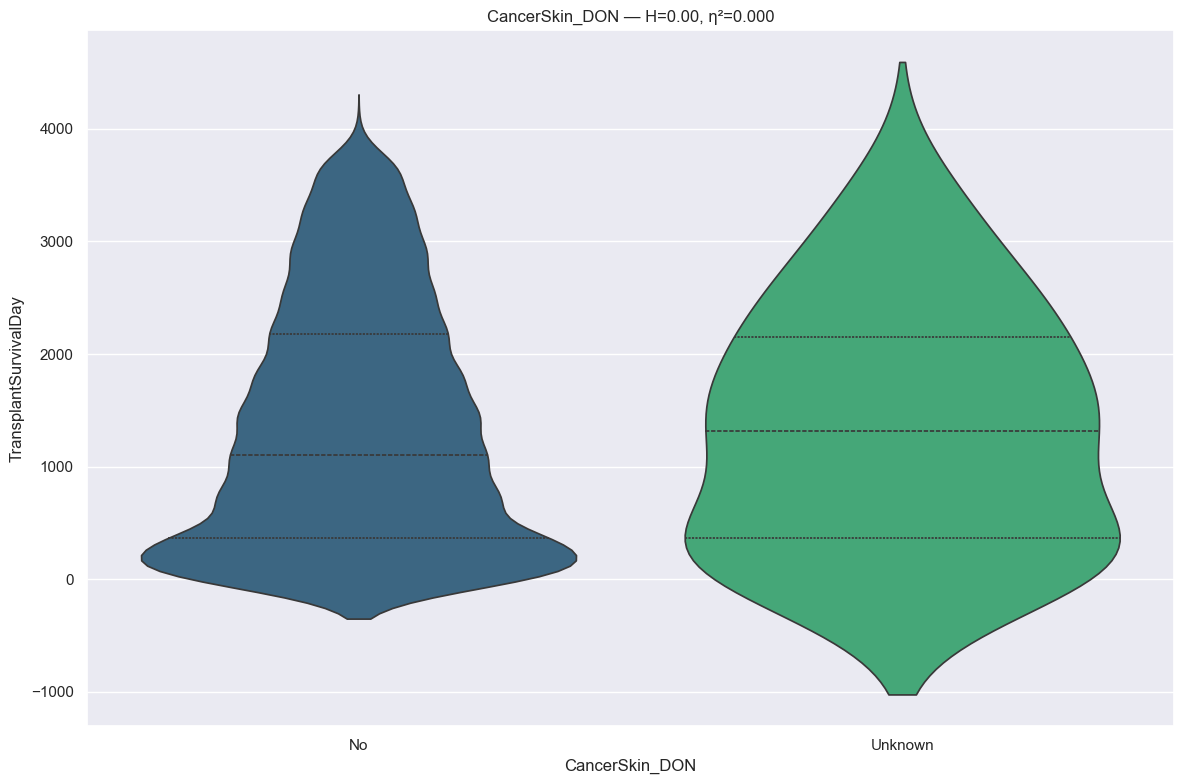

RANKING REPORT: CancerSkin_DON (n ≥ 30)
INCLUDED CATEGORIES:
 * No                                                :   8258 records
 * Unknown                                           :     38 records
BYPASSED CATEGORIES (n < min_n):
 * Missing                                           :     14 records
 * Yes                                               :      9 records
--------------------------------------------------------------------------------
Kruskal H: 0.0006 | P-value: 9.799059e-01 | Effect η²: 0.0000
Correction Method: BONFERRONI
Pairwise Testing (Bonferroni Alpha: 0.0500 | r_threshold: 0.10)
--------------------------------------------------------------------------------
No           vs Unknown      | p=9.7993e-01 | thr=0.0500 | r=-0.002 | Not Sig
::::: Collapsed into 1 groups (excluding 'Other') :::::



In [168]:
# instantiate class
ranker = NominalSurvivalRanker.NominalSurvivalRanker(
    method="bonferroni",  # bonferroni, Holm-Bonferroni (holm) Benjamini–Hochberg (fdr)
    r_thresh=0.10,        # Lower r-threshold (strict merging)
)
# initialize variable
results = ranker.fit(df, features[0])
# mapping DataFrame
new_row = pd.DataFrame([ranker.build_feature_dict(results)])
mapping_df = pd.concat([mapping_df, new_row], ignore_index=True)

In [169]:
# mapping dictionary
print(results['mapping'])
mean_survival_by_category(df, features[0])

{'No': 'Group_1', 'Unknown': 'Group_1', 'Missing': 'Other', 'Yes': 'Other'}


,CancerSkin_DON,mean_survival_days,record_count
1,No,1338.972875,8258
2,Unknown,1327.368421,38
0,Missing,1034.000000,14
3,Yes,1255.000000,9


In [170]:
# mapping - Combining Unknown & Missing them preserves interpretability
mapping = {'Missing': 'Other',
           'Unknown': 'Other'
          }
# map the change
df[features[0]] = (df[features[0]].map(mapping).fillna(df[features[0]]))

# sanity check
mean_survival_by_category(df, features[0])

,CancerSkin_DON,mean_survival_days,record_count
0,No,1338.972875,8258
1,Other,1248.384615,52
2,Yes,1255.000000,9


#### Serology Anti CMV

In [171]:
# info
features = u.get_feature_info(df, 'SerologyAntiCMV', cat=False)
# dtype
{col: df[col].dtype for col in features}

                    count unique       top  freq
SerologyAntiCMV_DON  8319      5  Positive  5651

:::: NaN Count:
SerologyAntiCMV_DON    0 



{'SerologyAntiCMV_DON': CategoricalDtype(categories=['Indeterminate', 'Missing', 'Negative', 'Not Done',
                   'Positive', 'Unknown'],
 , ordered=False, categories_dtype=object)}

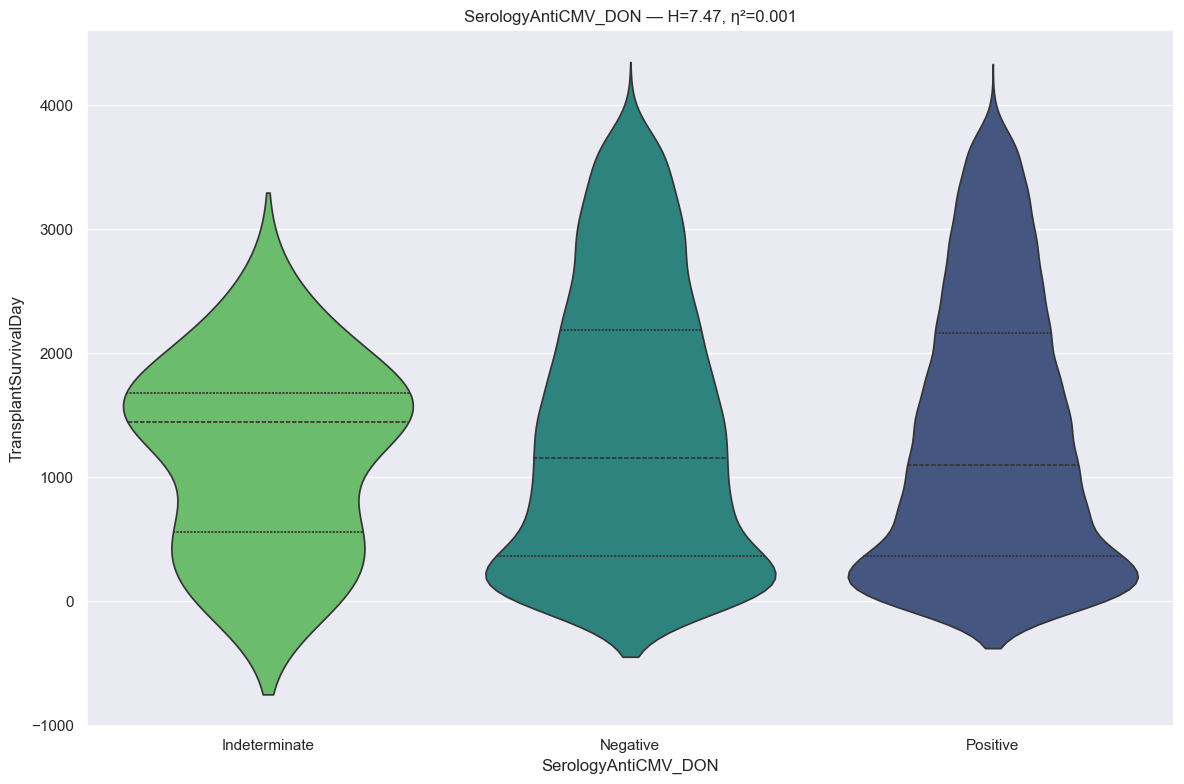

RANKING REPORT: SerologyAntiCMV_DON (n ≥ 30)
INCLUDED CATEGORIES:
 * Indeterminate                                     :     30 records
 * Negative                                          :   2628 records
 * Positive                                          :   5651 records
BYPASSED CATEGORIES (n < min_n):
 * Missing                                           :      3 records
 * Not Done                                          :      7 records
--------------------------------------------------------------------------------
Kruskal H: 7.4714 | P-value: 2.385595e-02 | Effect η²: 0.0007
Correction Method: BONFERRONI
Pairwise Testing (Bonferroni Alpha: 0.0167 | r_threshold: 0.10)
--------------------------------------------------------------------------------
Negative     vs Positive     | p=7.1413e-03 | thr=0.0167 | r=-0.037 | *Sig*
Indeterminate vs Negative     | p=4.5574e-01 | thr=0.0167 | r= 0.079 | Not Sig
Indeterminate vs Positive     | p=7.2758e-01 | thr=0.0167 | r= 0.037 | Not Sig

In [172]:
# instantiate class
ranker = NominalSurvivalRanker.NominalSurvivalRanker(
    method="bonferroni",  # bonferroni, Holm-Bonferroni (holm) Benjamini–Hochberg (fdr)
    r_thresh=0.10,        # Lower r-threshold (strict merging)
)
# initialize variable
results = ranker.fit(df, features[0])
# mapping DataFrame
new_row = pd.DataFrame([ranker.build_feature_dict(results)])
mapping_df = pd.concat([mapping_df, new_row], ignore_index=True)

In [173]:
# mapping dictionary
print(results['mapping'])
mean_survival_by_category(df, features[0])

{'Indeterminate': 'Group_1', 'Negative': 'Group_1', 'Positive': 'Group_1', 'Missing': 'Other', 'Not Done': 'Other'}


,SerologyAntiCMV_DON,mean_survival_days,record_count
4,Positive,1315.758096,5651
2,Negative,1388.100837,2628
0,Indeterminate,1177.966667,30
3,Not Done,1698.000000,7
1,Missing,982.000000,3


In [174]:
# mapping - Combining them: underpoer sample size
mapping = {'Indeterminate': 'Other',
           'Not Done': 'Other',
           'Missing': 'Other'
          }
# map the change
df[features[0]] = (df[features[0]].map(mapping).fillna(df[features[0]]))

# sanity check
mean_survival_by_category(df, features[0])

,SerologyAntiCMV_DON,mean_survival_days,record_count
2,Positive,1315.758096,5651
0,Negative,1388.100837,2628
1,Other,1254.275000,40


#### Cause Of Death

In [175]:
# info
features = u.get_feature_info(df, 'CauseOfDeath', cat=False)
# dtype
{col: df[col].dtype for col in features}

                 count unique     top  freq
CauseOfDeath_DON  8319      6  ANOXIA  3503

:::: NaN Count:
CauseOfDeath_DON    0 



{'CauseOfDeath_DON': CategoricalDtype(categories=['ANOXIA', 'CEREBROVASCULAR/STROKE', 'CNS TUMOR',
                   'HEAD TRAUMA', 'Missing', 'OTHER SPECIFY'],
 , ordered=False, categories_dtype=object)}

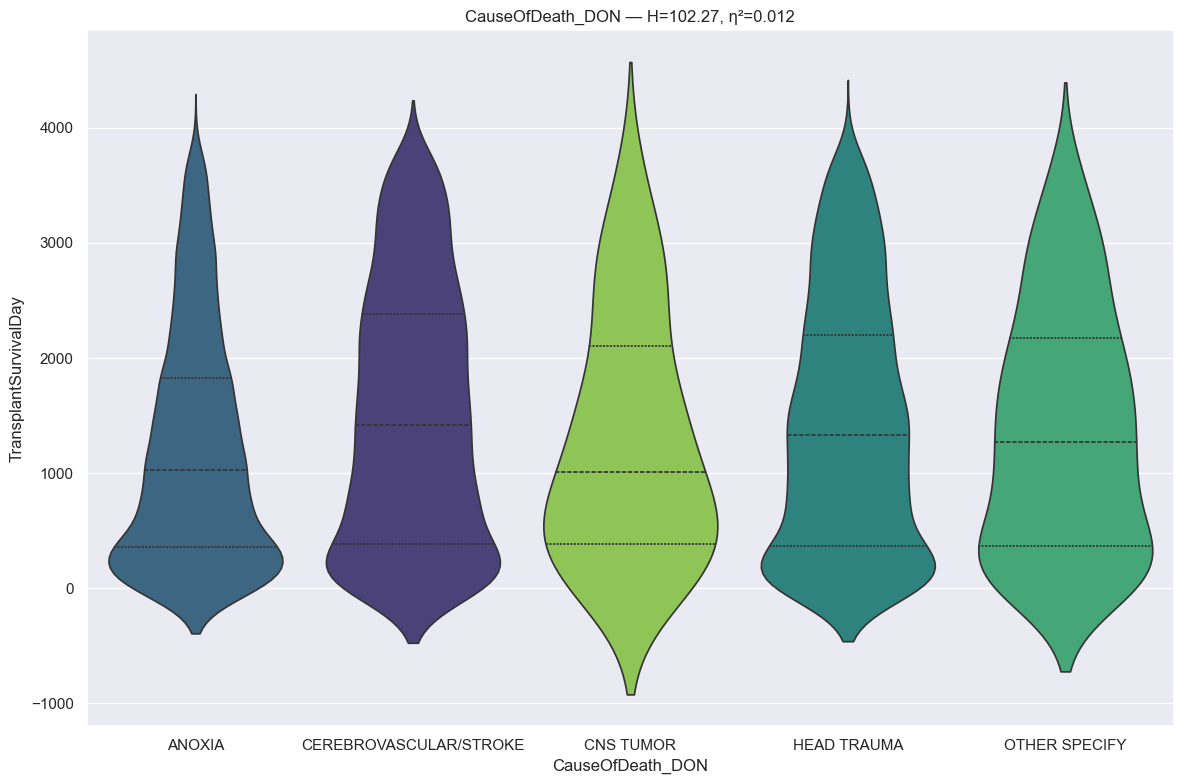

RANKING REPORT: CauseOfDeath_DON (n ≥ 30)
INCLUDED CATEGORIES:
 * ANOXIA                                            :   3503 records
 * CEREBROVASCULAR/STROKE                            :   2227 records
 * CNS TUMOR                                         :     57 records
 * HEAD TRAUMA                                       :   2327 records
 * OTHER SPECIFY                                     :    204 records
BYPASSED CATEGORIES (n < min_n):
 * Missing                                           :      1 records
--------------------------------------------------------------------------------
Kruskal H: 102.2651 | P-value: 3.239786e-21 | Effect η²: 0.0118
Correction Method: BONFERRONI
Pairwise Testing (Bonferroni Alpha: 0.0050 | r_threshold: 0.10)
--------------------------------------------------------------------------------
ANOXIA       vs CEREBROVASCULAR/STROKE | p=1.5118e-20 | thr=0.0050 | r= 0.145 | *Sig*
ANOXIA       vs HEAD TRAUMA  | p=4.0058e-13 | thr=0.0050 | r= 0.112 | *Sig*
AN

In [176]:
# instantiate class
ranker = NominalSurvivalRanker.NominalSurvivalRanker(
    method="bonferroni",  # bonferroni, Holm-Bonferroni (holm) Benjamini–Hochberg (fdr)
    r_thresh=0.10,        # Lower r-threshold (strict merging)
)
# initialize variable
results = ranker.fit(df, features[0])
# mapping DataFrame
new_row = pd.DataFrame([ranker.build_feature_dict(results)])
mapping_df = pd.concat([mapping_df, new_row], ignore_index=True)

In [177]:
# mapping dictionary
print(results['mapping'])
mean_survival_by_category(df, features[0])

{'ANOXIA': 'Group_1', 'CEREBROVASCULAR/STROKE': 'Group_1', 'CNS TUMOR': 'Group_1', 'HEAD TRAUMA': 'Group_1', 'OTHER SPECIFY': 'Group_1', 'Missing': 'Other'}


,CauseOfDeath_DON,mean_survival_days,record_count
0,ANOXIA,1192.697117,3503
3,HEAD TRAUMA,1416.577997,2327
1,CEREBROVASCULAR/STROKE,1484.318815,2227
5,OTHER SPECIFY,1366.254902,204
2,CNS TUMOR,1279.526316,57
4,Missing,1827.000000,1


In [178]:
# instantiate class
ranker = NominalSurvivalRanker.NominalSurvivalRanker(
    method="fdr",  # bonferroni, Holm-Bonferroni (holm) Benjamini–Hochberg (fdr)
    r_thresh=0.05,        # Lower r-threshold (strict merging)
    plot=False
)
# initialize variable
results = ranker.fit(df, features[0])
# mapping DataFrame & remove last entry 
mapping_df = mapping_df[mapping_df["feature"] != features[0]]
new_row = pd.DataFrame([ranker.build_feature_dict(results)])
mapping_df = pd.concat([mapping_df, new_row], ignore_index=True)

RANKING REPORT: CauseOfDeath_DON (n ≥ 30)
INCLUDED CATEGORIES:
 * ANOXIA                                            :   3503 records
 * CEREBROVASCULAR/STROKE                            :   2227 records
 * CNS TUMOR                                         :     57 records
 * HEAD TRAUMA                                       :   2327 records
 * OTHER SPECIFY                                     :    204 records
BYPASSED CATEGORIES (n < min_n):
 * Missing                                           :      1 records
--------------------------------------------------------------------------------
Kruskal H: 102.2651 | P-value: 3.239786e-21 | Effect η²: 0.0118
Correction Method: FDR
Pairwise Testing (Base Alpha: 0.05 | Method: FDR | r_threshold: 0.05)
--------------------------------------------------------------------------------
ANOXIA       vs CEREBROVASCULAR/STROKE | p=1.5118e-20 | fdr_alpha=0.05 | r= 0.145 | *Sig*
ANOXIA       vs HEAD TRAUMA  | p=4.0058e-13 | fdr_alpha=0.05 | r= 0.112 | *

In [179]:
# mapping dictionary
print(results['mapping'])
mean_survival_by_category(df, features[0])

{'ANOXIA': 'Group_1', 'CEREBROVASCULAR/STROKE': 'Group_2', 'CNS TUMOR': 'Group_2', 'HEAD TRAUMA': 'Group_2', 'OTHER SPECIFY': 'Group_2', 'Missing': 'Other'}


,CauseOfDeath_DON,mean_survival_days,record_count
0,ANOXIA,1192.697117,3503
3,HEAD TRAUMA,1416.577997,2327
1,CEREBROVASCULAR/STROKE,1484.318815,2227
5,OTHER SPECIFY,1366.254902,204
2,CNS TUMOR,1279.526316,57
4,Missing,1827.000000,1


In [180]:
# mapping dictionary
collapse_map = results['mapping']
# New feature
df[features[0] + "_group"] = (
    df[features[0]]
    .map(collapse_map)
    .astype("category")
)
# add to remove list
remove_cols.extend(features)
# update feature with new name
mapping_df.loc[mapping_df["feature"].isin(features), "feature"] = mapping_df["feature"] + "_group"
# sanity check
df[features[0] + "_group"].isna().any()

np.False_

#### Death Mechanism

In [181]:
# info
features = u.get_feature_info(df, 'DeathMechanism', cat=False)
# dtype
{col: df[col].dtype for col in features}

                   count unique                             top  freq
DeathMechanism_DON  8319     13  INTRACRANIAL HEMORRHAGE/STROKE  2265

:::: NaN Count:
DeathMechanism_DON    0 



{'DeathMechanism_DON': CategoricalDtype(categories=['ASPHYXIATION', 'BLUNT INJURY', 'CARDIOVASCULAR',
                   'DEATH FROM NATURAL CAUSES', 'DROWNING', 'DRUG INTOXICATION',
                   'ELECTRICAL', 'GUNSHOT WOUND',
                   'INTRACRANIAL HEMORRHAGE/STROKE', 'Missing',
                   'NONE OF THE ABOVE', 'SEIZURE', 'STAB'],
 , ordered=False, categories_dtype=object)}

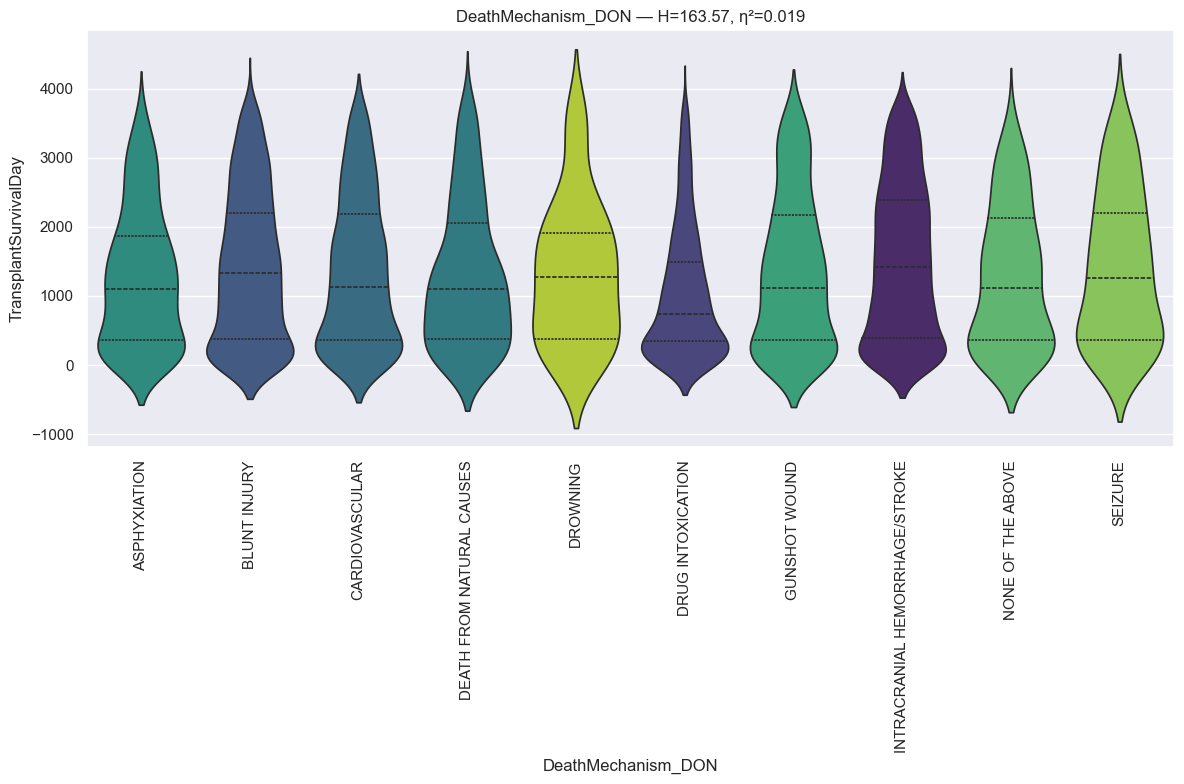

RANKING REPORT: DeathMechanism_DON (n ≥ 30)
INCLUDED CATEGORIES:
 * ASPHYXIATION                                      :    508 records
 * BLUNT INJURY                                      :   1682 records
 * CARDIOVASCULAR                                    :    946 records
 * DEATH FROM NATURAL CAUSES                         :    300 records
 * DROWNING                                          :     57 records
 * DRUG INTOXICATION                                 :   1616 records
 * GUNSHOT WOUND                                     :    593 records
 * INTRACRANIAL HEMORRHAGE/STROKE                    :   2265 records
 * NONE OF THE ABOVE                                 :    221 records
 * SEIZURE                                           :    120 records
BYPASSED CATEGORIES (n < min_n):
 * ELECTRICAL                                        :      1 records
 * Missing                                           :      3 records
 * STAB                                              :      7 

In [182]:
# instantiate class
ranker = NominalSurvivalRanker.NominalSurvivalRanker(
    method="bonferroni",  # bonferroni, Holm-Bonferroni (holm) Benjamini–Hochberg (fdr)
    r_thresh=0.10,        # Lower r-threshold (strict merging)
    suppress_pairwise=True,
    rotation = 90
)
# initialize variable
results = ranker.fit(df, features[0])
# mapping DataFrame
new_row = pd.DataFrame([ranker.build_feature_dict(results)])
mapping_df = pd.concat([mapping_df, new_row], ignore_index=True)

In [183]:
# mapping dictionary
print(results['mapping'])
mean_survival_by_category(df, features[0])

{'ASPHYXIATION': 'Group_1', 'BLUNT INJURY': 'Group_1', 'CARDIOVASCULAR': 'Group_1', 'DEATH FROM NATURAL CAUSES': 'Group_1', 'DROWNING': 'Group_1', 'GUNSHOT WOUND': 'Group_1', 'INTRACRANIAL HEMORRHAGE/STROKE': 'Group_1', 'NONE OF THE ABOVE': 'Group_1', 'SEIZURE': 'Group_1', 'DRUG INTOXICATION': 'Group_2', 'ELECTRICAL': 'Other', 'Missing': 'Other', 'STAB': 'Other'}


,DeathMechanism_DON,mean_survival_days,record_count
8,INTRACRANIAL HEMORRHAGE/STROKE,1491.563355,2265
1,BLUNT INJURY,1414.098692,1682
5,DRUG INTOXICATION,1044.862624,1616
2,CARDIOVASCULAR,1362.859408,946
7,GUNSHOT WOUND,1364.575042,593
0,ASPHYXIATION,1291.187008,508
3,DEATH FROM NATURAL CAUSES,1307.960000,300
10,NONE OF THE ABOVE,1278.909502,221
11,SEIZURE,1407.583333,120
4,DROWNING,1348.228070,57


In [184]:
# instantiate class
ranker = NominalSurvivalRanker.NominalSurvivalRanker(
    method="bonferroni",  # bonferroni, Holm-Bonferroni (holm) Benjamini–Hochberg (fdr)
    r_thresh=0.05,        # Lower r-threshold (strict merging)
    plot=False,
    suppress_pairwise=True
)
# initialize variable
results = ranker.fit(df, features[0])
# mapping DataFrame & remove last entry 
mapping_df = mapping_df[mapping_df["feature"] != features[0]]
new_row = pd.DataFrame([ranker.build_feature_dict(results)])
mapping_df = pd.concat([mapping_df, new_row], ignore_index=True)

RANKING REPORT: DeathMechanism_DON (n ≥ 30)
INCLUDED CATEGORIES:
 * ASPHYXIATION                                      :    508 records
 * BLUNT INJURY                                      :   1682 records
 * CARDIOVASCULAR                                    :    946 records
 * DEATH FROM NATURAL CAUSES                         :    300 records
 * DROWNING                                          :     57 records
 * DRUG INTOXICATION                                 :   1616 records
 * GUNSHOT WOUND                                     :    593 records
 * INTRACRANIAL HEMORRHAGE/STROKE                    :   2265 records
 * NONE OF THE ABOVE                                 :    221 records
 * SEIZURE                                           :    120 records
BYPASSED CATEGORIES (n < min_n):
 * ELECTRICAL                                        :      1 records
 * Missing                                           :      3 records
 * STAB                                              :      7 

In [185]:
# mapping dictionary
print(results['mapping'])
mean_survival_by_category(df, features[0])

{'ASPHYXIATION': 'Group_1', 'BLUNT INJURY': 'Group_1', 'CARDIOVASCULAR': 'Group_1', 'DEATH FROM NATURAL CAUSES': 'Group_1', 'DROWNING': 'Group_1', 'GUNSHOT WOUND': 'Group_1', 'INTRACRANIAL HEMORRHAGE/STROKE': 'Group_1', 'NONE OF THE ABOVE': 'Group_1', 'SEIZURE': 'Group_1', 'DRUG INTOXICATION': 'Group_2', 'ELECTRICAL': 'Other', 'Missing': 'Other', 'STAB': 'Other'}


,DeathMechanism_DON,mean_survival_days,record_count
8,INTRACRANIAL HEMORRHAGE/STROKE,1491.563355,2265
1,BLUNT INJURY,1414.098692,1682
5,DRUG INTOXICATION,1044.862624,1616
2,CARDIOVASCULAR,1362.859408,946
7,GUNSHOT WOUND,1364.575042,593
0,ASPHYXIATION,1291.187008,508
3,DEATH FROM NATURAL CAUSES,1307.960000,300
10,NONE OF THE ABOVE,1278.909502,221
11,SEIZURE,1407.583333,120
4,DROWNING,1348.228070,57


In [186]:
# instantiate class
ranker = NominalSurvivalRanker.NominalSurvivalRanker(
    method="holm",        # bonferroni, Holm-Bonferroni (holm) Benjamini–Hochberg (fdr)
    r_thresh=0.05,        # Lower r-threshold (strict merging)
    plot=False,
    suppress_pairwise=True
)
# initialize variable
results = ranker.fit(df, features[0])
# mapping DataFrame & remove last entry 
mapping_df = mapping_df[mapping_df["feature"] != features[0]]
new_row = pd.DataFrame([ranker.build_feature_dict(results)])
mapping_df = pd.concat([mapping_df, new_row], ignore_index=True)

RANKING REPORT: DeathMechanism_DON (n ≥ 30)
INCLUDED CATEGORIES:
 * ASPHYXIATION                                      :    508 records
 * BLUNT INJURY                                      :   1682 records
 * CARDIOVASCULAR                                    :    946 records
 * DEATH FROM NATURAL CAUSES                         :    300 records
 * DROWNING                                          :     57 records
 * DRUG INTOXICATION                                 :   1616 records
 * GUNSHOT WOUND                                     :    593 records
 * INTRACRANIAL HEMORRHAGE/STROKE                    :   2265 records
 * NONE OF THE ABOVE                                 :    221 records
 * SEIZURE                                           :    120 records
BYPASSED CATEGORIES (n < min_n):
 * ELECTRICAL                                        :      1 records
 * Missing                                           :      3 records
 * STAB                                              :      7 

In [187]:
# mapping dictionary
print(results['mapping'])
mean_survival_by_category(df, features[0])

{'ASPHYXIATION': 'Group_1', 'BLUNT INJURY': 'Group_1', 'CARDIOVASCULAR': 'Group_1', 'DEATH FROM NATURAL CAUSES': 'Group_1', 'DROWNING': 'Group_1', 'GUNSHOT WOUND': 'Group_1', 'INTRACRANIAL HEMORRHAGE/STROKE': 'Group_1', 'NONE OF THE ABOVE': 'Group_1', 'SEIZURE': 'Group_1', 'DRUG INTOXICATION': 'Group_2', 'ELECTRICAL': 'Other', 'Missing': 'Other', 'STAB': 'Other'}


,DeathMechanism_DON,mean_survival_days,record_count
8,INTRACRANIAL HEMORRHAGE/STROKE,1491.563355,2265
1,BLUNT INJURY,1414.098692,1682
5,DRUG INTOXICATION,1044.862624,1616
2,CARDIOVASCULAR,1362.859408,946
7,GUNSHOT WOUND,1364.575042,593
0,ASPHYXIATION,1291.187008,508
3,DEATH FROM NATURAL CAUSES,1307.960000,300
10,NONE OF THE ABOVE,1278.909502,221
11,SEIZURE,1407.583333,120
4,DROWNING,1348.228070,57


In [188]:
# mapping dictionary
collapse_map = results['mapping']
# New feature
df[features[0] + "_group"] = (
    df[features[0]]
    .map(collapse_map)
    .astype("category")
)
# add to remove list
remove_cols.extend(features)
# update feature with new name
mapping_df.loc[mapping_df["feature"].isin(features), "feature"] = mapping_df["feature"] + "_group"
# sanity check
df[features[0] + "_group"].isna().any()

np.False_

#### Heparin Management

In [189]:
# info
features = u.get_feature_info(df, 'HeparinManagement', cat=False)
# dtype
{col: df[col].dtype for col in features}

                      count unique  top  freq
HeparinManagement_DON  8319      3  Yes  8179

:::: NaN Count:
HeparinManagement_DON    0 



{'HeparinManagement_DON': CategoricalDtype(categories=['Missing', 'No', 'Unknown', 'Yes'], ordered=False, categories_dtype=object)}

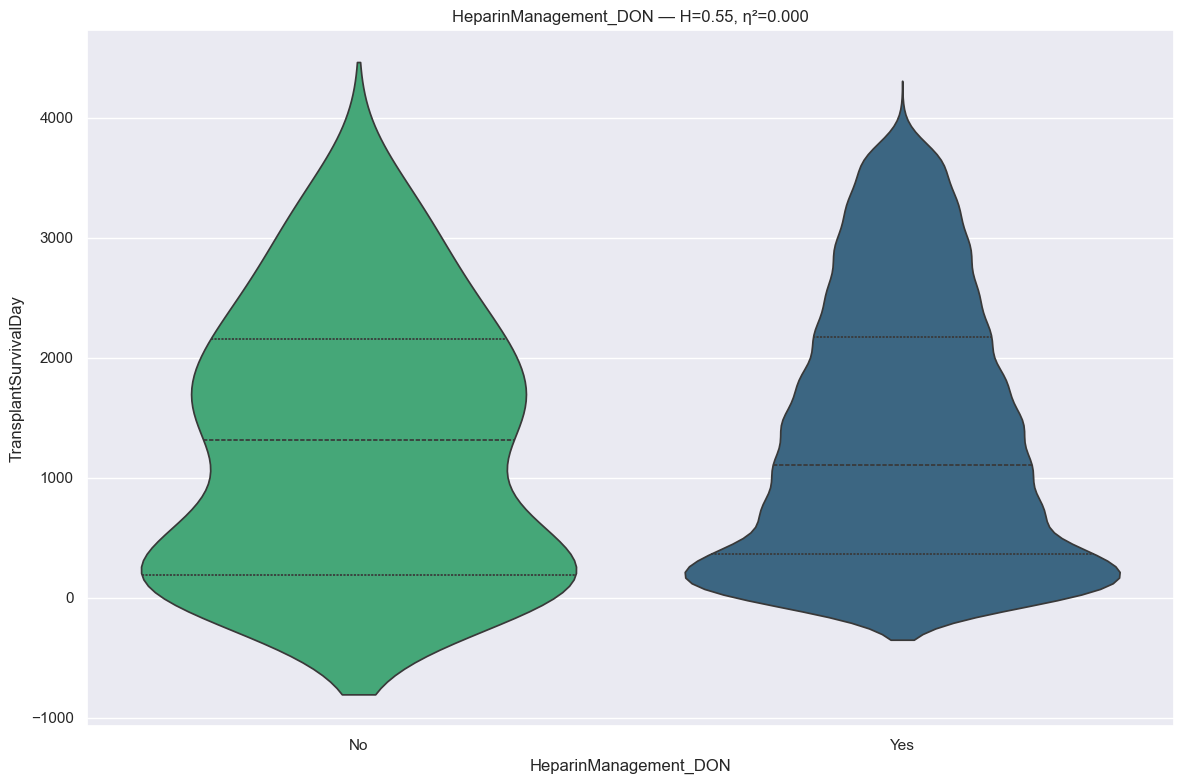

RANKING REPORT: HeparinManagement_DON (n ≥ 30)
INCLUDED CATEGORIES:
 * No                                                :    126 records
 * Yes                                               :   8179 records
BYPASSED CATEGORIES (n < min_n):
 * Missing                                           :     14 records
--------------------------------------------------------------------------------
Kruskal H: 0.5522 | P-value: 4.574247e-01 | Effect η²: 0.0000
Correction Method: BONFERRONI
Pairwise Testing (Bonferroni Alpha: 0.0500 | r_threshold: 0.10)
--------------------------------------------------------------------------------
No           vs Yes          | p=4.5744e-01 | thr=0.0500 | r= 0.039 | Not Sig
::::: Collapsed into 1 groups (excluding 'Other') :::::



In [190]:
# instantiate class
ranker = NominalSurvivalRanker.NominalSurvivalRanker(
    method="bonferroni",  # bonferroni, Holm-Bonferroni (holm) Benjamini–Hochberg (fdr)
    r_thresh=0.10,        # Lower r-threshold (strict merging)
)
# initialize variable
results = ranker.fit(df, features[0])
# mapping DataFrame
new_row = pd.DataFrame([ranker.build_feature_dict(results)])
mapping_df = pd.concat([mapping_df, new_row], ignore_index=True)

In [191]:
# mapping dictionary
print(results['mapping'])
mean_survival_by_category(df, features[0])

{'No': 'Group_1', 'Yes': 'Group_1', 'Missing': 'Other'}


,HeparinManagement_DON,mean_survival_days,record_count
2,Yes,1339.667074,8179
1,No,1284.412698,126
0,Missing,1034.000000,14


#### Arginnie Management

In [192]:
# info
features = u.get_feature_info(df, 'ArginnieManagement', cat=False)
# dtype
{col: df[col].dtype for col in features}

                       count unique  top  freq
ArginnieManagement_DON  8319      4  Yes  5536

:::: NaN Count:
ArginnieManagement_DON    0 



{'ArginnieManagement_DON': CategoricalDtype(categories=['Missing', 'No', 'Unknown', 'Yes'], ordered=False, categories_dtype=object)}

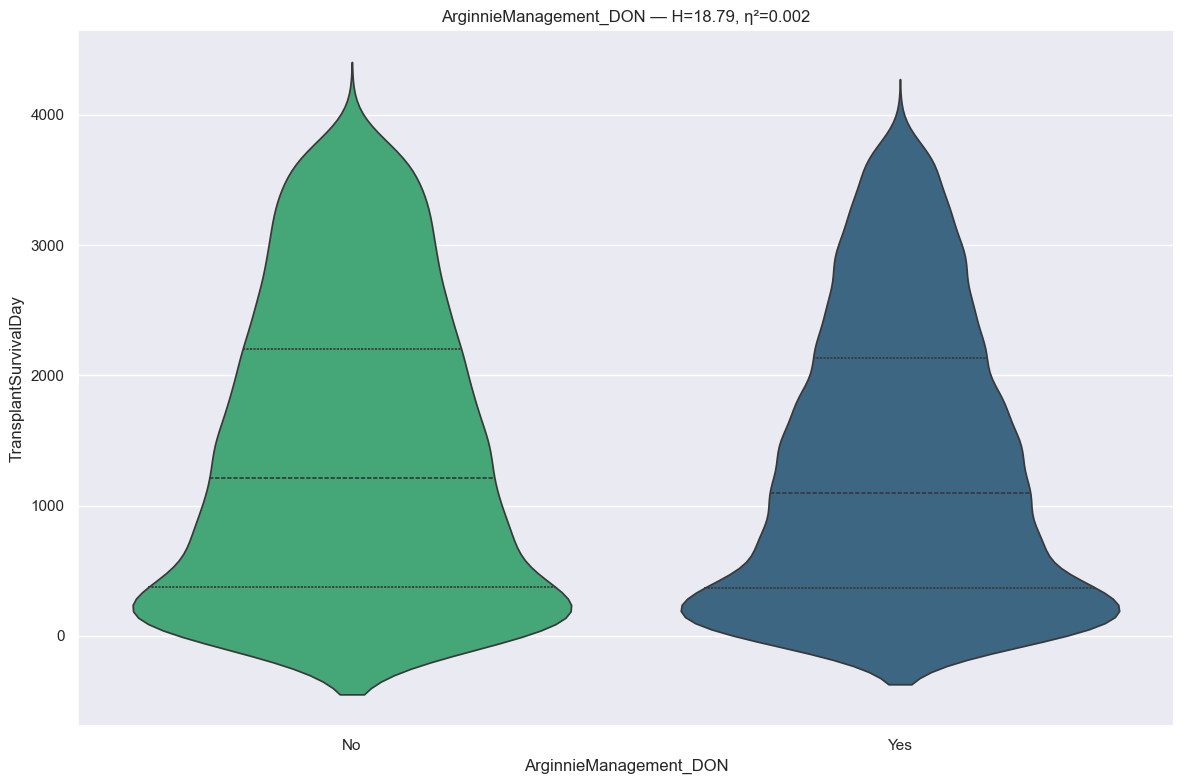

RANKING REPORT: ArginnieManagement_DON (n ≥ 30)
INCLUDED CATEGORIES:
 * No                                                :   2767 records
 * Yes                                               :   5536 records
BYPASSED CATEGORIES (n < min_n):
 * Missing                                           :     14 records
 * Unknown                                           :      2 records
--------------------------------------------------------------------------------
Kruskal H: 18.7928 | P-value: 1.457169e-05 | Effect η²: 0.0021
Correction Method: BONFERRONI
Pairwise Testing (Bonferroni Alpha: 0.0500 | r_threshold: 0.10)
--------------------------------------------------------------------------------
No           vs Yes          | p=1.4572e-05 | thr=0.0500 | r=-0.058 | *Sig*
::::: Collapsed into 2 groups (excluding 'Other') :::::



In [193]:
# instantiate class
ranker = NominalSurvivalRanker.NominalSurvivalRanker(
    method="bonferroni",  # bonferroni, Holm-Bonferroni (holm) Benjamini–Hochberg (fdr)
    r_thresh=0.10,        # Lower r-threshold (strict merging)
)
# initialize variable
results = ranker.fit(df, features[0])
# mapping DataFrame
new_row = pd.DataFrame([ranker.build_feature_dict(results)])
mapping_df = pd.concat([mapping_df, new_row], ignore_index=True)

In [194]:
# mapping dictionary
print(results['mapping'])
mean_survival_by_category(df, features[0])

{'No': 'Group_1', 'Yes': 'Group_2', 'Missing': 'Other', 'Unknown': 'Other'}


,ArginnieManagement_DON,mean_survival_days,record_count
3,Yes,1299.734104,5536
1,No,1416.767618,2767
0,Missing,1034.000000,14
2,Unknown,1724.500000,2


In [195]:
# Collapse Missing & Unknown into Other: underpowered small sample size
# mapping
mapping = {'Unknown': 'Other',
           'Missing': 'Other'
          }
# map the change
df[features[0]] = (df[features[0]].map(mapping).fillna(df[features[0]]))
# sanity check
mean_survival_by_category(df,features[0])

,ArginnieManagement_DON,mean_survival_days,record_count
2,Yes,1299.734104,5536
0,No,1416.767618,2767
1,Other,1120.312500,16


#### Insulin Management

In [196]:
# info
features = u.get_feature_info(df, 'InsulinManagement', cat=False)
# dtype
{col: df[col].dtype for col in features}

                      count unique  top  freq
InsulinManagement_DON  8319      4  Yes  4972

:::: NaN Count:
InsulinManagement_DON    0 



{'InsulinManagement_DON': CategoricalDtype(categories=['Missing', 'No', 'Unknown', 'Yes'], ordered=False, categories_dtype=object)}

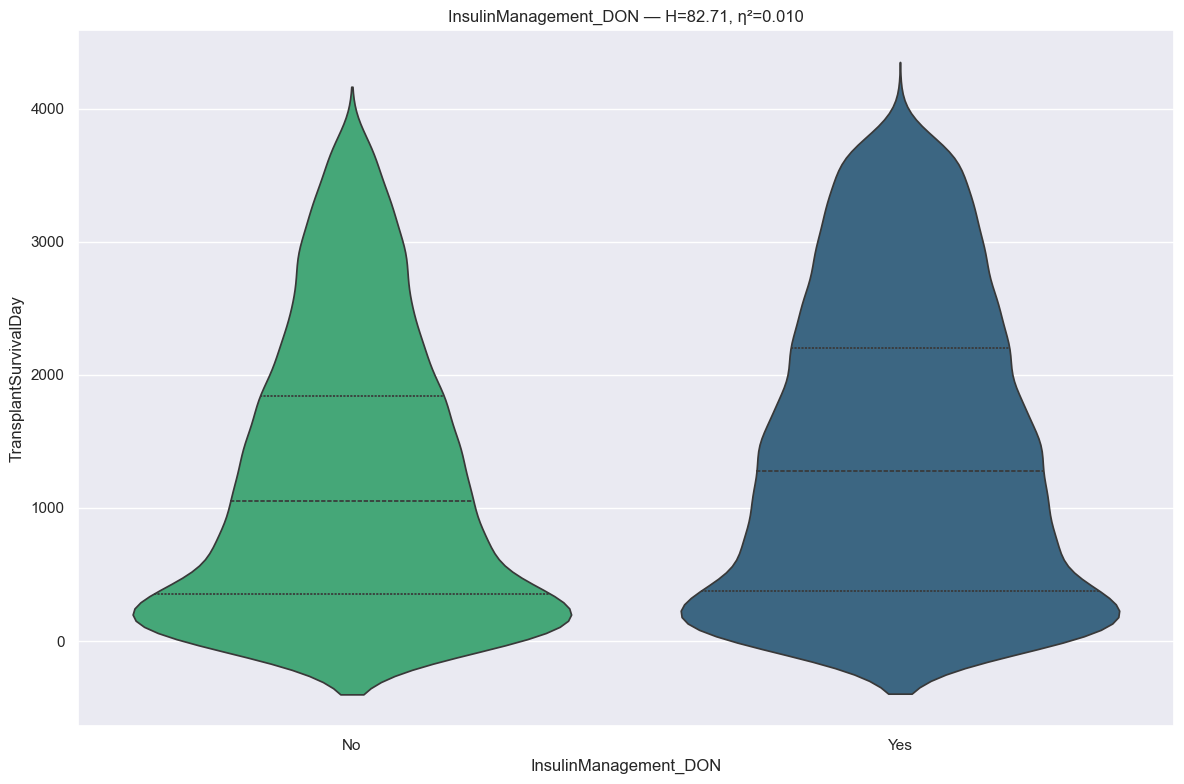

RANKING REPORT: InsulinManagement_DON (n ≥ 30)
INCLUDED CATEGORIES:
 * No                                                :   3330 records
 * Yes                                               :   4972 records
BYPASSED CATEGORIES (n < min_n):
 * Missing                                           :     14 records
 * Unknown                                           :      3 records
--------------------------------------------------------------------------------
Kruskal H: 82.7112 | P-value: 9.496394e-20 | Effect η²: 0.0098
Correction Method: BONFERRONI
Pairwise Testing (Bonferroni Alpha: 0.0500 | r_threshold: 0.10)
--------------------------------------------------------------------------------
No           vs Yes          | p=9.4968e-20 | thr=0.0500 | r= 0.118 | *Sig*
::::: Collapsed into 2 groups (excluding 'Other') :::::



In [197]:
# instantiate class
ranker = NominalSurvivalRanker.NominalSurvivalRanker(
    method="bonferroni",  # bonferroni, Holm-Bonferroni (holm) Benjamini–Hochberg (fdr)
    r_thresh=0.10,        # Lower r-threshold (strict merging)
)
# initialize variable
results = ranker.fit(df, features[0])
# mapping DataFrame
new_row = pd.DataFrame([ranker.build_feature_dict(results)])
mapping_df = pd.concat([mapping_df, new_row], ignore_index=True)

In [198]:
# mapping dictionary
print(results['mapping'])
mean_survival_by_category(df, features[0])

{'No': 'Group_1', 'Yes': 'Group_2', 'Missing': 'Other', 'Unknown': 'Other'}


,InsulinManagement_DON,mean_survival_days,record_count
3,Yes,1428.060941,4972
1,No,1205.296096,3330
0,Missing,1034.000000,14
2,Unknown,1672.666667,3


In [199]:
# Collapse Missing & Unknown into Other: underpowered, small sample size
# mapping
mapping = {'Unknown': 'Other',
           'Missing': 'Other'
          }
# map the change
df[features[0]] = (df[features[0]].map(mapping).fillna(df[features[0]]))
# sanity check
mean_survival_by_category(df,features[0])

,InsulinManagement_DON,mean_survival_days,record_count
2,Yes,1428.060941,4972
0,No,1205.296096,3330
1,Other,1146.705882,17


#### HBV NAT Result

In [200]:
# info
features = u.get_feature_info(df, 'HBV_NAT_Result', cat=False)
# dtype
{col: df[col].dtype for col in features}

                   count unique       top  freq
HBV_NAT_Result_DON  8319      5  Negative  5716

:::: NaN Count:
HBV_NAT_Result_DON    0 



{'HBV_NAT_Result_DON': CategoricalDtype(categories=['Missing', 'Negative', 'Not Done', 'Positive', 'Unknown'], ordered=False, categories_dtype=object)}

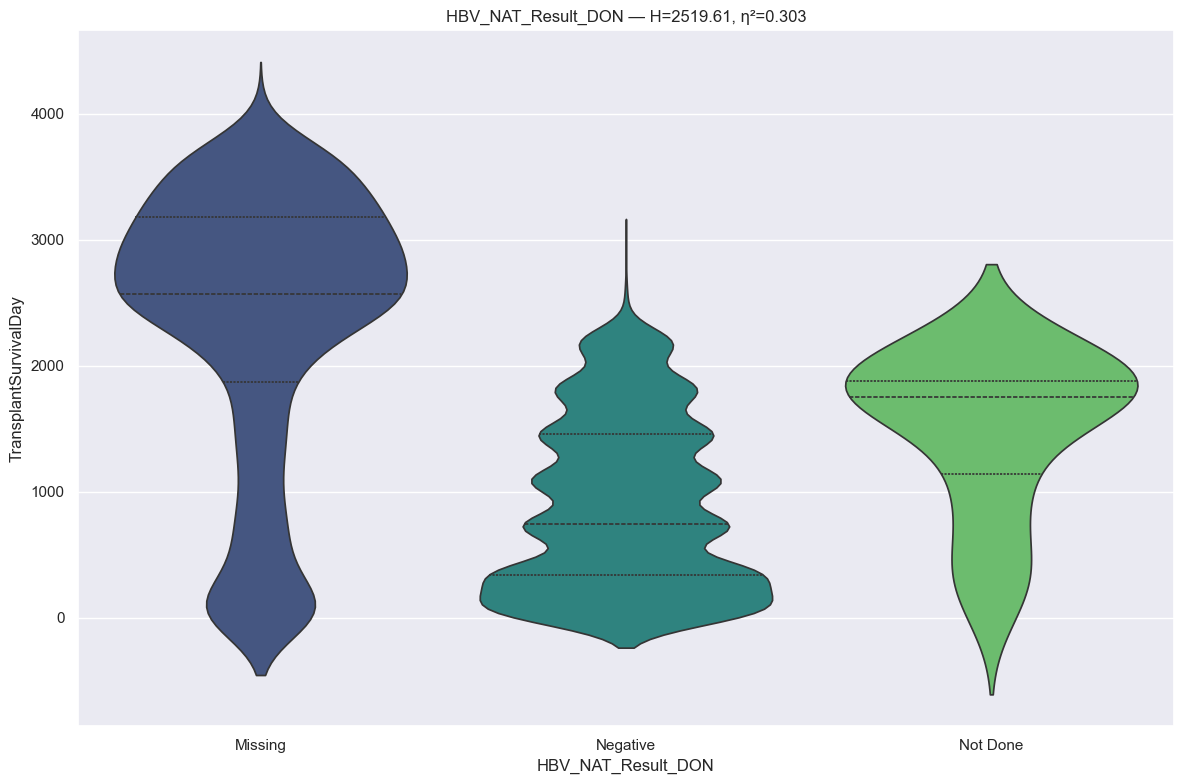

RANKING REPORT: HBV_NAT_Result_DON (n ≥ 30)
INCLUDED CATEGORIES:
 * Missing                                           :   2560 records
 * Negative                                          :   5716 records
 * Not Done                                          :     39 records
BYPASSED CATEGORIES (n < min_n):
 * Positive                                          :      2 records
 * Unknown                                           :      2 records
--------------------------------------------------------------------------------
Kruskal H: 2519.6124 | P-value: 0.000000e+00 | Effect η²: 0.3029
Correction Method: BONFERRONI
Pairwise Testing (Bonferroni Alpha: 0.0167 | r_threshold: 0.10)
--------------------------------------------------------------------------------
Missing      vs Negative     | p=0.0000e+00 | thr=0.0167 | r=-0.687 | *Sig*
Missing      vs Not Done     | p=9.0006e-10 | thr=0.0167 | r=-0.571 | *Sig*
Negative     vs Not Done     | p=2.3043e-07 | thr=0.0167 | r= 0.480 | *Sig*
:::

In [201]:
# instantiate class
ranker = NominalSurvivalRanker.NominalSurvivalRanker(
    method="bonferroni",  # bonferroni, Holm-Bonferroni (holm) Benjamini–Hochberg (fdr)
    r_thresh=0.10,        # Lower r-threshold (strict merging)
)
# initialize variable
results = ranker.fit(df, features[0])
# mapping DataFrame
new_row = pd.DataFrame([ranker.build_feature_dict(results)])
mapping_df = pd.concat([mapping_df, new_row], ignore_index=True)

In [202]:
# mapping dictionary
print(results['mapping'])
mean_survival_by_category(df, features[0])

{'Missing': 'Group_1', 'Negative': 'Group_2', 'Not Done': 'Group_3', 'Positive': 'Other', 'Unknown': 'Other'}


,HBV_NAT_Result_DON,mean_survival_days,record_count
1,Negative,890.328202,5716
0,Missing,2336.584375,2560
2,Not Done,1494.358974,39
3,Positive,549.500000,2
4,Unknown,1649.000000,2


In [203]:
# Collapse Missing & Unknown into Other: underpowered, small sample size
# mapping
mapping = {'Unknown': 'Other',
           'Missing': 'Other'
          }
# map the change
df[features[0]] = (df[features[0]].map(mapping).fillna(df[features[0]]))
# sanity check
mean_survival_by_category(df,features[0])

,HBV_NAT_Result_DON,mean_survival_days,record_count
0,Negative,890.328202,5716
2,Other,2336.047619,2562
1,Not Done,1494.358974,39
3,Positive,549.500000,2


#### HCV NAT Result

In [204]:
# info
features = u.get_feature_info(df, 'HCV_NAT_Result', cat=False)
# dtype
{col: df[col].dtype for col in features}

                   count unique       top  freq
HCV_NAT_Result_DON  8319      5  Negative  5521

:::: NaN Count:
HCV_NAT_Result_DON    0 



{'HCV_NAT_Result_DON': CategoricalDtype(categories=['Indeterminate', 'Missing', 'Negative', 'Not Done',
                   'Positive', 'Unknown'],
 , ordered=False, categories_dtype=object)}

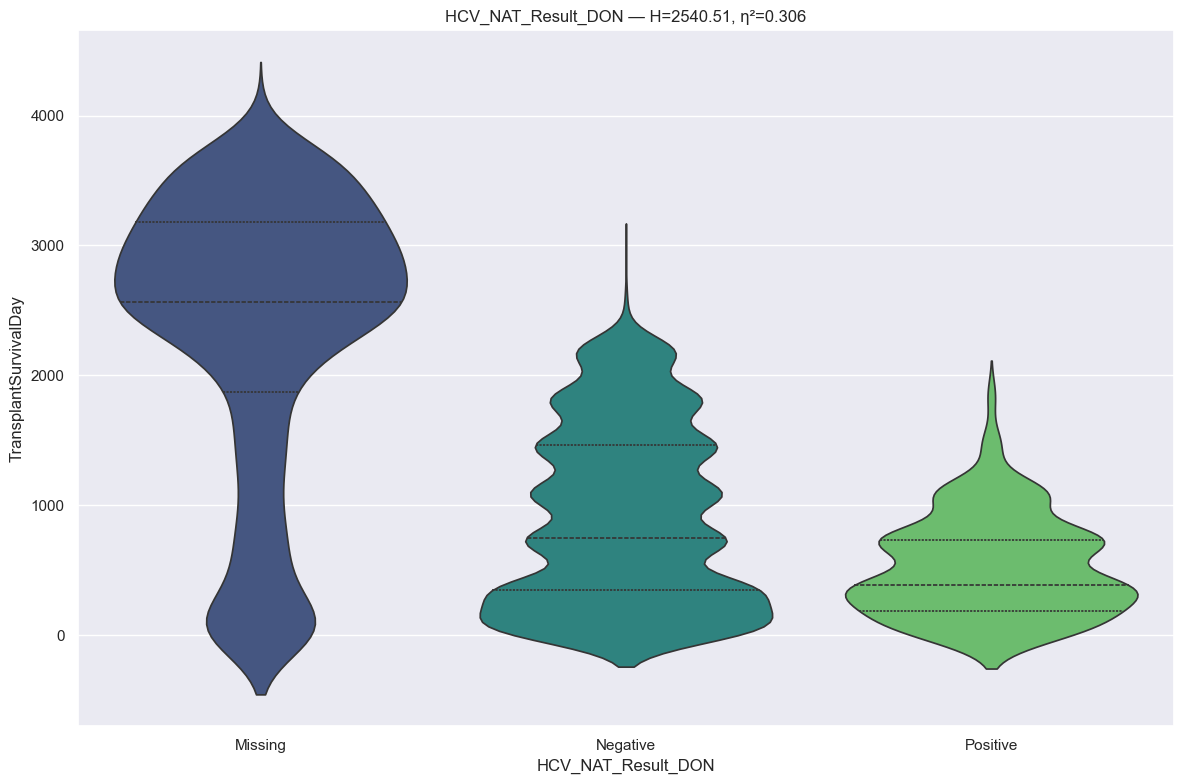

RANKING REPORT: HCV_NAT_Result_DON (n ≥ 30)
INCLUDED CATEGORIES:
 * Missing                                           :   2560 records
 * Negative                                          :   5521 records
 * Positive                                          :    229 records
BYPASSED CATEGORIES (n < min_n):
 * Not Done                                          :      8 records
 * Unknown                                           :      1 records
--------------------------------------------------------------------------------
Kruskal H: 2540.5089 | P-value: 0.000000e+00 | Effect η²: 0.3056
Correction Method: BONFERRONI
Pairwise Testing (Bonferroni Alpha: 0.0167 | r_threshold: 0.10)
--------------------------------------------------------------------------------
Missing      vs Negative     | p=0.0000e+00 | thr=0.0167 | r=-0.684 | *Sig*
Missing      vs Positive     | p=1.6851e-80 | thr=0.0167 | r=-0.757 | *Sig*
Negative     vs Positive     | p=5.3322e-15 | thr=0.0167 | r=-0.304 | *Sig*
:::

In [205]:
# instantiate class
ranker = NominalSurvivalRanker.NominalSurvivalRanker(
    method="bonferroni",  # bonferroni, Holm-Bonferroni (holm) Benjamini–Hochberg (fdr)
    r_thresh=0.10,        # Lower r-threshold (strict merging)
)
# initialize variable
results = ranker.fit(df, features[0])
# mapping DataFrame
new_row = pd.DataFrame([ranker.build_feature_dict(results)])
mapping_df = pd.concat([mapping_df, new_row], ignore_index=True)

In [206]:
# mapping dictionary
print(results['mapping'])
mean_survival_by_category(df, features[0])

{'Missing': 'Group_1', 'Negative': 'Group_2', 'Positive': 'Group_3', 'Not Done': 'Other', 'Unknown': 'Other'}


,HCV_NAT_Result_DON,mean_survival_days,record_count
1,Negative,908.881000,5521
0,Missing,2336.584375,2560
3,Positive,523.310044,229
2,Not Done,1432.375000,8
4,Unknown,2564.000000,1


In [207]:
# Collapse Missing & Unknown into Other: underpowered, small sample size
# mapping
mapping = {'Unknown': 'Other',
           'Missing': 'Other'
          }
# map the change
df[features[0]] = (df[features[0]].map(mapping).fillna(df[features[0]]))
# sanity check
mean_survival_by_category(df,features[0])

,HCV_NAT_Result_DON,mean_survival_days,record_count
0,Negative,908.881000,5521
2,Other,2336.673175,2561
3,Positive,523.310044,229
1,Not Done,1432.375000,8


#### HIV NAT Result

In [208]:
# info
features = u.get_feature_info(df, 'HIV_NAT_Result', cat=False)
# dtype
{col: df[col].dtype for col in features}

                   count unique       top  freq
HIV_NAT_Result_DON  8319      4  Negative  5734

:::: NaN Count:
HIV_NAT_Result_DON    0 



{'HIV_NAT_Result_DON': CategoricalDtype(categories=['Missing', 'Negative', 'Not Done', 'Unknown'], ordered=False, categories_dtype=object)}

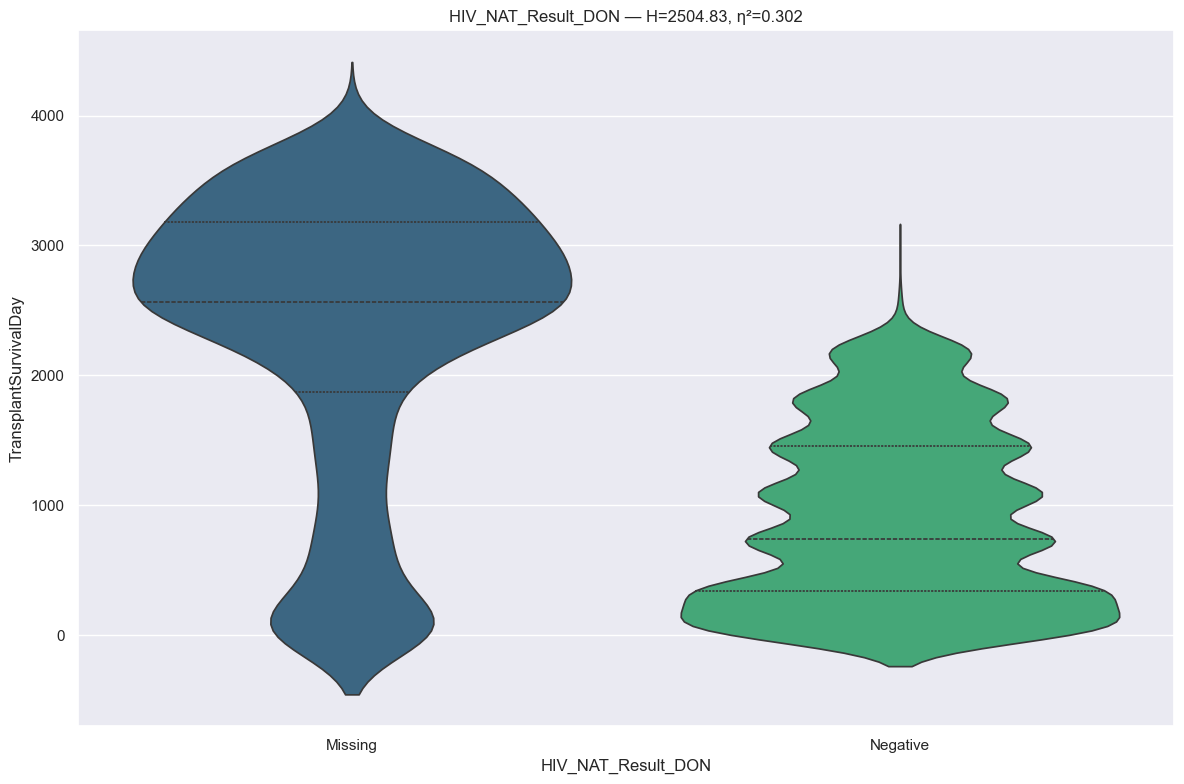

RANKING REPORT: HIV_NAT_Result_DON (n ≥ 30)
INCLUDED CATEGORIES:
 * Missing                                           :   2560 records
 * Negative                                          :   5734 records
BYPASSED CATEGORIES (n < min_n):
 * Not Done                                          :     24 records
 * Unknown                                           :      1 records
--------------------------------------------------------------------------------
Kruskal H: 2504.8261 | P-value: 0.000000e+00 | Effect η²: 0.3020
Correction Method: BONFERRONI
Pairwise Testing (Bonferroni Alpha: 0.0500 | r_threshold: 0.10)
--------------------------------------------------------------------------------
Missing      vs Negative     | p=0.0000e+00 | thr=0.0500 | r=-0.687 | *Sig*
::::: Collapsed into 2 groups (excluding 'Other') :::::



In [209]:
# instantiate class
ranker = NominalSurvivalRanker.NominalSurvivalRanker(
    method="bonferroni",  # bonferroni, Holm-Bonferroni (holm) Benjamini–Hochberg (fdr)
    r_thresh=0.10,        # Lower r-threshold (strict merging)
)
# initialize variable
results = ranker.fit(df, features[0])
# mapping DataFrame
new_row = pd.DataFrame([ranker.build_feature_dict(results)])
mapping_df = pd.concat([mapping_df, new_row], ignore_index=True)

In [210]:
# mapping dictionary
print(results['mapping'])
mean_survival_by_category(df, features[0])

{'Missing': 'Group_1', 'Negative': 'Group_2', 'Not Done': 'Other', 'Unknown': 'Other'}


,HIV_NAT_Result_DON,mean_survival_days,record_count
1,Negative,891.887862,5734
0,Missing,2336.584375,2560
2,Not Done,1464.333333,24
3,Unknown,2564.000000,1


In [211]:
# Collapse Missing & Unknown into Other: underpowered, small sample size
# mapping
mapping = {'Unknown': 'Other',
           'Missing': 'Other'
          }
# map the change
df[features[0]] = (df[features[0]].map(mapping).fillna(df[features[0]]))
# sanity check
mean_survival_by_category(df,features[0])

,HIV_NAT_Result_DON,mean_survival_days,record_count
0,Negative,891.887862,5734
2,Other,2336.673175,2561
1,Not Done,1464.333333,24


#### Allocation Type

In [212]:
# info
features = u.get_feature_info(df, 'AllocationType', cat=False)
# dtype
{col: df[col].dtype for col in features}

                   count unique    top  freq
AllocationType_DON  8319      4  Local  3756

:::: NaN Count:
AllocationType_DON    0 



{'AllocationType_DON': CategoricalDtype(categories=['Foreign Donor', 'Local', 'National', 'Regional'], ordered=False, categories_dtype=object)}

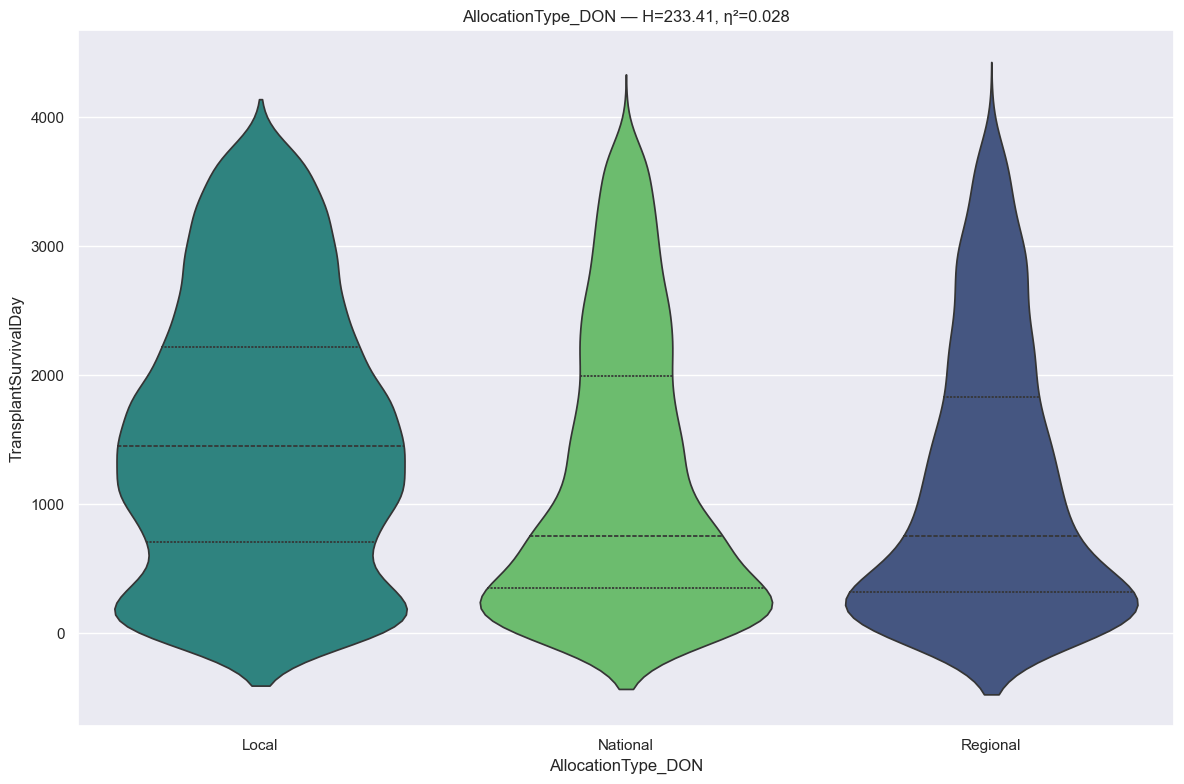

RANKING REPORT: AllocationType_DON (n ≥ 30)
INCLUDED CATEGORIES:
 * Local                                             :   3756 records
 * National                                          :   2930 records
 * Regional                                          :   1624 records
BYPASSED CATEGORIES (n < min_n):
 * Foreign Donor                                     :      9 records
--------------------------------------------------------------------------------
Kruskal H: 233.4063 | P-value: 2.072393e-51 | Effect η²: 0.0279
Correction Method: BONFERRONI
Pairwise Testing (Bonferroni Alpha: 0.0167 | r_threshold: 0.10)
--------------------------------------------------------------------------------
Local        vs National     | p=8.2111e-38 | thr=0.0167 | r=-0.183 | *Sig*
Local        vs Regional     | p=4.0415e-35 | thr=0.0167 | r=-0.212 | *Sig*
National     vs Regional     | p=9.9972e-02 | thr=0.0167 | r=-0.029 | Not Sig
::::: Collapsed into 2 groups (excluding 'Other') :::::



In [213]:
# instantiate class
ranker = NominalSurvivalRanker.NominalSurvivalRanker(
    method="bonferroni",  # bonferroni, Holm-Bonferroni (holm) Benjamini–Hochberg (fdr)
    r_thresh=0.10,        # Lower r-threshold (strict merging)
)
# initialize variable
results = ranker.fit(df, features[0])
# mapping DataFrame
new_row = pd.DataFrame([ranker.build_feature_dict(results)])
mapping_df = pd.concat([mapping_df, new_row], ignore_index=True)

In [214]:
# mapping dictionary
print(results['mapping'])
mean_survival_by_category(df, features[0])

{'Local': 'Group_1', 'National': 'Group_2', 'Regional': 'Group_2', 'Foreign Donor': 'Other'}


,AllocationType_DON,mean_survival_days,record_count
1,Local,1521.484026,3756
2,National,1206.653242,2930
3,Regional,1151.879926,1624
0,Foreign Donor,1400.888889,9


In [215]:
# instantiate class
ranker = NominalSurvivalRanker.NominalSurvivalRanker(
    method="fdr",  # bonferroni, Holm-Bonferroni (holm) Benjamini–Hochberg (fdr)
    r_thresh=0.05,        # Lower r-threshold (strict merging)
    plot=False
)
# initialize variable
results = ranker.fit(df, features[0])
# mapping DataFrame & remove last entry 
mapping_df = mapping_df[mapping_df["feature"] != features[0]]
new_row = pd.DataFrame([ranker.build_feature_dict(results)])
mapping_df = pd.concat([mapping_df, new_row], ignore_index=True)

RANKING REPORT: AllocationType_DON (n ≥ 30)
INCLUDED CATEGORIES:
 * Local                                             :   3756 records
 * National                                          :   2930 records
 * Regional                                          :   1624 records
BYPASSED CATEGORIES (n < min_n):
 * Foreign Donor                                     :      9 records
--------------------------------------------------------------------------------
Kruskal H: 233.4063 | P-value: 2.072393e-51 | Effect η²: 0.0279
Correction Method: FDR
Pairwise Testing (Base Alpha: 0.05 | Method: FDR | r_threshold: 0.05)
--------------------------------------------------------------------------------
Local        vs National     | p=8.2111e-38 | fdr_alpha=0.05 | r=-0.183 | *Sig*
Local        vs Regional     | p=4.0415e-35 | fdr_alpha=0.05 | r=-0.212 | *Sig*
National     vs Regional     | p=9.9972e-02 | fdr_alpha=0.05 | r=-0.029 | Not Sig
::::: Collapsed into 2 groups (excluding 'Other') :::::



In [216]:
# mapping dictionary
print(results['mapping'])
mean_survival_by_category(df, features[0])

{'Local': 'Group_1', 'National': 'Group_2', 'Regional': 'Group_2', 'Foreign Donor': 'Other'}


,AllocationType_DON,mean_survival_days,record_count
1,Local,1521.484026,3756
2,National,1206.653242,2930
3,Regional,1151.879926,1624
0,Foreign Donor,1400.888889,9


#### Urine Portein

In [217]:
# info
features = u.get_feature_info(df, 'UrinePortein', cat=False)
# dtype
{col: df[col].dtype for col in features}

                 count unique top  freq
UrinePortein_DON  8319      4  No  4623

:::: NaN Count:
UrinePortein_DON    0 



{'UrinePortein_DON': CategoricalDtype(categories=['Missing', 'No', 'Unknown', 'Yes'], ordered=False, categories_dtype=object)}

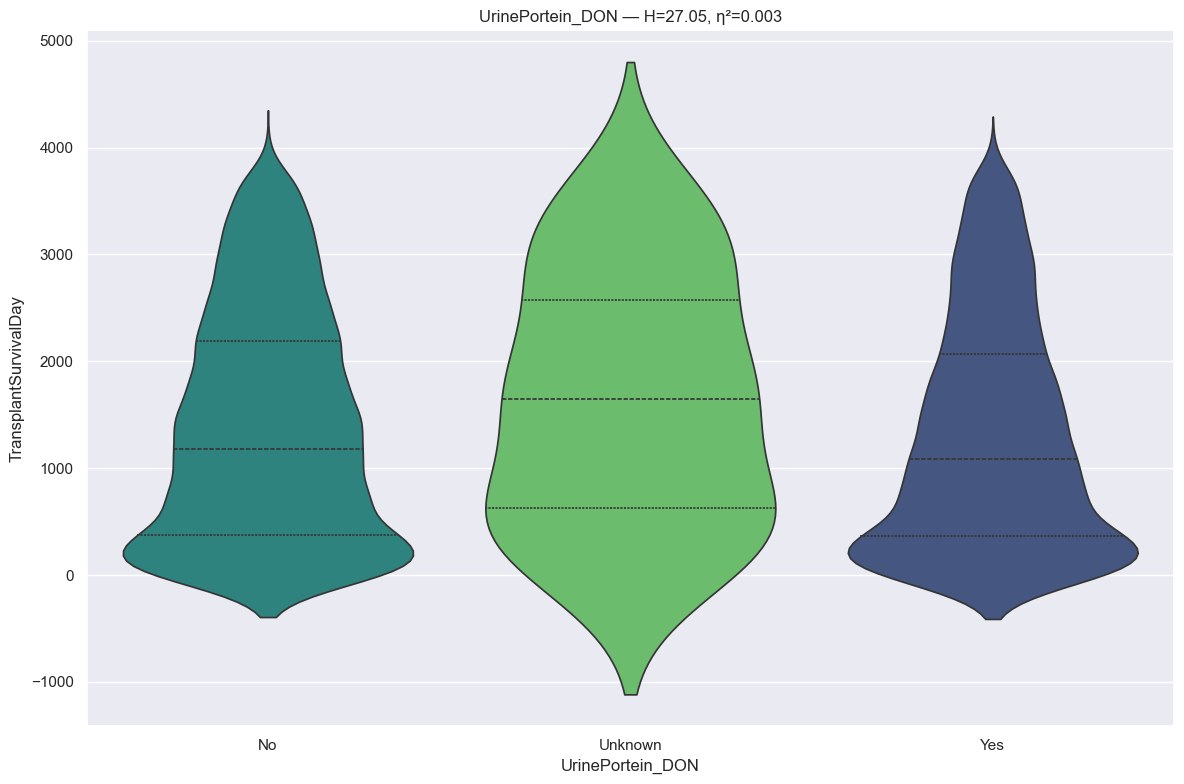

RANKING REPORT: UrinePortein_DON (n ≥ 30)
INCLUDED CATEGORIES:
 * No                                                :   4623 records
 * Unknown                                           :     37 records
 * Yes                                               :   3645 records
BYPASSED CATEGORIES (n < min_n):
 * Missing                                           :     14 records
--------------------------------------------------------------------------------
Kruskal H: 27.0528 | P-value: 1.335206e-06 | Effect η²: 0.0030
Correction Method: BONFERRONI
Pairwise Testing (Bonferroni Alpha: 0.0167 | r_threshold: 0.10)
--------------------------------------------------------------------------------
No           vs Yes          | p=7.7532e-07 | thr=0.0167 | r=-0.063 | *Sig*
Unknown      vs Yes          | p=4.9426e-02 | thr=0.0167 | r=-0.187 | Not Sig
No           vs Unknown      | p=1.7509e-01 | thr=0.0167 | r= 0.129 | Not Sig
::::: Collapsed into 3 groups (excluding 'Other') :::::



In [218]:
# instantiate class
ranker = NominalSurvivalRanker.NominalSurvivalRanker(
    method="bonferroni",  # bonferroni, Holm-Bonferroni (holm) Benjamini–Hochberg (fdr)
    r_thresh=0.10,        # Lower r-threshold (strict merging)
)
# initialize variable
results = ranker.fit(df, features[0])
# mapping DataFrame
new_row = pd.DataFrame([ranker.build_feature_dict(results)])
mapping_df = pd.concat([mapping_df, new_row], ignore_index=True)

In [219]:
# mapping dictionary
print(results['mapping'])
mean_survival_by_category(df, features[0])

{'No': 'Group_1', 'Unknown': 'Group_2', 'Yes': 'Group_3', 'Missing': 'Other'}


,UrinePortein_DON,mean_survival_days,record_count
1,No,1386.398875,4623
3,Yes,1275.536077,3645
2,Unknown,1630.324324,37
0,Missing,1034.000000,14


In [220]:
# Collapse Missing & Unknown into Other: underpowered, small sample size
# mapping
mapping = {'Unknown': 'Other',
           'Missing': 'Other'
          }
# map the change
df[features[0]] = (df[features[0]].map(mapping).fillna(df[features[0]]))
# sanity check
mean_survival_by_category(df,features[0])

,UrinePortein_DON,mean_survival_days,record_count
0,No,1386.398875,4623
2,Yes,1275.536077,3645
1,Other,1466.627451,51


#### Cardiac Arrest

In [221]:
# info
features = u.get_feature_info(df, 'CardiacArrest', cat=False)
# dtype
{col: df[col].dtype for col in features}

                  count unique top  freq
CardiacArrest_DON  8319      3  No  7595

:::: NaN Count:
CardiacArrest_DON    0 



{'CardiacArrest_DON': CategoricalDtype(categories=['Missing', 'No', 'Yes'], ordered=False, categories_dtype=object)}

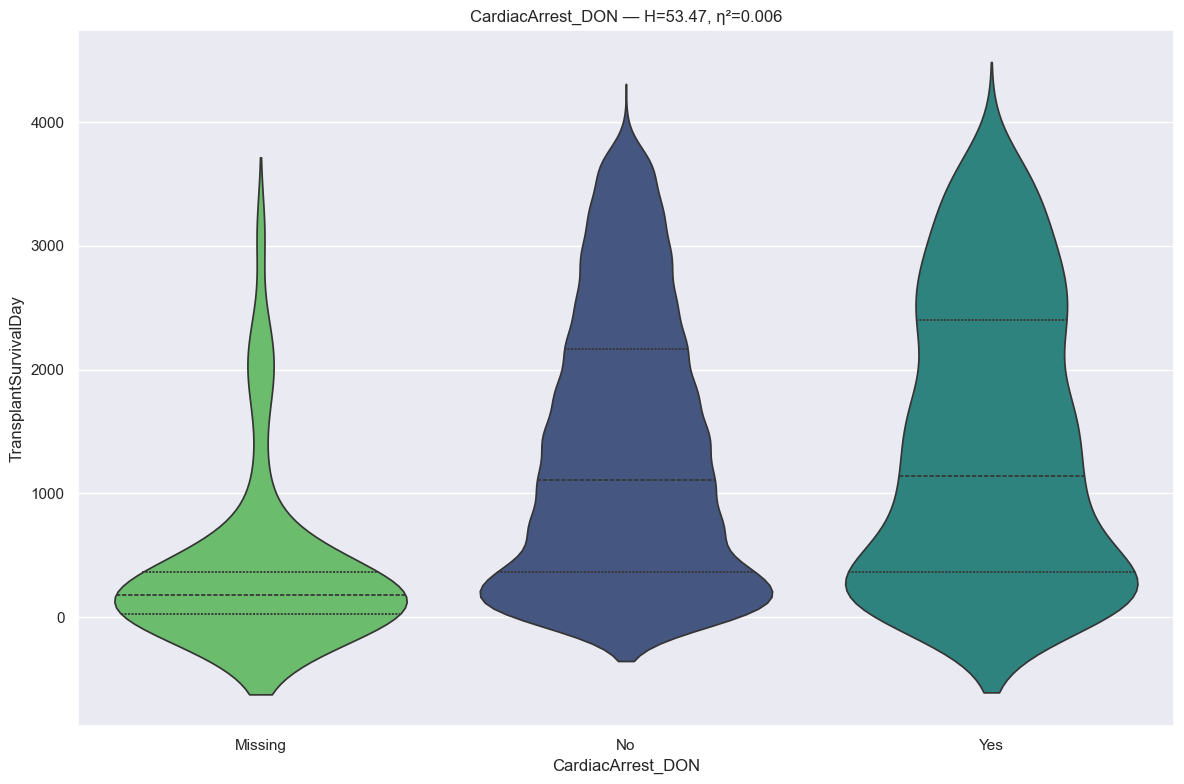

RANKING REPORT: CardiacArrest_DON (n ≥ 30)
INCLUDED CATEGORIES:
 * Missing                                           :     50 records
 * No                                                :   7595 records
 * Yes                                               :    674 records
BYPASSED CATEGORIES: None
--------------------------------------------------------------------------------
Kruskal H: 53.4732 | P-value: 2.445904e-12 | Effect η²: 0.0062
Correction Method: BONFERRONI
Pairwise Testing (Bonferroni Alpha: 0.0167 | r_threshold: 0.10)
--------------------------------------------------------------------------------
Missing      vs No           | p=5.2901e-13 | thr=0.0167 | r= 0.591 | *Sig*
Missing      vs Yes          | p=3.6514e-12 | thr=0.0167 | r= 0.589 | *Sig*
No           vs Yes          | p=2.3543e-01 | thr=0.0167 | r= 0.028 | Not Sig
::::: Collapsed into 2 groups (excluding 'Other') :::::



In [222]:
# instantiate class
ranker = NominalSurvivalRanker.NominalSurvivalRanker(
    method="bonferroni",  # bonferroni, Holm-Bonferroni (holm) Benjamini–Hochberg (fdr)
    r_thresh=0.10,        # Lower r-threshold (strict merging)
)
# initialize variable
results = ranker.fit(df, features[0])
# mapping DataFrame
new_row = pd.DataFrame([ranker.build_feature_dict(results)])
mapping_df = pd.concat([mapping_df, new_row], ignore_index=True)

In [223]:
# mapping dictionary
print(results['mapping'])
mean_survival_by_category(df, features[0])

{'Missing': 'Group_1', 'No': 'Group_2', 'Yes': 'Group_2'}


,CardiacArrest_DON,mean_survival_days,record_count
1,No,1337.939039,7595
2,Yes,1412.284866,674
0,Missing,398.440000,50


#### Myocardial Infarction History

In [224]:
# info
features = u.get_feature_info(df, 'MyocardialInfarctionHistory', cat=False)
# dtype
{col: df[col].dtype for col in features}

                                count unique top  freq
MyocardialInfarctionHistory_DON  8319      4  No  8193

:::: NaN Count:
MyocardialInfarctionHistory_DON    0 



{'MyocardialInfarctionHistory_DON': CategoricalDtype(categories=['Missing', 'No', 'Unknown', 'Yes'], ordered=False, categories_dtype=object)}

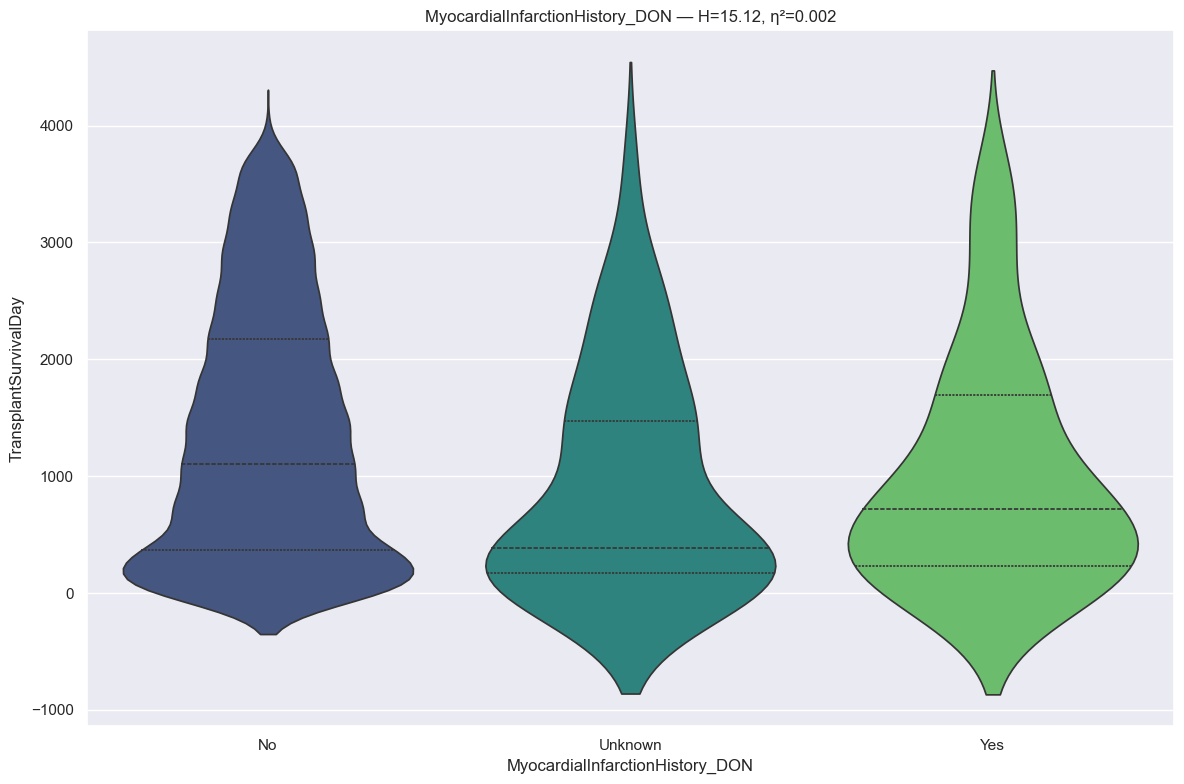

RANKING REPORT: MyocardialInfarctionHistory_DON (n ≥ 30)
INCLUDED CATEGORIES:
 * No                                                :   8193 records
 * Unknown                                           :     54 records
 * Yes                                               :     58 records
BYPASSED CATEGORIES (n < min_n):
 * Missing                                           :     14 records
--------------------------------------------------------------------------------
Kruskal H: 15.1186 | P-value: 5.212272e-04 | Effect η²: 0.0016
Correction Method: BONFERRONI
Pairwise Testing (Bonferroni Alpha: 0.0167 | r_threshold: 0.10)
--------------------------------------------------------------------------------
No           vs Unknown      | p=2.3452e-03 | thr=0.0167 | r=-0.240 | *Sig*
No           vs Yes          | p=1.4655e-02 | thr=0.0167 | r=-0.186 | *Sig*
Unknown      vs Yes          | p=4.6135e-01 | thr=0.0167 | r= 0.081 | Not Sig
::::: Collapsed into 2 groups (excluding 'Other') :::::



In [225]:
# instantiate class
ranker = NominalSurvivalRanker.NominalSurvivalRanker(
    method="bonferroni",  # bonferroni, Holm-Bonferroni (holm) Benjamini–Hochberg (fdr)
    r_thresh=0.10,        # Lower r-threshold (strict merging)
)
# initialize variable
results = ranker.fit(df, features[0])
# mapping DataFrame
new_row = pd.DataFrame([ranker.build_feature_dict(results)])
mapping_df = pd.concat([mapping_df, new_row], ignore_index=True)

In [226]:
# mapping dictionary
print(results['mapping'])
mean_survival_by_category(df, features[0])

{'No': 'Group_1', 'Unknown': 'Group_2', 'Yes': 'Group_2', 'Missing': 'Other'}


,MyocardialInfarctionHistory_DON,mean_survival_days,record_count
1,No,1343.929940,8193
3,Yes,1004.086207,58
2,Unknown,924.407407,54
0,Missing,1034.000000,14


In [227]:
# Collapse Missing & Unknown into Other: underpowered, small sample size
# mapping
mapping = {'Unknown': 'Other',
           'Missing': 'Other'
          }
# map the change
df[features[0]] = (df[features[0]].map(mapping).fillna(df[features[0]]))
# sanity check
mean_survival_by_category(df,features[0])

,MyocardialInfarctionHistory_DON,mean_survival_days,record_count
0,No,1343.929940,8193
1,Other,946.970588,68
2,Yes,1004.086207,58


#### LV Ejection Fraction Medthod

In [228]:
# info
features = u.get_feature_info(df, 'LV_EjectionFractionMedthod', cat=False)
# dtype
{col: df[col].dtype for col in features}

                               count unique   top  freq
LV_EjectionFractionMedthod_DON  8319      3  Echo  8101

:::: NaN Count:
LV_EjectionFractionMedthod_DON    0 



{'LV_EjectionFractionMedthod_DON': CategoricalDtype(categories=['Angiogram', 'Echo', 'Missing'], ordered=False, categories_dtype=object)}

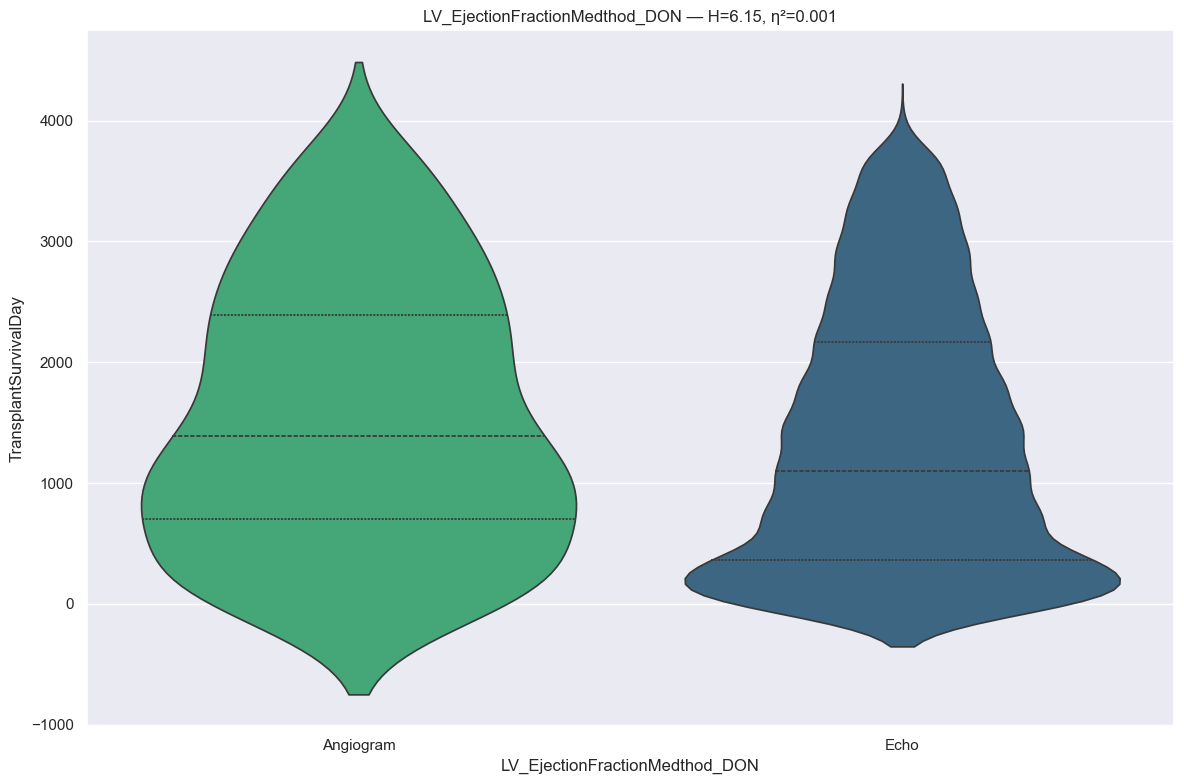

RANKING REPORT: LV_EjectionFractionMedthod_DON (n ≥ 30)
INCLUDED CATEGORIES:
 * Angiogram                                         :    206 records
 * Echo                                              :   8101 records
BYPASSED CATEGORIES (n < min_n):
 * Missing                                           :     12 records
--------------------------------------------------------------------------------
Kruskal H: 6.1521 | P-value: 1.312568e-02 | Effect η²: 0.0006
Correction Method: BONFERRONI
Pairwise Testing (Bonferroni Alpha: 0.0500 | r_threshold: 0.10)
--------------------------------------------------------------------------------
Angiogram    vs Echo         | p=1.3126e-02 | thr=0.0500 | r=-0.101 | *Sig*
::::: Collapsed into 2 groups (excluding 'Other') :::::



In [229]:
# instantiate class
ranker = NominalSurvivalRanker.NominalSurvivalRanker(
    method="bonferroni",  # bonferroni, Holm-Bonferroni (holm) Benjamini–Hochberg (fdr)
    r_thresh=0.10,        # Lower r-threshold (strict merging)
)
# initialize variable
results = ranker.fit(df, features[0])
# mapping DataFrame
new_row = pd.DataFrame([ranker.build_feature_dict(results)])
mapping_df = pd.concat([mapping_df, new_row], ignore_index=True)

In [230]:
# mapping dictionary
print(results['mapping'])
mean_survival_by_category(df, features[0])

{'Angiogram': 'Group_1', 'Echo': 'Group_2', 'Missing': 'Other'}


,LV_EjectionFractionMedthod_DON,mean_survival_days,record_count
1,Echo,1332.899025,8101
0,Angiogram,1522.932039,206
2,Missing,1825.833333,12


#### Coronary Angiogram

In [231]:
# info
features = u.get_feature_info(df, 'CoronaryAngiogram', cat=False)
# dtype
{col: df[col].dtype for col in features}

                      count unique top  freq
CoronaryAngiogram_DON  8319      4  No  4870

:::: NaN Count:
CoronaryAngiogram_DON    0 



{'CoronaryAngiogram_DON': CategoricalDtype(categories=['Missing', 'No', 'Yes, normal', 'Yes, not normal'], ordered=False, categories_dtype=object)}

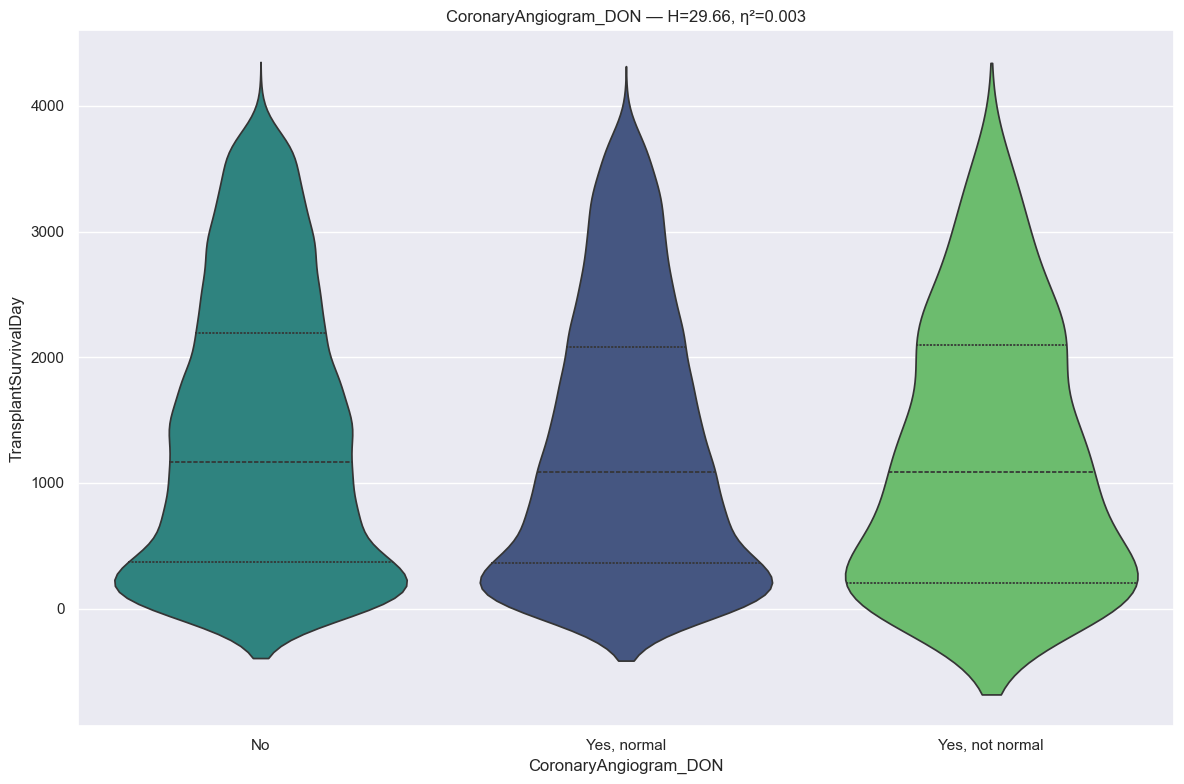

RANKING REPORT: CoronaryAngiogram_DON (n ≥ 30)
INCLUDED CATEGORIES:
 * No                                                :   4870 records
 * Yes, normal                                       :   3206 records
 * Yes, not normal                                   :    229 records
BYPASSED CATEGORIES (n < min_n):
 * Missing                                           :     14 records
--------------------------------------------------------------------------------
Kruskal H: 29.6648 | P-value: 3.617208e-07 | Effect η²: 0.0033
Correction Method: BONFERRONI
Pairwise Testing (Bonferroni Alpha: 0.0167 | r_threshold: 0.10)
--------------------------------------------------------------------------------
No           vs Yes, normal  | p=9.0261e-07 | thr=0.0167 | r=-0.064 | *Sig*
No           vs Yes, not normal | p=2.8865e-03 | thr=0.0167 | r=-0.116 | *Sig*
Yes, normal  vs Yes, not normal | p=1.7713e-01 | thr=0.0167 | r=-0.053 | Not Sig
::::: Collapsed into 2 groups (excluding 'Other') :::::



In [232]:
# instantiate class
ranker = NominalSurvivalRanker.NominalSurvivalRanker(
    method="bonferroni",  # bonferroni, Holm-Bonferroni (holm) Benjamini–Hochberg (fdr)
    r_thresh=0.10,        # Lower r-threshold (strict merging)
)
# initialize variable
results = ranker.fit(df, features[0])
# mapping DataFrame
new_row = pd.DataFrame([ranker.build_feature_dict(results)])
mapping_df = pd.concat([mapping_df, new_row], ignore_index=True)

In [233]:
# mapping dictionary
print(results['mapping'])
mean_survival_by_category(df, features[0])

{'No': 'Group_1', 'Yes, normal': 'Group_2', 'Yes, not normal': 'Group_2', 'Missing': 'Other'}


,CoronaryAngiogram_DON,mean_survival_days,record_count
1,No,1392.360575,4870
2,"Yes, normal",1268.384903,3206
3,"Yes, not normal",1186.615721,229
0,Missing,1034.000000,14


#### Biopsy

In [234]:
# info
features = u.get_feature_info(df, 'Biopsy', cat=False)
# dtype
{col: df[col].dtype for col in features}

           count unique              top  freq
Biopsy_DON  8319      5  Biopsy not done  8296

:::: NaN Count:
Biopsy_DON    0 



{'Biopsy_DON': CategoricalDtype(categories=['Biopsy not done', 'Missing', 'Unknown',
                   'Yes, rejection confirmed', 'Yes, rejection not confirmed'],
 , ordered=False, categories_dtype=object)}

In [235]:
# instantiate class
ranker = NominalSurvivalRanker.NominalSurvivalRanker(
    method="bonferroni",  # bonferroni, Holm-Bonferroni (holm) Benjamini–Hochberg (fdr)
    r_thresh=0.10,        # Lower r-threshold (strict merging)
)
# initialize variable
results = ranker.fit(df, features[0])
# mapping DataFrame
new_row = pd.DataFrame([ranker.build_feature_dict(results)])
mapping_df = pd.concat([mapping_df, new_row], ignore_index=True)

[WARNING] Cannot perform statistical comparison for Biopsy_DON
          Only 1 category has n ≥ 30.
          You can only compare MORE THAN ONE category since n < min_n.



In [236]:
# mapping dictionary
print(results['mapping'])
mean_survival_by_category(df, features[0])

{'Biopsy not done': 'Group_1'}


,Biopsy_DON,mean_survival_days,record_count
0,Biopsy not done,1338.085342,8296
1,Missing,1034.000000,14
4,"Yes, rejection not confirmed",2557.000000,4
2,Unknown,2044.666667,3
3,"Yes, rejection confirmed",927.500000,2


In [237]:
# mapping
mapping = {'Yes, rejection confirmed': 'Other',
           'Yes, rejection not confirmed': 'Other',
           'Unknown': 'Other',
           'Missing': 'Other'
          }
# map the change
df[features[0]] = (df[features[0]].map(mapping).fillna(df[features[0]]))

# sanity check
mean_survival_by_category(df, features[0])

,Biopsy_DON,mean_survival_days,record_count
0,Biopsy not done,1338.085342,8296
1,Other,1421.434783,23


In [238]:
# add to remove list
remove_cols.extend(['Gender_DON'])
# remove last entry 
mapping_df = mapping_df[mapping_df["feature"] != features[0]]

#### Tatoos

In [239]:
# info
features = u.get_feature_info(df, 'Tatoos', cat=False)
# dtype
{col: df[col].dtype for col in features}

           count unique  top  freq
Tatoos_DON  8319      4  Yes  4723

:::: NaN Count:
Tatoos_DON    0 



{'Tatoos_DON': CategoricalDtype(categories=['Missing', 'No', 'Unknown', 'Yes'], ordered=False, categories_dtype=object)}

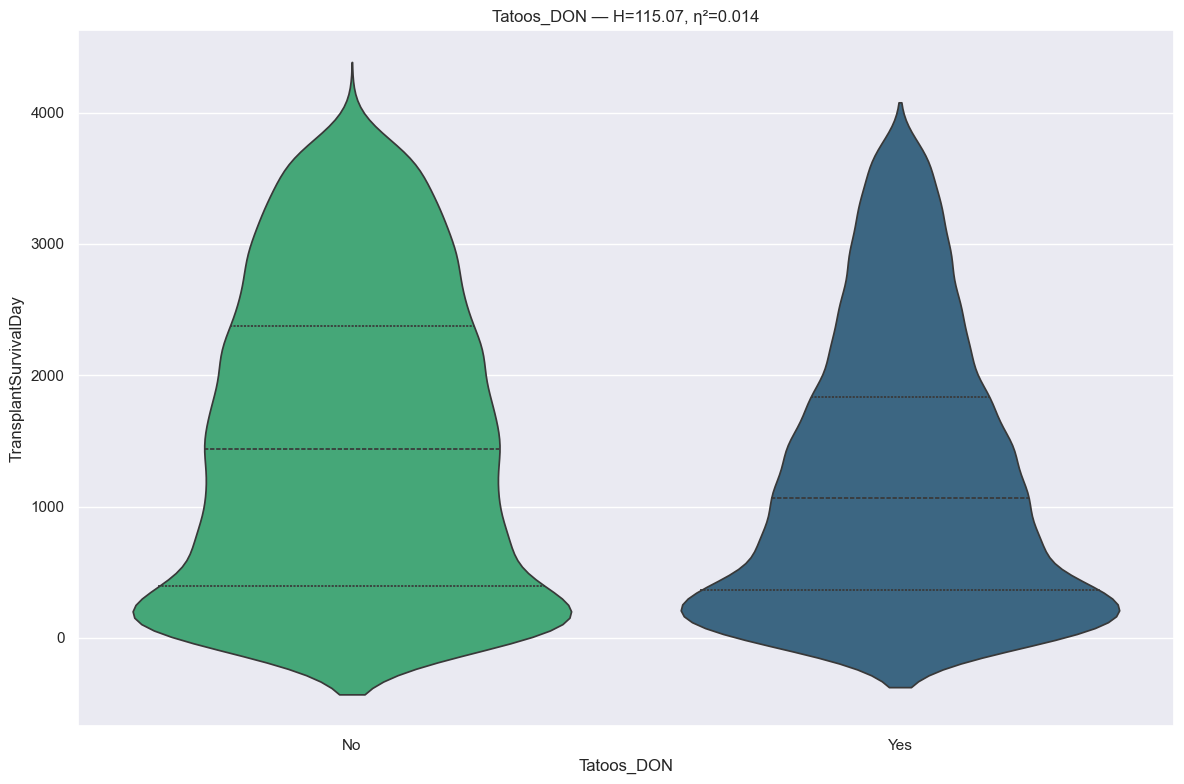

RANKING REPORT: Tatoos_DON (n ≥ 30)
INCLUDED CATEGORIES:
 * No                                                :   3570 records
 * Yes                                               :   4723 records
BYPASSED CATEGORIES (n < min_n):
 * Missing                                           :     14 records
 * Unknown                                           :     12 records
--------------------------------------------------------------------------------
Kruskal H: 115.0726 | P-value: 7.586931e-27 | Effect η²: 0.0138
Correction Method: BONFERRONI
Pairwise Testing (Bonferroni Alpha: 0.0500 | r_threshold: 0.10)
--------------------------------------------------------------------------------
No           vs Yes          | p=7.5873e-27 | thr=0.0500 | r=-0.137 | *Sig*
::::: Collapsed into 2 groups (excluding 'Other') :::::



In [240]:
# instantiate class
ranker = NominalSurvivalRanker.NominalSurvivalRanker(
    method="bonferroni",  # bonferroni, Holm-Bonferroni (holm) Benjamini–Hochberg (fdr)
    r_thresh=0.10,        # Lower r-threshold (strict merging)
)
# initialize variable
results = ranker.fit(df, features[0])
# mapping DataFrame
new_row = pd.DataFrame([ranker.build_feature_dict(results)])
mapping_df = pd.concat([mapping_df, new_row], ignore_index=True)

In [241]:
# mapping dictionary
print(results['mapping'])
mean_survival_by_category(df, features[0])

{'No': 'Group_1', 'Yes': 'Group_2', 'Missing': 'Other', 'Unknown': 'Other'}


,Tatoos_DON,mean_survival_days,record_count
3,Yes,1221.326911,4723
1,No,1492.103641,3570
0,Missing,1034.000000,14
2,Unknown,1986.333333,12


In [242]:
# mapping
mapping = {'Unknown': 'Other',
           'Missing': 'Other'
          }
# map the change
df[features[0]] = (df[features[0]].map(mapping).fillna(df[features[0]]))

# sanity check
mean_survival_by_category(df, features[0])

,Tatoos_DON,mean_survival_days,record_count
2,Yes,1221.326911,4723
0,No,1492.103641,3570
1,Other,1473.538462,26


#### Antibody Result HBSAB

In [243]:
# info
features = u.get_feature_info(df, 'AntibodyResultHBSAB', cat=False)
# dtype
{col: df[col].dtype for col in features}

                        count unique       top  freq
AntibodyResultHBSAB_DON  8319      7  Not Done  7122

:::: NaN Count:
AntibodyResultHBSAB_DON    0 



{'AntibodyResultHBSAB_DON': CategoricalDtype(categories=['Cannot Disclose', 'Indeterminate', 'Missing', 'Negative',
                   'Not Done', 'Positive', 'Unknown'],
 , ordered=False, categories_dtype=object)}

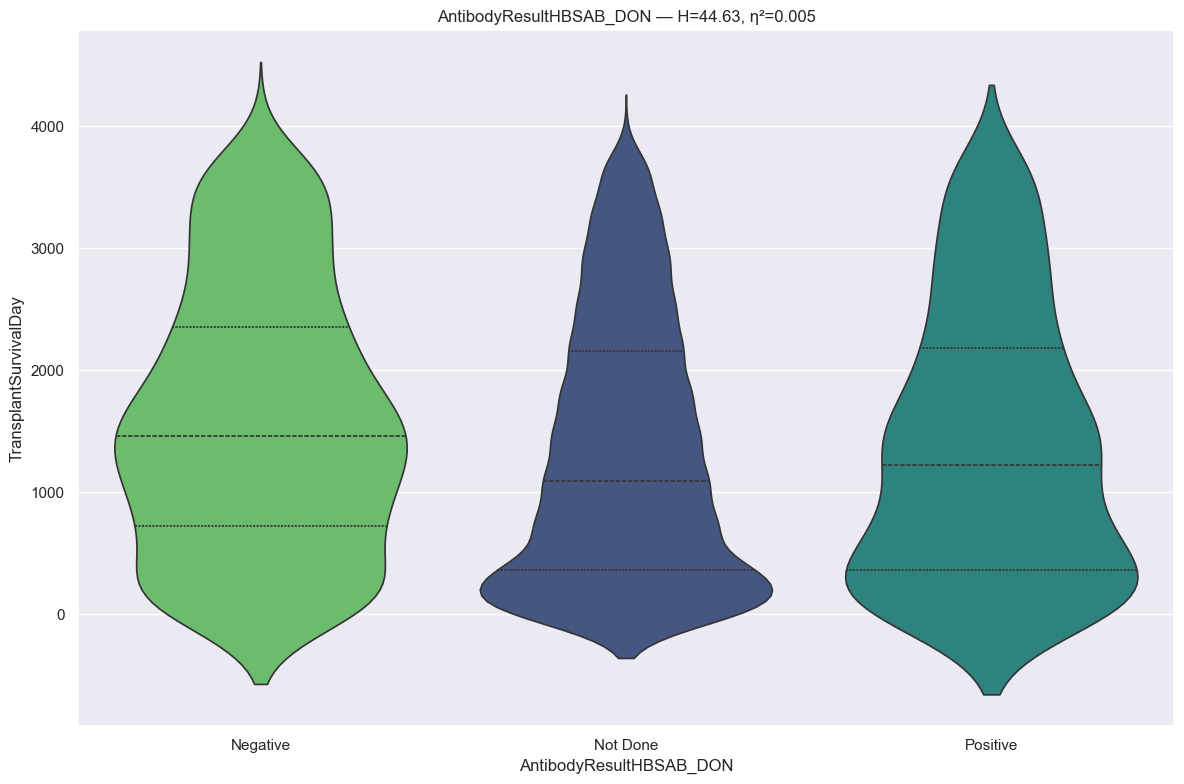

RANKING REPORT: AntibodyResultHBSAB_DON (n ≥ 30)
INCLUDED CATEGORIES:
 * Negative                                          :    746 records
 * Not Done                                          :   7122 records
 * Positive                                          :    418 records
BYPASSED CATEGORIES (n < min_n):
 * Cannot Disclose                                   :      1 records
 * Indeterminate                                     :     20 records
 * Missing                                           :     10 records
 * Unknown                                           :      2 records
--------------------------------------------------------------------------------
Kruskal H: 44.6295 | P-value: 2.036241e-10 | Effect η²: 0.0051
Correction Method: BONFERRONI
Pairwise Testing (Bonferroni Alpha: 0.0167 | r_threshold: 0.10)
--------------------------------------------------------------------------------
Negative     vs Not Done     | p=2.3661e-11 | thr=0.0167 | r=-0.148 | *Sig*
Negative    

In [244]:
# instantiate class
ranker = NominalSurvivalRanker.NominalSurvivalRanker(
    method="bonferroni",  # bonferroni, Holm-Bonferroni (holm) Benjamini–Hochberg (fdr)
    r_thresh=0.10,        # Lower r-threshold (strict merging)
)
# initialize variable
results = ranker.fit(df, features[0])
# mapping DataFrame
new_row = pd.DataFrame([ranker.build_feature_dict(results)])
mapping_df = pd.concat([mapping_df, new_row], ignore_index=True)

In [245]:
# mapping dictionary
print(results['mapping'])
mean_survival_by_category(df, features[0])

{'Negative': 'Group_1', 'Not Done': 'Group_2', 'Positive': 'Group_2', 'Cannot Disclose': 'Other', 'Indeterminate': 'Other', 'Missing': 'Other', 'Unknown': 'Other'}


,AntibodyResultHBSAB_DON,mean_survival_days,record_count
4,Not Done,1311.118787,7122
3,Negative,1576.576408,746
5,Positive,1369.433014,418
1,Indeterminate,1360.450000,20
2,Missing,1443.500000,10
6,Unknown,1464.500000,2
0,Cannot Disclose,2539.000000,1


In [246]:
# mapping
mapping = {'Missing': 'Other',
           'Unknown': 'Other',
           'Cannot Disclose': 'Other',
           'Indeterminate': 'Other'
          }
# map the change
df[features[0]] = (df[features[0]].map(mapping).fillna(df[features[0]]))

# sanity check
mean_survival_by_category(df, features[0])

,AntibodyResultHBSAB_DON,mean_survival_days,record_count
1,Not Done,1311.118787,7122
0,Negative,1576.576408,746
3,Positive,1369.433014,418
2,Other,1427.636364,33


#### EpsteinBarr IGG

In [247]:
# info
features = u.get_feature_info(df, 'EpsteinBarr_IGG', cat=False)
# dtype
{col: df[col].dtype for col in features}

                    count unique       top  freq
EpsteinBarr_IGG_DON  8319      6  Positive  7584

:::: NaN Count:
EpsteinBarr_IGG_DON    0 



{'EpsteinBarr_IGG_DON': CategoricalDtype(categories=['Indeterminate', 'Missing', 'Negative', 'Not Done',
                   'Pending', 'Positive', 'Unknown'],
 , ordered=False, categories_dtype=object)}

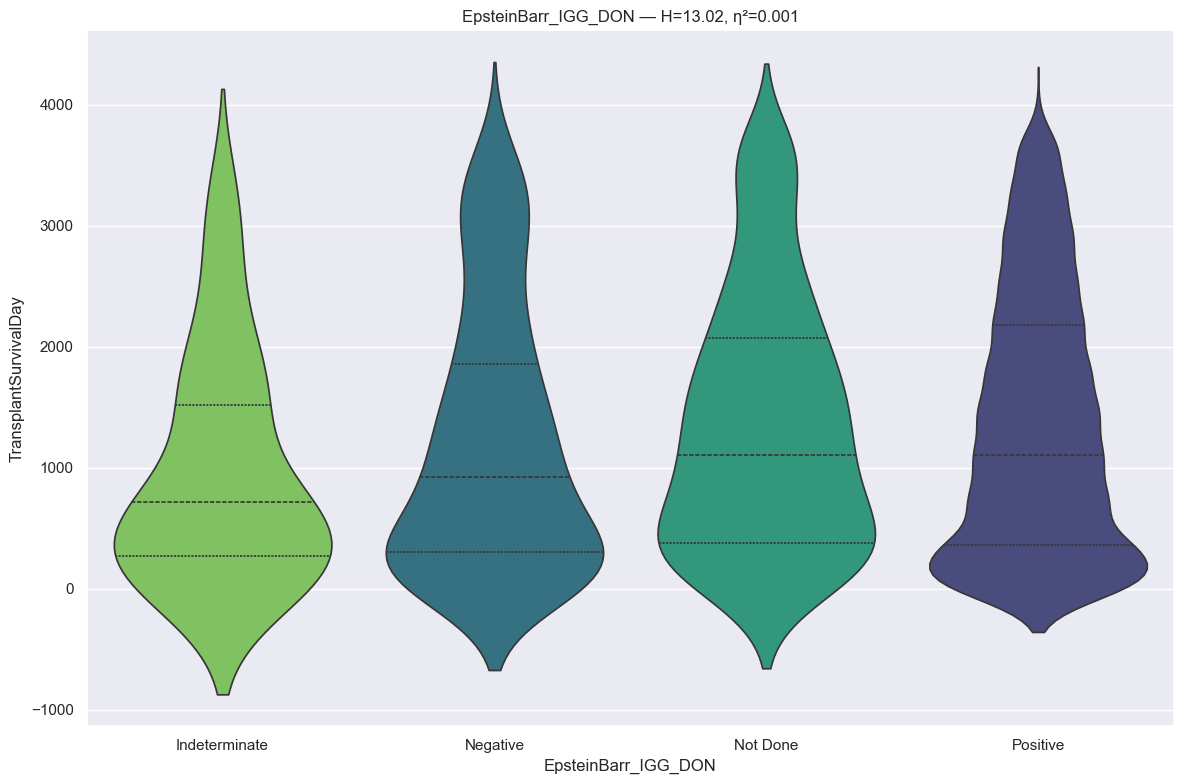

RANKING REPORT: EpsteinBarr_IGG_DON (n ≥ 30)
INCLUDED CATEGORIES:
 * Indeterminate                                     :     44 records
 * Negative                                          :    357 records
 * Not Done                                          :    326 records
 * Positive                                          :   7584 records
BYPASSED CATEGORIES (n < min_n):
 * Missing                                           :      7 records
 * Pending                                           :      1 records
--------------------------------------------------------------------------------
Kruskal H: 13.0197 | P-value: 4.594201e-03 | Effect η²: 0.0012
Correction Method: BONFERRONI
Pairwise Testing (Bonferroni Alpha: 0.0083 | r_threshold: 0.10)
--------------------------------------------------------------------------------
Indeterminate vs Not Done     | p=6.2328e-03 | thr=0.0083 | r= 0.254 | *Sig*
Negative     vs Positive     | p=1.0769e-02 | thr=0.0083 | r= 0.080 | Not Sig
Negativ

In [248]:
# instantiate class
ranker = NominalSurvivalRanker.NominalSurvivalRanker(
    method="bonferroni",  # bonferroni, Holm-Bonferroni (holm) Benjamini–Hochberg (fdr)
    r_thresh=0.10,        # Lower r-threshold (strict merging)
)
# initialize variable
results = ranker.fit(df, features[0])
# mapping DataFrame
new_row = pd.DataFrame([ranker.build_feature_dict(results)])
mapping_df = pd.concat([mapping_df, new_row], ignore_index=True)

In [249]:
# mapping dictionary
print(results['mapping'])
mean_survival_by_category(df, features[0])

{'Indeterminate': 'Group_1', 'Negative': 'Group_2', 'Not Done': 'Group_2', 'Positive': 'Group_2', 'Missing': 'Other', 'Pending': 'Other'}


,EpsteinBarr_IGG_DON,mean_survival_days,record_count
5,Positive,1344.732331,7584
2,Negative,1215.952381,357
3,Not Done,1367.003067,326
0,Indeterminate,957.681818,44
1,Missing,1557.714286,7
4,Pending,2219.000000,1


In [250]:
# instantiate class
ranker = NominalSurvivalRanker.NominalSurvivalRanker(
    method="holm",  # bonferroni, Holm-Bonferroni (holm) Benjamini–Hochberg (fdr)
    r_thresh=0.05,        # Lower r-threshold (strict merging)
    plot=False
)
# initialize variable
results = ranker.fit(df, features[0])
# mapping DataFrame & remove last entry 
mapping_df = mapping_df[mapping_df["feature"] != features[0]]
new_row = pd.DataFrame([ranker.build_feature_dict(results)])
mapping_df = pd.concat([mapping_df, new_row], ignore_index=True)

RANKING REPORT: EpsteinBarr_IGG_DON (n ≥ 30)
INCLUDED CATEGORIES:
 * Indeterminate                                     :     44 records
 * Negative                                          :    357 records
 * Not Done                                          :    326 records
 * Positive                                          :   7584 records
BYPASSED CATEGORIES (n < min_n):
 * Missing                                           :      7 records
 * Pending                                           :      1 records
--------------------------------------------------------------------------------
Kruskal H: 13.0197 | P-value: 4.594201e-03 | Effect η²: 0.0012
Correction Method: HOLM
Pairwise Testing (Base Alpha: 0.05 | Method: HOLM | r_threshold: 0.05)
--------------------------------------------------------------------------------
Indeterminate vs Not Done     | p=6.2328e-03 | thr=0.0083 | r= 0.254 | *Sig*
Negative     vs Positive     | p=1.0769e-02 | thr=0.0100 | r= 0.080 | Not Sig
Negati

In [251]:
# mapping dictionary
print(results['mapping'])
mean_survival_by_category(df, features[0])

{'Indeterminate': 'Group_1', 'Negative': 'Group_2', 'Not Done': 'Group_3', 'Positive': 'Group_3', 'Missing': 'Other', 'Pending': 'Other'}


,EpsteinBarr_IGG_DON,mean_survival_days,record_count
5,Positive,1344.732331,7584
2,Negative,1215.952381,357
3,Not Done,1367.003067,326
0,Indeterminate,957.681818,44
1,Missing,1557.714286,7
4,Pending,2219.000000,1


In [252]:
# mapping
mapping = {'Missing': 'Other',
           'Pending': 'Other'
          }
# map the change
df[features[0]] = (df[features[0]].map(mapping).fillna(df[features[0]]))

# sanity check
mean_survival_by_category(df, features[0])

,EpsteinBarr_IGG_DON,mean_survival_days,record_count
4,Positive,1344.732331,7584
1,Negative,1215.952381,357
2,Not Done,1367.003067,326
0,Indeterminate,957.681818,44
3,Other,1640.375000,8


#### EpsteinBarr IGM

In [253]:
# info
features = u.get_feature_info(df, 'EpsteinBarr_IGM', cat=False)
# dtype
{col: df[col].dtype for col in features}

                    count unique       top  freq
EpsteinBarr_IGM_DON  8319      6  Negative  6649

:::: NaN Count:
EpsteinBarr_IGM_DON    0 



{'EpsteinBarr_IGM_DON': CategoricalDtype(categories=['Indeterminate', 'Missing', 'Negative', 'Not Done',
                   'Pending', 'Positive', 'Unknown'],
 , ordered=False, categories_dtype=object)}

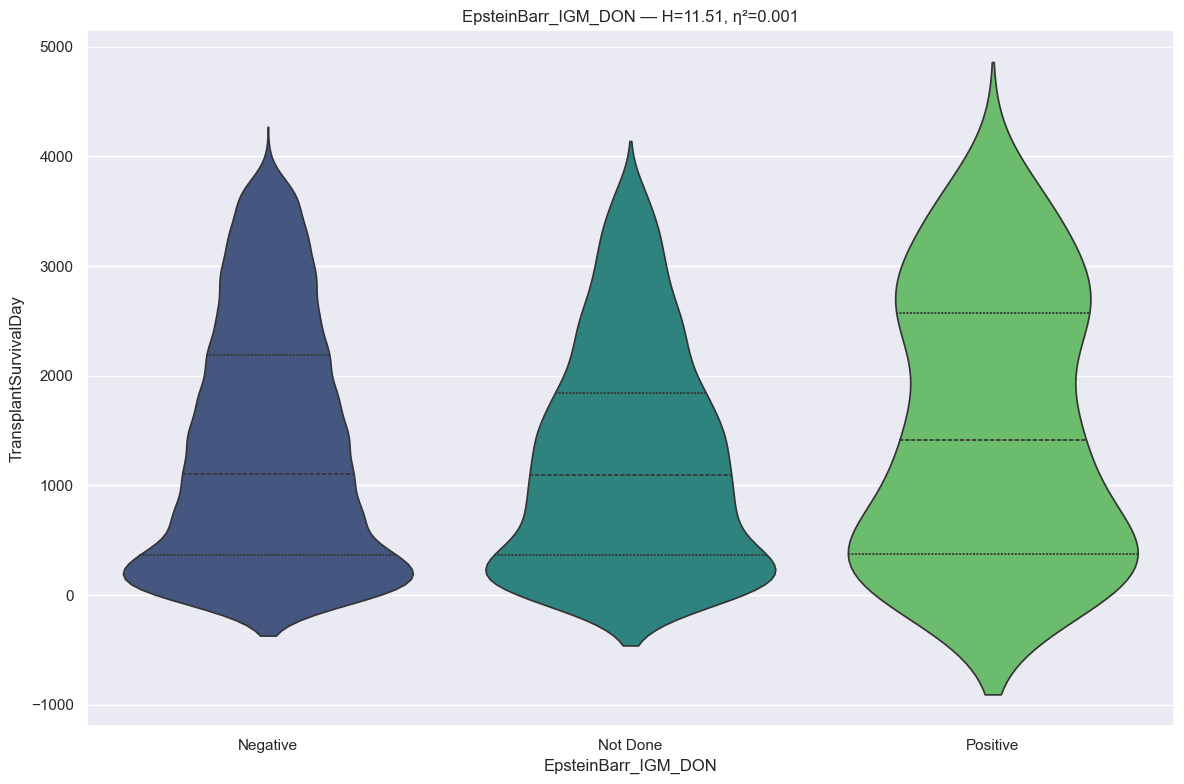

RANKING REPORT: EpsteinBarr_IGM_DON (n ≥ 30)
INCLUDED CATEGORIES:
 * Negative                                          :   6649 records
 * Not Done                                          :   1503 records
 * Positive                                          :    132 records
BYPASSED CATEGORIES (n < min_n):
 * Indeterminate                                     :     25 records
 * Missing                                           :      9 records
 * Pending                                           :      1 records
--------------------------------------------------------------------------------
Kruskal H: 11.5068 | P-value: 3.171991e-03 | Effect η²: 0.0011
Correction Method: BONFERRONI
Pairwise Testing (Bonferroni Alpha: 0.0167 | r_threshold: 0.10)
--------------------------------------------------------------------------------
Negative     vs Not Done     | p=2.4435e-03 | thr=0.0167 | r=-0.050 | *Sig*
Not Done     vs Positive     | p=2.5445e-02 | thr=0.0167 | r= 0.117 | Not Sig
Negative

In [254]:
# instantiate class
ranker = NominalSurvivalRanker.NominalSurvivalRanker(
    method="bonferroni",  # bonferroni, Holm-Bonferroni (holm) Benjamini–Hochberg (fdr)
    r_thresh=0.10,        # Lower r-threshold (strict merging)
)
# initialize variable
results = ranker.fit(df, features[0])
# mapping DataFrame
new_row = pd.DataFrame([ranker.build_feature_dict(results)])
mapping_df = pd.concat([mapping_df, new_row], ignore_index=True)

In [255]:
# mapping dictionary
print(results['mapping'])
mean_survival_by_category(df, features[0])

{'Negative': 'Group_1', 'Positive': 'Group_1', 'Not Done': 'Group_2', 'Indeterminate': 'Other', 'Missing': 'Other', 'Pending': 'Other'}


,EpsteinBarr_IGM_DON,mean_survival_days,record_count
2,Negative,1355.467589,6649
3,Not Done,1241.593480,1503
5,Positive,1520.681818,132
0,Indeterminate,1586.600000,25
1,Missing,1357.333333,9
4,Pending,2219.000000,1


In [256]:
# instantiate class
ranker = NominalSurvivalRanker.NominalSurvivalRanker(
    method="holm",  # bonferroni, Holm-Bonferroni (holm) Benjamini–Hochberg (fdr)
    r_thresh=0.05,        # Lower r-threshold (strict merging)
    plot=False
)
# initialize variable
results = ranker.fit(df, features[0])
# mapping DataFrame & remove last entry 
mapping_df = mapping_df[mapping_df["feature"] != features[0]]
new_row = pd.DataFrame([ranker.build_feature_dict(results)])
mapping_df = pd.concat([mapping_df, new_row], ignore_index=True)

RANKING REPORT: EpsteinBarr_IGM_DON (n ≥ 30)
INCLUDED CATEGORIES:
 * Negative                                          :   6649 records
 * Not Done                                          :   1503 records
 * Positive                                          :    132 records
BYPASSED CATEGORIES (n < min_n):
 * Indeterminate                                     :     25 records
 * Missing                                           :      9 records
 * Pending                                           :      1 records
--------------------------------------------------------------------------------
Kruskal H: 11.5068 | P-value: 3.171991e-03 | Effect η²: 0.0011
Correction Method: HOLM
Pairwise Testing (Base Alpha: 0.05 | Method: HOLM | r_threshold: 0.05)
--------------------------------------------------------------------------------
Negative     vs Not Done     | p=2.4435e-03 | thr=0.0167 | r=-0.050 | *Sig*
Not Done     vs Positive     | p=2.5445e-02 | thr=0.0250 | r= 0.117 | Not Sig
Negativ

In [257]:
# mapping dictionary
print(results['mapping'])
mean_survival_by_category(df, features[0])

{'Negative': 'Group_1', 'Not Done': 'Group_2', 'Positive': 'Group_3', 'Indeterminate': 'Other', 'Missing': 'Other', 'Pending': 'Other'}


,EpsteinBarr_IGM_DON,mean_survival_days,record_count
2,Negative,1355.467589,6649
3,Not Done,1241.593480,1503
5,Positive,1520.681818,132
0,Indeterminate,1586.600000,25
1,Missing,1357.333333,9
4,Pending,2219.000000,1


In [258]:
# mapping
mapping = {'Missing': 'Other',
           'Pending': 'Other',
           'Indeterminate': 'Other'
          }
# map the change
df[features[0]] = (df[features[0]].map(mapping).fillna(df[features[0]]))

# sanity check
mean_survival_by_category(df, features[0])

,EpsteinBarr_IGM_DON,mean_survival_days,record_count
0,Negative,1355.467589,6649
1,Not Done,1241.593480,1503
3,Positive,1520.681818,132
2,Other,1545.714286,35


#### HIV Risk

In [259]:
# info
features = u.get_feature_info(df, 'HIV_Risk', cat=False)
# dtype
{col: df[col].dtype for col in features}

             count unique top  freq
HIV_Risk_DON  8319      4  No  6367

:::: NaN Count:
HIV_Risk_DON    0 



{'HIV_Risk_DON': CategoricalDtype(categories=['Missing', 'No', 'Unknown', 'Yes'], ordered=False, categories_dtype=object)}

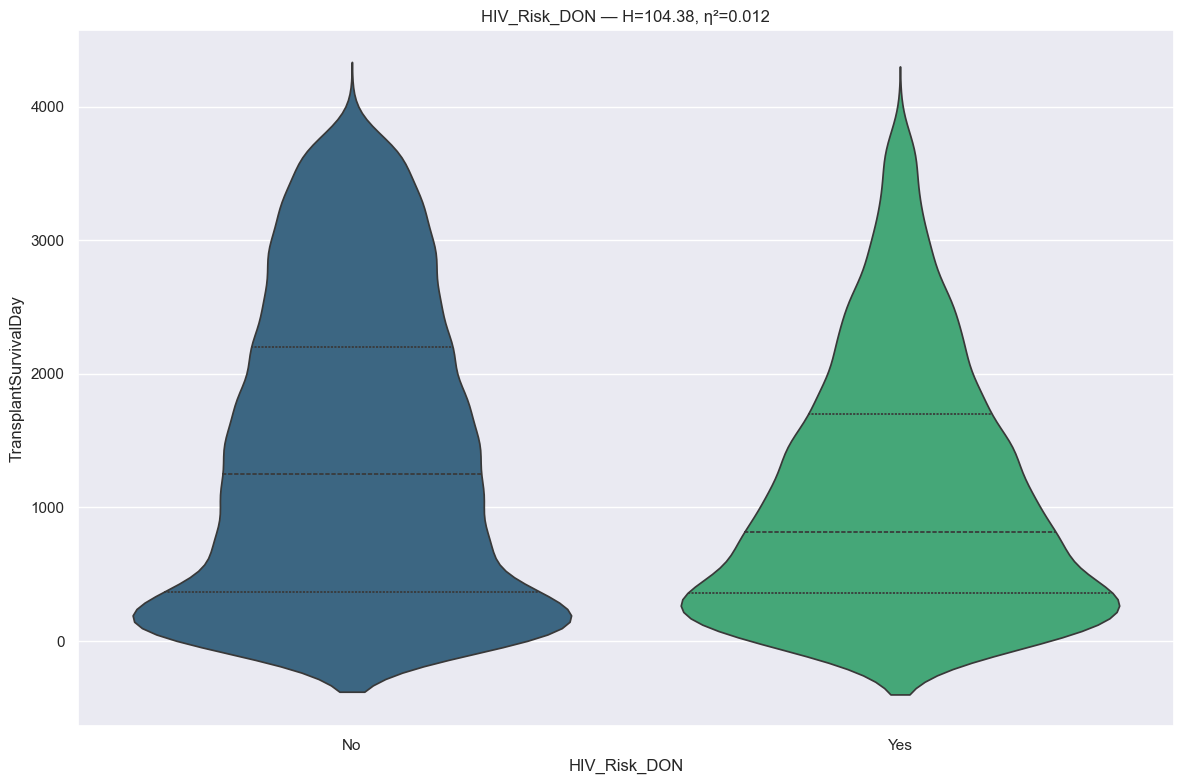

RANKING REPORT: HIV_Risk_DON (n ≥ 30)
INCLUDED CATEGORIES:
 * No                                                :   6367 records
 * Yes                                               :   1950 records
BYPASSED CATEGORIES (n < min_n):
 * Missing                                           :      1 records
 * Unknown                                           :      1 records
--------------------------------------------------------------------------------
Kruskal H: 104.3772 | P-value: 1.672480e-24 | Effect η²: 0.0124
Correction Method: BONFERRONI
Pairwise Testing (Bonferroni Alpha: 0.0500 | r_threshold: 0.10)
--------------------------------------------------------------------------------
No           vs Yes          | p=1.6726e-24 | thr=0.0500 | r=-0.153 | *Sig*
::::: Collapsed into 2 groups (excluding 'Other') :::::



In [260]:
# instantiate class
ranker = NominalSurvivalRanker.NominalSurvivalRanker(
    method="bonferroni",  # bonferroni, Holm-Bonferroni (holm) Benjamini–Hochberg (fdr)
    r_thresh=0.10,        # Lower r-threshold (strict merging)
)
# initialize variable
results = ranker.fit(df, features[0])
# mapping DataFrame
new_row = pd.DataFrame([ranker.build_feature_dict(results)])
mapping_df = pd.concat([mapping_df, new_row], ignore_index=True)

In [261]:
# mapping dictionary
print(results['mapping'])
mean_survival_by_category(df, features[0])

{'No': 'Group_1', 'Yes': 'Group_2', 'Missing': 'Other', 'Unknown': 'Other'}


,HIV_Risk_DON,mean_survival_days,record_count
1,No,1413.780116,6367
3,Yes,1092.011282,1950
0,Missing,1827.000000,1
2,Unknown,662.000000,1


#### Inotropic Agent

In [262]:
# info
features = u.get_feature_info(df, 'InotropicAgent', cat=False)
# dtype
{col: df[col].dtype for col in features}

                   count unique      top  freq
InotropicAgent_DON  8319      7  Missing  4966

:::: NaN Count:
InotropicAgent_DON    0 



{'InotropicAgent_DON': CategoricalDtype(categories=['Dobutamine', 'Dopamine', 'Epinephrine', 'Levophed',
                   'Missing', 'Neosynephrine', 'Other, specify'],
 , ordered=False, categories_dtype=object)}

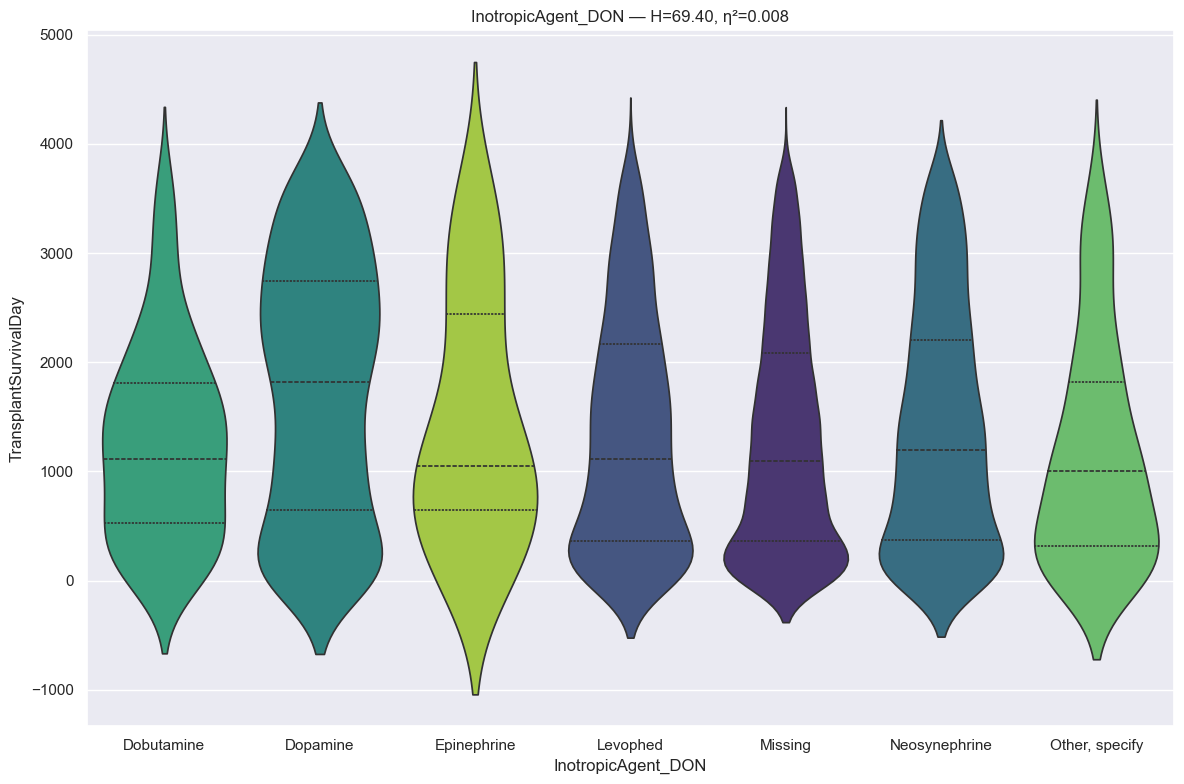

RANKING REPORT: InotropicAgent_DON (n ≥ 30)
INCLUDED CATEGORIES:
 * Dobutamine                                        :    149 records
 * Dopamine                                          :    540 records
 * Epinephrine                                       :     38 records
 * Levophed                                          :   1031 records
 * Missing                                           :   4966 records
 * Neosynephrine                                     :   1417 records
 * Other, specify                                    :    178 records
BYPASSED CATEGORIES: None
--------------------------------------------------------------------------------
Kruskal H: 69.4038 | P-value: 5.418188e-13 | Effect η²: 0.0076
Correction Method: BONFERRONI
Pairwise Testing (Bonferroni Alpha: 0.0024 | r_threshold: 0.10)
--------------------------------------------------------------------------------
Dopamine     vs Missing      | p=2.1106e-14 | thr=0.0024 | r=-0.200 | *Sig*
Dopamine     vs Levophed

In [263]:
# instantiate class
ranker = NominalSurvivalRanker.NominalSurvivalRanker(
    method="bonferroni",  # bonferroni, Holm-Bonferroni (holm) Benjamini–Hochberg (fdr)
    r_thresh=0.10,        # Lower r-threshold (strict merging)
)
# initialize variable
results = ranker.fit(df, features[0])
# mapping DataFrame
new_row = pd.DataFrame([ranker.build_feature_dict(results)])
mapping_df = pd.concat([mapping_df, new_row], ignore_index=True)

In [264]:
# mapping dictionary
print(results['mapping'])
mean_survival_by_category(df, features[0])

{'Dobutamine': 'Group_1', 'Epinephrine': 'Group_1', 'Levophed': 'Group_1', 'Missing': 'Group_1', 'Neosynephrine': 'Group_1', 'Other, specify': 'Group_1', 'Dopamine': 'Group_2'}


,InotropicAgent_DON,mean_survival_days,record_count
4,Missing,1286.277890,4966
5,Neosynephrine,1404.879323,1417
3,Levophed,1335.044617,1031
1,Dopamine,1718.988889,540
6,"Other, specify",1155.837079,178
0,Dobutamine,1276.557047,149
2,Epinephrine,1432.842105,38


In [265]:
# instantiate class
ranker = NominalSurvivalRanker.NominalSurvivalRanker(
    method="holm",  # bonferroni, Holm-Bonferroni (holm) Benjamini–Hochberg (fdr)
    r_thresh=0.05,        # Lower r-threshold (strict merging)
    plot=False
)
# initialize variable
results = ranker.fit(df, features[0])
# mapping DataFrame & remove last entry 
mapping_df = mapping_df[mapping_df["feature"] != features[0]]
new_row = pd.DataFrame([ranker.build_feature_dict(results)])
mapping_df = pd.concat([mapping_df, new_row], ignore_index=True)

RANKING REPORT: InotropicAgent_DON (n ≥ 30)
INCLUDED CATEGORIES:
 * Dobutamine                                        :    149 records
 * Dopamine                                          :    540 records
 * Epinephrine                                       :     38 records
 * Levophed                                          :   1031 records
 * Missing                                           :   4966 records
 * Neosynephrine                                     :   1417 records
 * Other, specify                                    :    178 records
BYPASSED CATEGORIES: None
--------------------------------------------------------------------------------
Kruskal H: 69.4038 | P-value: 5.418188e-13 | Effect η²: 0.0076
Correction Method: HOLM
Pairwise Testing (Base Alpha: 0.05 | Method: HOLM | r_threshold: 0.05)
--------------------------------------------------------------------------------
Dopamine     vs Missing      | p=2.1106e-14 | thr=0.0024 | r=-0.200 | *Sig*
Dopamine     vs Levophe

In [266]:
# mapping dictionary
print(results['mapping'])
mean_survival_by_category(df, features[0])

{'Dobutamine': 'Group_1', 'Epinephrine': 'Group_1', 'Levophed': 'Group_1', 'Missing': 'Group_1', 'Neosynephrine': 'Group_1', 'Dopamine': 'Group_2', 'Other, specify': 'Group_3'}


,InotropicAgent_DON,mean_survival_days,record_count
4,Missing,1286.277890,4966
5,Neosynephrine,1404.879323,1417
3,Levophed,1335.044617,1031
1,Dopamine,1718.988889,540
6,"Other, specify",1155.837079,178
0,Dobutamine,1276.557047,149
2,Epinephrine,1432.842105,38


#### Kidney Allocation

In [267]:
# info
features = u.get_feature_info(df, 'KidneyAllocation', cat=False)
# dtype
{col: df[col].dtype for col in features}

                     count unique top  freq
KidneyAllocation_DON  8319      3  No  7974

:::: NaN Count:
KidneyAllocation_DON    0 



{'KidneyAllocation_DON': CategoricalDtype(categories=['Missing', 'No', 'Yes'], ordered=False, categories_dtype=object)}

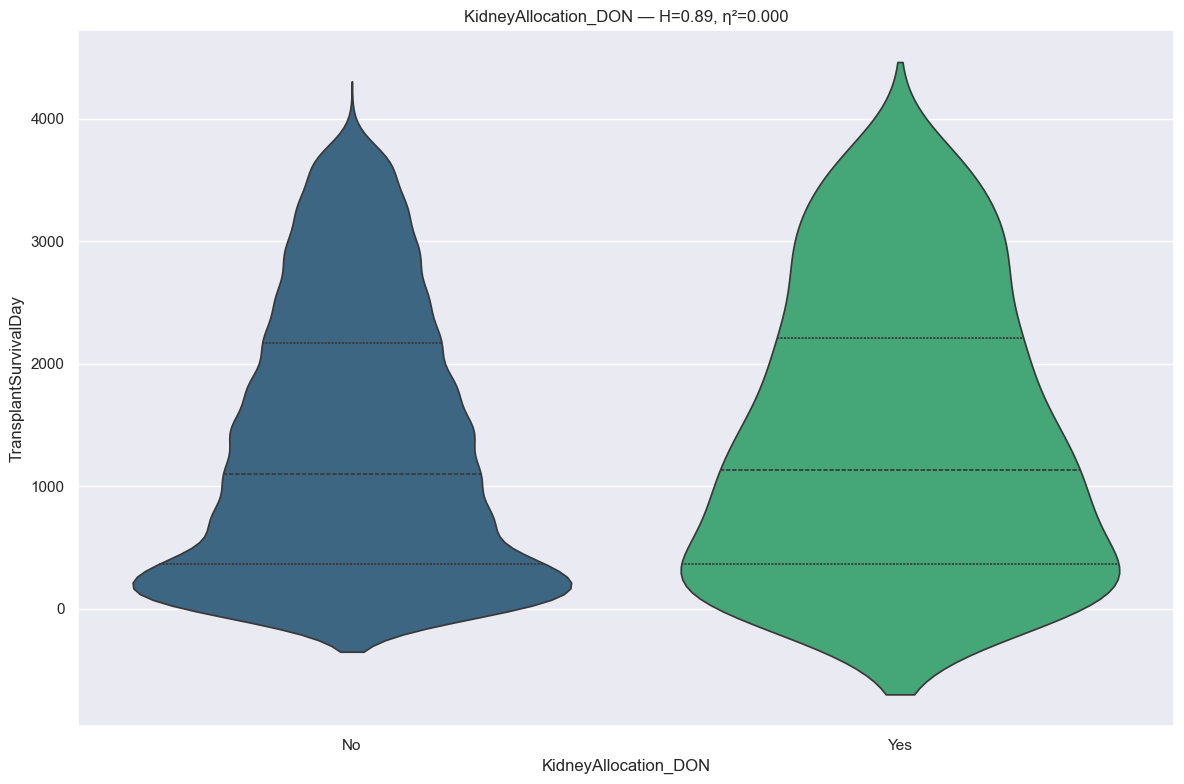

RANKING REPORT: KidneyAllocation_DON (n ≥ 30)
INCLUDED CATEGORIES:
 * No                                                :   7974 records
 * Yes                                               :    344 records
BYPASSED CATEGORIES (n < min_n):
 * Missing                                           :      1 records
--------------------------------------------------------------------------------
Kruskal H: 0.8915 | P-value: 3.450587e-01 | Effect η²: 0.0000
Correction Method: BONFERRONI
Pairwise Testing (Bonferroni Alpha: 0.0500 | r_threshold: 0.10)
--------------------------------------------------------------------------------
No           vs Yes          | p=3.4506e-01 | thr=0.0500 | r= 0.030 | Not Sig
::::: Collapsed into 1 groups (excluding 'Other') :::::



In [268]:
# instantiate class
ranker = NominalSurvivalRanker.NominalSurvivalRanker(
    method="bonferroni",  # bonferroni, Holm-Bonferroni (holm) Benjamini–Hochberg (fdr)
    r_thresh=0.10,        # Lower r-threshold (strict merging)
)
# initialize variable
results = ranker.fit(df, features[0])
# mapping DataFrame
new_row = pd.DataFrame([ranker.build_feature_dict(results)])
mapping_df = pd.concat([mapping_df, new_row], ignore_index=True)

In [269]:
# mapping dictionary
print(results['mapping'])
mean_survival_by_category(df, features[0])

{'No': 'Group_1', 'Yes': 'Group_1', 'Missing': 'Other'}


,KidneyAllocation_DON,mean_survival_days,record_count
1,No,1334.857412,7974
2,Yes,1417.061047,344
0,Missing,1827.000000,1


#### Inotropic Medication Procurement

In [270]:
# info
features = u.get_feature_info(df, 'InotropicMedicationProcurement', cat=False)
# dtype
{col: df[col].dtype for col in features}

                                   count unique top  freq
InotropicMedicationProcurement_DON  8319      4  No  4938

:::: NaN Count:
InotropicMedicationProcurement_DON    0 



{'InotropicMedicationProcurement_DON': CategoricalDtype(categories=['Missing', 'No', 'Unknown', 'Yes'], ordered=False, categories_dtype=object)}

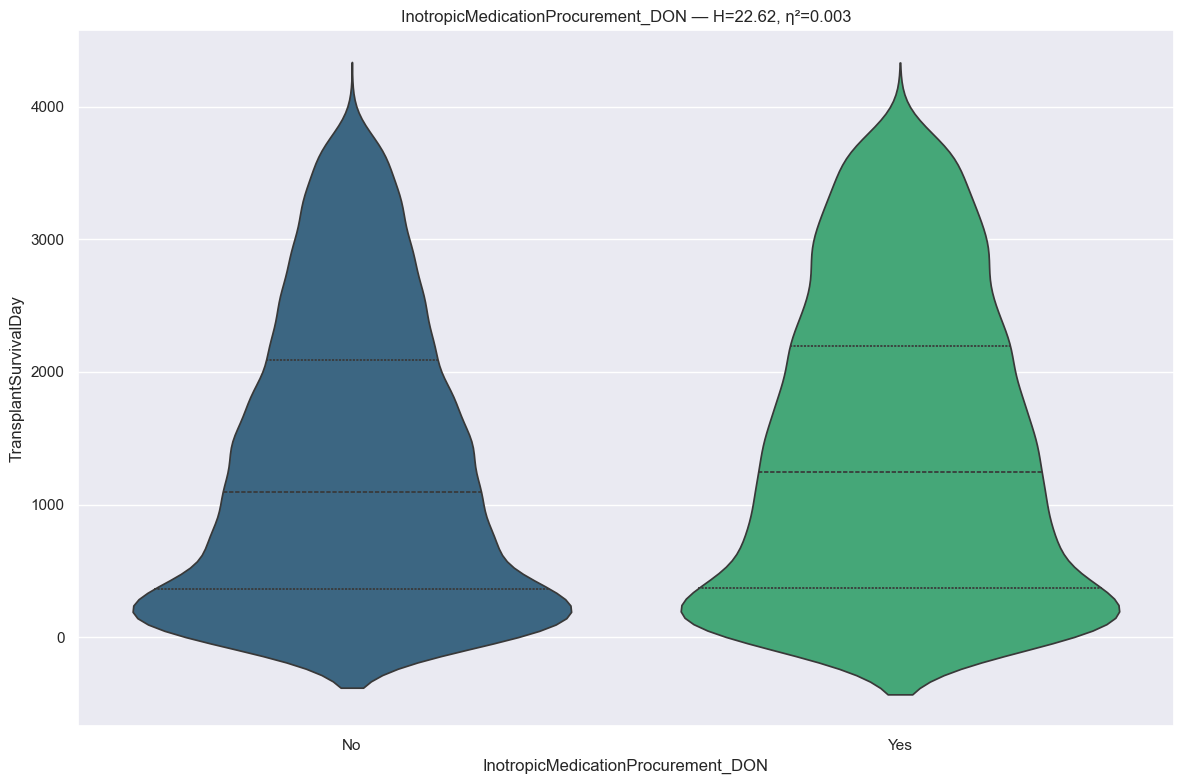

RANKING REPORT: InotropicMedicationProcurement_DON (n ≥ 30)
INCLUDED CATEGORIES:
 * No                                                :   4938 records
 * Yes                                               :   3353 records
BYPASSED CATEGORIES (n < min_n):
 * Missing                                           :     14 records
 * Unknown                                           :     14 records
--------------------------------------------------------------------------------
Kruskal H: 22.6246 | P-value: 1.969437e-06 | Effect η²: 0.0026
Correction Method: BONFERRONI
Pairwise Testing (Bonferroni Alpha: 0.0500 | r_threshold: 0.10)
--------------------------------------------------------------------------------
No           vs Yes          | p=1.9695e-06 | thr=0.0500 | r= 0.061 | *Sig*
::::: Collapsed into 2 groups (excluding 'Other') :::::



In [271]:
# instantiate class
ranker = NominalSurvivalRanker.NominalSurvivalRanker(
    method="bonferroni",  # bonferroni, Holm-Bonferroni (holm) Benjamini–Hochberg (fdr)
    r_thresh=0.10,        # Lower r-threshold (strict merging)
)
# initialize variable
results = ranker.fit(df, features[0])
# mapping DataFrame
new_row = pd.DataFrame([ranker.build_feature_dict(results)])
mapping_df = pd.concat([mapping_df, new_row], ignore_index=True)

In [272]:
# mapping dictionary
print(results['mapping'])
mean_survival_by_category(df, features[0])

{'No': 'Group_1', 'Yes': 'Group_2', 'Missing': 'Other', 'Unknown': 'Other'}


,InotropicMedicationProcurement_DON,mean_survival_days,record_count
1,No,1287.738761,4938
3,Yes,1415.387116,3353
0,Missing,1034.000000,14
2,Unknown,1023.285714,14


In [273]:
# Collapse Missing & Unknown into Other
# mapping
mapping = {'Unknown': 'Other',
           'Missing': 'Other'
          }
# map the change
df[features[0]] = (df[features[0]].map(mapping).fillna(df[features[0]]))
# sanity check
mean_survival_by_category(df,features[0])

,InotropicMedicationProcurement_DON,mean_survival_days,record_count
0,No,1287.738761,4938
2,Yes,1415.387116,3353
1,Other,1028.642857,28


#### LT ONE WEEK

In [274]:
# info
features = u.get_feature_info(df, 'LT_ONE_WEEK', cat=False)
# dtype
{col: df[col].dtype for col in features}

                count unique top  freq
LT_ONE_WEEK_DON  8319      1  No  8319

:::: NaN Count:
LT_ONE_WEEK_DON    0 



{'LT_ONE_WEEK_DON': CategoricalDtype(categories=['No'], ordered=False, categories_dtype=object)}

In [275]:
# add to remove list
remove_cols.extend(features)

#### Transfusion Number

In [276]:
# info
features = u.get_feature_info(df, 'TransfusionNumber', cat=False)
# dtype
{col: df[col].dtype for col in features}

                      count unique   top  freq
TransfusionNumber_DON  8319      6  NONE  3742

:::: NaN Count:
TransfusionNumber_DON    0 



{'TransfusionNumber_DON': CategoricalDtype(categories=['1 - 5', '6 - 10', 'GREATER THAN 10', 'Missing', 'NONE',
                   'UNKNOWN'],
 , ordered=False, categories_dtype=object)}

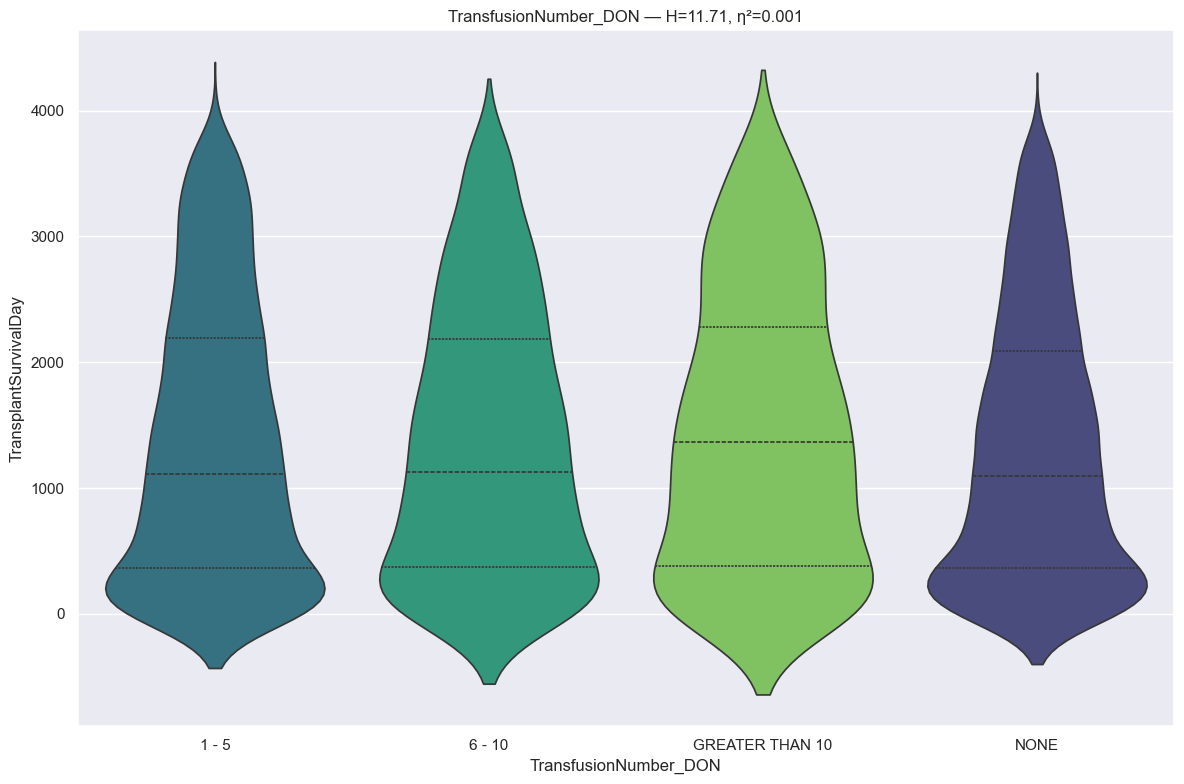

RANKING REPORT: TransfusionNumber_DON (n ≥ 30)
INCLUDED CATEGORIES:
 * 1 - 5                                             :   3327 records
 * 6 - 10                                            :    780 records
 * GREATER THAN 10                                   :    460 records
 * NONE                                              :   3742 records
BYPASSED CATEGORIES (n < min_n):
 * Missing                                           :      9 records
 * UNKNOWN                                           :      1 records
--------------------------------------------------------------------------------
Kruskal H: 11.7140 | P-value: 8.429754e-03 | Effect η²: 0.0010
Correction Method: BONFERRONI
Pairwise Testing (Bonferroni Alpha: 0.0083 | r_threshold: 0.10)
--------------------------------------------------------------------------------
GREATER THAN 10 vs NONE         | p=8.9769e-03 | thr=0.0083 | r=-0.075 | Not Sig
1 - 5        vs NONE         | p=1.3192e-02 | thr=0.0083 | r=-0.034 | Not Sig
6

In [277]:
# instantiate class
ranker = NominalSurvivalRanker.NominalSurvivalRanker(
    method="bonferroni",  # bonferroni, Holm-Bonferroni (holm) Benjamini–Hochberg (fdr)
    r_thresh=0.10,        # Lower r-threshold (strict merging)
)
# initialize variable
results = ranker.fit(df, features[0])
# mapping DataFrame
new_row = pd.DataFrame([ranker.build_feature_dict(results)])
mapping_df = pd.concat([mapping_df, new_row], ignore_index=True)

In [278]:
# mapping dictionary
print(results['mapping'])
mean_survival_by_category(df, features[0])

{'1 - 5': 'Group_1', '6 - 10': 'Group_1', 'GREATER THAN 10': 'Group_1', 'NONE': 'Group_1', 'Missing': 'Other', 'UNKNOWN': 'Other'}


,TransfusionNumber_DON,mean_survival_days,record_count
4,NONE,1289.251203,3742
0,1 - 5,1371.005410,3327
1,6 - 10,1372.108974,780
2,GREATER THAN 10,1440.752174,460
3,Missing,1358.333333,9
5,UNKNOWN,2520.000000,1


In [279]:
# mapping
mapping = {'Missing': 'Other',
           'UNKNOWN': 'Other'
          }
# map the change
df[features[0]] = (df[features[0]].map(mapping).fillna(df[features[0]]))

# sanity check
mean_survival_by_category(df, features[0])

,TransfusionNumber_DON,mean_survival_days,record_count
3,NONE,1289.251203,3742
0,1 - 5,1371.005410,3327
1,6 - 10,1372.108974,780
2,GREATER THAN 10,1440.752174,460
4,Other,1474.500000,10


#### Pulmonary Catheter

In [280]:
# info
features = u.get_feature_info(df, 'PulmonaryCatheter', cat=False)
# dtype
{col: df[col].dtype for col in features}

                      count unique top  freq
PulmonaryCatheter_DON  8319      3  No  7756

:::: NaN Count:
PulmonaryCatheter_DON    0 



{'PulmonaryCatheter_DON': CategoricalDtype(categories=['Missing', 'No', 'Yes'], ordered=False, categories_dtype=object)}

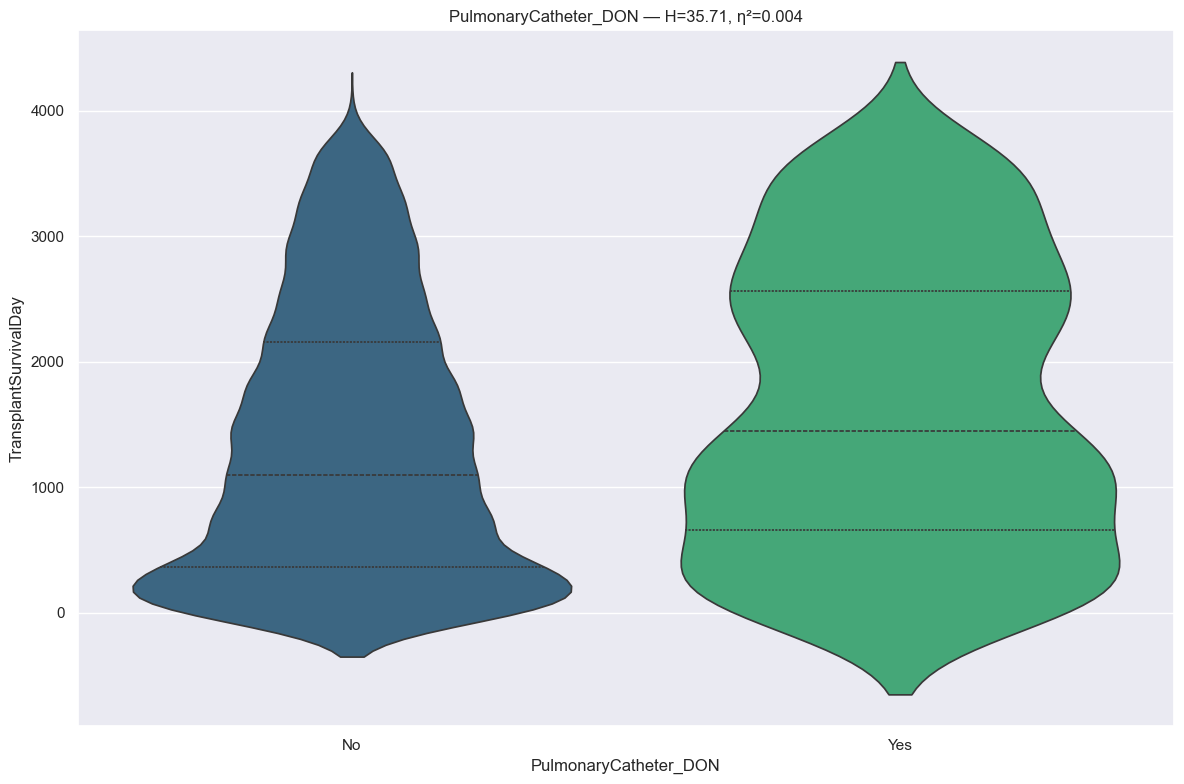

RANKING REPORT: PulmonaryCatheter_DON (n ≥ 30)
INCLUDED CATEGORIES:
 * No                                                :   7756 records
 * Yes                                               :    549 records
BYPASSED CATEGORIES (n < min_n):
 * Missing                                           :     14 records
--------------------------------------------------------------------------------
Kruskal H: 35.7104 | P-value: 2.289432e-09 | Effect η²: 0.0042
Correction Method: BONFERRONI
Pairwise Testing (Bonferroni Alpha: 0.0500 | r_threshold: 0.10)
--------------------------------------------------------------------------------
No           vs Yes          | p=2.2896e-09 | thr=0.0500 | r= 0.152 | *Sig*
::::: Collapsed into 2 groups (excluding 'Other') :::::



In [281]:
# instantiate class
ranker = NominalSurvivalRanker.NominalSurvivalRanker(
    method="bonferroni",  # bonferroni, Holm-Bonferroni (holm) Benjamini–Hochberg (fdr)
    r_thresh=0.10,        # Lower r-threshold (strict merging)
)
# initialize variable
results = ranker.fit(df, features[0])
# mapping DataFrame
new_row = pd.DataFrame([ranker.build_feature_dict(results)])
mapping_df = pd.concat([mapping_df, new_row], ignore_index=True)

In [282]:
# mapping dictionary
print(results['mapping'])
mean_survival_by_category(df, features[0])

{'No': 'Group_1', 'Yes': 'Group_2', 'Missing': 'Other'}


,PulmonaryCatheter_DON,mean_survival_days,record_count
1,No,1318.227050,7756
2,Yes,1629.879781,549
0,Missing,1034.000000,14


#### Bronchoscopy Left

In [283]:
# info
features = u.get_feature_info(df, 'BronchoscopyLeft', cat=False)
# dtype
{col: df[col].dtype for col in features}

                     count unique      top  freq
BronchoscopyLeft_DON  8319      9  Missing  3934

:::: NaN Count:
BronchoscopyLeft_DON    0 



{'BronchoscopyLeft_DON': CategoricalDtype(categories=['Abnormal-anatomy/other lesion',
                   'Abnormal-aspiration of foreign body', 'Abnormal-blood',
                   'Abnormal-purulent secretions', 'Missing', 'No Bronchoscopy',
                   'Normal', 'Unknown', 'Unknown if bronchoscopy performed'],
 , ordered=False, categories_dtype=object)}

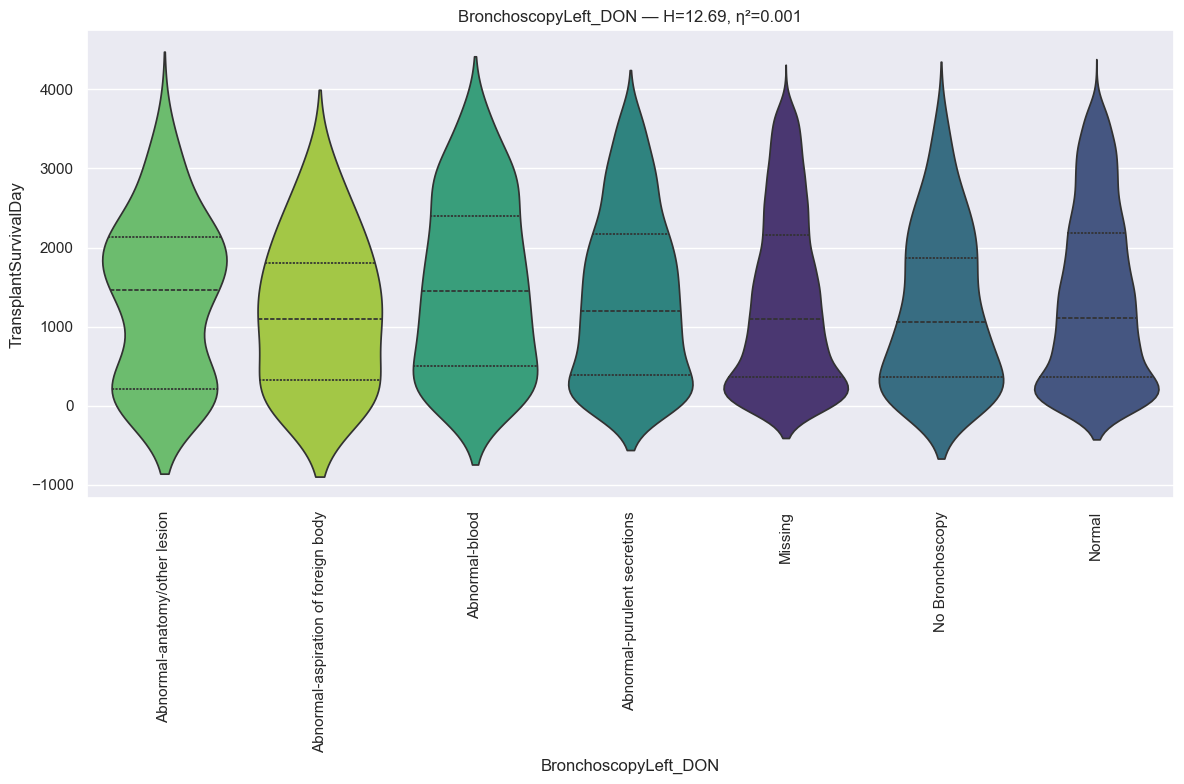

RANKING REPORT: BronchoscopyLeft_DON (n ≥ 30)
INCLUDED CATEGORIES:
 * Abnormal-anatomy/other lesion                     :     64 records
 * Abnormal-aspiration of foreign body               :     36 records
 * Abnormal-blood                                    :    201 records
 * Abnormal-purulent secretions                      :    674 records
 * Missing                                           :   3934 records
 * No Bronchoscopy                                   :    220 records
 * Normal                                            :   3162 records
BYPASSED CATEGORIES (n < min_n):
 * Unknown                                           :     24 records
 * Unknown if bronchoscopy performed                 :      4 records
--------------------------------------------------------------------------------
Kruskal H: 12.6895 | P-value: 4.824085e-02 | Effect η²: 0.0008
Correction Method: BONFERRONI
Pairwise Testing (Bonferroni Alpha: 0.0024 | r_threshold: 0.10)
--------------------------------

In [284]:
# instantiate class
ranker = NominalSurvivalRanker.NominalSurvivalRanker(
    method="bonferroni",  # bonferroni, Holm-Bonferroni (holm) Benjamini–Hochberg (fdr)
    r_thresh=0.10,        # Lower r-threshold (strict merging)
    rotation=90
)
# initialize variable
results = ranker.fit(df, features[0])
# mapping DataFrame
new_row = pd.DataFrame([ranker.build_feature_dict(results)])
mapping_df = pd.concat([mapping_df, new_row], ignore_index=True)

In [285]:
# mapping dictionary
print(results['mapping'])
mean_survival_by_category(df, features[0])

{'Abnormal-anatomy/other lesion': 'Group_1', 'Abnormal-aspiration of foreign body': 'Group_1', 'Abnormal-blood': 'Group_1', 'Abnormal-purulent secretions': 'Group_1', 'Missing': 'Group_1', 'No Bronchoscopy': 'Group_1', 'Normal': 'Group_1', 'Unknown': 'Other', 'Unknown if bronchoscopy performed': 'Other'}


,BronchoscopyLeft_DON,mean_survival_days,record_count
4,Missing,1316.321556,3934
6,Normal,1355.841556,3162
3,Abnormal-purulent secretions,1367.192878,674
5,No Bronchoscopy,1205.709091,220
2,Abnormal-blood,1508.213930,201
0,Abnormal-anatomy/other lesion,1364.078125,64
1,Abnormal-aspiration of foreign body,1195.111111,36
7,Unknown,1665.416667,24
8,Unknown if bronchoscopy performed,1919.750000,4


In [286]:
# mapping
mapping = {'Unknown': 'Other',
           'Unknown if bronchoscopy performed': 'Other',
           'Missing': 'Other'
          }
# map the change
df[features[0]] = (df[features[0]].map(mapping).fillna(df[features[0]]))

# sanity check
mean_survival_by_category(df, features[0])

,BronchoscopyLeft_DON,mean_survival_days,record_count
6,Other,1319.045432,3962
5,Normal,1355.841556,3162
3,Abnormal-purulent secretions,1367.192878,674
4,No Bronchoscopy,1205.709091,220
2,Abnormal-blood,1508.213930,201
0,Abnormal-anatomy/other lesion,1364.078125,64
1,Abnormal-aspiration of foreign body,1195.111111,36


In [287]:
# instantiate class
ranker = NominalSurvivalRanker.NominalSurvivalRanker(
    method="bonferroni",  # bonferroni, Holm-Bonferroni (holm) Benjamini–Hochberg (fdr)
    r_thresh=0.10,        # Lower r-threshold (strict merging)
    plot=False,
    suppress_pairwise=True
)
# initialize variable
results = ranker.fit(df, features[0])
# mapping DataFrame & remove last entry 
mapping_df = mapping_df[mapping_df["feature"] != features[0]]
new_row = pd.DataFrame([ranker.build_feature_dict(results)])
mapping_df = pd.concat([mapping_df, new_row], ignore_index=True)

RANKING REPORT: BronchoscopyLeft_DON (n ≥ 30)
INCLUDED CATEGORIES:
 * Abnormal-anatomy/other lesion                     :     64 records
 * Abnormal-aspiration of foreign body               :     36 records
 * Abnormal-blood                                    :    201 records
 * Abnormal-purulent secretions                      :    674 records
 * No Bronchoscopy                                   :    220 records
 * Normal                                            :   3162 records
 * Other                                             :   3962 records
BYPASSED CATEGORIES: None
--------------------------------------------------------------------------------
Kruskal H: 12.3257 | P-value: 5.508416e-02 | Effect η²: 0.0008
Correction Method: BONFERRONI
Pairwise Testing (Bonferroni Alpha: 0.0024 | r_threshold: 0.10)
--------------------------------------------------------------------------------
[Pairwise comparison output suppressed]
::::: Collapsed into 1 groups (excluding 'Other') :::::



In [288]:
# instantiate class
ranker = NominalSurvivalRanker.NominalSurvivalRanker(
    method="holm",  # bonferroni, Holm-Bonferroni (holm) Benjamini–Hochberg (fdr)
    r_thresh=0.05,        # Lower r-threshold (strict merging)
    plot=False,
    suppress_pairwise=True
)
# initialize variable
results = ranker.fit(df, features[0])
# mapping DataFrame & remove last entry 
mapping_df = mapping_df[mapping_df["feature"] != features[0]]
new_row = pd.DataFrame([ranker.build_feature_dict(results)])
mapping_df = pd.concat([mapping_df, new_row], ignore_index=True)

RANKING REPORT: BronchoscopyLeft_DON (n ≥ 30)
INCLUDED CATEGORIES:
 * Abnormal-anatomy/other lesion                     :     64 records
 * Abnormal-aspiration of foreign body               :     36 records
 * Abnormal-blood                                    :    201 records
 * Abnormal-purulent secretions                      :    674 records
 * No Bronchoscopy                                   :    220 records
 * Normal                                            :   3162 records
 * Other                                             :   3962 records
BYPASSED CATEGORIES: None
--------------------------------------------------------------------------------
Kruskal H: 12.3257 | P-value: 5.508416e-02 | Effect η²: 0.0008
Correction Method: HOLM
Pairwise Testing (Base Alpha: 0.05 | Method: HOLM | r_threshold: 0.05)
--------------------------------------------------------------------------------
[Pairwise comparison output suppressed]
::::: Collapsed into 3 groups (excluding 'Other') :::::



In [289]:
# mapping dictionary
print(results['mapping'])
mean_survival_by_category(df, features[0])

{'Abnormal-anatomy/other lesion': 'Group_1', 'Abnormal-purulent secretions': 'Group_1', 'Normal': 'Group_1', 'Other': 'Group_1', 'Abnormal-aspiration of foreign body': 'Group_2', 'No Bronchoscopy': 'Group_2', 'Abnormal-blood': 'Group_3'}


,BronchoscopyLeft_DON,mean_survival_days,record_count
6,Other,1319.045432,3962
5,Normal,1355.841556,3162
3,Abnormal-purulent secretions,1367.192878,674
4,No Bronchoscopy,1205.709091,220
2,Abnormal-blood,1508.213930,201
0,Abnormal-anatomy/other lesion,1364.078125,64
1,Abnormal-aspiration of foreign body,1195.111111,36


In [290]:
# remove last entry 
mapping_df = mapping_df[mapping_df["feature"] != features[0]]
# add to remove list
remove_cols.extend(features)

#### Bronchoscopy Right

In [291]:
# info
features = u.get_feature_info(df, 'BronchoscopyRight', cat=False)
# dtype
{col: df[col].dtype for col in features}

                      count unique      top  freq
BronchoscopyRight_DON  8319      9  Missing  3972

:::: NaN Count:
BronchoscopyRight_DON    0 



{'BronchoscopyRight_DON': CategoricalDtype(categories=['Abnormal-anatomy/other lesion',
                   'Abnormal-aspiration of foreign body', 'Abnormal-blood',
                   'Abnormal-purulent secretions', 'Missing', 'No Bronchoscopy',
                   'Normal', 'Unknown', 'Unknown if bronchoscopy performed'],
 , ordered=False, categories_dtype=object)}

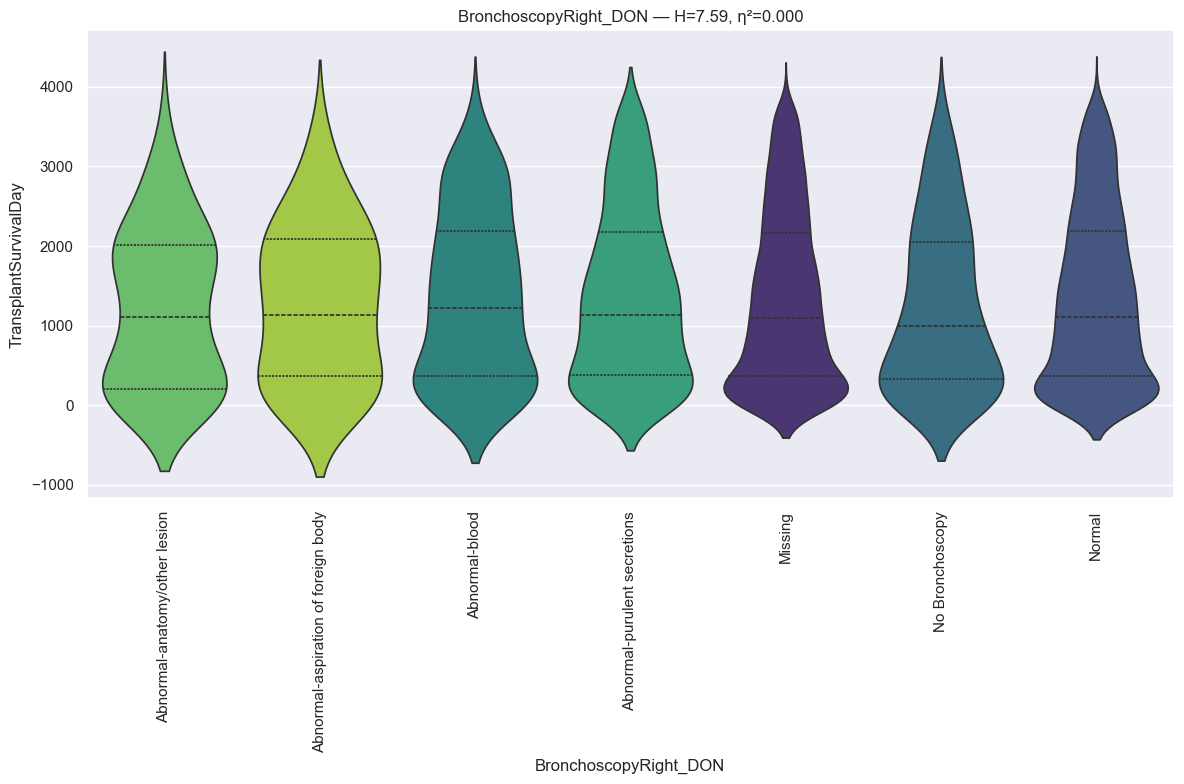

RANKING REPORT: BronchoscopyRight_DON (n ≥ 30)
INCLUDED CATEGORIES:
 * Abnormal-anatomy/other lesion                     :     70 records
 * Abnormal-aspiration of foreign body               :     45 records
 * Abnormal-blood                                    :    204 records
 * Abnormal-purulent secretions                      :    739 records
 * Missing                                           :   3972 records
 * No Bronchoscopy                                   :    228 records
 * Normal                                            :   3030 records
BYPASSED CATEGORIES (n < min_n):
 * Unknown                                           :     28 records
 * Unknown if bronchoscopy performed                 :      3 records
--------------------------------------------------------------------------------
Kruskal H: 7.5856 | P-value: 2.700578e-01 | Effect η²: 0.0002
Correction Method: BONFERRONI
Pairwise Testing (Bonferroni Alpha: 0.0024 | r_threshold: 0.10)
--------------------------------

In [292]:
# instantiate class
ranker = NominalSurvivalRanker.NominalSurvivalRanker(
    method="bonferroni",  # bonferroni, Holm-Bonferroni (holm) Benjamini–Hochberg (fdr)
    r_thresh=0.10,        # Lower r-threshold (strict merging)
    rotation=90
)
# initialize variable
results = ranker.fit(df, features[0])
# mapping DataFrame
new_row = pd.DataFrame([ranker.build_feature_dict(results)])
mapping_df = pd.concat([mapping_df, new_row], ignore_index=True)

In [293]:
# mapping dictionary
print(results['mapping'])
mean_survival_by_category(df, features[0])

{'Abnormal-anatomy/other lesion': 'Group_1', 'Abnormal-aspiration of foreign body': 'Group_1', 'Abnormal-blood': 'Group_1', 'Abnormal-purulent secretions': 'Group_1', 'Missing': 'Group_1', 'No Bronchoscopy': 'Group_1', 'Normal': 'Group_1', 'Unknown': 'Other', 'Unknown if bronchoscopy performed': 'Other'}


,BronchoscopyRight_DON,mean_survival_days,record_count
4,Missing,1320.472558,3972
6,Normal,1357.514521,3030
3,Abnormal-purulent secretions,1379.205683,739
5,No Bronchoscopy,1224.149123,228
2,Abnormal-blood,1370.186275,204
0,Abnormal-anatomy/other lesion,1229.100000,70
1,Abnormal-aspiration of foreign body,1292.844444,45
7,Unknown,1638.607143,28
8,Unknown if bronchoscopy performed,2436.666667,3


In [294]:
# mapping
mapping = {'Unknown': 'Other',
           'Unknown if bronchoscopy performed': 'Other',
           'Missing': 'Other'
          }
# map the change
df[features[0]] = (df[features[0]].map(mapping).fillna(df[features[0]]))

# sanity check
mean_survival_by_category(df, features[0])

,BronchoscopyRight_DON,mean_survival_days,record_count
6,Other,1323.534349,4003
5,Normal,1357.514521,3030
3,Abnormal-purulent secretions,1379.205683,739
4,No Bronchoscopy,1224.149123,228
2,Abnormal-blood,1370.186275,204
0,Abnormal-anatomy/other lesion,1229.100000,70
1,Abnormal-aspiration of foreign body,1292.844444,45


In [295]:
# instantiate class
ranker = NominalSurvivalRanker.NominalSurvivalRanker(
    method="bonferroni",  # bonferroni, Holm-Bonferroni (holm) Benjamini–Hochberg (fdr)
    r_thresh=0.05,        # Lower r-threshold (strict merging)
    plot=False,
    suppress_pairwise=True
)
# initialize variable
results = ranker.fit(df, features[0])
# mapping DataFrame & remove last entry 
mapping_df = mapping_df[mapping_df["feature"] != features[0]]
new_row = pd.DataFrame([ranker.build_feature_dict(results)])
mapping_df = pd.concat([mapping_df, new_row], ignore_index=True)

RANKING REPORT: BronchoscopyRight_DON (n ≥ 30)
INCLUDED CATEGORIES:
 * Abnormal-anatomy/other lesion                     :     70 records
 * Abnormal-aspiration of foreign body               :     45 records
 * Abnormal-blood                                    :    204 records
 * Abnormal-purulent secretions                      :    739 records
 * No Bronchoscopy                                   :    228 records
 * Normal                                            :   3030 records
 * Other                                             :   4003 records
BYPASSED CATEGORIES: None
--------------------------------------------------------------------------------
Kruskal H: 7.2609 | P-value: 2.973923e-01 | Effect η²: 0.0002
Correction Method: BONFERRONI
Pairwise Testing (Bonferroni Alpha: 0.0024 | r_threshold: 0.05)
--------------------------------------------------------------------------------
[Pairwise comparison output suppressed]
::::: Collapsed into 1 groups (excluding 'Other') :::::



In [296]:
# instantiate class
ranker = NominalSurvivalRanker.NominalSurvivalRanker(
    method="holm",  # bonferroni, Holm-Bonferroni (holm) Benjamini–Hochberg (fdr)
    r_thresh=0.05,        # Lower r-threshold (strict merging)
    plot=False,
    suppress_pairwise=True
)
# initialize variable
results = ranker.fit(df, features[0])
# mapping DataFrame & remove last entry 
mapping_df = mapping_df[mapping_df["feature"] != features[0]]
new_row = pd.DataFrame([ranker.build_feature_dict(results)])
mapping_df = pd.concat([mapping_df, new_row], ignore_index=True)

RANKING REPORT: BronchoscopyRight_DON (n ≥ 30)
INCLUDED CATEGORIES:
 * Abnormal-anatomy/other lesion                     :     70 records
 * Abnormal-aspiration of foreign body               :     45 records
 * Abnormal-blood                                    :    204 records
 * Abnormal-purulent secretions                      :    739 records
 * No Bronchoscopy                                   :    228 records
 * Normal                                            :   3030 records
 * Other                                             :   4003 records
BYPASSED CATEGORIES: None
--------------------------------------------------------------------------------
Kruskal H: 7.2609 | P-value: 2.973923e-01 | Effect η²: 0.0002
Correction Method: HOLM
Pairwise Testing (Base Alpha: 0.05 | Method: HOLM | r_threshold: 0.05)
--------------------------------------------------------------------------------
[Pairwise comparison output suppressed]
::::: Collapsed into 1 groups (excluding 'Other') :::::



In [297]:
# remove last entry 
mapping_df = mapping_df[mapping_df["feature"] != features[0]]
# add to remove list
remove_cols.extend(features)

#### Chest Xray

In [298]:
# info
features = u.get_feature_info(df, 'ChestXray', cat=False)
# dtype
{col: df[col].dtype for col in features}

              count unique            top  freq
ChestXray_DON  8319      7  Abnormal-both  4504

:::: NaN Count:
ChestXray_DON    0 



{'ChestXray_DON': CategoricalDtype(categories=['Abnormal-both', 'Abnormal-left', 'Abnormal-right',
                   'Missing', 'No chest x-ray', 'Normal', 'Results Unknown'],
 , ordered=False, categories_dtype=object)}

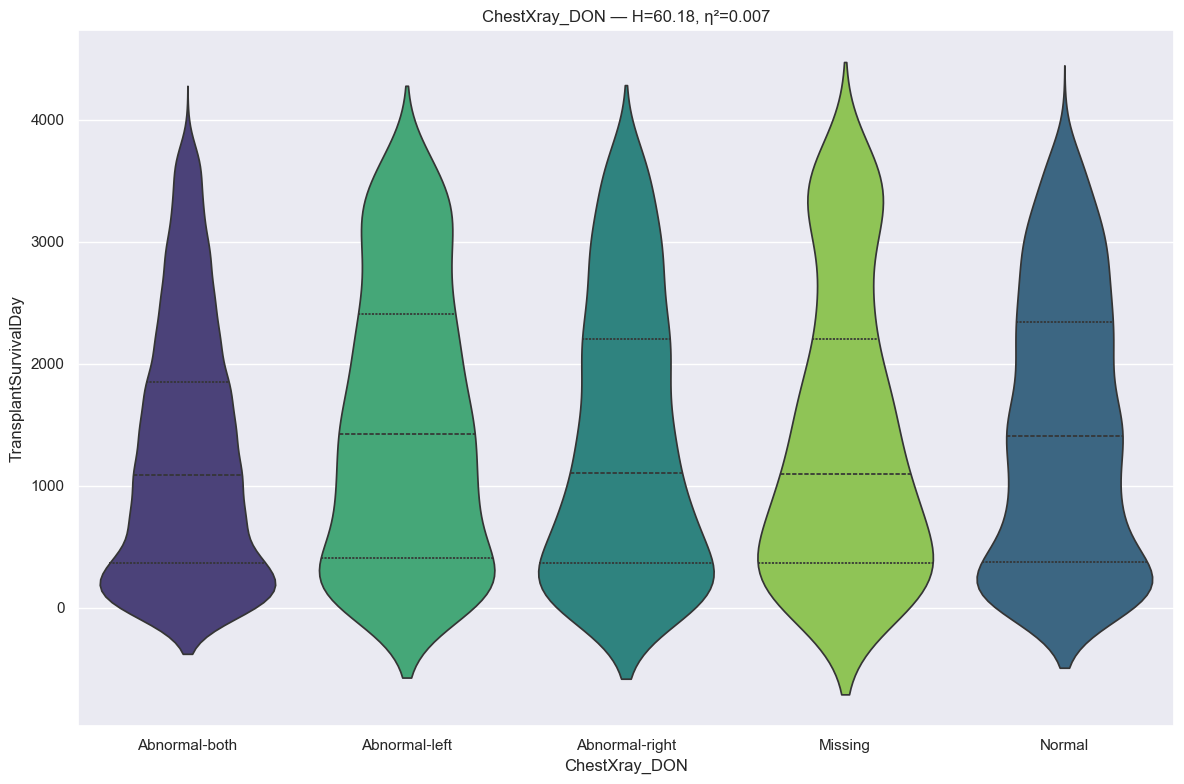

RANKING REPORT: ChestXray_DON (n ≥ 30)
INCLUDED CATEGORIES:
 * Abnormal-both                                     :   4504 records
 * Abnormal-left                                     :    869 records
 * Abnormal-right                                    :    819 records
 * Missing                                           :    375 records
 * Normal                                            :   1731 records
BYPASSED CATEGORIES (n < min_n):
 * No chest x-ray                                    :      2 records
 * Results Unknown                                   :     19 records
--------------------------------------------------------------------------------
Kruskal H: 60.1824 | P-value: 2.655857e-12 | Effect η²: 0.0068
Correction Method: BONFERRONI
Pairwise Testing (Bonferroni Alpha: 0.0050 | r_threshold: 0.10)
--------------------------------------------------------------------------------
Abnormal-both vs Normal       | p=8.1101e-10 | thr=0.0050 | r= 0.100 | *Sig*
Abnormal-both vs Abno

In [299]:
# instantiate class
ranker = NominalSurvivalRanker.NominalSurvivalRanker(
    method="bonferroni",  # bonferroni, Holm-Bonferroni (holm) Benjamini–Hochberg (fdr)
    r_thresh=0.10,        # Lower r-threshold (strict merging)
)
# initialize variable
results = ranker.fit(df, features[0])
# mapping DataFrame
new_row = pd.DataFrame([ranker.build_feature_dict(results)])
mapping_df = pd.concat([mapping_df, new_row], ignore_index=True)

In [300]:
# mapping dictionary
print(results['mapping'])
mean_survival_by_category(df, features[0])

{'Abnormal-both': 'Group_1', 'Abnormal-left': 'Group_1', 'Abnormal-right': 'Group_1', 'Missing': 'Group_1', 'Normal': 'Group_1', 'No chest x-ray': 'Other', 'Results Unknown': 'Other'}


,ChestXray_DON,mean_survival_days,record_count
0,Abnormal-both,1251.540853,4504
5,Normal,1449.676488,1731
1,Abnormal-left,1501.275029,869
2,Abnormal-right,1377.301587,819
3,Missing,1405.464000,375
6,Results Unknown,1336.947368,19
4,No chest x-ray,1025.000000,2


In [301]:
# mapping
mapping = {'No chest x-ray': 'Other',
           'Results Unknown': 'Other',
           'Missing': 'Other'
          }
# map the change
df[features[0]] = (df[features[0]].map(mapping).fillna(df[features[0]]))

# sanity check
mean_survival_by_category(df, features[0])

,ChestXray_DON,mean_survival_days,record_count
0,Abnormal-both,1251.540853,4504
3,Normal,1449.676488,1731
1,Abnormal-left,1501.275029,869
2,Abnormal-right,1377.301587,819
4,Other,1400.255051,396


In [302]:
# instantiate class
ranker = NominalSurvivalRanker.NominalSurvivalRanker(
    method="holm",  # bonferroni, Holm-Bonferroni (holm) Benjamini–Hochberg (fdr)
    r_thresh=0.08,        # Lower r-threshold (strict merging)
    plot=False
)
# initialize variable
results = ranker.fit(df, features[0])
# mapping DataFrame & remove last entry 
mapping_df = mapping_df[mapping_df["feature"] != features[0]]
new_row = pd.DataFrame([ranker.build_feature_dict(results)])
mapping_df = pd.concat([mapping_df, new_row], ignore_index=True)

RANKING REPORT: ChestXray_DON (n ≥ 30)
INCLUDED CATEGORIES:
 * Abnormal-both                                     :   4504 records
 * Abnormal-left                                     :    869 records
 * Abnormal-right                                    :    819 records
 * Normal                                            :   1731 records
 * Other                                             :    396 records
BYPASSED CATEGORIES: None
--------------------------------------------------------------------------------
Kruskal H: 59.9808 | P-value: 2.927939e-12 | Effect η²: 0.0067
Correction Method: HOLM
Pairwise Testing (Base Alpha: 0.05 | Method: HOLM | r_threshold: 0.08)
--------------------------------------------------------------------------------
Abnormal-both vs Normal       | p=8.1101e-10 | thr=0.0050 | r= 0.100 | *Sig*
Abnormal-both vs Abnormal-left | p=3.0616e-09 | thr=0.0056 | r= 0.127 | *Sig*
Abnormal-left vs Abnormal-right | p=1.2247e-02 | thr=0.0063 | r=-0.070 | Not Sig
Abnormal

In [303]:
# mapping dictionary
print(results['mapping'])
mean_survival_by_category(df, features[0])

{'Abnormal-both': 'Group_1', 'Abnormal-left': 'Group_1', 'Abnormal-right': 'Group_1', 'Normal': 'Group_1', 'Other': 'Group_1'}


,ChestXray_DON,mean_survival_days,record_count
0,Abnormal-both,1251.540853,4504
3,Normal,1449.676488,1731
1,Abnormal-left,1501.275029,869
2,Abnormal-right,1377.301587,819
4,Other,1400.255051,396


In [304]:
# remove last entry 
mapping_df = mapping_df[mapping_df["feature"] != features[0]]
# add to remove list
remove_cols.extend(features)

#### Meds_DON

In [305]:
# info
features = u.get_feature_info(df, 'Meds', cat=False)
# dtype
{col: df[col].dtype for col in features}

         count unique top freq
Meds_DON  8319   7175      177

:::: NaN Count:
Meds_DON    0 



{'Meds_DON': dtype('O')}

In [306]:
# add to remove list
remove_cols.extend(features)

In [307]:
# remove unwanted columns
df = df.drop(columns=remove_cols).copy()

#### Write to Disk: Full Data

In [308]:
# save data: heart dataset
u.write_to_file(df, 'Female_DON_Heart_Data',path='../Data/', format='pkl')
u.write_to_file(mapping_df, 'Female_DON_Category_Mapping',path='../Data/', format='pkl')

8,319 records written to ../Data/Female_DON_Heart_Data.pkl
63 records written to ../Data/Female_DON_Category_Mapping.pkl
